<a href="https://colab.research.google.com/github/Qalani/Dissertation/blob/main/winam_wh_spatial_panel_driver_gam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Qalani/Dissertation/blob/main/winam_wh_spatial_panel_driver_gam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Winam Gulf water hyacinth spatial-panel — inferential driver GAM (Track B)

> **One of a pair.** This notebook was split from `winam_wh_spatial_panel_test_model.ipynb` so the two model families can run in parallel and save wall-clock time. It carries the **shared panel build** (Drive → classified GeoTIFFs → grid → Earth Engine covariates → feature engineering, §1–§12) followed by the **one-stage spatial driver GAM (Track B) only**. The predictive ML workhorse (Track A) lives in the sibling notebook `winam_wh_spatial_panel_predictive_ml.ipynb`. Build the panel once (both notebooks share the same Drive checkpoints, e.g. `PANEL_RAW_FROM_CHECKPOINT`), then run the two model sections concurrently.

This notebook builds a **spatially explicit monthly panel dataset** from already-classified water hyacinth GeoTIFFs in Google Drive, then fits the interpretable **driver** model.

It is designed as a **test-period prototype**, not the final dissertation model. It:

1. mounts Google Drive;
2. finds classified WH GeoTIFFs for a chosen period;
3. creates fixed 500 m or 1 km grid cells over Winam Gulf;
4. aggregates each classified raster to `grid cell × month`;
5. pulls environmental driver covariates directly from **Google Earth Engine** — rainfall (CHIRPS), wind and air temperature (ERA5 / ERA5-Land), water-surface temperature (MODIS LST), turbidity and chlorophyll-a proxies (Sentinel-2 / Sentinel-3 / MODIS), distance to rivers and shore, and catchment pressure (ESA WorldCover / WorldPop / GHSL) — and optionally merges CSV covariates for layers that have no EE asset (lake level, ENSO/IOD, bathymetry, in-situ nutrients);
6. creates lagged WH-cover and lagged environmental terms;
7. fits the **Track B inferential driver model** — a one-stage spatial **Beta (logit-link)** GAM (Tweedie optional; `mgcv::bam` via `rpy2`) with a smooth per environmental driver, a cyclic seasonal term, a 2-D `te(x, y)` spatial surface and a random cell intercept — and reports effect sizes, concurvity, residual spatial (Moran's I) / temporal autocorrelation, a forcing-only causal contrast, and dependence-aware block cross-validation;
8. exports panel tables, grid outputs and the driver-model effect / concurvity / CV tables.

The intended response variable is **monthly WH proportional cover per spatial unit**, not pixel-level WH occurrence.

The Earth Engine layers, assets and project (`ee-bmillwardsadler1`) match those already used in `Batch_Export.ipynb` and `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb`, so the same authenticated Colab runtime can run all three notebooks.

## 1. Install packages

Run this once at the start of a fresh Colab runtime.

In [29]:
# In Colab, uncomment and run this if packages are missing.
# This can take a few minutes.

# earthengine-api and geemap are needed for the Earth Engine covariate extraction
# in section 8. They match the dependencies of the classifier/export notebooks.
!pip -q install rasterio geopandas pyproj shapely fiona pyogrio statsmodels scikit-learn pygam tqdm earthengine-api geemap libpysal esda lightgbm

# The §13d ordered-Beta cross-check (change 1) needs an R package (mgcv/rpy2 are already set up
# in Colab). Install one of these into the R runtime, e.g. from Python:
#   import rpy2.robjects as ro
#   ro.r('install.packages("glmmTMB", repos="https://cloud.r-project.org")')     # fast; family=ordbeta()
#   ro.r('install.packages("ordbetareg", repos="https://cloud.r-project.org")')  # reference impl (brms/Stan; slow to compile)

## 2. Imports and Google Drive mount

In [30]:
from pathlib import Path
import re
import hashlib
import json
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

from shapely.geometry import box
from tqdm.auto import tqdm

import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import from_bounds, Window

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)

import matplotlib.pyplot as plt

# Import the earthengine-api library
import ee

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Google Drive was not mounted automatically. If running outside Colab, this is expected.")
    print(e)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 120)

EE_PROJECT = 'ee-bmillwardsadler1'
ee.Authenticate()
ee.Initialize(project=EE_PROJECT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. User configuration

Edit this cell first.

Important assumptions:

- By default this notebook now reads the **classified GeoTIFFs and run logs produced by `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb`**.
- `WH_CLASS_VALUES` is set to `[2]`, matching the classifier notebook's `FLOATING_CLASS_CODE` for floating plants / water hyacinth.
- Classified rasters are selected from **one exact classifier run**, `ACTIVE_CLASSIFIER_VERSION`, via the run log named for it (`CLASSIFIER_RUN_LOG_PATH`). The run log is never chosen by modification time or by a `winam_full_stack_run_log_*.csv` wildcard.
- The **batch-export token** (`REQUIRED_EXPORT_TOKEN_BY_SENSOR`) and the **classifier version** are separate provenance fields. The token identifies the predictor schema a snapshot was exported with, so on its own it is not evidence that the raster came from the active classifier run; both must hold.
- `REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR` is matched with an exact `startswith()`, so rasters from superseded export schemas are excluded rather than averaged in.
- `SUPPLEMENT_RUN_LOG_WITH_FOLDER = False` and there is **no directory-scan fallback**. A missing or incomplete run-log record raises rather than being filled in from `classified_geotiffs/`.
- `CLASSIFIER_SENSOR_FILTER` chooses the sensors; `CLASSIFIER_PRODUCT_FILTER` must stay `"model"`, so rule, probability, diagnostic and tiled-intermediate rasters can never become the response.
- The default grid CRS is **EPSG:32736**, UTM Zone 36S, which is suitable for the Winam Gulf area south of the equator.
- The default AOI is the same broad Winam Gulf rectangle used in your previous GEE workflow.


In [31]:
# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------

# These defaults match Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb:
#   DRIVE_ROOT / "outputs" / "full_stack_batch"
CLASSIFIER_BATCH_OUTPUT_DIR = Path("/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch")
CLASSIFIER_TABLE_DIR = CLASSIFIER_BATCH_OUTPUT_DIR / "tables"
CLASSIFIED_TIF_DIR = CLASSIFIER_BATCH_OUTPUT_DIR / "classified_geotiffs"

# ---------------------------------------------------------------------
# Classifier provenance: one exact classifier run, explicit export tokens
# ---------------------------------------------------------------------

# The single classifier run this panel is built from. It is the CLASSIFIER_VERSION
# assembled in Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb:
# 'route_b_s1_scc_spatialcv_proba_v4_whlev_temporal' plus the manual-correction
# suffix '_corr_' + MANUAL_CORRECTION_VERSION ('v1'). Outputs of any other run
# must not enter the response.
ACTIVE_CLASSIFIER_VERSION = (
    "route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1"
)

# The run log of that exact run, addressed by name. Never selected by
# modification time and never through a 'winam_full_stack_run_log_*.csv'
# wildcard: "newest on disk" quietly promotes a partial rerun of a different
# classifier version into the panel response.
CLASSIFIER_RUN_LOG_PATH = (
    CLASSIFIER_TABLE_DIR
    / f"winam_full_stack_run_log_{ACTIVE_CLASSIFIER_VERSION}.csv"
)

# Batch-export schema tokens, from S1_EXPORT_SCHEMA_VERSION /
# S2_EXPORT_SCHEMA_VERSION in Batch_Export.ipynb. These identify the PREDICTOR
# SCHEMA a snapshot was exported with -- which bands exist and in what order --
# and say nothing about which classifier later consumed it. Export token and
# classifier version are therefore two SEPARATE provenance fields: a matching
# token is never treated as proof of the classifier version on its own.
REQUIRED_EXPORT_TOKEN_BY_SENSOR = {
    "S1": "s1_scc_temporal_v1",
    "S2": "s2_whlev_temporal_v1",
}

# Batch_Export.ipynb (section 7) builds each snapshot prefix as
#   S1: f"winam_{S1_EXPORT_SCHEMA_VERSION}_{start}_to_{end}"
#   S2: f"winam_s2_predictors_{S2_EXPORT_SCHEMA_VERSION}_{start}_to_{end}"
# so a classified raster from the current schema starts with exactly these.
# Superseded exports (winam_s1_scc_predictors_..., s2_whlev_texture_v1) fail the
# startswith() test and are excluded instead of being averaged in unnoticed.
REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR = {
    "S1": "winam_s1_scc_temporal_v1_",
    "S2": "winam_s2_predictors_s2_whlev_temporal_v1_",
}

OUTPUT_DIR = Path("/content/drive/MyDrive/WH_spatial_panel_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The run log named for ACTIVE_CLASSIFIER_VERSION is the ONLY inventory source.
USE_CLASSIFIER_RUN_LOG = True
# Directory supplementation is off and the folder-scan fallback has been removed.
# Scanning CLASSIFIED_TIF_DIR pulled in rasters from earlier classifier runs and
# earlier batch-export schemas -- exactly the mixed inventory this configuration
# exists to prevent. A missing or incomplete run-log record now raises a clear
# error so the classifier notebook is rerun, instead of being papered over with
# unrelated files.
SUPPLEMENT_RUN_LOG_WITH_FOLDER = False

# Classifier-output selection. To use Sentinel-1 as a cloud-gap-fill for the
# Sentinel-2 response (Task 1), BOTH sensors are discovered here; the S1/S2
# fusion (prefer-S2, gap-fill-S1) happens in Section 7b, NOT by raw concatenation.
# Set CLASSIFIER_SENSOR_FILTER = ["S2"] to restore the single-sensor (S2) panel.
CLASSIFIER_SENSOR_FILTER = ["S2", "S1"] # None, ["S2"], ["S1"], or ["S2", "S1"]
# Must stay "model": the panel response is defined as the final
# model-classification product. Rule rasters are a different product and are not
# interchangeable with it, so they are never mixed into the same response.
CLASSIFIER_PRODUCT_FILTER = "model"
# The S1 patch filter writes '<model raster>_patch_cleaned.tif' beside its input.
# Where both exist for one acquisition the patch-cleaned raster is the final
# product and wins; competing outputs that are NOT a raw/cleaned pair raise.
PREFER_PATCH_CLEANED_S1 = True

# --- Sentinel-1 cloud-gap-fill fusion (Task 1) -------------------------------
# Sentinel-2 is cloud-limited: cloudy months drop out of the classified response,
# and that missingness correlates with rainfall (MNAR). Sentinel-1 SAR sees
# through cloud, so it is harmonised onto the S2 measurement scale and used to
# GAP-FILL S2 (never concatenated raw). S1 cover is calibrated to S2 from their
# overlap, then used ONLY where S2 is missing for a given cell-month. A `sensor`
# indicator is carried into the model so any residual cross-sensor offset is
# absorbed rather than attributed to ecology. See Section 7b / 9b.
ENABLE_S1_GAPFILL = True                  # build the S1 panel and gap-fill S2 cloud gaps
PRIMARY_SENSOR = "S2"                     # preferred sensor; the other fills its gaps
S1_CALIBRATION_METHOD = "robust_linear"  # "robust_linear" (Theil-Sen), "isotonic", or "none"
SENSOR_FEATURE_ENABLED = True            # add the sensor indicator (sensor_is_s1) to the feature set
S1_CALIBRATION_MAX_POINTS = 50000        # cap on S1/S2 overlap points used to FIT the S1->S2 calibration. TheilSen RAM/time scale with the point count, so fitting the full ~10^6-row overlap at 500 m exhausts memory; None or 0 = use all.

# Optional monthly environmental covariates.
# Expected format: one row per month, with a column called 'month'.
# Example columns:
# month,rainfall_mm,wind_speed_ms,lake_level_m,turbidity,chl_a
# Lake level from Schwatke, C., Dettmering, D., Bosch, W., and Seitz, F.:
# DAHITI - an innovative approach for estimating water level time series over inland waters using multi-mission satellite altimetry:
# Hydrol. Earth Syst. Sci., 19, 4345-4364, doi:10.5194/hess-19-4345-2015, 2015

ENV_MONTHLY_CSV = None
ENV_MONTHLY_CSV = Path("/content/drive/MyDrive/WH_drivers/lake_level_monthly.csv")

# Optional spatial covariates by grid_id.
# Expected format: one row per grid_id, with a column called 'grid_id'.
# Example columns:
# grid_id,dist_river_m,fetch_m,depth_m,shelter_index
SPATIAL_COVARIATES_CSV = None
# SPATIAL_COVARIATES_CSV = Path("/content/drive/MyDrive/WH_drivers/grid_spatial_covariates.csv")

# ---------------------------------------------------------------------
# Test period
# ---------------------------------------------------------------------

TEST_START = "2017-01-01"
TEST_END = "2026-12-31"

# ---------------------------------------------------------------------
# Spatial design
# ---------------------------------------------------------------------

# Use 500 for a more detailed panel, or 1000 for a simpler/coarser test.
# 1000 m is recommended when USE_EARTH_ENGINE is True, because the per-cell
# Earth Engine reductions scale with the number of grid cells.
CELL_SIZE_M = 500

# UTM Zone 36S. Suitable for Winam Gulf because it is just south of the equator.
PANEL_CRS = "EPSG:32736"

# Broad Winam Gulf AOI in WGS84: min_lon, min_lat, max_lon, max_lat
# This matches the `winam` rectangle used in Batch_Export.ipynb.
AOI_BBOX_WGS84 = (34.0, -0.55, 34.9, 0.0)

# ---------------------------------------------------------------------
# Classified raster settings
# ---------------------------------------------------------------------

# Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb writes floating plants /
# WH-like vegetation as class code 2 (FLOATING_CLASS_CODE = 2). This is the
# response class aggregated into WH cover by the panel model.
WH_CLASS_VALUES = [2]

# The classifier notebook writes NODATA_VALUE = 255. Keep it here even if a
# GeoTIFF's nodata metadata is missing.
EXTRA_NODATA_VALUES = [255]

# Valid classifier classes. S2 uses 0-3; S1/SCC uses 0-2. Including 3 is safe for
# S1 because it simply will not occur.
VALID_CLASS_VALUES = [0, 1, 2, 3]

# Minimum valid pixels in a cell-month for that observation to be retained.
MIN_VALID_PIXELS_PER_CELL_MONTH = 10

# How to combine duplicate classified GeoTIFFs in the same month.
# With the default classifier filters, duplicates usually mean multiple snapshots
# in the same month. Options: "mean", "max"
DUPLICATE_MONTH_METHOD = "mean"

# ---------------------------------------------------------------------
# Model settings
# ---------------------------------------------------------------------

TRAIN_FRACTION = 0.75
RANDOM_STATE = 42

# Fraction of the TRAIN months held out as a validation block used only to tune
# the presence probability threshold. The final TEST months are never used here.
VALIDATION_FRACTION = 0.25

# --- WH presence (Stage 1) target definition ---------------------------------
# Define WH "present" using an ecologically meaningful threshold rather than any
# non-zero pixel. If PRESENCE_AREA_HA_THRESHOLD is set it takes precedence;
# otherwise a fractional-cover threshold is used.
PRESENCE_COVER_THRESHOLD = 0.02      # >= 2% of valid cell area (~0.5 ha at 500 m); raised from 0.01 to cut label noise from near-zero cells flipping on classifier noise. See the presence-threshold sensitivity grid below.
PRESENCE_AREA_HA_THRESHOLD = None    # e.g. 0.5 to require >= 0.5 ha of WH instead

# Presence probability-threshold tuning. With "prevalence_match" the threshold
# whose predicted positive rate is closest to the observed WH prevalence on the
# validation block is selected; combined with calibrated probabilities this keeps
# total predicted WH extent roughly unbiased (rather than the F1-optimal point,
# which over-predicts presence). Other options: "f1", "precision", "recall".
PRESENCE_THRESHOLD_METRIC = "prevalence_match"
# A higher-recall threshold is also reported if its precision stays above this.
PRESENCE_MIN_PRECISION_FOR_RECALL = 0.5

# Probability calibration for the presence model. The base logistic regression is
# fit WITHOUT class balancing and its probabilities are calibrated on the held-out
# validation months so their sum matches the true number of present cells.
# "isotonic" (flexible, needs plenty of data) or "sigmoid" (Platt; safer when the
# validation block is small).
PRESENCE_CALIBRATION_METHOD = "isotonic"

# --- Habitat / valid-cell filters (applied before modelling) -----------------
# MIN_VALID_PIXELS_PER_CELL_MONTH is defined above with the raster settings.
MIN_VALID_FRACTION_PER_CELL_MONTH = None   # e.g. 0.5 to require >=50% valid cell area
REQUIRE_EVER_WET_OR_EVER_OBSERVED = True   # keep only cells ever validly observed

# ---------------------------------------------------------------------
# Earth Engine environmental covariates
# ---------------------------------------------------------------------

# Master switch. When True, section 8 pulls environmental driver covariates
# directly from Google Earth Engine for each grid cell / month. When False, the
# notebook keeps its original behaviour and uses only the optional CSVs above.
USE_EARTH_ENGINE = True

# Cloud project used for ee.Initialize. Matches Batch_Export.ipynb and
# Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb.
EE_PROJECT = "ee-bmillwardsadler1"

# Run ee.Authenticate() automatically if ee.Initialize fails the first time on a
# fresh runtime. Set False if you authenticate Earth Engine some other way.
EE_AUTHENTICATE = True

# Per-driver switches. Turn heavy collections (Sentinel-2/3) off for a quick
# test while keeping the cheap climate layers. Each maps to a row of the
# recommended environmental-driver table.
EE_LAYERS = {
    "rainfall_chirps":    True,   # CHIRPS daily -> monthly total + antecedent sums
    "rainfall_era5":      False,  # ERA5 hourly total precipitation (secondary)
    "wind_era5":          True,   # ERA5 hourly 10 m u/v wind -> speed/direction/axis
    "air_temp_era5":      True,   # ERA5 hourly 2 m air temperature
    "water_temp_modis":   True,   # MODIS LST (MOD11A2) day LST over water
    "chl_modis":          False,  # OFF: chlorophyll-a is sourced from Sentinel-3 OLCI
    "waterquality_s2":    True,   # Sentinel-2 turbidity (NDTI + red); chl-a -> Sentinel-3
    "waterquality_s3":    True,   # Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020)
    "river_distance":     True,   # distance to HydroSHEDS rivers
    "shore_distance":     True,   # distance to shore + openness (JRC GSW)
    "catchment_pressure": True,   # ESA WorldCover fractions, WorldPop, GHSL built-up
    "gsw_water_fraction": True,   # JRC GSW water fraction per cell (for the "gsw"/"both" water mask)
}

# Which Sentinel-2 water-quality proxies to produce (subset of {"chla", "turbidity"}).
# Chlorophyll-a is retrieved from Sentinel-3 OLCI (see below), so the Sentinel-2 layer
# is limited to turbidity. Add "chla" to also produce the Sentinel-2 NDCI chl-a proxy.
EE_S2_PRODUCTS = {"turbidity"}

# Antecedent rainfall windows (days) summed up to the end of each month.
EE_RAIN_ANTECEDENT_DAYS = [30, 90]

# Rainfall-intensity ("spike") metrics from the CHIRPS daily series, added to
# the rainfall covariates when True. Mechanism: heavy downpours drive
# wave action and runoff pulses that can fragment and disperse floating hyacinth
# mats, so the FREQUENCY and INTENSITY of downpours carry signal a monthly total
# hides.
#   rain_spikes_<X>mm_cnt : days in the month with >= X mm (heavy-rain "spikes")
#   rain_max_1d_mm        : wettest single day (peak daily intensity, Rx1day)
#   rain_wet_days         : days with >= EE_RAIN_WET_DAY_MM (a wet day)
#   rain_sdii_mm          : mean rain per wet day (rainfall concentration; derived)
# CHIRPS is DAILY, so a "spike" is a heavy-rain day; for true sub-daily intensity
# (mm/hour) swap in an hourly product (GPM IMERG ~0.1 deg, or ERA5 precip).
EE_RAIN_INTENSITY = True
EE_RAIN_SPIKE_THRESHOLDS_MM = [20, 40]
EE_RAIN_WET_DAY_MM = 1.0

# CHIRPS rainfall resolution. CHIRPS daily is ~5.5 km, so over the ~100x61 km
# gulf an AOI mean discards a genuine within-gulf rainfall gradient (~18x11
# native pixels). With this True, ALL rainfall bands above (total, antecedent
# sums, and the intensity metrics) are reduced per grid cell and month instead --
# the same per-cell path as MODIS/Sentinel -- so they carry local structure and
# sharpen the rain-driven interactions (e.g. nutrient_pulse_idx). False = AOI mean.
EE_RAIN_PER_CELL = True

# Bay-axis bearing (degrees clockwise from north) used to resolve the monthly
# wind vector into along-axis and cross-axis components. Winam Gulf opens to the
# main lake roughly to the west/south-west, so its long axis is approximately
# E-W; positive along-axis wind points eastward, into the gulf.
EE_BAY_AXIS_BEARING_DEG = 90.0

# JRC Global Surface Water occurrence threshold (%) used to define water for the
# water-quality reductions and the shoreline geometry. Higher = more permanent
# water. (Batch_Export.ipynb uses 5 for an inclusive export mask; a higher value
# here keeps water-quality proxies over genuinely open water.)
EE_WATER_OCCURRENCE_THRESHOLD = 30

# Sentinel-2 granule cloud prefilter (CLOUDY_PIXEL_PERCENTAGE) before SCL masking.
EE_S2_CLOUD_PCT = 70

# Single scale (m) for the AOI-mean monthly climate reductions. The climate
# datasets are coarse (CHIRPS ~5 km, ERA5 ~28 km, MODIS ~1-4 km) relative to the
# gulf, so an AOI mean at 1 km is appropriate and fast.
EE_CLIMATE_AOI_SCALE = 1000

# Air-temperature source for the AOI-mean climate series. ERA5-Land
# (ECMWF/ERA5_LAND/HOURLY, 0.1 deg ~ 11 km) is ~2.5x finer than ERA5
# (0.25 deg ~ 28 km) and applies an elevation/lapse-rate correction to the 2 m
# temperature field, so it adds genuine spatial detail (mainly near the
# shoreline). ERA5-Land masks open ocean but resolves large lakes, so it covers
# Lake Victoria; extract_ee_covariates verifies AOI coverage at run time and
# falls back to ERA5 if the gulf is masked. Wind deliberately stays on ERA5:
# ERA5-Land does NOT downscale wind (its 10 m u/v is ERA5 bilinearly
# interpolated, no new information), so switching would imply spatial precision
# the data does not have.
EE_AIR_TEMP_USE_ERA5_LAND = True

# Resolution for the MODIS LST water-surface-temperature covariate. MOD11A2 is
# a 1 km product, so over the ~100x61 km gulf an AOI mean collapses ~100x60
# native pixels of real within-gulf temperature structure to one monthly value.
# With this True, water-surface temperature is reduced per grid cell and month
# (like the Sentinel-2/3 water-quality proxies), preserving that structure; the
# covariate then lands in the per-cell/month table instead of the AOI-mean
# monthly table. Set False to keep the AOI-mean monthly series.
EE_WATER_TEMP_PER_CELL = True
EE_CLIMATE_PER_CELL = True     # change 3a: reduce ERA5(-Land) wind + air-temp PER GRID CELL
                               # (reduceRegions) instead of AOI-mean, so the coarse reanalysis
                               # gradient across the gulf enters the panel and those drivers are
                               # no longer spatially constant (which perfectly confounds them
                               # with the seasonal/trend terms). ERA5 ~28 km / ERA5-Land ~11 km,
                               # so only a few pixels span Winam Gulf -- the added signal is
                               # modest and the per-cell reduction is heavier. Set False to
                               # restore the AOI-mean monthly wind/temp series.

# Buffer (m) around each grid cell used for the catchment-pressure layers
# (land cover, population, built-up), representing local catchment influence.
EE_CATCHMENT_BUFFER_M = 2000

# Discharge-weighted river proximity. When True, add dist_majriver_m = distance
# to MAJOR rivers only (HydroSHEDS RIV_ORD <= EE_RIVER_MAJOR_MAX_ORD; RIV_ORD is
# the discharge-based river order, so LOWER = LARGER river). Water hyacinth is
# N/P-limited and the big inflows (Nzoia, Sondu-Miriu, Nyando, Yala) carry most
# of the nutrient load, so proximity to a MAJOR river is a better nutrient-
# delivery proxy than distance to any stream (kept as dist_river_m). Check the
# major set is non-empty for your AOI; raise the cutoff to include smaller rivers.
EE_RIVER_DISCHARGE_WEIGHTED = True
EE_RIVER_MAJOR_MAX_ORD = 7

# Representative year for WorldPop (annual; available 2000-2021).
EE_STATIC_YEAR = 2020

# reduceRegions tiling. Larger tileScale reduces "User memory limit exceeded".
EE_TILE_SCALE = 4

# Upper bound for the adaptive tileScale escalation in reduce_image_over_cells.
# When a per-cell reduceRegions chunk hits a capacity error ("User memory limit
# exceeded" / computation timed out), the reducer retries with a progressively
# doubled tileScale up to this cap and then splits the chunk, so a heavy group
# (e.g. Sentinel-3 OLCI chl-a) completes instead of failing the whole group.
EE_TILE_SCALE_MAX = 16

# Grid cells per getInfo request for the per-cell reductions. Lower this if
# requests time out; raise it to issue fewer, larger requests.
EE_MAX_CELLS_PER_REQUEST = 1500

# Sentinel-3 OLCI chl-a is by far the heaviest per-cell reduction: each granule
# is converted to TOA reflectance with a per-pixel solar-geometry term and is
# reprojected before the monthly median, so the default reduceRegions budget is
# exhausted ("User memory limit exceeded"). It therefore starts from a higher
# tileScale and fewer cells per request than the other per-cell groups; the
# adaptive fallback in reduce_image_over_cells escalates/splits further if even
# these are not enough. These are pure performance knobs (not part of the cache
# signature), so changing them re-attempts only Sentinel-3 without rebuilding the
# groups that already cached.
EE_S3_TILE_SCALE = 8
EE_S3_MAX_CELLS_PER_REQUEST = 300

# --- Sentinel-3 OLCI chlorophyll-a (Kravitz et al. 2020) ---
# Kravitz, J., Matthews, M., Bernard, S., Griffith, D. (2020). Application of
# Sentinel 3 OLCI for chl-a retrieval over small inland water targets: successes
# and challenges. Remote Sensing of Environment, 237, 111562.
# https://doi.org/10.1016/j.rse.2019.111562
#
# GEE's COPERNICUS/S3/OLCI carries only TOA radiances + quality_flags; the
# per-pixel observation geometry and meteorology are absent (Warren et al. 2021,
# Remote Sensing 13:1098), so the paper's BRR and 6SV1 atmospheric corrections
# cannot be run inside GEE. Kravitz et al. show their MCI/MPH band-difference
# algorithms are robust to atmospheric correction and give TOA-reflectance
# calibrations (their Table B.1). The notebook computes OLCI TOA reflectance and
# applies:
#   - MCI on TOA reflectance (their best TOA method, R2 = 0.53);
#   - MPH (best overall, R2 = 0.55; only a BRR calibration exists, applied to TOA
#     reflectance here as a documented approximation).
# Use {"mci"} for the single most defensible product, or {"mci", "mph"} for both.
EE_S3_PRODUCTS = {"mci", "mph"}

# Quadratic chl-a calibrations chl = a0*X^2 + a1*X + a2 (Kravitz et al. 2020, Table B.1).
EE_S3_CALIB = {
    "mci": (-93927.30, 7700.85, 16.62),    # Source "TOA Ref", model MCI
    "mph": (-169671.35, 10815.89, 7.54),   # Source "BRR", model MPH (best overall)
}

# Plausible range (mg/m3) used to clamp the retrieved chl-a.
EE_S3_CHLA_CLAMP = (0.0, 1000.0)

# Nominal OLCI top-of-atmosphere solar irradiance E0 (W m-2 um-1; Thuillier 2003)
# for the radiance->reflectance conversion (GEE lacks per-pixel solar flux).
EE_OLCI_E0 = {"Oa08": 1523.6, "Oa10": 1480.0, "Oa11": 1403.0, "Oa12": 1294.0, "Oa18": 935.0}

# Per-band OLCI radiance scale factors (gee:scale in the GEE COPERNICUS/S3/OLCI
# catalogue). The OLCI images carry no per-band "*_radiance_scale" property, so
# these published constants convert the stored DN bands to TOA radiance.
EE_OLCI_RADIANCE_SCALE = {"Oa08": 0.00876539, "Oa10": 0.00773378, "Oa11": 0.00675523,
                          "Oa12": 0.0071996, "Oa18": 0.00549962}

# ---------------------------------------------------------------------
# Earth Engine covariate caching (Drive)
# ---------------------------------------------------------------------

# Earth Engine extraction (section 8) is the slow part of this notebook. After
# the first successful run the covariate tables are written to Drive, and later
# runs reload them from disk instead of re-querying Earth Engine.
#
#   USE_EE_CACHE     - reload cached covariate tables when they are available.
#   EE_FORCE_REFRESH - ignore any cache and re-query Earth Engine, then rewrite
#                      the cache (use after editing the cached tables by hand).
#   EE_CACHE_DIR     - folder holding the cached tables and their manifest.
#                      Defaults to OUTPUT_DIR, so they are the same files that
#                      section 17 exports.
#
# The cache is keyed by a fingerprint of the settings that change the covariate
# values (cell size, AOI, test period, the panel's month set and the EE_*
# parameters below), so changing any of them rebuilds the cache automatically.
USE_EE_CACHE = True
EE_FORCE_REFRESH = False
EE_CACHE_DIR = OUTPUT_DIR

# ---------------------------------------------------------------------
# Raster-to-grid cache (Drive)
# ---------------------------------------------------------------------

# The classified GeoTIFF -> grid-cell reduction is deterministic for a given
# raster, grid, CRS and class-code setup, but it is expensive at 500 m because
# every notebook run otherwise reprojects/rasterizes each source GeoTIFF again.
# With this cache enabled, each reduced raster is saved once as a gridded
# 500 m table in Drive and later runs reload it directly. Delete the cache
# folder or set GRIDDED_RASTER_FORCE_REFRESH = True after changing class-code,
# nodata, grid, probability-response or raster-selection settings.
USE_GRIDDED_RASTER_CACHE = True
GRIDDED_RASTER_FORCE_REFRESH = False
GRIDDED_RASTER_CACHE_DIR = OUTPUT_DIR / f"gridded_raster_cache_{CELL_SIZE_M}m"

# =====================================================================
# Methodological additions: bathymetry, water mask, probabilistic response,
# neighbour spatial-lag terms, and structure-aware cross-validation.
# =====================================================================

# --- Bathymetry (Lake Victoria analytical bathymetry raster) -----------------
# Per-cell mean depth (m) as a static habitat covariate. The supplied raster is
# depth-positive-down (0 at the shoreline, deeper offshore), 100 m, ESRI:102024,
# and is clipped to the lake shoreline so it also defines the water mask below.
# Upload Lake_Victoria_Analytical_ras.tif to Drive and point this at it.
BATHYMETRY_RASTER = Path("/content/drive/MyDrive/WH_drivers/Lake_Victoria_Analytical_ras.tif")
BATHYMETRY_DEPTH_POSITIVE_DOWN = True   # True for this raster (values increase with depth)
BATHYMETRY_RESAMPLING = "bilinear"      # continuous surface -> bilinear

# --- Water / littoral habitat mask (Priority 1) ------------------------------
# Restrict the panel to plausibly-wettable cells instead of the full bounding
# box, so "absence" means open water without WH rather than dry land.
#   "bathymetry" : fraction of the cell covered by valid lake-bathymetry pixels
#                  (no Earth Engine needed);
#   "gsw"        : JRC Global Surface Water occurrence fraction per cell (computed
#                  in the Earth Engine static extraction; needs USE_EARTH_ENGINE);
#   "both"       : require both; "none" : disable the mask.
WATER_MASK_SOURCE = "bathymetry"
MIN_WATER_FRACTION = 0.5

# --- Probabilistic (confidence-weighted) response (Priority 2) ---------------
# Use the classifier's per-pixel winning-class confidence raster to build a
# confidence-weighted WH cover that propagates classification uncertainty into
# the response. Falls back to hard-class cover automatically when no probability
# raster is available. The hard-class cover is always retained as wh_cover_hard.
USE_PROBABILITY_RESPONSE = True
PROBA_NODATA_VALUE = 255
PROBA_SCALE = 100.0                      # rasters store 0-100 -> divide to 0-1
WEIGHT_COVER_BY_CONFIDENCE = True        # weight Stage-2 cover rows by mean cell confidence

# --- Neighbourhood spatial-lag terms (Priority 3) ----------------------------
# Last month's mean WH cover/presence in adjacent cells. WH drifts with wind and
# spreads by fragmentation, so neighbour state is a mechanistic colonisation
# predictor (an autologistic-style term; Augustin et al. 1996).
NEIGHBOUR_LAG_ENABLED = True
NEIGHBOUR_CONTIGUITY = "queen"           # "queen" (8) or "rook" (4)

# --- Structure-aware cross-validation (Priority 4) ---------------------------
CV_TEMPORAL_ENABLED = True
CV_TEMPORAL_N_FOLDS = 4                   # rolling-origin (expanding-window) folds
CV_TEMPORAL_MIN_TRAIN_MONTHS = 6
CV_SPATIAL_ENABLED = True
CV_SPATIAL_BLOCK_KM = 10.0                # block size for leave-block-out spatial CV
CV_SPATIAL_N_FOLDS = 5
BOYCE_N_BINS = 10


## 4. Helper functions

In [32]:
def parse_month_from_filename(path):
    """
    Extract a monthly timestamp from a GeoTIFF filename.

    Handles common patterns:
    - YYYY-MM-DD
    - YYYY_MM_DD
    - YYYY-MM
    - YYYY_MM
    - YYYYMMDD
    - YYYYMM

    If the name contains a date range, the first date is used.
    """
    name = Path(path).stem

    patterns = [
        r"(?P<year>20\d{2})[-_](?P<month>\d{2})[-_](?P<day>\d{2})",
        r"(?P<year>20\d{2})(?P<month>\d{2})(?P<day>\d{2})",
        r"(?P<year>20\d{2})[-_](?P<month>\d{2})",
        r"(?P<year>20\d{2})(?P<month>\d{2})",
    ]

    for pat in patterns:
        m = re.search(pat, name)
        if m:
            year = int(m.group("year"))
            month = int(m.group("month"))
            return pd.Timestamp(year=year, month=month, day=1)

    return pd.NaT


def _normalise_classifier_sensor(sensor):
    if sensor is None:
        return None
    if isinstance(sensor, float) and pd.isna(sensor):
        return None
    sensor = str(sensor).strip().upper()
    if sensor == "":
        return None
    if sensor in {"S1", "S1_SCC", "SCC"}:
        return "S1"
    if sensor == "S2":
        return "S2"
    return sensor


# =====================================================================
# Classified-raster selection: ONE exact classifier run, EXPLICIT tokens
#
# Two provenance fields are tracked SEPARATELY, and both must hold for a raster
# to enter the panel response:
#
#   1. ACTIVE_CLASSIFIER_VERSION -- which classifier RUN produced the raster.
#      It is carried by the run-log filename. The run log is opened by that
#      exact name (never by mtime, never through a wildcard), so every record
#      read out of it belongs to that run by construction.
#
#   2. REQUIRED_EXPORT_TOKEN_BY_SENSOR -- which Batch_Export.ipynb predictor
#      SCHEMA the underlying snapshot was exported with. It is carried by the
#      filename prefix. It states which predictor bands went in, NOT which
#      classifier came out, so it is never accepted as evidence of the
#      classifier version on its own.
#
# A file that satisfies only one of the two is excluded, not merged.
# =====================================================================

_PROBABILITY_SUFFIX = "_proba"
_RULE_SUFFIX = "_local_rules"
_PATCH_CLEANED_SUFFIX = "_patch_cleaned"
_MODEL_SEGMENT = "_local_"
# Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb writes per-tile
# intermediates as '<final stem>_tile_000.tif' before mosaicking them.
_TILE_INTERMEDIATE_RE = re.compile(r"_tile_\d+$")
_GEOTIFF_SUFFIXES = {".tif", ".tiff"}


def required_classified_prefix(sensor):
    """Required filename prefix for `sensor`, or None when it is unconfigured."""
    return REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.get(_normalise_classifier_sensor(sensor))


def required_export_token(sensor):
    """Required batch-export schema token for `sensor`, or None."""
    return REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(_normalise_classifier_sensor(sensor))


def _check_prefix_token_consistency():
    """Fail fast if a required prefix does not carry its sensor's export token.

    Batch_Export.ipynb builds every snapshot prefix around the schema token, so
    the two settings must agree. Checking it here means the token test below can
    be a parsed comparison against the prefix rather than a substring scan of
    the whole filename.
    """
    for sensor, prefix in REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.items():
        token = REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(sensor)
        if token is None:
            raise ValueError(
                f"REQUIRED_EXPORT_TOKEN_BY_SENSOR has no entry for sensor {sensor!r}, "
                f"but REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR does ({prefix!r})."
            )
        if f"_{token}_" not in f"_{prefix}":
            raise ValueError(
                f"Configuration mismatch for {sensor}: required export token {token!r} is not "
                f"a token of the required prefix {prefix!r}. Check S1_EXPORT_SCHEMA_VERSION / "
                "S2_EXPORT_SCHEMA_VERSION and the section 7 prefixes in Batch_Export.ipynb."
            )


def _classifier_sensor_from_path(path):
    """Sensor implied by an EXACT prefix match, or None.

    Uses startswith() against the configured prefixes only. A loose substring
    search would let, for example, a re-exported file that merely mentions
    's1_scc_temporal_v1' somewhere in its name claim to be a current S1 product.
    """
    name = Path(path).name
    for sensor, prefix in REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.items():
        if name.startswith(prefix):
            return sensor
    return None


def _export_token_from_path(path, sensor):
    """Parse the batch-export token `path` actually carries, or None.

    The token is read back out of the prefix the file is required to start with,
    so this is a parsed-token comparison rather than an 'is this string anywhere
    in the name' test.
    """
    sensor = _normalise_classifier_sensor(sensor)
    prefix = REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.get(sensor)
    token = REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(sensor)
    if prefix is None or token is None:
        return None
    if not Path(path).name.startswith(prefix):
        return None
    return token


def _classifier_product_from_path(path):
    """Classify a filename into the product it represents.

    Returns 'model', 'probability', 'rules', 'tile_intermediate' or 'unknown'.
    Only 'model' is the intended final model-classification product; everything
    else is a probability surface, a paper-rule raster, a pre-mosaic tile or an
    unrecognised diagnostic, and must stay out of the hard-class response.
    """
    stem = Path(path).stem
    if _TILE_INTERMEDIATE_RE.search(stem):
        return "tile_intermediate"
    base = stem[: -len(_PATCH_CLEANED_SUFFIX)] if stem.endswith(_PATCH_CLEANED_SUFFIX) else stem
    if base.endswith(_PROBABILITY_SUFFIX):
        return "probability"
    if base.endswith(_RULE_SUFFIX):
        return "rules"
    if _MODEL_SEGMENT in base:
        return "model"
    return "unknown"


def _path_is_final_model_classification(path):
    """True only for the intended final model-classification GeoTIFF."""
    return (
        Path(path).suffix.lower() in _GEOTIFF_SUFFIXES
        and _classifier_product_from_path(path) == "model"
    )


def _patch_clean_base_stem(path):
    """Stem with the S1 patch-filter suffix removed, so raw and cleaned pair up."""
    stem = Path(path).stem
    if stem.endswith(_PATCH_CLEANED_SUFFIX):
        return stem[: -len(_PATCH_CLEANED_SUFFIX)]
    return stem


def _blank_run_log_value(value):
    if value is None:
        return True
    if isinstance(value, float) and pd.isna(value):
        return True
    return str(value).strip() in {"", "nan", "None"}


def read_active_classifier_run_log(run_log_path=None):
    """Load THE run log of ACTIVE_CLASSIFIER_VERSION, addressed by exact name.

    Selecting a run log by modification time or through a
    'winam_full_stack_run_log_*.csv' wildcard silently promotes whichever run
    happened to finish last -- including a partial rerun of a different
    classifier version -- into the panel response. The run log is therefore
    pinned to one filename, and a missing one is an error with no fallback.
    """
    run_log_path = Path(CLASSIFIER_RUN_LOG_PATH if run_log_path is None else run_log_path)
    expected_name = f"winam_full_stack_run_log_{ACTIVE_CLASSIFIER_VERSION}.csv"

    if run_log_path.name != expected_name:
        raise ValueError(
            "The classifier run log must be addressed by the exact name of the active run.\n"
            f"  ACTIVE_CLASSIFIER_VERSION : {ACTIVE_CLASSIFIER_VERSION}\n"
            f"  expected filename         : {expected_name}\n"
            f"  configured filename       : {run_log_path.name}"
        )
    if not run_log_path.exists():
        raise FileNotFoundError(
            "The classifier run log for the active classifier run was not found:\n"
            f"  {run_log_path}\n"
            f"  ACTIVE_CLASSIFIER_VERSION = {ACTIVE_CLASSIFIER_VERSION!r}\n"
            "Run Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb for this exact version, "
            "or correct ACTIVE_CLASSIFIER_VERSION. There is deliberately no directory-scan "
            f"fallback: supplementing from {CLASSIFIED_TIF_DIR} would mix other classifier "
            "runs and other batch-export schemas into a single response."
        )

    log = pd.read_csv(run_log_path)
    required = {"sensor", "start_date", "end_date", "status", "model_classification_tif"}
    missing = required.difference(log.columns)
    if missing:
        raise ValueError(
            f"Classifier run log is missing required columns {sorted(missing)}: {run_log_path}"
        )
    return run_log_path, log.reset_index(drop=True)


def _records_from_classifier_run_log(run_log_path, log):
    """Strictly filtered classification records from the active run log.

    Returns (records, excluded). A record is retained only when it
    (a) is a completed classification of the active run, (b) is a sensor the
    panel asked for, (c) starts with that sensor's required prefix, (d) carries
    that sensor's required batch-export token, and (e) is the intended final
    model-classification product -- not a rule, probability, diagnostic or
    tiled-intermediate raster.
    """
    records = []
    excluded = []

    def drop(reason, path="", sensor=None, start_date="", end_date=""):
        excluded.append({
            "reason": reason,
            "path": "" if _blank_run_log_value(path) else str(path),
            "file_name": "" if _blank_run_log_value(path) else Path(str(path)).name,
            "sensor": "" if sensor is None else str(sensor),
            "start_date": "" if _blank_run_log_value(start_date) else str(start_date),
            "end_date": "" if _blank_run_log_value(end_date) else str(end_date),
        })

    requested_sensors = None
    if CLASSIFIER_SENSOR_FILTER is not None:
        requested_sensors = {_normalise_classifier_sensor(s) for s in CLASSIFIER_SENSOR_FILTER}

    for _, row in log.iterrows():
        sensor = _normalise_classifier_sensor(row.get("sensor"))
        start_date = row.get("start_date", "")
        end_date = row.get("end_date", "")
        raw_path = row.get("model_classification_tif", "")
        status = "" if _blank_run_log_value(row.get("status")) else str(row.get("status")).strip().lower()

        # (a) completed classifications only.
        if status != "completed":
            drop(f"status_{status or 'blank'}", raw_path, sensor, start_date, end_date)
            continue

        # (b) sensors this panel asked for.
        if requested_sensors is not None and sensor not in requested_sensors:
            drop("sensor_not_requested", raw_path, sensor, start_date, end_date)
            continue

        # A completed row with no model-classification path is an incomplete
        # record, not an invitation to go and find the file on disk.
        if _blank_run_log_value(raw_path):
            drop("completed_row_without_model_classification_path", "", sensor, start_date, end_date)
            continue
        path = Path(str(raw_path).strip())

        # (c) exact sensor-specific prefix.
        prefix = REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.get(sensor)
        if prefix is None:
            drop("sensor_has_no_configured_prefix", path, sensor, start_date, end_date)
            continue
        if not path.name.startswith(prefix):
            drop(f"prefix_mismatch_expected_{prefix}", path, sensor, start_date, end_date)
            continue

        # (d) required batch-export token, parsed from that prefix.
        token = _export_token_from_path(path, sensor)
        if token is None or token != REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(sensor):
            drop("export_token_mismatch", path, sensor, start_date, end_date)
            continue

        # (e) the intended final model-classification product only.
        if path.suffix.lower() not in _GEOTIFF_SUFFIXES:
            drop("not_a_geotiff", path, sensor, start_date, end_date)
            continue
        product = _classifier_product_from_path(path)
        if product != "model":
            drop(f"not_final_model_product_{product}", path, sensor, start_date, end_date)
            continue

        if _blank_run_log_value(start_date):
            drop("missing_start_date", path, sensor, start_date, end_date)
            continue
        month = pd.Timestamp(start_date).to_period("M").to_timestamp()

        # The probability raster is a SEPARATE confidence field used by the
        # confidence-weighted response. It is never a classification, so it is
        # held in its own column and validated on its own terms.
        proba_path = None
        raw_proba = row.get("model_probability_tif", "") if "model_probability_tif" in log.columns else ""
        if not _blank_run_log_value(raw_proba):
            cand = Path(str(raw_proba).strip())
            if (
                cand.name.startswith(prefix)
                and _classifier_product_from_path(cand) == "probability"
                and cand.exists()
            ):
                proba_path = str(cand)
            else:
                drop("probability_raster_rejected_as_confidence_field", cand, sensor, start_date, end_date)

        records.append({
            "path": path,
            "month": month,
            "sensor": sensor,
            "product": "model",
            "proba_path": proba_path,
            "start_date": str(start_date),
            "end_date": "" if _blank_run_log_value(end_date) else str(end_date),
            "export_token": token,
            "classifier_version": ACTIVE_CLASSIFIER_VERSION,
            "source_run_log": str(run_log_path),
            "from_directory_scan": False,
            "is_patch_cleaned": Path(path).stem.endswith(_PATCH_CLEANED_SUFFIX),
        })

    return records, excluded


def _resolve_canonical_records(records):
    """Reduce to ONE canonical classified raster per sensor and acquisition.

    An acquisition is the (sensor, start_date, end_date) export window, so two
    genuine acquisitions inside the same month both survive here and are averaged
    later by the Section 7 duplicate-month step. What must not survive is two
    competing rasters of the SAME acquisition. The only competition that has a
    defined winner is the S1 patch filter, which writes
    '<model raster>_patch_cleaned.tif' beside its input: the cleaned raster is
    the final product. Anything else is ambiguous and raises.
    """
    deduped = {}
    for rec in records:
        deduped[(rec["sensor"], rec["start_date"], rec["end_date"], str(rec["path"]))] = rec

    grouped = {}
    for rec in deduped.values():
        grouped.setdefault((rec["sensor"], rec["start_date"], rec["end_date"]), []).append(rec)

    kept = []
    superseded = []
    ambiguous = []

    for key, group in sorted(grouped.items()):
        if len(group) == 1:
            kept.append(group[0])
            continue

        by_base = {}
        for rec in group:
            by_base.setdefault(_patch_clean_base_stem(rec["path"]), []).append(rec)

        cleaned = [r for r in group if r["is_patch_cleaned"]]
        raw = [r for r in group if not r["is_patch_cleaned"]]

        if len(by_base) > 1 or len(cleaned) > 1 or len(raw) > 1:
            ambiguous.append((key, group))
            continue

        if PREFER_PATCH_CLEANED_S1 and cleaned:
            chosen, dropped = cleaned[0], raw
            reason = "superseded_by_patch_cleaned_raster"
        elif raw:
            chosen, dropped = raw[0], cleaned
            reason = "patch_cleaned_raster_disabled_by_PREFER_PATCH_CLEANED_S1"
        else:
            chosen, dropped = cleaned[0], []
            reason = "superseded_by_patch_cleaned_raster"

        kept.append(chosen)
        for rec in dropped:
            superseded.append({
                "reason": reason,
                "path": str(rec["path"]),
                "file_name": Path(rec["path"]).name,
                "sensor": rec["sensor"],
                "start_date": rec["start_date"],
                "end_date": rec["end_date"],
            })

    if ambiguous:
        lines = []
        for (sensor, start_date, end_date), group in ambiguous:
            lines.append(f"  {sensor} {start_date} to {end_date}:")
            for rec in sorted(group, key=lambda r: str(r["path"])):
                lines.append(f"    - {rec['path']}")
        raise ValueError(
            "Competing classified rasters remain for the same sensor and acquisition after "
            "provenance filtering, so the canonical product is ambiguous:\n"
            + "\n".join(lines)
            + "\n\nEvery sensor/acquisition must resolve to exactly one classified raster. "
            "Only a raw/patch-cleaned S1 pair is resolved automatically (the patch-cleaned "
            "raster wins). Remove or re-run the duplicates in "
            f"{CLASSIFIER_RUN_LOG_PATH.name} before rebuilding the panel."
        )

    return kept, superseded


def find_classified_tifs(folder, start, end):
    """Select the classified GeoTIFFs that make up the panel response.

    Selection comes from ONE run log -- the one named for
    ACTIVE_CLASSIFIER_VERSION -- and from nothing else. `folder` is reported for
    context only; it is never scanned, because supplementing the run log from
    the classified_geotiffs directory is what previously mixed several classifier
    runs and export schemas into one response.

    Also populates CLASSIFIED_SELECTION_AUDIT with the provenance audit.
    """
    global CLASSIFIED_SELECTION_AUDIT

    if CLASSIFIER_PRODUCT_FILTER != "model":
        raise ValueError(
            "CLASSIFIER_PRODUCT_FILTER must be 'model'. The panel response is defined as the "
            "final model-classification product; rule rasters are a separate product and are "
            f"not interchangeable with it (got {CLASSIFIER_PRODUCT_FILTER!r})."
        )
    if globals().get("SUPPLEMENT_RUN_LOG_WITH_FOLDER", False):
        raise ValueError(
            "SUPPLEMENT_RUN_LOG_WITH_FOLDER must be False. Directory supplementation was "
            "removed: it added classified rasters from other classifier runs and other "
            "batch-export schemas that the active run log deliberately excludes."
        )
    if not USE_CLASSIFIER_RUN_LOG:
        raise ValueError(
            "USE_CLASSIFIER_RUN_LOG must be True. The exact run log for "
            f"{ACTIVE_CLASSIFIER_VERSION!r} is the only supported inventory source."
        )
    _check_prefix_token_consistency()

    folder = Path(folder)
    start = pd.Timestamp(start).to_period("M").to_timestamp()
    end = pd.Timestamp(end).to_period("M").to_timestamp()

    run_log_path, log = read_active_classifier_run_log()
    print(f"Classifier run           : {ACTIVE_CLASSIFIER_VERSION}")
    print(f"Classifier run log       : {run_log_path}")
    print(f"Run-log rows             : {len(log):,}")

    records, excluded = _records_from_classifier_run_log(run_log_path, log)

    in_window = []
    for rec in records:
        if start <= rec["month"] <= end:
            in_window.append(rec)
        else:
            excluded.append({
                "reason": "outside_test_period",
                "path": str(rec["path"]),
                "file_name": Path(rec["path"]).name,
                "sensor": rec["sensor"],
                "start_date": rec["start_date"],
                "end_date": rec["end_date"],
            })

    kept, superseded = _resolve_canonical_records(in_window)
    excluded.extend(superseded)

    # Every retained record must point at a file that is actually there. A
    # dangling run-log record is an incomplete record and fails loudly instead of
    # being replaced by whatever else happens to be in the directory.
    missing = [rec for rec in kept if not Path(rec["path"]).exists()]
    if missing:
        listing = "\n".join(
            f"  {rec['sensor']} {rec['start_date']} to {rec['end_date']}: {rec['path']}"
            for rec in sorted(missing, key=lambda r: (r["sensor"], r["start_date"]))
        )
        raise FileNotFoundError(
            f"{len(missing)} classified raster(s) recorded as completed in {run_log_path.name} "
            f"are missing from disk:\n{listing}\n\n"
            "Re-run those datasets in Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb. The "
            "panel will not substitute other files for them."
        )

    out = pd.DataFrame(kept)
    if len(out) == 0:
        reason_counts = pd.Series([e["reason"] for e in excluded]).value_counts().to_dict()
        raise FileNotFoundError(
            f"No classified GeoTIFFs from classifier run {ACTIVE_CLASSIFIER_VERSION!r} survived "
            f"selection between {start.date()} and {end.date()} for sensor filter "
            f"{CLASSIFIER_SENSOR_FILTER}.\n"
            f"  run log        : {run_log_path}\n"
            f"  rasters live in: {folder}\n"
            f"  exclusions     : {reason_counts}"
        )

    out = out.sort_values(["month", "sensor", "start_date", "path"]).reset_index(drop=True)

    CLASSIFIED_SELECTION_AUDIT = _build_selection_audit(out, run_log_path, log, excluded, start, end, folder)
    return out


def _build_selection_audit(tif_index, run_log_path, log, excluded, start, end, folder):
    """Provenance audit for the selected classified rasters.

    Every value is JSON-serialisable except 'excluded_records', which is a
    DataFrame the Section 5 audit cell writes out as its own CSV.
    """
    excluded_df = pd.DataFrame(
        excluded, columns=["reason", "path", "file_name", "sensor", "start_date", "end_date"]
    )
    excluded_reasons = (
        excluded_df["reason"].value_counts().sort_index().to_dict() if len(excluded_df) else {}
    )

    by_sensor = {}
    for sensor, grp in tif_index.groupby("sensor"):
        months = pd.to_datetime(grp["month"])
        by_sensor[str(sensor)] = {
            "n_classified_rasters": int(len(grp)),
            "n_acquisitions": int(grp[["start_date", "end_date"]].drop_duplicates().shape[0]),
            "n_months": int(months.dt.to_period("M").nunique()),
            "first_month": months.min().strftime("%Y-%m"),
            "last_month": months.max().strftime("%Y-%m"),
            "n_patch_cleaned": int(grp["is_patch_cleaned"].sum()),
            "n_with_probability_raster": int(grp["proba_path"].notna().sum()),
            "required_prefix": REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.get(str(sensor)),
            "required_export_token": REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(str(sensor)),
        }

    months = pd.to_datetime(tif_index["month"])
    covered = sorted({m.strftime("%Y-%m") for m in months})
    expected = pd.period_range(start.to_period("M"), end.to_period("M"), freq="M")
    expected = [str(p) for p in expected]
    missing_months = [m for m in expected if m not in set(covered)]

    dup_keys = (
        tif_index.groupby(["sensor", "start_date", "end_date"]).size().rename("n").reset_index()
    )
    duplicate_acquisitions = dup_keys[dup_keys["n"] > 1]

    month_counts = tif_index.groupby(["sensor", tif_index["month"]]).size()
    multi_acq_months = {
        f"{s}:{pd.Timestamp(m).strftime('%Y-%m')}": int(n)
        for (s, m), n in month_counts.items() if n > 1
    }

    return {
        "classifier_version": ACTIVE_CLASSIFIER_VERSION,
        "classifier_run_log_path": str(run_log_path),
        "classifier_run_log_name": run_log_path.name,
        "classified_tif_dir": str(folder),
        "run_log_rows_total": int(len(log)),
        "required_export_token_by_sensor": dict(REQUIRED_EXPORT_TOKEN_BY_SENSOR),
        "required_classified_prefix_by_sensor": dict(REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR),
        "product_filter": CLASSIFIER_PRODUCT_FILTER,
        "sensor_filter": list(CLASSIFIER_SENSOR_FILTER) if CLASSIFIER_SENSOR_FILTER else None,
        "prefer_patch_cleaned_s1": bool(PREFER_PATCH_CLEANED_S1),
        "supplement_run_log_with_folder": bool(globals().get("SUPPLEMENT_RUN_LOG_WITH_FOLDER", False)),
        "n_from_directory_supplementation": int(tif_index["from_directory_scan"].astype(bool).sum()),
        "test_period_months": {"start": start.strftime("%Y-%m"),
                               "end": end.strftime("%Y-%m")},
        "n_selected_total": int(len(tif_index)),
        "n_selected_by_sensor": {str(k): int(v) for k, v in tif_index["sensor"].value_counts().items()},
        "by_sensor": by_sensor,
        "date_coverage": {
            "months_covered": len(covered),
            "first_month": covered[0] if covered else None,
            "last_month": covered[-1] if covered else None,
            "months_without_any_raster": missing_months,
        },
        "months_with_multiple_acquisitions": multi_acq_months,
        "duplicate_sensor_acquisitions": duplicate_acquisitions.to_dict("records"),
        "n_excluded_total": int(len(excluded_df)),
        "excluded_reasons": excluded_reasons,
        "excluded_records": excluded_df,
    }


# Provenance and metadata carried from each selected raster onto its panel rows.
# Names are 'source_' + the tif_index column, EXCEPT for columns that are already
# prefixed (source_run_log), which would otherwise become source_source_run_log.
PANEL_SOURCE_METADATA_COLUMNS = [
    "sensor", "product", "start_date", "end_date", "source_run_log",
    "classifier_version", "export_token", "from_directory_scan",
]


def panel_source_column(column):
    """Panel column name for a tif_index metadata column."""
    return column if column.startswith("source_") else f"source_{column}"


def stamp_source_metadata(df, row_dict, columns=None):
    """Copy the selected raster's metadata onto every row it produced."""
    columns = PANEL_SOURCE_METADATA_COLUMNS if columns is None else columns
    for column in columns:
        if column in row_dict:
            df[panel_source_column(column)] = row_dict[column]
    return df


def validate_panel_provenance(panel_df, context="panel"):
    """Re-validate the provenance fields carried on an already-built panel.

    Section 7 stamps each panel row with source_classifier_version,
    source_export_token, source_run_log and source_from_directory_scan. This
    check runs both when the panel is built and when a prebuilt panel_raw is
    reloaded from its Drive checkpoint, so a panel produced by an older, mixed
    inventory cannot be consumed as if it were the corrected one.
    """
    required_cols = [
        "sensor",
        "source_classifier_version",
        "source_export_token",
        "source_run_log",
        "source_from_directory_scan",
    ]
    missing_cols = [c for c in required_cols if c not in panel_df.columns]
    if missing_cols:
        raise ValueError(
            f"{context}: missing provenance column(s) {missing_cols}.\n"
            f"  columns present: {sorted(panel_df.columns)}\n"
            "A panel RELOADED from a checkpoint that is missing these predates the "
            "pinned-classifier selection: rebuild it with PANEL_RAW_FORCE_REFRESH = True. "
            "A panel just BUILT from the rasters should already carry them via "
            "stamp_source_metadata(), so this means Section 7 and "
            "PANEL_SOURCE_METADATA_COLUMNS have drifted apart."
        )

    versions = set(panel_df["source_classifier_version"].astype(str).unique())
    if versions != {ACTIVE_CLASSIFIER_VERSION}:
        raise ValueError(
            f"{context}: classifier version(s) {sorted(versions)} do not match "
            f"ACTIVE_CLASSIFIER_VERSION {ACTIVE_CLASSIFIER_VERSION!r}."
        )

    logs = set(panel_df["source_run_log"].astype(str).unique())
    expected_log = str(CLASSIFIER_RUN_LOG_PATH)
    if logs != {expected_log}:
        raise ValueError(
            f"{context}: rows came from run log(s) {sorted(logs)}; expected only {expected_log!r}."
        )

    scanned = panel_df["source_from_directory_scan"].astype(str).str.lower()
    if not scanned.isin({"false", "0", "0.0"}).all():
        raise ValueError(
            f"{context}: contains rows sourced by scanning the classified_geotiffs directory."
        )

    bad_tokens = {}
    for sensor, grp in panel_df.groupby("sensor"):
        expected_token = REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(_normalise_classifier_sensor(sensor))
        found = set(grp["source_export_token"].astype(str).unique())
        if found != {str(expected_token)}:
            bad_tokens[str(sensor)] = (expected_token, sorted(found))
    if bad_tokens:
        raise ValueError(f"{context}: export-token mismatch by sensor: {bad_tokens}")

    return True


# Populated by find_classified_tifs; consumed by the Section 5 audit cell.
CLASSIFIED_SELECTION_AUDIT = None


def create_grid_from_bbox(aoi_bbox_wgs84, cell_size_m, panel_crs):
    """
    Create square grid cells over the AOI bounding box.

    The grid is generated in a projected CRS so each cell has a meaningful metric area.
    """
    aoi_wgs84 = gpd.GeoDataFrame(
        {"name": ["aoi"]},
        geometry=[box(*aoi_bbox_wgs84)],
        crs="EPSG:4326",
    )

    aoi_proj = aoi_wgs84.to_crs(panel_crs)
    xmin, ymin, xmax, ymax = aoi_proj.total_bounds

    xmin = np.floor(xmin / cell_size_m) * cell_size_m
    ymin = np.floor(ymin / cell_size_m) * cell_size_m
    xmax = np.ceil(xmax / cell_size_m) * cell_size_m
    ymax = np.ceil(ymax / cell_size_m) * cell_size_m

    xs = np.arange(xmin, xmax, cell_size_m)
    ys = np.arange(ymin, ymax, cell_size_m)

    cells = []
    for x in xs:
        for y in ys:
            geom = box(x, y, x + cell_size_m, y + cell_size_m)
            if geom.intersects(aoi_proj.geometry.iloc[0]):
                cells.append(geom)

    grid = gpd.GeoDataFrame(
        {"grid_id": np.arange(len(cells), dtype=np.int32)},
        geometry=cells,
        crs=panel_crs,
    )

    # Retain simple centroid-based spatial controls.
    cent = grid.geometry.centroid
    grid["x_km"] = cent.x / 1000.0
    grid["y_km"] = cent.y / 1000.0
    grid["cell_area_m2"] = grid.geometry.area

    return grid


def clamp_window(win, width, height):
    """
    Clamp a rasterio window to raster bounds.
    """
    col_off = max(0, int(np.floor(win.col_off)))
    row_off = max(0, int(np.floor(win.row_off)))
    col_max = min(width, int(np.ceil(win.col_off + win.width)))
    row_max = min(height, int(np.ceil(win.row_off + win.height)))

    if col_max <= col_off or row_max <= row_off:
        return None

    return Window(col_off, row_off, col_max - col_off, row_max - row_off)


def aggregate_one_raster_to_grid(
    tif_path,
    month,
    grid_gdf,
    panel_crs,
    wh_class_values,
    extra_nodata_values=None,
    valid_class_values=None,
):
    """
    Aggregate one classified WH GeoTIFF to the fixed grid.

    The raster is read through a WarpedVRT in the panel CRS, so pixel area is
    approximately metric and consistent across rasters.
    """
    extra_nodata_values = [] if extra_nodata_values is None else list(extra_nodata_values)
    wh_class_values = np.array(wh_class_values)

    with rasterio.open(tif_path) as src:
        vrt_kwargs = {
            "crs": panel_crs,
            "resampling": Resampling.nearest,
        }

        if src.nodata is not None:
            vrt_kwargs["nodata"] = src.nodata

        with WarpedVRT(src, **vrt_kwargs) as vrt:
            grid_bounds = grid_gdf.total_bounds
            raw_win = from_bounds(*grid_bounds, transform=vrt.transform)
            win = clamp_window(raw_win, vrt.width, vrt.height)

            if win is None:
                return pd.DataFrame()

            arr = vrt.read(1, window=win)
            transform = vrt.window_transform(win)

            # Rasterize grid IDs onto the same raster grid.
            shapes = ((geom, int(gid)) for geom, gid in zip(grid_gdf.geometry, grid_gdf["grid_id"]))
            id_arr = rasterize(
                shapes=shapes,
                out_shape=arr.shape,
                transform=transform,
                fill=-1,
                dtype="int32",
            )

            valid = id_arr >= 0

            if src.nodata is not None:
                valid &= arr != src.nodata

            if len(extra_nodata_values) > 0:
                valid &= ~np.isin(arr, np.array(extra_nodata_values))

            if valid_class_values is not None:
                valid &= np.isin(arr, np.array(valid_class_values))

            wh = valid & np.isin(arr, wh_class_values)

            valid_ids = id_arr[valid].astype(np.int32)
            wh_ids = id_arr[wh].astype(np.int32)

            n_cells = int(grid_gdf["grid_id"].max()) + 1
            valid_counts = np.bincount(valid_ids, minlength=n_cells)
            wh_counts = np.bincount(wh_ids, minlength=n_cells)

            pixel_area_m2 = abs(transform.a * transform.e)

            df = pd.DataFrame({
                "grid_id": np.arange(n_cells, dtype=np.int32),
                "month": pd.Timestamp(month),
                "valid_pixels": valid_counts.astype(np.int64),
                "wh_pixels": wh_counts.astype(np.int64),
            })

            df = df[df["valid_pixels"] > 0].copy()
            df["valid_area_m2"] = df["valid_pixels"] * pixel_area_m2
            df["wh_area_m2"] = df["wh_pixels"] * pixel_area_m2
            df["wh_cover"] = df["wh_area_m2"] / df["valid_area_m2"]
            df["source_file"] = Path(tif_path).name

            return df


def _gridded_raster_cache_key(tif_path, proba_path=None):
    """Stable cache key for one classified raster reduced onto the current grid."""
    tif_path = Path(tif_path)
    payload = {
        "tif_path": str(tif_path),
        "tif_mtime_ns": tif_path.stat().st_mtime_ns if tif_path.exists() else None,
        "tif_size": tif_path.stat().st_size if tif_path.exists() else None,
        "proba_path": None if proba_path in (None, "", "None", "nan") else str(proba_path),
        "proba_mtime_ns": None,
        "proba_size": None,
        "cell_size_m": CELL_SIZE_M,
        "panel_crs": PANEL_CRS,
        "aoi_bbox_wgs84": list(AOI_BBOX_WGS84),
        "n_grid_cells": int(grid["grid_id"].nunique()) if "grid" in globals() else None,
        "grid_bounds": [float(x) for x in grid.total_bounds] if "grid" in globals() else None,
        "wh_class_values": list(WH_CLASS_VALUES),
        "extra_nodata_values": list(EXTRA_NODATA_VALUES),
        "valid_class_values": list(VALID_CLASS_VALUES),
        "use_probability_response": bool(USE_PROBABILITY_RESPONSE),
        "proba_nodata_value": PROBA_NODATA_VALUE,
        "proba_scale": PROBA_SCALE,
    }
    if payload["proba_path"]:
        pp = Path(payload["proba_path"])
        if pp.exists():
            payload["proba_mtime_ns"] = pp.stat().st_mtime_ns
            payload["proba_size"] = pp.stat().st_size
    blob = json.dumps(payload, sort_keys=True, default=str)
    return hashlib.sha256(blob.encode("utf-8")).hexdigest()[:20]


def _gridded_raster_cache_path(tif_path, month, sensor=None, proba_path=None):
    """CSV path for the cached 500 m grid reduction of one source raster."""
    tag = _gridded_raster_cache_key(tif_path, proba_path=proba_path)
    sensor_part = _normalise_classifier_sensor(sensor) or "unknown"
    month_part = pd.Timestamp(month).strftime("%Y%m")
    stem = Path(tif_path).stem.replace("/", "_")
    return Path(GRIDDED_RASTER_CACHE_DIR) / f"{month_part}_{sensor_part}_{stem}_{tag}.csv"


def load_cached_gridded_raster(cache_path):
    """Load a cached raster-to-grid reduction table, if available."""
    cache_path = Path(cache_path)
    if not cache_path.exists():
        return None
    df = pd.read_csv(cache_path)
    if "month" in df.columns:
        df["month"] = pd.to_datetime(df["month"]).dt.to_period("M").dt.to_timestamp()
    return df


def save_cached_gridded_raster(df, cache_path):
    """Persist one reduced classified raster as a 500 m gridded table."""
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(cache_path, index=False)
    return cache_path



def load_monthly_covariates(csv_path):
    """
    Load monthly covariates from CSV.

    Required column:
    - month

    The month column can be YYYY-MM, YYYY-MM-DD, or another pandas-parseable date.
    """
    df = pd.read_csv(csv_path)
    if "month" not in df.columns:
        raise ValueError("ENV_MONTHLY_CSV must contain a 'month' column.")

    df["month"] = pd.to_datetime(df["month"]).dt.to_period("M").dt.to_timestamp()
    return df


def clean_feature_columns(df, candidate_cols):
    """
    Keep numeric feature columns that are not entirely missing and not constant.
    """
    keep = []
    for col in candidate_cols:
        if col not in df.columns:
            continue
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue
        non_missing = df[col].dropna()
        if len(non_missing) == 0:
            continue
        if non_missing.nunique() <= 1:
            continue
        keep.append(col)
    return keep


In [33]:
# =====================================================================
# Earth Engine covariate helpers
# =====================================================================
# These functions pull the environmental driver layers that have usable
# Google Earth Engine assets and reduce them onto the spatial-panel grid.
#
# Coverage of the recommended environmental-driver table:
#   Rainfall ............ CHIRPS daily (UCSB-CHG/CHIRPS/DAILY), per cell when
#                         EE_RAIN_PER_CELL else AOI mean; optional ERA5
#   Wind ................ ERA5 hourly 10 m u/v (ECMWF/ERA5/HOURLY)
#   Air temperature ..... ERA5-Land 2 m where it covers the AOI (ECMWF/ERA5_LAND/HOURLY,
#                         ~11 km, lapse-rate corrected), else ERA5 (ECMWF/ERA5/HOURLY)
#   Water temperature ... MODIS LST 8-day day (MODIS/061/MOD11A2), water-masked;
#                         per grid cell when EE_WATER_TEMP_PER_CELL, else AOI mean
#   Turbidity/TSS ....... Sentinel-2 NDTI + red reflectance (water-masked)
#   Chlorophyll-a ....... Sentinel-2 NDCI (water-masked) and MODIS-Aqua chlor_a;
#                         optional Sentinel-3 OLCI MCI bloom index
#   River influence ..... distance to HydroSHEDS rivers (WWF/HydroSHEDS/v1/FreeFlowingRivers)
#   Shoreline retention . distance to shore + openness (JRC/GSW1_4/GlobalSurfaceWater)
#   Catchment pressure .. ESA WorldCover v200, WorldPop GP 100m, GHSL P2023A built-up
#
# Layers WITHOUT a standard EE asset are still handled by the optional CSVs in
# section 9: lake level (DAHITI / Hydroweb / G-REALM altimetry), ENSO/IOD
# indices, bathymetry/depth, and in-situ nutrients.
# =====================================================================

try:
    import ee
except Exception:
    ee = None

try:
    from shapely.geometry import mapping as _shapely_mapping
except Exception:
    _shapely_mapping = None

_EE_STATE = {"initialised": False}


def initialize_earth_engine(project=None, authenticate=None):
    """Initialise Earth Engine, authenticating on first use if needed."""
    if ee is None:
        raise ImportError("earthengine-api is not installed. Run the install cell first.")
    project = project or EE_PROJECT
    if authenticate is None:
        authenticate = EE_AUTHENTICATE
    if _EE_STATE["initialised"]:
        return ee
    try:
        ee.Initialize(project=project)
    except Exception:
        if authenticate:
            ee.Authenticate()
        ee.Initialize(project=project)
    _EE_STATE["initialised"] = True
    print(f"Earth Engine initialised on project: {project}")
    return ee


def ee_aoi_geometry(bbox=None):
    """AOI as an ee.Geometry rectangle in EPSG:4326 (matches AOI_BBOX_WGS84)."""
    bbox = AOI_BBOX_WGS84 if bbox is None else bbox
    return ee.Geometry.Rectangle(list(bbox), proj="EPSG:4326", geodesic=False)


def ee_water_mask01(aoi):
    """Mask that keeps water (JRC GSW occurrence >= threshold) and drops land."""
    return (
        ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
        .select("occurrence")
        .gte(EE_WATER_OCCURRENCE_THRESHOLD)
        .selfMask()
        .clip(aoi)
    )


def mask_s2_sr(img):
    """Sentinel-2 SCL cloud/shadow/snow mask (same logic as Batch_Export.ipynb)."""
    scl = img.select("SCL")
    mask = (
        scl.neq(3)     # cloud shadow
        .And(scl.neq(8))    # medium-probability cloud
        .And(scl.neq(9))    # high-probability cloud
        .And(scl.neq(10))   # thin cirrus
        .And(scl.neq(11))   # snow/ice
    )
    return img.updateMask(mask)


def _masked_band_template(band_names):
    """A fully masked multi-band image, used so monthly composites always carry
    their band schema even when a month has no imagery (keeps reduceRegions from
    failing on a zero-band image)."""
    n = len(band_names)
    return (
        ee.Image.constant([0] * n).rename(band_names).toFloat()
        .updateMask(ee.Image.constant(0))
    )


# ---------------------------------------------------------------------
# AOI-mean monthly climate covariates (rainfall, wind, temperature, chl-a)
# ---------------------------------------------------------------------

# Resolved by _resolve_air_temp_collection() at extraction time (coverage-checked).
_EE_AIR_TEMP_COLLECTION = "ECMWF/ERA5/HOURLY"


def _resolve_air_temp_collection(aoi):
    """Pick the 2 m air-temperature source, preferring ERA5-Land when it covers
    the AOI.

    ERA5-Land (0.1 deg ~ 11 km) is finer than ERA5 (0.25 deg ~ 28 km) and
    lapse-rate corrected, but it masks open water. Large lakes are resolved, so
    this checks that ERA5-Land actually has unmasked pixels over the AOI at the
    reduction scale and falls back to ERA5 if not. Sets and returns the module
    global _EE_AIR_TEMP_COLLECTION that climate_image_for_month() reads.
    """
    global _EE_AIR_TEMP_COLLECTION
    if not globals().get("EE_AIR_TEMP_USE_ERA5_LAND", False):
        _EE_AIR_TEMP_COLLECTION = "ECMWF/ERA5/HOURLY"
        return _EE_AIR_TEMP_COLLECTION
    n = None
    try:
        sample = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY").select("temperature_2m").first()
        n = sample.reduceRegion(
            reducer=ee.Reducer.count(), geometry=aoi, scale=EE_CLIMATE_AOI_SCALE,
            maxPixels=int(1e13), tileScale=EE_TILE_SCALE, bestEffort=True,
        ).get("temperature_2m").getInfo()
    except Exception as exc:
        print(f"  Air temperature: ERA5-Land coverage check failed "
              f"({type(exc).__name__}: {exc}); using ERA5.")
    if n:
        _EE_AIR_TEMP_COLLECTION = "ECMWF/ERA5_LAND/HOURLY"
        print(f"  Air temperature: ERA5-Land 0.1 deg (~11 km), {int(n)} valid AOI "
              f"pixels at {EE_CLIMATE_AOI_SCALE} m.")
    else:
        _EE_AIR_TEMP_COLLECTION = "ECMWF/ERA5/HOURLY"
        if n is not None:
            print("  Air temperature: ERA5 0.25 deg (~28 km); ERA5-Land has no AOI coverage.")
    return _EE_AIR_TEMP_COLLECTION


def climate_image_for_month(month_start):
    """Multi-band monthly climate image for an ee.Date month start."""
    start = ee.Date(month_start)
    end = start.advance(1, "month")
    aoi = ee_aoi_geometry()
    bands = []

    if EE_LAYERS.get("rainfall_chirps") and not globals().get("EE_RAIN_PER_CELL", False):
        # AOI-mean path (EE_RAIN_PER_CELL is False). When True, the same rainfall
        # bands are built per cell/month by chirps_rain_image (see extract_ee_covariates).
        chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").select("precipitation")
        bands.append(chirps.filterDate(start, end).sum().rename("rain_chirps_mm"))
        for d in EE_RAIN_ANTECEDENT_DAYS:
            d = int(d)
            bands.append(
                chirps.filterDate(end.advance(-d, "day"), end).sum().rename(f"rain_chirps_{d}d_mm")
            )
        if globals().get("EE_RAIN_INTENSITY", False):
            # Daily-intensity / "spike" metrics within the month. CHIRPS is DAILY,
            # so a "spike" is a heavy-rain DAY; for sub-daily downpour intensity
            # (mm/hour) use an hourly product (GPM IMERG / ERA5). Heavy days (wave
            # action, runoff pulses) and rainfall concentration can fragment and
            # disperse hyacinth mats in ways a monthly total cannot express.
            month_chirps = chirps.filterDate(start, end)
            for x in EE_RAIN_SPIKE_THRESHOLDS_MM:
                bands.append(
                    month_chirps.map(lambda im, t=float(x): im.gte(t)).sum()
                    .rename(f"rain_spikes_{int(x)}mm_cnt")
                )
            bands.append(month_chirps.max().rename("rain_max_1d_mm"))
            bands.append(
                month_chirps.map(lambda im, t=float(EE_RAIN_WET_DAY_MM): im.gte(t)).sum()
                .rename("rain_wet_days")
            )

    if EE_LAYERS.get("rainfall_era5"):
        era5p = ee.ImageCollection("ECMWF/ERA5/HOURLY").select("total_precipitation_hourly")
        bands.append(
            era5p.filterDate(start, end).sum().multiply(1000.0).rename("rain_era5_mm")
        )

    if EE_LAYERS.get("wind_era5") and not globals().get("EE_CLIMATE_PER_CELL", False):
        # AOI-mean path. When EE_CLIMATE_PER_CELL is True the same wind bands are built per
        # cell/month by climate_cell_image (change 3a), so they are gated out here.
        era5 = ee.ImageCollection("ECMWF/ERA5/HOURLY").filterDate(start, end)
        u = era5.select("u_component_of_wind_10m").mean().rename("wind_u_ms")
        v = era5.select("v_component_of_wind_10m").mean().rename("wind_v_ms")
        spd = (
            era5.map(lambda im: im.expression(
                "sqrt(u*u + v*v)",
                {"u": im.select("u_component_of_wind_10m"),
                 "v": im.select("v_component_of_wind_10m")},
            ).rename("s")).mean().rename("wind_speed_ms")
        )
        bands.extend([u, v, spd])

    if EE_LAYERS.get("air_temp_era5") and not globals().get("EE_CLIMATE_PER_CELL", False):
        # AOI-mean path (per-cell via climate_cell_image when EE_CLIMATE_PER_CELL, change 3a).
        # Source resolved by _resolve_air_temp_collection(): ERA5-Land if it covers
        # the AOI (finer, lapse-rate corrected), else ERA5. Both expose temperature_2m
        # in kelvin with the same hourly semantics, so the reduction is unchanged.
        era5t = ee.ImageCollection(_EE_AIR_TEMP_COLLECTION).filterDate(start, end).select("temperature_2m")
        bands.append(era5t.mean().subtract(273.15).rename("air_temp_c"))

    if EE_LAYERS.get("water_temp_modis") and not globals().get("EE_WATER_TEMP_PER_CELL", False):
        # AOI-mean path, used only when EE_WATER_TEMP_PER_CELL is False. When True,
        # water-surface temperature is extracted per grid cell/month instead (see
        # modis_water_temp_image and extract_ee_covariates), keeping the 1 km signal.
        lst = (
            ee.ImageCollection("MODIS/061/MOD11A2").filterDate(start, end)
            .select("LST_Day_1km").mean().multiply(0.02).subtract(273.15)
            .updateMask(ee_water_mask01(aoi)).rename("water_temp_c")
        )
        bands.append(lst)

    if EE_LAYERS.get("chl_modis"):
        # MODIS-Aqua ocean colour ends 2022-02-28; covers the default 2021 test.
        chl = (
            ee.ImageCollection("NASA/OCEANDATA/MODIS-Aqua/L3SMI").filterDate(start, end)
            .select("chlor_a").mean().rename("chl_modis_mg_m3")
        )
        bands.append(chl)

    return ee.Image.cat(bands)


def climate_cell_image(month_start, aoi):
    """Per-cell ERA5(-Land) wind + air-temperature image for a month (change 3a).

    The per-cell counterpart to the wind/air-temp bands of climate_image_for_month. When
    EE_CLIMATE_PER_CELL is True these bands are reduced per grid cell (via
    reduce_image_over_cells in extract_ee_covariates) instead of AOI-mean, so the coarse
    reanalysis gradient across the gulf enters the panel. ERA5 is ~28 km / ERA5-Land ~11 km,
    so only a few pixels span Winam Gulf -- the added spatial signal is modest but it stops the
    wind/temp drivers being spatially constant (which perfectly confounds them with the
    seasonal/trend terms). ``aoi`` is accepted for the image_for_month(month, aoi) signature.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    bands = []
    if EE_LAYERS.get("wind_era5"):
        era5 = ee.ImageCollection("ECMWF/ERA5/HOURLY").filterDate(str(start.date()), str(end.date()))
        u = era5.select("u_component_of_wind_10m").mean().rename("wind_u_ms")
        v = era5.select("v_component_of_wind_10m").mean().rename("wind_v_ms")
        spd = (era5.map(lambda im: im.expression(
                    "sqrt(u*u + v*v)",
                    {"u": im.select("u_component_of_wind_10m"),
                     "v": im.select("v_component_of_wind_10m")}).rename("s"))
               .mean().rename("wind_speed_ms"))
        bands.extend([u, v, spd])
    if EE_LAYERS.get("air_temp_era5"):
        era5t = (ee.ImageCollection(_EE_AIR_TEMP_COLLECTION)
                 .filterDate(str(start.date()), str(end.date())).select("temperature_2m"))
        bands.append(era5t.mean().subtract(273.15).rename("air_temp_c"))
    return ee.Image.cat(bands)


def aoi_monthly_dataframe(image_for_month, months, scale, aoi):
    """AOI-mean of a per-month image, returned as a month-indexed DataFrame."""
    month_millis = [int(pd.Timestamp(m).value // 10**6) for m in months]

    def per_month(ms):
        ms = ee.Number(ms)
        img = image_for_month(ee.Date(ms))
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=scale,
            maxPixels=1e13,
            tileScale=EE_TILE_SCALE,
            bestEffort=True,
        )
        return ee.Feature(None, stats).set("month_millis", ms)

    fc = ee.FeatureCollection(ee.List(month_millis).map(per_month))
    info = fc.getInfo()
    rows = []
    for feat in info["features"]:
        props = dict(feat["properties"])
        ms = props.pop("month_millis")
        props["month"] = pd.Timestamp(int(ms), unit="ms").to_period("M").to_timestamp()
        rows.append(props)
    return pd.DataFrame(rows).sort_values("month").reset_index(drop=True)


def add_wind_components(monthly_df):
    """Derive wind direction and bay-axis components from monthly mean u/v."""
    if monthly_df is None or not {"wind_u_ms", "wind_v_ms"}.issubset(monthly_df.columns):
        return monthly_df
    theta = np.radians(EE_BAY_AXIS_BEARING_DEG)
    u = monthly_df["wind_u_ms"]
    v = monthly_df["wind_v_ms"]
    # Direction the wind blows TOWARDS, degrees clockwise from north.
    monthly_df["wind_dir_to_deg"] = np.degrees(np.arctan2(u, v)) % 360
    # Components relative to the bay axis (positive along-axis = towards bearing).
    monthly_df["wind_axis_comp_ms"] = u * np.sin(theta) + v * np.cos(theta)
    monthly_df["wind_cross_comp_ms"] = u * np.cos(theta) - v * np.sin(theta)
    return monthly_df


def add_rain_intensity(monthly_df):
    """Derive rainfall-concentration indices that need division (kept out of EE).

    SDII (simple daily intensity index) = monthly total / wet days = the mean
    rainfall on rainy days. It separates a month whose rain fell in a few intense
    bursts (high SDII -- more mat-breaking wave/runoff energy) from one of equal
    total spread as steady drizzle (low SDII).
    """
    if monthly_df is None or not {"rain_chirps_mm", "rain_wet_days"}.issubset(monthly_df.columns):
        return monthly_df
    wet = monthly_df["rain_wet_days"].astype(float)
    monthly_df["rain_sdii_mm"] = np.where(wet > 0, monthly_df["rain_chirps_mm"] / wet, 0.0)
    return monthly_df


# ---------------------------------------------------------------------
# Per grid cell / month water-quality covariates (Sentinel-2 / Sentinel-3)
# ---------------------------------------------------------------------

def gdf_to_ee_fc(gdf_wgs84):
    """Build an ee.FeatureCollection from a WGS84 GeoDataFrame chunk."""
    feats = []
    for row in gdf_wgs84.itertuples(index=False):
        geom = ee.Geometry(_shapely_mapping(row.geometry), proj="EPSG:4326", geodesic=False)
        feats.append(ee.Feature(geom, {"grid_id": int(row.grid_id)}))
    return ee.FeatureCollection(feats)


def _is_ee_capacity_error(exc):
    """True for the Earth Engine errors a smaller / more finely tiled request can
    fix: the per-query memory limit, too many concurrent aggregations, or a
    computation timeout. Other errors (missing band, bad geometry) are NOT
    retried, because shrinking the request would not help and we want them to
    surface."""
    msg = str(exc).lower()
    return any(s in msg for s in (
        "user memory limit", "memory limit exceeded", "out of memory",
        "too many", "computation timed out", "timed out",
    ))


def _reduce_fc_chunk(image, chunk, reducer, scale, buffer_m, extra_props,
                     tile_scale, max_tile_scale):
    """reduceRegions one chunk of cells, self-recovering from capacity errors.

    On an Earth Engine memory/timeout error the same chunk is retried with a
    doubled tileScale up to ``max_tile_scale``; once that is reached the chunk is
    split in half and each half retried, down to a single cell. This lets a heavy
    group (Sentinel-3 OLCI chl-a) finish instead of aborting the whole group. A
    genuine (non-capacity) error, or a single cell still failing at the maximum
    tileScale, is re-raised."""
    fc = gdf_to_ee_fc(chunk)
    if buffer_m and buffer_m > 0:
        fc = fc.map(lambda f: f.buffer(buffer_m))
    try:
        reduced = image.reduceRegions(
            collection=fc, reducer=reducer, scale=scale, crs="EPSG:4326",
            tileScale=tile_scale,
        )
        info = reduced.getInfo()
    except Exception as exc:
        if not _is_ee_capacity_error(exc):
            raise
        if tile_scale < max_tile_scale:
            new_tile_scale = min(max_tile_scale, tile_scale * 2)
            print(f"    capacity error at tileScale={tile_scale} for {len(chunk)} "
                  f"cell(s); retrying at tileScale={new_tile_scale}.")
            return _reduce_fc_chunk(image, chunk, reducer, scale, buffer_m,
                                    extra_props, new_tile_scale, max_tile_scale)
        if len(chunk) > 1:
            mid = len(chunk) // 2
            print(f"    capacity error at tileScale={tile_scale}; splitting "
                  f"{len(chunk)} cells into {mid}+{len(chunk) - mid} and retrying.")
            left = _reduce_fc_chunk(image, chunk.iloc[:mid], reducer, scale,
                                    buffer_m, extra_props, tile_scale, max_tile_scale)
            right = _reduce_fc_chunk(image, chunk.iloc[mid:], reducer, scale,
                                     buffer_m, extra_props, tile_scale, max_tile_scale)
            return left + right
        raise

    rows = []
    for feat in info["features"]:
        props = dict(feat["properties"])
        props.pop("system:index", None)
        if extra_props:
            props.update(extra_props)
        rows.append(props)
    return rows


def reduce_image_over_cells(image, grid_wgs84, reducer, scale, buffer_m=0,
                            extra_props=None, tile_scale=None, max_cells=None,
                            max_tile_scale=None):
    """reduceRegions an image over grid cells, chunked, returned as a DataFrame.

    ``tile_scale`` / ``max_cells`` default to EE_TILE_SCALE / EE_MAX_CELLS_PER_REQUEST
    but can be overridden per group (the Sentinel-3 chl-a group uses heavier
    settings). Each chunk is reduced through _reduce_fc_chunk, which escalates the
    tileScale and finally splits the chunk on an Earth Engine capacity error, so a
    memory-hungry group completes rather than failing outright."""
    tile_scale = EE_TILE_SCALE if tile_scale is None else tile_scale
    max_cells = EE_MAX_CELLS_PER_REQUEST if max_cells is None else max_cells
    if max_tile_scale is None:
        max_tile_scale = max(tile_scale, globals().get("EE_TILE_SCALE_MAX", 16))
    rows = []
    n = len(grid_wgs84)
    for start in range(0, n, max_cells):
        chunk = grid_wgs84.iloc[start:start + max_cells]
        rows.extend(_reduce_fc_chunk(image, chunk, reducer, scale, buffer_m,
                                     extra_props, tile_scale, max_tile_scale))
    return pd.DataFrame(rows)


def s2_waterquality_image(month_start, aoi):
    """Monthly median Sentinel-2 water-quality proxies, masked to water.

    EE_S2_PRODUCTS selects which proxies are produced:
      - "turbidity": NDTI + red reflectance
      - "chla":      NDCI (red-edge chlorophyll-a proxy)
    Chlorophyll-a is sourced from Sentinel-3 OLCI by default, so "chla" is off.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    bands = []
    if "chla" in EE_S2_PRODUCTS:
        bands.append("chl_ndci_s2")
    if "turbidity" in EE_S2_PRODUCTS:
        bands += ["turb_ndti_s2", "red_reflectance_s2"]
    coll = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(aoi)
        .filterDate(str(start.date()), str(end.date()))
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", EE_S2_CLOUD_PCT))
        .map(mask_s2_sr)
    )

    def add_wq(img):
        b = img.select(["B3", "B4", "B5"]).multiply(0.0001)
        out = []
        if "chla" in EE_S2_PRODUCTS:
            out.append(b.normalizedDifference(["B5", "B4"]).rename("chl_ndci_s2"))     # red-edge chl-a proxy
        if "turbidity" in EE_S2_PRODUCTS:
            out.append(b.normalizedDifference(["B4", "B3"]).rename("turb_ndti_s2"))     # turbidity proxy
            out.append(b.select("B4").rename("red_reflectance_s2"))                     # turbidity magnitude
        return ee.Image.cat(out)

    # Prepend a fully masked template so the composite always carries its band
    # schema, even for a month with no usable Sentinel-2 imagery.
    wq_coll = ee.ImageCollection([_masked_band_template(bands)]).merge(coll.map(add_wq))
    return wq_coll.median().updateMask(ee_water_mask01(aoi)).clip(aoi)


def _olci_cos_solar_zenith(img):
    """Per-pixel cos(solar zenith) for an OLCI image, from acquisition time and
    pixel location (NOAA approximation). GEE's OLCI asset has no geometry
    tie-points, so the solar geometry needed to convert radiance to reflectance
    is reconstructed here."""
    date = ee.Date(img.get("system:time_start"))
    doy = ee.Number(date.getRelative("day", "year")).add(1)
    hour = ee.Number(date.get("hour")).add(ee.Number(date.get("minute")).divide(60.0))
    gamma = doy.subtract(1).add(hour.subtract(12).divide(24.0)).multiply(2.0 * np.pi / 365.0)
    cg, sg = gamma.cos(), gamma.sin()
    c2g, s2g = gamma.multiply(2).cos(), gamma.multiply(2).sin()
    c3g, s3g = gamma.multiply(3).cos(), gamma.multiply(3).sin()
    decl = (ee.Number(0.006918)
            .subtract(cg.multiply(0.399912)).add(sg.multiply(0.070257))
            .subtract(c2g.multiply(0.006758)).add(s2g.multiply(0.000907))
            .subtract(c3g.multiply(0.002697)).add(s3g.multiply(0.00148)))
    eqtime = ee.Number(229.18).multiply(
        ee.Number(0.000075).add(cg.multiply(0.001868)).subtract(sg.multiply(0.032077))
        .subtract(c2g.multiply(0.014615)).subtract(s2g.multiply(0.040849)))
    lonlat = ee.Image.pixelLonLat()
    lat = lonlat.select("latitude").multiply(np.pi / 180.0)
    lon = lonlat.select("longitude")
    tst = lon.multiply(4).add(hour.multiply(60)).add(eqtime)            # true solar time (min)
    ha = tst.divide(4).subtract(180).multiply(np.pi / 180.0)            # hour angle (rad)
    cosz = (lat.sin().multiply(decl.sin())
            .add(lat.cos().multiply(ha.cos()).multiply(decl.cos())))
    return cosz.clamp(0.05, 1.0)


def s3_chla_image(month_start, aoi):
    """Monthly Sentinel-3 OLCI chlorophyll-a (mg/m3) from band-difference
    algorithms, following Kravitz et al. (2020), Remote Sensing of Environment
    237:111562, https://doi.org/10.1016/j.rse.2019.111562.

    GEE's COPERNICUS/S3/OLCI provides only TOA radiances + quality_flags (no
    observation geometry or meteorology), so the paper's best atmospheric
    corrections (BRR, 6SV1) cannot be reproduced here. Kravitz et al. show the
    MCI and MPH band-difference algorithms are robust to atmospheric correction
    (baseline subtraction removes the smooth atmospheric signal) and publish
    TOA-reflectance calibrations (their Table B.1). We therefore compute OLCI TOA
    reflectance and apply MCI (their best TOA method) and MPH (best overall; its
    only calibration is BRR, applied here to TOA reflectance as an approximation).
    The MPH peak-switching index originates with Matthews et al. (2012), RSE
    124:637-652. Per-band GEE radiance scaling is used as published, which is
    known to deviate slightly from the original product (Warren et al. 2021,
    Remote Sensing 13:1098), so the mg/m3 values are indicative.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    # OLCI bands used: Oa08=665, Oa10=681.25, Oa11=708.75, Oa12=753.75, Oa18=885 nm.
    bands = ["Oa08", "Oa10", "Oa11", "Oa12", "Oa18"]

    def to_reflectance(img):
        # OLCI granules are full ~1270 km swaths; reprojecting and median-
        # compositing them at full extent (below) is what exhausts the Earth
        # Engine per-query memory budget ("User memory limit exceeded"), even
        # for a single cell. Clip to the small AOI first so the heavy resample/
        # reproject/cos(SZA)/median steps run on the AOI only; values inside the
        # AOI are unchanged (the composite is clipped to the same AOI at the end).
        img = img.clip(aoi)
        # Put each granule on a fixed WGS84 grid BEFORE the cos(SZA) division: cosz
        # comes from pixelLonLat() (abstract EPSG:4326), and dividing the native
        # UTM-projected radiance by it triggers the projection-intersection error.
        img = img.resample("bilinear").reproject(crs="EPSG:4326", scale=300)
        cosz = _olci_cos_solar_zenith(img)
        out = []
        for b in bands:
            rad = img.select(b + "_radiance").multiply(ee.Number(EE_OLCI_RADIANCE_SCALE[b]))
            refl = rad.multiply(np.pi).divide(ee.Number(EE_OLCI_E0[b])).divide(cosz).rename(b)
            out.append(refl)
        return ee.Image.cat(out)

    coll = (
        ee.ImageCollection("COPERNICUS/S3/OLCI")
        .filterBounds(aoi)
        .filterDate(str(start.date()), str(end.date()))
        .map(to_reflectance)
    )
    # Monthly median reflectance; masked template keeps the band schema if empty.
    refl = ee.ImageCollection([_masked_band_template(bands)]).merge(coll).median()
    R665, R681, R709, R754, R885 = (refl.select(b) for b in bands)

    out_bands = []
    if "mci" in EE_S3_PRODUCTS:
        # MCI: peak at 709, baseline 681<->754 (Kravitz et al. 2020, eq. 3).
        mci = R709.subtract(R681).subtract(
            R754.subtract(R681).multiply((708.75 - 681.25) / (753.75 - 681.25)))
        a0, a1, a2 = EE_S3_CALIB["mci"]
        out_bands.append(
            mci.pow(2).multiply(a0).add(mci.multiply(a1)).add(a2)
            .clamp(EE_S3_CHLA_CLAMP[0], EE_S3_CHLA_CLAMP[1]).rename("chl_mci_s3"))
    if "mph" in EE_S3_PRODUCTS:
        # MPH: peak switches among 681/709/754, baseline 665<->885 (Matthews et al. 2012).
        peak = R681.max(R709).max(R754)
        lam = ee.Image(753.75).where(peak.eq(R709), 708.75).where(peak.eq(R681), 681.25)
        mph = peak.subtract(R665).subtract(
            R885.subtract(R665).multiply(lam.subtract(665.0).divide(885.0 - 665.0)))
        a0, a1, a2 = EE_S3_CALIB["mph"]
        out_bands.append(
            mph.pow(2).multiply(a0).add(mph.multiply(a1)).add(a2)
            .clamp(EE_S3_CHLA_CLAMP[0], EE_S3_CHLA_CLAMP[1]).rename("chl_mph_s3"))

    # Reproject the OLCI monthly composite before intersecting it with the WGS84
    # water mask/AOI. Some OLCI granules expose native swath projections far from
    # Winam (for example EPSG:32621), and clipping/masking those directly against
    # EPSG:4326 geometries can raise an Earth Engine projection-intersection error.
    # For the panel we only need 300 m cell means, so force a stable WGS84 grid and
    # let reduceRegions use the same CRS.
    img = ee.Image.cat(out_bands).resample("bilinear").reproject(crs="EPSG:4326", scale=300)
    water = ee_water_mask01(aoi).reproject(crs="EPSG:4326", scale=300)
    return img.updateMask(water).clip(aoi)


def chirps_rain_image(month_start, aoi):
    """All CHIRPS rainfall bands for one month, built as a single image for
    reduce_image_over_cells so CHIRPS's ~5.5 km within-gulf gradient is kept per
    cell instead of collapsed to an AOI mean. Mirrors the rainfall_chirps bands in
    climate_image_for_month: monthly total, antecedent sums, and (when
    EE_RAIN_INTENSITY) the heavy-day spike counts, Rx1day and wet-day count.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").select("precipitation")
    month_chirps = chirps.filterDate(str(start.date()), str(end.date()))
    bands = [month_chirps.sum().rename("rain_chirps_mm")]
    for d in EE_RAIN_ANTECEDENT_DAYS:
        d = int(d)
        ante_start = (end - pd.Timedelta(days=d)).date()
        bands.append(
            chirps.filterDate(str(ante_start), str(end.date())).sum().rename(f"rain_chirps_{d}d_mm")
        )
    if globals().get("EE_RAIN_INTENSITY", False):
        for x in EE_RAIN_SPIKE_THRESHOLDS_MM:
            bands.append(
                month_chirps.map(lambda im, t=float(x): im.gte(t)).sum()
                .rename(f"rain_spikes_{int(x)}mm_cnt")
            )
        bands.append(month_chirps.max().rename("rain_max_1d_mm"))
        bands.append(
            month_chirps.map(lambda im, t=float(EE_RAIN_WET_DAY_MM): im.gte(t)).sum()
            .rename("rain_wet_days")
        )
    return ee.Image.cat(bands).clip(aoi)


def modis_water_temp_image(month_start, aoi):
    """Monthly mean MODIS LST day water-surface temperature (deg C), water-masked.

    MOD11A2 is an 8-day day-LST composite at 1 km. This image is built for
    reduce_image_over_cells so the ~1 km within-gulf temperature structure is kept
    per cell instead of collapsed to an AOI mean. A fully masked template is merged
    first so the image always carries the water_temp_c band, even for a month with
    no MODIS imagery.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    coll = (
        ee.ImageCollection("MODIS/061/MOD11A2")
        .filterDate(str(start.date()), str(end.date()))
        .select("LST_Day_1km")
        .map(lambda im: im.multiply(0.02).subtract(273.15).rename("water_temp_c"))
    )
    lst = ee.ImageCollection([_masked_band_template(["water_temp_c"])]).merge(coll).mean()
    return lst.updateMask(ee_water_mask01(aoi)).clip(aoi)


# ---------------------------------------------------------------------
# Static per grid cell covariates (river/shore geometry, catchment pressure)
# ---------------------------------------------------------------------

def static_cell_mean_image(aoi):
    """Image of cell-mean static layers: distances and shoreline openness."""
    bands = []
    if EE_LAYERS.get("river_distance"):
        rivers = ee.FeatureCollection("WWF/HydroSHEDS/v1/FreeFlowingRivers").filterBounds(aoi.buffer(50000))
        bands.append(rivers.distance(50000).rename("dist_river_m"))
        if globals().get("EE_RIVER_DISCHARGE_WEIGHTED", False):
            # Discharge-weighted river proximity: distance to MAJOR rivers only.
            # RIV_ORD is HydroSHEDS' discharge-based order (lower = larger river),
            # so RIV_ORD <= EE_RIVER_MAJOR_MAX_ORD keeps the high-discharge inflows
            # that carry most of the N/P load and drops the minor streams a flat
            # distance-to-any-river weights equally.
            major = rivers.filter(ee.Filter.lte("RIV_ORD", EE_RIVER_MAJOR_MAX_ORD))
            bands.append(major.distance(50000).rename("dist_majriver_m"))
    if EE_LAYERS.get("shore_distance"):
        occ = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence").unmask(0)
        land01 = occ.gte(EE_WATER_OCCURRENCE_THRESHOLD).Not()
        bands.append(land01.distance(ee.Kernel.euclidean(20000, "meters")).rename("dist_shore_m"))
        bands.append(
            occ.reduceNeighborhood(reducer=ee.Reducer.mean(), kernel=ee.Kernel.circle(5000, "meters"))
            .rename("openness_index")
        )
    if not bands:
        return None
    return ee.Image.cat(bands).clip(aoi)


def gsw_water_fraction_image(aoi):
    """Binary water(1)/non-water(0) from JRC GSW occurrence, so a cell-mean
    reduction gives the fraction of the cell that is water. Land / never-water
    pixels are unmasked to 0 (matching the shore-distance layer), so every cell
    gets a defined 0-1 value used by the "gsw"/"both" water mask."""
    occ = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence").unmask(0)
    return (occ.gte(EE_WATER_OCCURRENCE_THRESHOLD)
            .rename("gsw_water_fraction").toFloat().clip(aoi))


def landcover_fraction_image(aoi):
    """ESA WorldCover binary class layers; reduced with mean over a buffer -> fraction."""
    wc = ee.ImageCollection("ESA/WorldCover/v200").filterBounds(aoi).mosaic().select("Map")
    crop = wc.eq(40).rename("frac_cropland")
    urban = wc.eq(50).rename("frac_urban")
    wetland = wc.eq(90).rename("frac_wetland")
    return ee.Image.cat([crop, urban, wetland]).toFloat().clip(aoi)


def population_builtup_image(aoi):
    """WorldPop population and GHSL built-up surface; reduced with sum over a buffer."""
    pop = (
        ee.ImageCollection("WorldPop/GP/100m/pop")
        .filter(ee.Filter.eq("year", int(EE_STATIC_YEAR)))
        .filterBounds(aoi).mosaic().select("population").rename("pop_count")
    )
    built = (
        ee.ImageCollection("JRC/GHSL/P2023A/GHS_BUILT_S")
        .filterDate("2020-01-01", "2021-01-01").first().select("built_surface").rename("ghsl_built_m2")
    )
    return ee.Image.cat([pop, built]).clip(aoi)


# ---------------------------------------------------------------------
# Orchestrator
# ---------------------------------------------------------------------


# Covariate groups are the units this orchestrator builds and the cache layer
# stores / re-attempts independently. Each group is extracted inside its own
# try/except, so a failure or transient Earth Engine error in one group (for
# example a Sentinel-3 projection error after Sentinel-2 has already been built)
# no longer aborts the whole extraction and discards the groups that succeeded.
EE_COVARIATE_GROUPS = (
    "monthly_climate",   # AOI-mean climate     -> monthly table
    "waterquality_s2",   # Sentinel-2 NDCI/NDTI  -> cell/month table
    "waterquality_s3",   # Sentinel-3 OLCI chl-a -> cell/month table
    "water_temp_cell",   # MODIS LST per cell    -> cell/month table
    "rainfall_cell",     # CHIRPS per cell       -> cell/month table
    "climate_cell",      # ERA5 wind/temp per cell -> cell/month table (change 3a)
    "static",            # river/shore/catchment -> static table
)


def _ee_enabled_groups():
    """(enabled, climate_keys, water_temp_per_cell, rain_per_cell, climate_per_cell) for the current
    EE_LAYERS / product configuration. ``enabled`` is the set of covariate-group
    keys (from EE_COVARIATE_GROUPS) the configuration asks the extractor to build."""
    water_temp_per_cell = bool(EE_LAYERS.get("water_temp_modis")) and bool(
        globals().get("EE_WATER_TEMP_PER_CELL", False))
    rain_per_cell = bool(EE_LAYERS.get("rainfall_chirps")) and bool(
        globals().get("EE_RAIN_PER_CELL", False))
    climate_per_cell = (bool(EE_LAYERS.get("wind_era5")) or bool(EE_LAYERS.get("air_temp_era5"))) \
        and bool(globals().get("EE_CLIMATE_PER_CELL", False))   # change 3a
    climate_keys = ["rainfall_chirps", "rainfall_era5", "wind_era5",
                    "air_temp_era5", "water_temp_modis", "chl_modis"]
    if water_temp_per_cell:
        climate_keys = [k for k in climate_keys if k != "water_temp_modis"]
    if rain_per_cell:
        climate_keys = [k for k in climate_keys if k != "rainfall_chirps"]
    if climate_per_cell:
        climate_keys = [k for k in climate_keys if k not in ("wind_era5", "air_temp_era5")]
    enabled = set()
    if any(EE_LAYERS.get(k) for k in climate_keys):
        enabled.add("monthly_climate")
    if EE_LAYERS.get("waterquality_s2") and EE_S2_PRODUCTS:
        enabled.add("waterquality_s2")
    if EE_LAYERS.get("waterquality_s3") and EE_S3_PRODUCTS:
        enabled.add("waterquality_s3")
    if water_temp_per_cell:
        enabled.add("water_temp_cell")
    if rain_per_cell:
        enabled.add("rainfall_cell")
    if climate_per_cell:
        enabled.add("climate_cell")
    if any(EE_LAYERS.get(k) for k in ("river_distance", "shore_distance",
                                      "gsw_water_fraction", "catchment_pressure")):
        enabled.add("static")
    return enabled, climate_keys, water_temp_per_cell, rain_per_cell, climate_per_cell


def extract_ee_covariates(grid_gdf, months, only_groups=None):
    """Extract the enabled Earth Engine covariates onto the panel grid, group by group.

    Returns (monthly_df, cellmonth_df, static_df, registry, status) where:
      - monthly_df is keyed by 'month' (AOI-mean climate),
      - cellmonth_df is keyed by ['grid_id', 'month'] (S2/S3 water quality, and
        per-cell MODIS temperature / CHIRPS rainfall when enabled),
      - static_df is keyed by 'grid_id' (river/shore/catchment),
      - registry lists the covariate columns in each group, and
      - status is {"enabled","attempted","present","failed"} sets of group keys.

    Each covariate group builds inside its own try/except: a failure in one group
    is recorded in status["failed"] while the remaining groups still build and
    return, so the caller can cache everything that succeeded and re-attempt only
    the failed groups on a later run instead of rebuilding all of them.
    ``only_groups`` restricts the build to a subset of EE_COVARIATE_GROUPS (used by
    the cache layer to fill in groups missing from an earlier partial cache).
    """
    initialize_earth_engine()
    aoi = ee_aoi_geometry()
    grid_wgs84 = grid_gdf[["grid_id", "geometry"]].to_crs("EPSG:4326")
    months = sorted(
        pd.to_datetime(pd.Series(list(months))).dt.to_period("M").dt.to_timestamp().unique()
    )

    enabled, climate_keys, water_temp_per_cell, rain_per_cell, climate_per_cell = _ee_enabled_groups()
    attempted = enabled if only_groups is None else (enabled & set(only_groups))
    present, failed = set(), set()

    def _run_group(name, build):
        """Build one covariate group, recording success/failure without aborting."""
        if name not in attempted:
            return None
        try:
            result = build()
            present.add(name)
            return result
        except Exception as exc:
            failed.add(name)
            print(f"  [{name}] Earth Engine extraction failed; keeping the other "
                  f"covariate groups and retrying this one on a later run.")
            print(f"    Reason: {type(exc).__name__}: {exc}")
            return None

    monthly_df = cellmonth_df = static_df = None

    # --- AOI-mean monthly climate ---
    def _build_climate():
        if EE_LAYERS.get("air_temp_era5"):
            _resolve_air_temp_collection(aoi)
        print("Extracting AOI-mean monthly climate covariates (CHIRPS / ERA5 / MODIS) ...")
        df = aoi_monthly_dataframe(climate_image_for_month, months, EE_CLIMATE_AOI_SCALE, aoi)
        df = add_wind_components(df)
        df = add_rain_intensity(df)
        print("  monthly climate columns:", [c for c in df.columns if c != "month"])
        return df
    monthly_df = _run_group("monthly_climate", _build_climate)

    # --- Per cell / month water quality, temperature and rainfall ---
    def _cellmonth_source(desc, image_for_month, reducer, scale,
                          tile_scale=None, max_cells=None):
        print(f"Extracting {desc} ...")
        frames = []
        for m in tqdm(months, desc=desc):
            img = image_for_month(m, aoi)
            frames.append(
                reduce_image_over_cells(img, grid_wgs84, reducer, scale,
                                        extra_props={"month": m},
                                        tile_scale=tile_scale, max_cells=max_cells))
        return pd.concat(frames, ignore_index=True)

    cm_parts = []
    s2 = _run_group("waterquality_s2", lambda: _cellmonth_source(
        "Sentinel-2 water-quality proxies per cell and month",
        s2_waterquality_image, ee.Reducer.median(), 20))
    if s2 is not None:
        cm_parts.append(s2)
    s3 = _run_group("waterquality_s3", lambda: _cellmonth_source(
        "Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020) per cell and month",
        s3_chla_image, ee.Reducer.mean(), 300,
        tile_scale=globals().get("EE_S3_TILE_SCALE", 8),
        max_cells=globals().get("EE_S3_MAX_CELLS_PER_REQUEST", 300)))
    if s3 is not None:
        cm_parts.append(s3)
    wt = _run_group("water_temp_cell", lambda: _cellmonth_source(
        "MODIS LST water-surface temperature per cell and month",
        modis_water_temp_image, ee.Reducer.mean(), 1000))
    if wt is not None:
        cm_parts.append(wt)
    rn = _run_group("rainfall_cell", lambda: _cellmonth_source(
        "CHIRPS rainfall (total / antecedent / intensity) per cell and month",
        chirps_rain_image, ee.Reducer.mean(), 5566))
    if rn is not None:
        cm_parts.append(rn)
    def _build_climate_cell():
        if EE_LAYERS.get("air_temp_era5"):
            _resolve_air_temp_collection(aoi)   # set _EE_AIR_TEMP_COLLECTION before the per-month loop
        return _cellmonth_source(
            "ERA5(-Land) wind / air-temp per cell and month (change 3a)",
            climate_cell_image, ee.Reducer.mean(), EE_CLIMATE_AOI_SCALE)
    cc = _run_group("climate_cell", _build_climate_cell)
    if cc is not None:
        cm_parts.append(cc)
    if cm_parts:
        cellmonth_df = cm_parts[0]
        for part in cm_parts[1:]:
            cellmonth_df = cellmonth_df.merge(part, on=["grid_id", "month"], how="outer")
        cellmonth_df["month"] = pd.to_datetime(cellmonth_df["month"]).dt.to_period("M").dt.to_timestamp()
        cellmonth_df = add_rain_intensity(cellmonth_df)
        cellmonth_df = add_wind_components(cellmonth_df)   # per-cell wind dir/axis/cross (change 3a)
        print("  per-cell/month columns:", [c for c in cellmonth_df.columns if c not in ("grid_id", "month")])

    # --- Static per cell ---
    def _build_static():
        static_parts = []
        cell_img = static_cell_mean_image(aoi)
        if cell_img is not None:
            print("Extracting static distance/openness covariates per cell ...")
            static_parts.append(reduce_image_over_cells(cell_img, grid_wgs84, ee.Reducer.mean(), 90))
        if EE_LAYERS.get("gsw_water_fraction"):
            print("Extracting JRC GSW water fraction per cell (water mask) ...")
            gsw_img = gsw_water_fraction_image(aoi)
            static_parts.append(reduce_image_over_cells(gsw_img, grid_wgs84, ee.Reducer.mean(), 30))
        if EE_LAYERS.get("catchment_pressure"):
            print("Extracting catchment-pressure covariates per cell (WorldCover / WorldPop / GHSL) ...")
            frac_img = landcover_fraction_image(aoi)
            static_parts.append(
                reduce_image_over_cells(frac_img, grid_wgs84, ee.Reducer.mean(), 10, buffer_m=EE_CATCHMENT_BUFFER_M))
            count_img = population_builtup_image(aoi)
            static_parts.append(
                reduce_image_over_cells(count_img, grid_wgs84, ee.Reducer.sum(), 100, buffer_m=EE_CATCHMENT_BUFFER_M))
        if not static_parts:
            return None
        df = static_parts[0]
        for part in static_parts[1:]:
            df = df.merge(part, on="grid_id", how="outer")
        df = df.groupby("grid_id", as_index=False).first()
        print("  static columns:", [c for c in df.columns if c != "grid_id"])
        return df
    static_df = _run_group("static", _build_static)

    registry = {
        "monthly":   [] if monthly_df is None else [c for c in monthly_df.columns if c != "month"],
        "cellmonth": [] if cellmonth_df is None else [c for c in cellmonth_df.columns if c not in ("grid_id", "month")],
        "static":    [] if static_df is None else [c for c in static_df.columns if c != "grid_id"],
    }
    status = {"enabled": set(enabled), "attempted": set(attempted),
              "present": set(present), "failed": set(failed)}
    return monthly_df, cellmonth_df, static_df, registry, status


## 4b. Helpers for the methodological additions

In [34]:
# =====================================================================
# Helpers for the methodological additions
#   - confidence-weighted (probabilistic) WH response   (Priority 2)
#   - per-cell bathymetry sampling + water/littoral mask (bathymetry + Priority 1)
#   - queen/rook neighbour graph + neighbour spatial-lag (Priority 3)
#   - Boyce index for presence evaluation                (Priority 4)
# These are additive; the original hard-classification path is unchanged.
# =====================================================================
try:
    from scipy.stats import spearmanr as _spearmanr
except Exception:
    _spearmanr = None


def aggregate_one_proba_raster_to_grid(
    class_path,
    proba_path,
    month,
    grid_gdf,
    panel_crs,
    wh_class_values,
    extra_nodata_values=None,
    valid_class_values=None,
    proba_nodata_value=255,
    proba_scale=100.0,
):
    """Confidence-weighted WH cover from a classification + max-class proba raster.

    The classifier writes a per-pixel *winning-class* confidence (0-100, nodata
    255). Where the winning class is WH that confidence IS P(WH), so a
    confidence-weighted WH cover -- sum(P(WH)) over WH pixels / valid pixels --
    down-weights low-confidence WH pixels and propagates classification
    uncertainty into the response. The class and proba rasters share the
    classifier's profile, so they are read through identical WarpedVRTs.

    Returns a DataFrame[grid_id, wh_cover_soft, wh_conf_mean] for cells with at
    least one valid pixel (no month column; the caller attaches it).
    """
    extra_nodata_values = [] if extra_nodata_values is None else list(extra_nodata_values)
    wh_class_values = np.array(wh_class_values)

    with rasterio.open(class_path) as csrc, rasterio.open(proba_path) as psrc:
        ckw = {"crs": panel_crs, "resampling": Resampling.nearest}
        if csrc.nodata is not None:
            ckw["nodata"] = csrc.nodata
        with WarpedVRT(csrc, **ckw) as cvrt, WarpedVRT(psrc, crs=panel_crs,
                                                       resampling=Resampling.nearest) as pvrt:
            grid_bounds = grid_gdf.total_bounds
            win = clamp_window(from_bounds(*grid_bounds, transform=cvrt.transform),
                               cvrt.width, cvrt.height)
            if win is None:
                return pd.DataFrame()

            carr = cvrt.read(1, window=win)
            transform = cvrt.window_transform(win)
            # Force the proba read onto the SAME output grid as the classification.
            pwin = clamp_window(from_bounds(*grid_bounds, transform=pvrt.transform),
                                pvrt.width, pvrt.height)
            parr = pvrt.read(1, window=pwin, out_shape=carr.shape,
                             resampling=Resampling.nearest).astype("float64")

            shapes = ((geom, int(gid)) for geom, gid in zip(grid_gdf.geometry, grid_gdf["grid_id"]))
            id_arr = rasterize(shapes=shapes, out_shape=carr.shape, transform=transform,
                               fill=-1, dtype="int32")

            valid = id_arr >= 0
            if csrc.nodata is not None:
                valid &= carr != csrc.nodata
            if len(extra_nodata_values) > 0:
                valid &= ~np.isin(carr, np.array(extra_nodata_values))
            if valid_class_values is not None:
                valid &= np.isin(carr, np.array(valid_class_values))
            wh = valid & np.isin(carr, wh_class_values)

            # Confidence (0-1); proba nodata -> treat as full confidence for an
            # already-classified WH pixel (so soft never undercounts a hard WH px).
            conf = np.where(parr == proba_nodata_value, np.nan, parr / proba_scale)
            conf = np.clip(conf, 0.0, 1.0)

            n_cells = int(grid_gdf["grid_id"].max()) + 1
            valid_counts = np.bincount(id_arr[valid].astype(np.int64), minlength=n_cells)
            wh_idx = id_arr[wh].astype(np.int64)
            wh_conf = conf[wh]
            wh_conf = np.where(np.isfinite(wh_conf), wh_conf, 1.0)
            conf_sum = np.bincount(wh_idx, weights=wh_conf, minlength=n_cells)
            wh_counts = np.bincount(wh_idx, minlength=n_cells)

            df = pd.DataFrame({
                "grid_id": np.arange(n_cells, dtype=np.int32),
                "wh_soft_pixels": conf_sum,
                "wh_pixels_hard": wh_counts.astype(np.int64),
                "valid_pixels_p": valid_counts.astype(np.int64),
            })
            df = df[df["valid_pixels_p"] > 0].copy()
            df["wh_cover_soft"] = df["wh_soft_pixels"] / df["valid_pixels_p"]
            with np.errstate(invalid="ignore", divide="ignore"):
                df["wh_conf_mean"] = np.where(
                    df["wh_pixels_hard"] > 0, df["wh_soft_pixels"] / df["wh_pixels_hard"], np.nan)
            return df[["grid_id", "wh_cover_soft", "wh_conf_mean"]]


def sample_bathymetry_to_grid(grid_gdf, raster_path, panel_crs, depth_positive_down=True,
                              resampling="bilinear"):
    """Mean depth (m) and valid-pixel fraction per grid cell from a bathymetry raster.

    The raster is read through a WarpedVRT in the panel CRS. Because the supplied
    Lake Victoria bathymetry is clipped to the lake shoreline, the fraction of a
    cell covered by valid depth pixels doubles as a water/littoral indicator
    (``bathy_water_fraction``). Returns DataFrame[grid_id, depth_m,
    bathy_water_fraction, n_depth_px].
    """
    raster_path = Path(raster_path)
    rs = getattr(Resampling, str(resampling), Resampling.bilinear)
    with rasterio.open(raster_path) as src:
        with WarpedVRT(src, crs=panel_crs, resampling=rs) as vrt:
            grid_bounds = grid_gdf.total_bounds
            win = clamp_window(from_bounds(*grid_bounds, transform=vrt.transform),
                               vrt.width, vrt.height)
            if win is None:
                raise ValueError("Bathymetry raster does not overlap the grid bounds.")
            arr = vrt.read(1, window=win).astype("float64")
            transform = vrt.window_transform(win)

            bad = ~np.isfinite(arr)
            if src.nodata is not None:
                bad |= np.isclose(arr, src.nodata)
            bad |= (arr < -1e30)            # float32 nodata sentinel
            arr[bad] = np.nan
            if not depth_positive_down:
                arr = -arr                  # store depth as positive-down metres

            shapes = ((geom, int(gid)) for geom, gid in zip(grid_gdf.geometry, grid_gdf["grid_id"]))
            id_arr = rasterize(shapes=shapes, out_shape=arr.shape, transform=transform,
                               fill=-1, dtype="int32")

            in_grid = id_arr >= 0
            has_depth = in_grid & np.isfinite(arr)
            n_cells = int(grid_gdf["grid_id"].max()) + 1

            depth_sum = np.bincount(id_arr[has_depth].astype(np.int64),
                                    weights=arr[has_depth], minlength=n_cells)
            depth_cnt = np.bincount(id_arr[has_depth].astype(np.int64), minlength=n_cells)
            total_cnt = np.bincount(id_arr[in_grid].astype(np.int64), minlength=n_cells)
            with np.errstate(invalid="ignore", divide="ignore"):
                depth_mean = np.where(depth_cnt > 0, depth_sum / depth_cnt, np.nan)
                water_frac = np.where(total_cnt > 0, depth_cnt / total_cnt, np.nan)

    out = pd.DataFrame({
        "grid_id": np.arange(n_cells, dtype=np.int32),
        "depth_m": depth_mean,
        "bathy_water_fraction": water_frac,
        "n_depth_px": depth_cnt.astype(np.int64),
    })
    return out[out["grid_id"].isin(grid_gdf["grid_id"])].reset_index(drop=True)


def build_grid_neighbours(grid_gdf, cell_size_m, contiguity="queen"):
    """Edge list (grid_id, neighbor_id) for a regular grid via integer cell indices.

    O(n) and exact for a regular grid, so it scales to tens of thousands of cells
    without building a full contiguity matrix. ``queen`` = 8-neighbour, ``rook`` =
    4-neighbour.
    """
    cent = grid_gdf.geometry.centroid
    ix = np.round((cent.x.values - cell_size_m / 2.0) / cell_size_m).astype(np.int64)
    iy = np.round((cent.y.values - cell_size_m / 2.0) / cell_size_m).astype(np.int64)
    ids = grid_gdf["grid_id"].values
    coord_to_id = {(int(a), int(b)): int(g) for a, b, g in zip(ix, iy, ids)}
    if contiguity == "rook":
        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        offsets = [(dx, dy) for dx in (-1, 0, 1) for dy in (-1, 0, 1) if not (dx == 0 and dy == 0)]
    edges = []
    for a, b, g in zip(ix, iy, ids):
        for dx, dy in offsets:
            nb = coord_to_id.get((int(a) + dx, int(b) + dy))
            if nb is not None:
                edges.append((int(g), nb))
    return pd.DataFrame(edges, columns=["grid_id", "neighbor_id"])


def add_neighbour_lag(panel_df, edges, value_cols=("wh_cover", "wh_present")):
    """Add the PREVIOUS month's neighbour-mean of each value column.

    For each (cell, month) the neighbour-mean of the current month is computed by
    joining the edge list to the panel, then shifted one month within the cell so
    the feature only uses information available at t-1 (no contemporaneous leakage).
    """
    value_cols = list(value_cols)
    panel_df = panel_df.sort_values(["grid_id", "month"]).reset_index(drop=True)
    base = panel_df[["grid_id", "month"] + value_cols].copy()
    for c in value_cols:
        base[c] = base[c].astype(float)
    merged = edges.merge(
        base.rename(columns={"grid_id": "neighbor_id"}),
        on="neighbor_id", how="left")
    aggd = (merged.groupby(["grid_id", "month"], as_index=False)[value_cols].mean()
            .rename(columns={c: f"{c}_neigh" for c in value_cols}))
    panel_df = panel_df.merge(aggd, on=["grid_id", "month"], how="left")
    for c in value_cols:
        panel_df[f"{c}_neigh_lag1"] = panel_df.groupby("grid_id")[f"{c}_neigh"].shift(1)
    panel_df = panel_df.drop(columns=[f"{c}_neigh" for c in value_cols])
    return panel_df


def boyce_index(y_true, y_prob, n_bins=10, window=0.1):
    """Continuous Boyce index (Hirzel et al. 2006): Spearman correlation between the
    predicted-probability bin midpoint and the presence-enrichment ratio
    (observed positive rate in bin / overall positive rate). ~+1 = well ranked,
    ~0 = no better than random. Robust to prevalence, unlike AUC alone."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    pos_rate = y_true.mean()
    if pos_rate <= 0 or pos_rate >= 1:
        return np.nan
    lo = np.linspace(0.0, 1.0 - window, n_bins)
    hi = lo + window
    mids = (lo + hi) / 2.0
    ratios = []
    for a, b in zip(lo, hi):
        inb = (y_prob >= a) & (y_prob <= b) if b >= 1.0 else (y_prob >= a) & (y_prob < b)
        ratios.append(y_true[inb].mean() / pos_rate if inb.sum() > 0 else np.nan)
    ratios = np.array(ratios)
    ok = np.isfinite(ratios)
    if ok.sum() < 3:
        return np.nan
    if _spearmanr is not None:
        return float(_spearmanr(mids[ok], ratios[ok]).correlation)
    # Fallback: Spearman via rank-Pearson.
    xr = pd.Series(mids[ok]).rank().values
    yr = pd.Series(ratios[ok]).rank().values
    return float(np.corrcoef(xr, yr)[0, 1])


## 4c. Helpers for Sentinel-1 cloud-gap-fill fusion (Task 1)

Sentinel-2 is cloud-limited, so cloudy months drop out of the classified WH response and the gaps correlate with rainfall (an MNAR pattern that biases any rainfall effect). Sentinel-1 SAR is cloud-penetrating. The helpers below harmonise the S1 WH-cover panel onto the S2 scale and use it **only to fill S2 cloud gaps** (prefer-S2, gap-fill-S1), rather than concatenating the two sensors:

- `wh_presence_from_cover` — the single source of truth for the WH-present definition (reused by Section 7b and the cross-sensor confusion matrix and the merged panel).
- `sensor_overlap_frame` / `sensor_agreement_stats` — pair the two sensors on shared cell-months and quantify bias and rank/linear agreement.
- `fit_secondary_to_primary_calibration` — calibrate S1 cover onto the S2 scale by **Theil–Sen** robust linear regression (default; outlier-robust, deterministic given `RANDOM_STATE`) or **isotonic** regression (monotone, non-parametric). Falls back to identity when the overlap is too small.

The raster-to-grid aggregation itself is unchanged: the S1 GeoTIFFs are discovered from the same run log (`CLASSIFIER_SENSOR_FILTER` now includes `"S1"`) and aggregated by the existing `aggregate_one_raster_to_grid` / `aggregate_one_proba_raster_to_grid`, so the confidence-weighted (probabilistic) response works for S1 too.


In [35]:
# =====================================================================
# Helpers for Sentinel-1 cloud-gap-fill fusion (Task 1)
# ---------------------------------------------------------------------
# Harmonise the Sentinel-1 (SAR) WH-cover panel onto the Sentinel-2 measurement
# scale and use it ONLY to fill S2 cloud gaps (prefer-S2, gap-fill-S1). These
# helpers add the cross-sensor agreement, calibration and merge logic; the
# raster-to-grid aggregation itself is reused unchanged from Section 7.
# Libraries: Theil-Sen (sklearn.linear_model.TheilSenRegressor) for an
# outlier-robust linear calibration, IsotonicRegression as a monotone
# non-parametric alternative. Both are deterministic given RANDOM_STATE.
# =====================================================================
from sklearn.linear_model import TheilSenRegressor
from sklearn.isotonic import IsotonicRegression
try:
    from scipy.stats import spearmanr as _spearmanr_fusion
except Exception:
    _spearmanr_fusion = globals().get("_spearmanr", None)


def wh_presence_from_cover(cover, area_ha=None):
    """Apply the configured WH-present definition to a cover (and optional area)
    series. Mirrors Section 7 so presence is defined identically wherever it is
    needed (the cross-sensor confusion matrix and the merged panel). Returns a
    boolean numpy array aligned by position."""
    cover = pd.to_numeric(pd.Series(cover).reset_index(drop=True), errors="coerce")
    if PRESENCE_AREA_HA_THRESHOLD is not None and area_ha is not None:
        area_ha = pd.to_numeric(pd.Series(area_ha).reset_index(drop=True), errors="coerce")
        return (area_ha >= PRESENCE_AREA_HA_THRESHOLD).to_numpy()
    return (cover >= PRESENCE_COVER_THRESHOLD).to_numpy()


def sensor_overlap_frame(panel_sensor, cover_col="wh_cover", primary="S2", secondary="S1"):
    """Wide frame of primary/secondary response on shared (grid_id, month) cells.

    Returns one row per cell-month observed by BOTH sensors, carrying each
    sensor's cover, WH area and valid area, for the agreement and calibration
    steps.
    """
    keep = ["grid_id", "month", cover_col, "wh_area_ha", "valid_area_m2"]
    ren = lambda s: {cover_col: f"{cover_col}_{s}", "wh_area_ha": f"wh_area_ha_{s}",
                     "valid_area_m2": f"valid_area_m2_{s}"}
    a = panel_sensor.loc[panel_sensor["sensor"] == primary, keep].rename(columns=ren(primary))
    b = panel_sensor.loc[panel_sensor["sensor"] == secondary, keep].rename(columns=ren(secondary))
    return a.merge(b, on=["grid_id", "month"], how="inner")


def sensor_agreement_stats(primary_cover, secondary_cover):
    """Mean/median bias and Pearson/Spearman correlation on paired cover values
    (non-finite pairs dropped). bias is secondary - primary (i.e. S1 - S2)."""
    p = np.asarray(primary_cover, float)
    s = np.asarray(secondary_cover, float)
    ok = np.isfinite(p) & np.isfinite(s)
    p, s = p[ok], s[ok]
    out = {"n_pairs": int(ok.sum()),
           "mean_sec_minus_prim": float(np.mean(s - p)) if ok.sum() else np.nan,
           "median_sec_minus_prim": float(np.median(s - p)) if ok.sum() else np.nan,
           "pearson_r": np.nan, "spearman_r": np.nan}
    if ok.sum() >= 3 and np.std(p) > 0 and np.std(s) > 0:
        out["pearson_r"] = float(np.corrcoef(p, s)[0, 1])
        if _spearmanr_fusion is not None:
            out["spearman_r"] = float(_spearmanr_fusion(p, s).correlation)
    return out


def fit_secondary_to_primary_calibration(secondary_cover, primary_cover,
                                         method="robust_linear", random_state=None):
    """Calibrate secondary (S1) cover onto the primary (S2) scale.

    Returns (f, info) where f maps S1 cover -> S2-equivalent cover, clipped to
    [0, 1]. method:
      - "robust_linear": Theil-Sen regression of S2 ~ S1 (outlier-robust).
      - "isotonic":      monotone non-parametric fit (order-preserving).
      - "none":          identity (use S1 as-is).
    Falls back to identity when the overlap is too small (< 5 pairs) or S1 is
    constant, so the merge never fails.
    """
    if random_state is None:
        random_state = globals().get("RANDOM_STATE", 42)
    s = np.asarray(secondary_cover, float)
    p = np.asarray(primary_cover, float)
    ok = np.isfinite(s) & np.isfinite(p)
    s, p = s[ok], p[ok]
    if method == "none" or ok.sum() < 5 or np.std(s) == 0:
        return (lambda x: np.clip(np.asarray(x, float), 0.0, 1.0),
                {"method": "identity", "n_overlap": int(ok.sum())})
    if method == "isotonic":
        ir = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0).fit(s, p)
        lo, hi = float(s.min()), float(s.max())
        return (lambda x: np.clip(ir.predict(np.clip(np.asarray(x, float), lo, hi)), 0.0, 1.0),
                {"method": "isotonic", "n_overlap": int(ok.sum()), "s1_range": (lo, hi)})
    _n = int(np.size(s))
    _cap = int(S1_CALIBRATION_MAX_POINTS or 0)
    if _cap and _n > _cap:
        # TheilSenRegressor memory and time scale with the number of points
        # (~0.08 GB per 1,000 here), so the full ~10^6-row S1/S2 overlap at
        # 500 m exhausts RAM; the slope+intercept is recovered to within ~1%
        # from tens of thousands of points. Deterministic given random_state.
        _sel = np.random.default_rng(random_state).choice(_n, size=_cap, replace=False)
        s, p = s[_sel], p[_sel]
    ts = TheilSenRegressor(random_state=random_state).fit(s.reshape(-1, 1), p)
    slope, intercept = float(ts.coef_[0]), float(ts.intercept_)
    return (lambda x: np.clip(intercept + slope * np.asarray(x, float), 0.0, 1.0),
            {"method": "robust_linear", "slope": slope, "intercept": intercept,
             "n_overlap": int(ok.sum())})


## 5. Select classifier-output GeoTIFFs for the test period

Selection is driven by **one** run log — `winam_full_stack_run_log_{ACTIVE_CLASSIFIER_VERSION}.csv` — and by nothing else. `classified_geotiffs/` is never scanned.

A run-log record is retained only when it:

1. belongs to the exact classifier run `ACTIVE_CLASSIFIER_VERSION` (guaranteed by the run-log filename);
2. is a **completed** classification;
3. starts with the required sensor-specific prefix (exact `startswith()`);
4. carries the required batch-export token for that sensor (parsed back out of that prefix);
5. is the intended **final model-classification** product — not a rule, probability, diagnostic, tiled-intermediate (`_tile_000`) or superseded-schema raster.

Each sensor/acquisition must then resolve to exactly one canonical raster. A raw/patch-cleaned S1 pair resolves to the patch-cleaned raster; any other competing pair raises an error listing the files. Several *genuine* acquisitions in one month are kept and averaged later in Section 7.

The cell finishes with hard assertions on all of the above plus file existence, and writes a provenance audit (classifier version, tokens, prefixes, run-log path, per-sensor counts, exclusion reasons, date coverage and duplicate checks) next to the panel outputs.


In [36]:
tif_index = find_classified_tifs(CLASSIFIED_TIF_DIR, TEST_START, TEST_END)
audit = CLASSIFIED_SELECTION_AUDIT

print(f"\nSelected {len(tif_index)} classified GeoTIFF(s) from classifier run "
      f"{ACTIVE_CLASSIFIER_VERSION}.")
display(tif_index.head(20))

# =====================================================================
# Provenance gates. Each of these has failed silently before, so each is an
# assertion rather than a printed warning.
# =====================================================================

# 1. The run log is the one named for the active classifier run -- not the most
#    recently modified winam_full_stack_run_log_*.csv on Drive.
_expected_run_log_name = f"winam_full_stack_run_log_{ACTIVE_CLASSIFIER_VERSION}.csv"
assert audit["classifier_run_log_name"] == _expected_run_log_name, (
    f"Run log {audit['classifier_run_log_name']!r} does not match "
    f"ACTIVE_CLASSIFIER_VERSION ({_expected_run_log_name!r})."
)
assert audit["classifier_version"] == ACTIVE_CLASSIFIER_VERSION

# 2/3. Every path starts with its sensor's configured prefix (exact startswith).
for _sensor, _prefix in REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.items():
    _names = [Path(p).name for p, s in zip(tif_index["path"], tif_index["sensor"]) if s == _sensor]
    _bad = [n for n in _names if not n.startswith(_prefix)]
    assert not _bad, f"{_sensor} rasters do not start with {_prefix!r}: {_bad[:10]}"

_unconfigured = sorted(set(tif_index["sensor"]) - set(REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR))
assert not _unconfigured, f"Selected rasters for unconfigured sensor(s): {_unconfigured}"

# 4. Every selected record carries the required batch-export token. The token is
#    tracked as its own provenance field: it identifies the PREDICTOR SCHEMA, and
#    on its own it is not evidence of the classifier version (asserted in 1).
_bad_token = [
    f"{Path(r.path).name} (token={r.export_token!r}, expected="
    f"{REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(r.sensor)!r})"
    for r in tif_index.itertuples(index=False)
    if r.export_token != REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(r.sensor)
]
assert not _bad_token, f"Records without the required export token: {_bad_token[:10]}"
assert set(tif_index["classifier_version"]) == {ACTIVE_CLASSIFIER_VERSION}, (
    "Selected records mix classifier versions: "
    f"{sorted(set(tif_index['classifier_version']))}"
)

# 5. Nothing came from directory supplementation.
assert SUPPLEMENT_RUN_LOG_WITH_FOLDER is False, "SUPPLEMENT_RUN_LOG_WITH_FOLDER must be False."
assert not tif_index["from_directory_scan"].astype(bool).any(), (
    "Some classified rasters were added by scanning the classified_geotiffs directory."
)
assert tif_index["source_run_log"].nunique() == 1, (
    f"Records came from more than one run log: {sorted(set(tif_index['source_run_log']))}"
)

# 6. No probability, rule, tiled-intermediate or unrecognised rasters.
_products = {Path(p).name: _classifier_product_from_path(p) for p in tif_index["path"]}
_not_model = {n: k for n, k in _products.items() if k != "model"}
assert not _not_model, f"Non-final-model rasters selected: {list(_not_model.items())[:10]}"
assert set(tif_index["product"]) == {"model"}, sorted(set(tif_index["product"]))

# 7. One canonical raster per sensor and acquisition.
_dupes = tif_index.groupby(["sensor", "start_date", "end_date"]).size()
_dupes = _dupes[_dupes > 1]
assert _dupes.empty, f"Duplicate sensor/acquisition records remain:\n{_dupes}"
assert not tif_index["path"].astype(str).duplicated().any(), "The same raster was selected twice."

# 8. Every selected file exists.
_missing = [str(p) for p in tif_index["path"] if not Path(p).exists()]
assert not _missing, f"Selected classified rasters missing from disk: {_missing[:10]}"

print("Provenance assertions passed.")

# =====================================================================
# Provenance audit -- printed and saved next to the panel outputs.
# =====================================================================
_excluded_records = audit["excluded_records"]
_audit_json = {k: v for k, v in audit.items() if k != "excluded_records"}

print("\n" + "=" * 72)
print("CLASSIFIED-RASTER PROVENANCE AUDIT")
print("=" * 72)
print(f"Classifier version : {audit['classifier_version']}")
print(f"Run log            : {audit['classifier_run_log_path']}")
print(f"                     ({audit['run_log_rows_total']:,} rows; directory supplementation OFF)")
print(f"Raster directory   : {audit['classified_tif_dir']} (never scanned; run log is authoritative)")
print(f"Test period        : {audit['test_period_months']['start']} to "
      f"{audit['test_period_months']['end']} (inclusive months)")
print("\nExport token / prefix by sensor:")
for _sensor in sorted(REQUIRED_EXPORT_TOKEN_BY_SENSOR):
    print(f"  {_sensor}: token={REQUIRED_EXPORT_TOKEN_BY_SENSOR[_sensor]!r}  "
          f"prefix={REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.get(_sensor)!r}")

print(f"\nIncluded classified rasters: {audit['n_selected_total']}")
for _sensor, _info in sorted(audit["by_sensor"].items()):
    print(f"  {_sensor}: {_info['n_classified_rasters']} raster(s), "
          f"{_info['n_acquisitions']} acquisition(s), {_info['n_months']} month(s), "
          f"{_info['first_month']} to {_info['last_month']}, "
          f"{_info['n_patch_cleaned']} patch-cleaned, "
          f"{_info['n_with_probability_raster']} with a probability raster")

print(f"\nExcluded run-log records: {audit['n_excluded_total']}")
for _reason, _n in sorted(audit["excluded_reasons"].items(), key=lambda kv: (-kv[1], kv[0])):
    print(f"  {_n:>5}  {_reason}")

_cov = audit["date_coverage"]
print(f"\nDate coverage: {_cov['months_covered']} month(s) with at least one raster, "
      f"{_cov['first_month']} to {_cov['last_month']}")
if _cov["months_without_any_raster"]:
    _gap = _cov["months_without_any_raster"]
    print(f"  Months in the test period with NO classified raster: {len(_gap)}")
    print(f"  {_gap[:24]}{' ...' if len(_gap) > 24 else ''}")

print("\nDuplicate checks:")
print(f"  duplicate sensor/acquisition records : {len(audit['duplicate_sensor_acquisitions'])}")
print(f"  rasters added by directory scan      : {audit['n_from_directory_supplementation']}")
if audit["months_with_multiple_acquisitions"]:
    print("  months holding several genuine acquisitions (averaged in Section 7 by "
          f"DUPLICATE_MONTH_METHOD={DUPLICATE_MONTH_METHOD!r}):")
    for _k, _n in sorted(audit["months_with_multiple_acquisitions"].items()):
        print(f"    {_k}: {_n}")
else:
    print("  months holding several genuine acquisitions: 0")
print("=" * 72)

_audit_stem = f"classified_provenance_audit_{ACTIVE_CLASSIFIER_VERSION}"
PROVENANCE_AUDIT_JSON = OUTPUT_DIR / f"{_audit_stem}.json"
PROVENANCE_AUDIT_INCLUDED_CSV = OUTPUT_DIR / f"{_audit_stem}_included.csv"
PROVENANCE_AUDIT_EXCLUDED_CSV = OUTPUT_DIR / f"{_audit_stem}_excluded.csv"

PROVENANCE_AUDIT_JSON.write_text(json.dumps(_audit_json, indent=2, default=str))
tif_index.assign(path=tif_index["path"].astype(str)).to_csv(PROVENANCE_AUDIT_INCLUDED_CSV, index=False)
_excluded_records.to_csv(PROVENANCE_AUDIT_EXCLUDED_CSV, index=False)

print("\nSaved provenance audit:")
for _p in (PROVENANCE_AUDIT_JSON, PROVENANCE_AUDIT_INCLUDED_CSV, PROVENANCE_AUDIT_EXCLUDED_CSV):
    print(" ", _p)

if {"sensor", "product"}.issubset(tif_index.columns):
    print("\nClassifier outputs selected for the panel:")
    display(tif_index.groupby(["sensor", "product"]).size().rename("n_geotiffs").reset_index())

dupes = tif_index.groupby("month").size()
dupes = dupes[dupes > 1]
if len(dupes) > 0:
    print("Months with multiple genuine acquisitions. These are combined later using:",
          DUPLICATE_MONTH_METHOD)
    display(dupes)


Classifier run           : route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1
Classifier run log       : /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/tables/winam_full_stack_run_log_route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1.csv
Run-log rows             : 372

Selected 372 classified GeoTIFF(s) from classifier run route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1.


,path,month,sensor,product,proba_path,start_date,end_date,export_token,classifier_version,source_run_log,from_directory_scan,is_patch_cleaned
0,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-04-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-04-02,2017-04-03,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
1,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-05-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-05-22,2017-05-23,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
2,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-06-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-06-11,2017-06-12,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
3,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-10-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-10-04,2017-10-05,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
4,/content/drive/MyDrive/Winam_RF_Training_Data/...,2018-05-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2018-05-12,2018-05-13,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
5,/content/drive/MyDrive/Winam_RF_Training_Data/...,2018-12-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2018-12-23,2018-12-24,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
6,/content/drive/MyDrive/Winam_RF_Training_Data/...,2018-12-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2018-12-28,2018-12-29,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
7,/content/drive/MyDrive/Winam_RF_Training_Data/...,2019-01-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2019-01-02,2019-01-03,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
8,/content/drive/MyDrive/Winam_RF_Training_Data/...,2019-01-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2019-01-07,2019-01-08,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
9,/content/drive/MyDrive/Winam_RF_Training_Data/...,2019-01-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2019-01-12,2019-01-13,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False


Provenance assertions passed.

CLASSIFIED-RASTER PROVENANCE AUDIT
Classifier version : route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1
Run log            : /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/tables/winam_full_stack_run_log_route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1.csv
                     (372 rows; directory supplementation OFF)
Raster directory   : /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs (never scanned; run log is authoritative)
Test period        : 2017-01 to 2026-12 (inclusive months)

Export token / prefix by sensor:
  S1: token='s1_scc_temporal_v1'  prefix='winam_s1_scc_temporal_v1_'
  S2: token='s2_whlev_temporal_v1'  prefix='winam_s2_predictors_s2_whlev_temporal_v1_'

Included classified rasters: 372
  S2: 372 raster(s), 372 acquisition(s), 96 month(s), 2017-04 to 2026-07, 0 patch-cleaned, 372 with a probability raster

Excluded run-log records: 0

Date coverage: 96 mo

,sensor,product,n_geotiffs
0,S2,model,372


Months with multiple genuine acquisitions. These are combined later using: mean


,0
month,
2018-12-01,2
2019-01-01,5
2019-02-01,4
2019-03-01,5
2019-04-01,3
...,...
2026-03-01,3
2026-04-01,2
2026-05-01,7


## 6. Create the spatial grid

This creates the fixed spatial units used in the panel. For a quick test, `CELL_SIZE_M = 1000` is faster. For a more detailed prototype, use `CELL_SIZE_M = 500`.

Created 24,522 grid cells at 500 m resolution.


,grid_id,geometry,x_km,y_km,cell_area_m2
0,0,"POLYGON ((611500 9939000, 611500 9939500, 6110...",611.25,9939.25,250000.0
1,1,"POLYGON ((611500 9939500, 611500 9940000, 6110...",611.25,9939.75,250000.0
2,2,"POLYGON ((611500 9940000, 611500 9940500, 6110...",611.25,9940.25,250000.0
3,3,"POLYGON ((611500 9940500, 611500 9941000, 6110...",611.25,9940.75,250000.0
4,4,"POLYGON ((611500 9941000, 611500 9941500, 6110...",611.25,9941.25,250000.0


Saved grid to:
/content/drive/MyDrive/WH_spatial_panel_test/winam_grid_500m.gpkg
/content/drive/MyDrive/WH_spatial_panel_test/winam_grid_500m.geojson


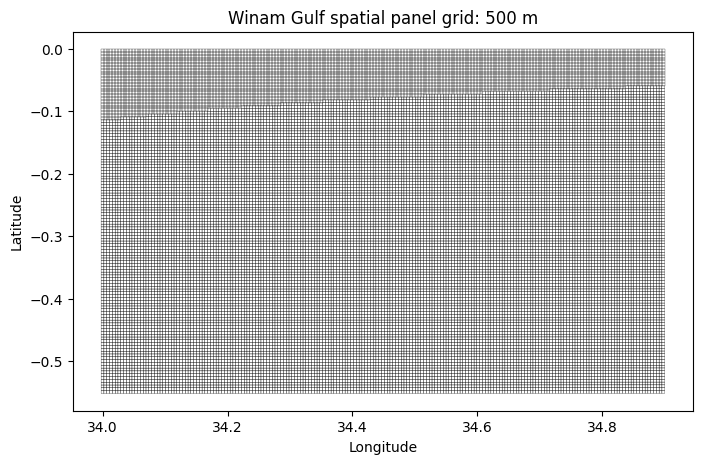

In [37]:
grid = create_grid_from_bbox(AOI_BBOX_WGS84, CELL_SIZE_M, PANEL_CRS)

print(f"Created {len(grid):,} grid cells at {CELL_SIZE_M} m resolution.")
display(grid.head())

grid_path_gpkg = OUTPUT_DIR / f"winam_grid_{CELL_SIZE_M}m.gpkg"
grid_path_geojson = OUTPUT_DIR / f"winam_grid_{CELL_SIZE_M}m.geojson"

grid.to_file(grid_path_gpkg, layer="grid", driver="GPKG")
grid.to_crs("EPSG:4326").to_file(grid_path_geojson, driver="GeoJSON")

print("Saved grid to:")
print(grid_path_gpkg)
print(grid_path_geojson)

ax = grid.to_crs("EPSG:4326").plot(figsize=(8, 6), facecolor="none", edgecolor="black", linewidth=0.2)
ax.set_title(f"Winam Gulf spatial panel grid: {CELL_SIZE_M} m")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 6b. Bathymetry, water mask, and neighbour graph

Samples per-cell **depth** from the Lake Victoria analytical bathymetry raster (also used as the water/littoral mask, since it is clipped to the lake shoreline) and builds the **queen/rook neighbour graph** used by both the neighbour spatial-lag features and the optional **MRF** spatial basis of the §13 GAM (`GAM_SPATIAL_BASIS="mrf"`, change 2).

In [38]:
# ---------------------------------------------------------------------
# Bathymetry covariate, water/littoral mask inputs, and neighbour graph
# ---------------------------------------------------------------------
# Adds three grid-level structures used downstream:
#   - depth_m / bathy_water_fraction : sampled from the Lake Victoria analytical
#     bathymetry raster. Depth is a static habitat covariate; because the raster
#     is clipped to the lake shoreline, the per-cell valid-pixel fraction is also
#     used as the water/littoral mask (Priority 1).
#   - grid_neighbours : queen/rook contiguity edge list for the neighbour
#     spatial-lag features (Priority 3).
# depth_m and bathy_water_fraction are attached to `grid`, so they flow into the
# panel through the existing grid-attribute merge in section 7.

grid_neighbours = None
if NEIGHBOUR_LAG_ENABLED:
    grid_neighbours = build_grid_neighbours(grid, CELL_SIZE_M, contiguity=NEIGHBOUR_CONTIGUITY)
    _deg = grid_neighbours.groupby("grid_id").size()
    print(f"Neighbour graph ({NEIGHBOUR_CONTIGUITY}): {len(grid_neighbours):,} directed edges, "
          f"mean degree {_deg.mean():.2f} over {grid['grid_id'].nunique():,} cells.")
else:
    print("Neighbour spatial-lag features disabled (NEIGHBOUR_LAG_ENABLED = False).")

# Bathymetry sampling (graceful if the raster is missing, so the notebook still runs).
for _col in ("depth_m", "bathy_water_fraction"):
    if _col in grid.columns:
        grid = grid.drop(columns=_col)

if BATHYMETRY_RASTER is not None and Path(BATHYMETRY_RASTER).exists():
    try:
        bathy_cov = sample_bathymetry_to_grid(
            grid, BATHYMETRY_RASTER, PANEL_CRS,
            depth_positive_down=BATHYMETRY_DEPTH_POSITIVE_DOWN,
            resampling=BATHYMETRY_RESAMPLING,
        )
        grid = grid.merge(bathy_cov[["grid_id", "depth_m", "bathy_water_fraction"]],
                          on="grid_id", how="left")
        _have = grid["depth_m"].notna()
        print(f"\nBathymetry sampled for {int(_have.sum()):,}/{len(grid):,} cells "
              f"({100 * _have.mean():.0f}% contain lake pixels).")
        print(f"  depth_m (m):            min {grid.loc[_have,'depth_m'].min():.1f}, "
              f"median {grid.loc[_have,'depth_m'].median():.1f}, "
              f"max {grid.loc[_have,'depth_m'].max():.1f}")
        print(f"  cells >= MIN_WATER_FRACTION ({MIN_WATER_FRACTION:g}): "
              f"{int((grid['bathy_water_fraction'] >= MIN_WATER_FRACTION).sum()):,}")
    except Exception as exc:
        grid["depth_m"] = np.nan
        grid["bathy_water_fraction"] = np.nan
        print(f"\nBathymetry sampling failed ({type(exc).__name__}: {exc}); "
              "depth_m / bathy_water_fraction set to NaN.")
else:
    grid["depth_m"] = np.nan
    grid["bathy_water_fraction"] = np.nan
    print(f"\nNo bathymetry raster found at BATHYMETRY_RASTER={BATHYMETRY_RASTER}.")
    print("Upload Lake_Victoria_Analytical_ras.tif and point BATHYMETRY_RASTER at it to "
          "enable the depth covariate and the bathymetry water mask.")

display(grid[["grid_id", "x_km", "y_km", "depth_m", "bathy_water_fraction"]].head())


Neighbour graph (queen): 194,242 directed edges, mean degree 7.92 over 24,522 cells.

Bathymetry sampled for 10,337/24,522 cells (42% contain lake pixels).
  depth_m (m):            min 0.0, median 5.5, max 48.0
  cells >= MIN_WATER_FRACTION (0.5): 9,780


,grid_id,x_km,y_km,depth_m,bathy_water_fraction
0,0,611.25,9939.25,35.428781,1.0
1,1,611.25,9939.75,32.503119,1.0
2,2,611.25,9940.25,29.549988,1.0
3,3,611.25,9940.75,26.254183,1.0
4,4,611.25,9941.25,23.285784,1.0


## 7. Aggregate classifier-output WH rasters to the grid

This is the main preprocessing step.

For every selected classifier GeoTIFF, the notebook calculates, for each grid cell:

- valid classified pixel count;
- WH / floating-plant pixel count using `WH_CLASS_VALUES`;
- valid classified area;
- WH area;
- WH proportional cover.

The result is a `grid_id × month` panel with source classifier metadata retained for auditability.


In [39]:
# =====================================================================
# Consolidated panel_raw checkpoint (Drive). Collapses the Section 7
# per-raster reduction loop into one Parquet read on later runs / fresh
# runtimes. Place immediately ABOVE the "## 7. Aggregate ... grid" cell.
# =====================================================================
PANEL_RAW_CHECKPOINT_DIR = OUTPUT_DIR / "panel_checkpoints"
PANEL_RAW_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PANEL_RAW_FORCE_REFRESH = False   # set True to rebuild panel_raw from the rasters

def _panel_raw_fingerprint():
    """Hash everything that defines panel_raw -- and nothing about model tuning."""
    recs = []
    for r in tif_index.itertuples(index=False):
        p = Path(str(r.path))
        pp = getattr(r, "proba_path", None)
        pp = None if (pp is None or (isinstance(pp, float) and pd.isna(pp))
                      or str(pp).strip() in ("", "None", "nan")) else str(pp)
        rec = {"path": str(p),
               "mtime": p.stat().st_mtime_ns if p.exists() else None,
               "size": p.stat().st_size if p.exists() else None,
               "proba": pp}
        if pp and Path(pp).exists():
            rec["proba_mtime"] = Path(pp).stat().st_mtime_ns
            rec["proba_size"] = Path(pp).stat().st_size
        recs.append(rec)
    recs.sort(key=lambda d: d["path"])
    payload = {
        "rasters": recs,
        "cell_size_m": CELL_SIZE_M, "panel_crs": PANEL_CRS,
        "aoi_bbox_wgs84": list(AOI_BBOX_WGS84),
        "n_grid_cells": int(grid["grid_id"].nunique()),
        "grid_bounds": [float(x) for x in grid.total_bounds],
        "wh_class_values": list(WH_CLASS_VALUES),
        "extra_nodata_values": list(EXTRA_NODATA_VALUES),
        "valid_class_values": list(VALID_CLASS_VALUES),
        "use_probability_response": bool(USE_PROBABILITY_RESPONSE),
        "proba_nodata_value": PROBA_NODATA_VALUE, "proba_scale": PROBA_SCALE,
        "sensor_filter": sorted(CLASSIFIER_SENSOR_FILTER) if CLASSIFIER_SENSOR_FILTER else None,
        # Provenance is part of the identity of panel_raw: a checkpoint built
        # from a different classifier run, export schema or run log must never be
        # reloaded in place of this one.
        "classifier_version": ACTIVE_CLASSIFIER_VERSION,
        "classifier_run_log": str(CLASSIFIER_RUN_LOG_PATH),
        "export_tokens": dict(sorted(REQUIRED_EXPORT_TOKEN_BY_SENSOR.items())),
        "classified_prefixes": dict(sorted(REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.items())),
        "product_filter": CLASSIFIER_PRODUCT_FILTER,
        "prefer_patch_cleaned_s1": bool(PREFER_PATCH_CLEANED_S1),
        "supplement_run_log_with_folder": bool(SUPPLEMENT_RUN_LOG_WITH_FOLDER),
    }
    return hashlib.sha256(json.dumps(payload, sort_keys=True, default=str).encode()).hexdigest()[:20]

PANEL_RAW_CKPT_PATH = PANEL_RAW_CHECKPOINT_DIR / f"panel_raw_{_panel_raw_fingerprint()}.parquet"

PANEL_RAW_FROM_CHECKPOINT = False
if PANEL_RAW_CKPT_PATH.exists() and not PANEL_RAW_FORCE_REFRESH:
    panel_raw = pd.read_parquet(PANEL_RAW_CKPT_PATH)
    panel_raw["month"] = pd.to_datetime(panel_raw["month"])
    validate_panel_provenance(panel_raw, context=f"panel_raw checkpoint {PANEL_RAW_CKPT_PATH.name}")
    PANEL_RAW_FROM_CHECKPOINT = True
    print(f"Loaded panel_raw from checkpoint ({len(panel_raw):,} rows): {PANEL_RAW_CKPT_PATH.name}")
    print(f"-> Provenance validated: {ACTIVE_CLASSIFIER_VERSION}")
    print("-> Skipping the Section 7 raster-to-grid reduction loop.")
else:
    print("No matching panel_raw checkpoint -- the reduction loop will run, then cache its result.")

No matching panel_raw checkpoint -- the reduction loop will run, then cache its result.


In [40]:
if not PANEL_RAW_FROM_CHECKPOINT:
    panel_parts = []
    # Provenance carried onto every panel row as source_* columns, so a built
    # panel can be re-validated without the run log (validate_panel_provenance).
    metadata_cols = PANEL_SOURCE_METADATA_COLUMNS

    for row in tqdm(tif_index.itertuples(index=False), total=len(tif_index)):
        proba_path = getattr(row, "proba_path", None)
        use_proba = (USE_PROBABILITY_RESPONSE and proba_path is not None
                    and not (isinstance(proba_path, float) and pd.isna(proba_path))
                    and str(proba_path).strip() not in ("", "None", "nan")
                    and Path(str(proba_path)).exists())
        cache_path = None
        df = None
        if USE_GRIDDED_RASTER_CACHE and not GRIDDED_RASTER_FORCE_REFRESH:
            cache_path = _gridded_raster_cache_path(
                row.path, row.month, sensor=getattr(row, "sensor", None),
                proba_path=str(proba_path) if use_proba else None,
            )
            df = load_cached_gridded_raster(cache_path)
        if df is None:
            df = aggregate_one_raster_to_grid(
                tif_path=row.path,
                month=row.month,
                grid_gdf=grid,
                panel_crs=PANEL_CRS,
                wh_class_values=WH_CLASS_VALUES,
                extra_nodata_values=EXTRA_NODATA_VALUES,
                valid_class_values=VALID_CLASS_VALUES,
            )
            if len(df) > 0 and use_proba:
                try:
                    soft = aggregate_one_proba_raster_to_grid(
                        class_path=row.path,
                        proba_path=str(proba_path),
                        month=row.month,
                        grid_gdf=grid,
                        panel_crs=PANEL_CRS,
                        wh_class_values=WH_CLASS_VALUES,
                        extra_nodata_values=EXTRA_NODATA_VALUES,
                        valid_class_values=VALID_CLASS_VALUES,
                        proba_nodata_value=PROBA_NODATA_VALUE,
                        proba_scale=PROBA_SCALE,
                    )
                    if len(soft) > 0:
                        df = df.merge(soft, on="grid_id", how="left")
                except Exception as exc:
                    print(f"  proba aggregation skipped for {Path(row.path).name}: "
                          f"{type(exc).__name__}: {exc}")
            if len(df) > 0 and USE_GRIDDED_RASTER_CACHE:
                cache_path = _gridded_raster_cache_path(
                    row.path, row.month, sensor=getattr(row, "sensor", None),
                    proba_path=str(proba_path) if use_proba else None,
                )
                save_cached_gridded_raster(df, cache_path)
        if len(df) > 0:
            row_dict = row._asdict()
            stamp_source_metadata(df, row_dict, metadata_cols)
            # Clean per-observation sensor tag (S2/S1) for the Section 7b fusion; the
            # joined-string source_sensor is kept for provenance. Defaults to the
            # primary sensor if discovery could not determine it (folder fallback).
            df["sensor"] = _normalise_classifier_sensor(row_dict.get("sensor")) or PRIMARY_SENSOR
            panel_parts.append(df)

    if len(panel_parts) == 0:
        raise RuntimeError("No panel rows were created. Check raster CRS, AOI, class codes and no-data settings.")

    panel_raw = pd.concat(panel_parts, ignore_index=True)
    validate_panel_provenance(panel_raw, context="panel_raw built from the classified rasters")

    print(f"Raw panel rows before duplicate-month handling: {len(panel_raw):,}")
display(panel_raw.head())


  0%|          | 0/372 [00:00<?, ?it/s]

Raw panel rows before duplicate-month handling: 2,187,740


,grid_id,month,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,wh_cover_soft,wh_conf_mean,source_sensor,source_product,source_start_date,source_end_date,source_run_log,source_classifier_version,source_export_token,source_from_directory_scan,sensor
0,20232,2017-04-01,60,0,6000.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,0.0,NaN,S2,model,2017-04-02,2017-04-03,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,S2
1,20354,2017-04-01,807,0,80700.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,0.0,NaN,S2,model,2017-04-02,2017-04-03,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,S2
2,20476,2017-04-01,474,0,47400.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,0.0,NaN,S2,model,2017-04-02,2017-04-03,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,S2
3,21648,2017-04-01,72,0,7200.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,0.0,NaN,S2,model,2017-04-02,2017-04-03,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,S2
4,21649,2017-04-01,200,0,20000.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,0.0,NaN,S2,model,2017-04-02,2017-04-03,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,S2


In [41]:
if not PANEL_RAW_FROM_CHECKPOINT:
    panel_raw.to_parquet(PANEL_RAW_CKPT_PATH, index=False)
    print(f"Saved panel_raw checkpoint: {PANEL_RAW_CKPT_PATH}")

Saved panel_raw checkpoint: /content/drive/MyDrive/WH_spatial_panel_test/panel_checkpoints/panel_raw_2de70f7f7cf020db92cb.parquet


### Combine duplicate observations within the same month

If the classifier output has only one selected raster per month, this step will not change much.

If there are multiple selected snapshots in the same month, the default behaviour is to take the **mean** grid-cell WH cover/area across those rasters. You can change this to `max` in the configuration cell.


In [42]:
if DUPLICATE_MONTH_METHOD not in {"mean", "max"}:
    raise ValueError("DUPLICATE_MONTH_METHOD must be either 'mean' or 'max'.")

source_agg = lambda x: "; ".join(sorted(set(map(str, x.dropna()))))
source_metadata_cols = [c for c in panel_raw.columns if c.startswith("source_")]

# Reduce duplicates WITHIN each sensor (e.g. several S2 snapshots in one month),
# but keep S1 and S2 as SEPARATE observations of the same cell-month so they can
# be harmonised -- not blended -- in the Section 7b cloud-gap-fill fusion.
agg_funcs = {
    "valid_pixels": DUPLICATE_MONTH_METHOD,
    "wh_pixels": DUPLICATE_MONTH_METHOD,
    "valid_area_m2": DUPLICATE_MONTH_METHOD,
    "wh_area_m2": DUPLICATE_MONTH_METHOD,
    "wh_cover": DUPLICATE_MONTH_METHOD,
    "source_file": source_agg,
}
for col in source_metadata_cols:
    agg_funcs[col] = source_agg

# Carry the confidence-weighted response columns through the monthly aggregation.
for _soft_col in ["wh_cover_soft", "wh_conf_mean"]:
    if _soft_col in panel_raw.columns:
        agg_funcs[_soft_col] = "mean"

# Ensure every observation carries a sensor tag (defensive for folder fallback).
if "sensor" not in panel_raw.columns:
    panel_raw["sensor"] = PRIMARY_SENSOR
panel_raw["sensor"] = panel_raw["sensor"].fillna(PRIMARY_SENSOR)

panel_sensor = (
    panel_raw
    .groupby(["grid_id", "month", "sensor"], as_index=False)
    .agg(agg_funcs)
)

# Retain only minimally valid cell-months (per sensor).
panel_sensor = panel_sensor[panel_sensor["valid_pixels"] >= MIN_VALID_PIXELS_PER_CELL_MONTH].copy()

# Basic response variables (per sensor).
panel_sensor["wh_area_ha"] = panel_sensor["wh_area_m2"] / 10_000
panel_sensor["valid_area_ha"] = panel_sensor["valid_area_m2"] / 10_000
# Fractional valid coverage of the nominal cell area (1.0 == fully observed).
panel_sensor["valid_fraction"] = (panel_sensor["valid_area_m2"] / (CELL_SIZE_M ** 2)).clip(upper=1.0)

# --- Confidence-weighted (probabilistic) response per sensor (Priority 2) -----
# Keep hard-class cover/area for reference, then -- if enabled and available --
# swap the modelling response to the confidence-weighted cover (same rule as
# before, now applied within each sensor so S1 keeps its own soft response).
panel_sensor["wh_cover_hard"] = panel_sensor["wh_cover"]
panel_sensor["wh_area_ha_hard"] = panel_sensor["wh_area_ha"]
if (USE_PROBABILITY_RESPONSE and "wh_cover_soft" in panel_sensor.columns
        and panel_sensor["wh_cover_soft"].notna().any()):
    panel_sensor["wh_cover"] = panel_sensor["wh_cover_soft"].where(
        panel_sensor["wh_cover_soft"].notna(), panel_sensor["wh_cover_hard"])
    panel_sensor["wh_area_m2"] = panel_sensor["wh_cover"] * panel_sensor["valid_area_m2"]
    panel_sensor["wh_area_ha"] = panel_sensor["wh_area_m2"] / 10_000
    print("Response: CONFIDENCE-WEIGHTED WH cover per sensor "
          "(USE_PROBABILITY_RESPONSE=True); hard-class cover retained as wh_cover_hard.")
else:
    print("Response: HARD-CLASS WH cover per sensor (probability rasters unavailable or disabled).")

# Presence-definition label. Presence itself is computed ONCE on the merged panel
# in Section 7b (after the S1 gap-fill), so it is defined in a single place.
if PRESENCE_AREA_HA_THRESHOLD is not None:
    presence_definition = f"wh_area_ha >= {PRESENCE_AREA_HA_THRESHOLD} ha"
else:
    presence_definition = f"wh_cover >= {PRESENCE_COVER_THRESHOLD:g} (fractional cover)"

print(f"\nPer-sensor panel rows (before fusion): {len(panel_sensor):,}")
_per_sensor = panel_sensor.groupby("sensor").agg(
    cell_months=("grid_id", "size"),
    months=("month", "nunique"),
    cells=("grid_id", "nunique"),
    mean_cover=("wh_cover", "mean"),
).reset_index()
display(_per_sensor)
display(panel_sensor.head())

Response: CONFIDENCE-WEIGHTED WH cover per sensor (USE_PROBABILITY_RESPONSE=True); hard-class cover retained as wh_cover_hard.

Per-sensor panel rows (before fusion): 590,737


,sensor,cell_months,months,cells,mean_cover
0,S2,590737,96,6446,0.00653


,grid_id,month,sensor,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_run_log,source_classifier_version,source_export_token,source_from_directory_scan,wh_cover_soft,wh_conf_mean,wh_area_ha,valid_area_ha,valid_fraction,wh_cover_hard,wh_area_ha_hard
0,5640,2017-06-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,S2,model,2017-06-11,2017-06-12,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0
1,5640,2018-12-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2018-...,S2,model,2018-12-28,2018-12-29,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0
2,5640,2019-01-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-01-02; 2019-01-07; 2019-01-12; 2019-01-17...,2019-01-03; 2019-01-08; 2019-01-13; 2019-01-18...,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0
3,5640,2019-02-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-02-01; 2019-02-26,2019-02-02; 2019-02-27,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0
4,5640,2019-03-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-03-03; 2019-03-08; 2019-03-13; 2019-03-18...,2019-03-04; 2019-03-09; 2019-03-14; 2019-03-19...,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0


## 7b. Sentinel-1 cloud-gap-fill fusion (prefer-S2, gap-fill-S1) — Task 1

This section turns the per-sensor panel into a single harmonised response:

1. **Agreement (1b):** on cell-months observed by *both* sensors, report mean/median bias `S1 − S2`, Pearson & Spearman correlation, a Bland–Altman plot, and a presence confusion matrix at the current presence definition.
2. **Calibration (1c):** fit `S2_cover ~ S1_cover` on the overlap (Theil–Sen robust-linear by default; isotonic optional) and apply it to S1-only cell-months, so S1 enters on the S2 measurement scale.
3. **Merge (1d):** build `panel` by **preferring S2** and gap-filling with calibrated S1 *only where S2 is missing* for that cell-month. A `sensor` label and a numeric `sensor_is_s1` indicator are carried so any residual cross-sensor offset is absorbed by the model rather than attributed to a driver.

The MNAR payoff (1e) — whether the S1 fills concentrate in high-rainfall months — is reported in Section 9b, once the CHIRPS rainfall covariate has been merged.


In [43]:
# Harmonise the per-sensor panel into a single cloud-gap-filled response.
PRIMARY = PRIMARY_SENSOR
SECONDARY = "S1" if PRIMARY == "S2" else "S2"

available_sensors = sorted(s for s in panel_sensor["sensor"].dropna().unique().tolist())
print("Sensors present in the per-sensor panel:", available_sensors)

prim = panel_sensor[panel_sensor["sensor"] == PRIMARY].copy()
sec = panel_sensor[panel_sensor["sensor"] == SECONDARY].copy()

# Month-coverage BEFORE fusion (primary sensor only) -- the "before" acceptance.
cov_before_cellmonths = int(len(prim))
cov_before_months = int(prim["month"].nunique())

do_fusion = bool(ENABLE_S1_GAPFILL and len(prim) > 0 and len(sec) > 0)
calib_info = {"method": "disabled"}

if not do_fusion:
    base = prim if len(prim) > 0 else panel_sensor.copy()
    panel = base.copy()
    if "sensor" not in panel.columns:
        panel["sensor"] = PRIMARY
    panel["sensor_is_s1"] = (panel["sensor"] == "S1").astype(int)
    panel["wh_cover_raw_sensor"] = panel["wh_cover"]
    print(f"\nS1 gap-fill disabled or unavailable -- using {PRIMARY} only "
          f"({cov_before_cellmonths:,} cell-months, {cov_before_months} months).")
else:
    # ---- (1b) Cross-sensor agreement on overlap cell-months -----------------
    overlap = sensor_overlap_frame(panel_sensor, "wh_cover", PRIMARY, SECONDARY)
    prim_c = overlap[f"wh_cover_{PRIMARY}"]
    sec_c = overlap[f"wh_cover_{SECONDARY}"]
    stats = sensor_agreement_stats(prim_c, sec_c)
    print("\n--- (1b) S1 vs S2 agreement on overlap cell-months ---")
    print(f"Overlap cell-months (both sensors valid): {stats['n_pairs']:,}")
    print(f"mean(S1 - S2) cover = {stats['mean_sec_minus_prim']:+.4f}   "
          f"median = {stats['median_sec_minus_prim']:+.4f}")
    print(f"Pearson r = {stats['pearson_r']:.3f}   Spearman r = {stats['spearman_r']:.3f}")

    if stats["n_pairs"] > 0:
        prim_pres = wh_presence_from_cover(overlap[f"wh_cover_{PRIMARY}"],
                                           overlap[f"wh_area_ha_{PRIMARY}"]).astype(int)
        sec_pres = wh_presence_from_cover(overlap[f"wh_cover_{SECONDARY}"],
                                          overlap[f"wh_area_ha_{SECONDARY}"]).astype(int)
        cm = confusion_matrix(prim_pres, sec_pres, labels=[0, 1])
        print(f"\nPresence confusion (rows = S2 obs, cols = S1 obs; {presence_definition}):")
        display(pd.DataFrame(cm, index=["S2_absent", "S2_present"],
                             columns=["S1_absent", "S1_present"]))
        _agree = float(np.trace(cm) / cm.sum()) if cm.sum() else np.nan
        print(f"Overall presence agreement: {_agree:.3f}")

        # Bland-Altman: difference vs mean of the two sensors' cover.
        m = (prim_c.to_numpy() + sec_c.to_numpy()) / 2.0
        d = sec_c.to_numpy() - prim_c.to_numpy()
        md, sd = float(np.nanmean(d)), float(np.nanstd(d))
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.scatter(m, d, s=8, alpha=0.3)
        ax.axhline(md, color="red", label=f"mean {md:+.3f}")
        ax.axhline(md + 1.96 * sd, color="grey", ls="--", label=f"+1.96sd {md + 1.96 * sd:+.3f}")
        ax.axhline(md - 1.96 * sd, color="grey", ls="--", label=f"-1.96sd {md - 1.96 * sd:+.3f}")
        ax.set_xlabel("Mean of S1 and S2 WH cover")
        ax.set_ylabel("S1 - S2 WH cover")
        ax.set_title("Bland-Altman: S1 vs S2 WH cover (overlap cell-months)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.show()

    # ---- (1c) Calibrate S1 cover onto the S2 scale --------------------------
    calib_f, calib_info = fit_secondary_to_primary_calibration(
        sec_c.to_numpy(), prim_c.to_numpy(),
        method=S1_CALIBRATION_METHOD, random_state=RANDOM_STATE)
    print("\n--- (1c) S1 -> S2 cover calibration ---")
    print(f"Calibration: {calib_info}")

    # ---- (1d) Merge: prefer S2, gap-fill with calibrated S1 -----------------
    prim_keep = prim.copy()
    prim_keep["sensor"] = PRIMARY
    prim_keep["sensor_is_s1"] = 0
    prim_keep["wh_cover_raw_sensor"] = prim_keep["wh_cover"]

    sec_idx = sec.set_index(["grid_id", "month"])
    prim_index = prim_keep.set_index(["grid_id", "month"]).index
    sec_fill = sec_idx.loc[~sec_idx.index.isin(prim_index)].reset_index()
    sec_fill["sensor"] = SECONDARY
    sec_fill["sensor_is_s1"] = 1
    sec_fill["wh_cover_raw_sensor"] = sec_fill["wh_cover"]
    # Put S1 cover on the S2 scale and recompute its WH area accordingly.
    sec_fill["wh_cover"] = calib_f(sec_fill["wh_cover"].to_numpy())
    sec_fill["wh_area_m2"] = sec_fill["wh_cover"] * sec_fill["valid_area_m2"]
    sec_fill["wh_area_ha"] = sec_fill["wh_area_m2"] / 10_000

    panel = pd.concat([prim_keep, sec_fill], ignore_index=True)
    print("\n--- (1d) Merged response (prefer S2, gap-fill calibrated S1) ---")
    print(f"S2 cell-months kept:            {len(prim_keep):,}")
    print(f"S1 gap-fill cell-months added:  {len(sec_fill):,} "
          f"(S2-missing cell-months recovered by S1)")

# ---- Finalise the merged panel: grid attributes, presence, coverage ---------
# Re-attach the static grid attributes (coords, depth, water fraction, ...).
panel = panel.drop(
    columns=[c for c in grid.columns if c not in ("grid_id", "geometry") and c in panel.columns],
    errors="ignore")
panel = panel.merge(grid.drop(columns="geometry"), on="grid_id", how="left")
panel = panel.sort_values(["grid_id", "month"]).reset_index(drop=True)
if "sensor_is_s1" not in panel.columns:
    panel["sensor_is_s1"] = 0
panel["wh_present"] = wh_presence_from_cover(panel["wh_cover"], panel.get("wh_area_ha"))

# Month-coverage AFTER fusion -- the "after" acceptance.
cov_after_cellmonths = int(len(panel))
cov_after_months = int(panel["month"].nunique())
print("\n--- Panel month-coverage: BEFORE vs AFTER S1 gap-fill ---")
print(f"Before (S2 only):      {cov_before_cellmonths:,} cell-months, {cov_before_months} months")
print(f"After  (S2 + S1 fill): {cov_after_cellmonths:,} cell-months, {cov_after_months} months")
_gain = cov_after_cellmonths - cov_before_cellmonths
if cov_before_cellmonths:
    print(f"Net cell-months recovered by S1: {_gain:,} "
          f"({_gain / cov_before_cellmonths * 100:.1f}% of the S2-only panel)")
if "sensor" in panel.columns:
    print("\nCell-months by response sensor:")
    display(panel.groupby("sensor").size().rename("n_cell_months").reset_index())

# Per-month coverage comparison (S2 cells vs S1-filled cells vs merged cells).
_cov_by_month = (panel.groupby("month")
                 .agg(merged_cells=("grid_id", "nunique"),
                      s1_filled_cells=("sensor_is_s1", "sum")).reset_index())
_s2_by_month = prim.groupby("month")["grid_id"].nunique().rename("s2_cells")
_cov_by_month = _cov_by_month.merge(_s2_by_month, on="month", how="left")
_cov_by_month["s2_cells"] = _cov_by_month["s2_cells"].fillna(0).astype(int)
_cov_by_month = _cov_by_month[["month", "s2_cells", "s1_filled_cells", "merged_cells"]]
print("\nPer-month coverage (S2 cells vs S1-filled cells vs merged cells):")
display(_cov_by_month)

print(f"\nWH presence defined as: {presence_definition}")
print(f"Overall WH-present prevalence (merged panel): {panel['wh_present'].mean():.4f} "
      f"({int(panel['wh_present'].sum()):,} of {len(panel):,} cell-months)")
display(panel.head())


Sensors present in the per-sensor panel: ['S2']

S1 gap-fill disabled or unavailable -- using S2 only (590,737 cell-months, 96 months).

--- Panel month-coverage: BEFORE vs AFTER S1 gap-fill ---
Before (S2 only):      590,737 cell-months, 96 months
After  (S2 + S1 fill): 590,737 cell-months, 96 months
Net cell-months recovered by S1: 0 (0.0% of the S2-only panel)

Cell-months by response sensor:


,sensor,n_cell_months
0,S2,590737



Per-month coverage (S2 cells vs S1-filled cells vs merged cells):


,month,s2_cells,s1_filled_cells,merged_cells
0,2017-04-01,277,0,277
1,2017-05-01,220,0,220
2,2017-06-01,6246,0,6246
3,2017-10-01,277,0,277
4,2018-05-01,274,0,274
...,...,...,...,...
91,2026-03-01,6446,0,6446
92,2026-04-01,6197,0,6197
93,2026-05-01,6446,0,6446
94,2026-06-01,6446,0,6446



WH presence defined as: wh_cover >= 0.02 (fractional cover)
Overall WH-present prevalence (merged panel): 0.0384 (22,712 of 590,737 cell-months)


,grid_id,month,sensor,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_run_log,source_classifier_version,source_export_token,source_from_directory_scan,wh_cover_soft,wh_conf_mean,wh_area_ha,valid_area_ha,valid_fraction,wh_cover_hard,wh_area_ha_hard,sensor_is_s1,wh_cover_raw_sensor,x_km,y_km,cell_area_m2,depth_m,bathy_water_fraction,wh_present
0,5640,2017-06-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,S2,model,2017-06-11,2017-06-12,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False
1,5640,2018-12-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2018-...,S2,model,2018-12-28,2018-12-29,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False
2,5640,2019-01-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-01-02; 2019-01-07; 2019-01-12; 2019-01-17...,2019-01-03; 2019-01-08; 2019-01-13; 2019-01-18...,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False
3,5640,2019-02-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-02-01; 2019-02-26,2019-02-02; 2019-02-27,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False
4,5640,2019-03-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-03-03; 2019-03-08; 2019-03-13; 2019-03-18...,2019-03-04; 2019-03-09; 2019-03-14; 2019-03-19...,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False


### Sensitivity of the WH-present definition to the chosen threshold

The response variable depends strongly on how "present" is defined. The table
below shows how the number of positive cell-months, the positive rate, the mean
WH signal among positives, and the number of months with at least one positive
cell change as the fractional-cover presence threshold is varied. Threshold `0`
reproduces the original "any non-zero WH pixel" definition.


In [44]:
presence_threshold_grid = [0, 0.001, 0.005, 0.01, 0.02, 0.05]

sensitivity_rows = []
for thr in presence_threshold_grid:
    # thr == 0 reproduces the original "any non-zero WH" definition.
    present = panel["wh_cover"] > 0 if thr == 0 else panel["wh_cover"] >= thr
    n_pos = int(present.sum())
    sensitivity_rows.append({
        "cover_threshold": thr,
        "n_positive_cell_months": n_pos,
        "pct_positive": round(100 * present.mean(), 3),
        "mean_cover_among_pos": round(panel.loc[present, "wh_cover"].mean(), 4) if n_pos else np.nan,
        "mean_area_ha_among_pos": round(panel.loc[present, "wh_area_ha"].mean(), 4) if n_pos else np.nan,
        "n_months_with_positive": int(panel.loc[present, "month"].nunique()),
    })

presence_sensitivity = pd.DataFrame(sensitivity_rows)
print("Sensitivity of WH-present prevalence to the cover threshold:")
display(presence_sensitivity)


Sensitivity of WH-present prevalence to the cover threshold:


,cover_threshold,n_positive_cell_months,pct_positive,mean_cover_among_pos,mean_area_ha_among_pos,n_months_with_positive
0,0.000,148282,25.101,0.0260,0.5434,96
1,0.001,82154,13.907,0.0467,0.9752,96
2,0.005,44861,7.594,0.0835,1.7449,96
3,0.010,32255,5.460,0.1133,2.3721,95
4,0.020,22712,3.845,0.1550,3.2541,95
5,0.050,14364,2.432,0.2268,4.7816,95


## Classifier accuracy and response measurement error

The response is a classifier output, so its accuracy and per-cell confidence are reported here rather than assumed perfect (Priority 2).

In [45]:
# ---------------------------------------------------------------------
# Classifier accuracy and response measurement-error (Priority 2)
# ---------------------------------------------------------------------
# The panel response is itself a classifier output, so its error should be
# surfaced rather than treated as ground truth. This cell (a) reports any
# cross-validation accuracy metrics the classifier notebook logged, and (b)
# summarises the per-cell classification confidence and the hard-vs-soft cover
# agreement, which quantify the measurement error entering the response.

# (a) Classifier CV accuracy metrics, if the classifier notebook saved a table.
_metric_tables = []
try:
    for _patt in ("*model_selection*metrics*.csv", "*metrics*.csv", "*cv*metrics*.csv",
                  "*_metrics_*.csv"):
        _metric_tables += list(Path(CLASSIFIER_TABLE_DIR).glob(_patt))
except Exception:
    pass
_metric_tables = sorted(set(_metric_tables), key=lambda p: p.stat().st_mtime if p.exists() else 0)
if _metric_tables:
    _mt = _metric_tables[-1]
    print(f"Classifier accuracy metrics from: {_mt.name}")
    try:
        _mdf = pd.read_csv(_mt)
        _show = [c for c in ["sensor", "model", "method", "accuracy", "balanced_accuracy",
                             "kappa", "macro_f1", "weighted_f1"] if c in _mdf.columns]
        display(_mdf[_show] if _show else _mdf.head())
    except Exception as exc:
        print("  could not read metrics table:", exc)
else:
    print("No classifier CV-metrics CSV found in CLASSIFIER_TABLE_DIR.")
    print("  (Look for the model-selection metrics exported by "
          "Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb; accuracy/kappa/macro-F1 "
          "should be quoted alongside these panel results.)")

# (b) Response confidence + hard-vs-soft agreement, from the panel.
if "wh_conf_mean" in panel.columns and panel["wh_conf_mean"].notna().any():
    _c = panel["wh_conf_mean"].dropna()
    print(f"\nPer-cell WH classification confidence (winning-class P over WH pixels), "
          f"n={len(_c):,}:")
    display(_c.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(3))
    _low = (_c < 0.6).mean()
    print(f"Share of WH-bearing cell-months with mean confidence < 0.60: {_low:.1%} "
          "(these contribute most of the response measurement error).")
else:
    print("\nNo per-cell confidence available (probability rasters not aggregated).")

if {"wh_cover_hard", "wh_cover_soft"}.issubset(panel.columns) and panel["wh_cover_soft"].notna().any():
    _m = panel[["wh_cover_hard", "wh_cover_soft"]].dropna()
    if len(_m) > 2:
        _corr = _m["wh_cover_hard"].corr(_m["wh_cover_soft"])
        _bias = (_m["wh_cover_soft"] - _m["wh_cover_hard"]).mean()
        print(f"\nHard vs confidence-weighted cover: r={_corr:.3f}, "
              f"mean(soft - hard)={_bias:+.4f} "
              f"(soft is typically slightly lower, having down-weighted low-confidence WH pixels).")
        _ha = panel["valid_area_m2"]
        _area_hard = float((panel["wh_cover_hard"] * _ha / 1e4).sum())
        _area_soft = float((panel["wh_cover_soft"].fillna(panel["wh_cover_hard"]) * _ha / 1e4).sum())
        print(f"Panel-total WH area: hard={_area_hard:,.0f} ha, "
              f"confidence-weighted={_area_soft:,.0f} ha "
              f"({_area_soft / _area_hard:.0%} of hard).")
        print(f"Modelling response in use: "
              f"{'confidence-weighted (soft)' if USE_PROBABILITY_RESPONSE else 'hard-class'} cover.")
else:
    print("\nConfidence-weighted cover not available; the response uses hard-class cover.")


No classifier CV-metrics CSV found in CLASSIFIER_TABLE_DIR.
  (Look for the model-selection metrics exported by Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb; accuracy/kappa/macro-F1 should be quoted alongside these panel results.)

Per-cell WH classification confidence (winning-class P over WH pixels), n=148,282:


,wh_conf_mean
count,148282.000
mean,0.564
std,0.144
min,0.260
10%,0.402
25%,0.457
50%,0.534
75%,0.649
90%,0.781
max,1.000


Share of WH-bearing cell-months with mean confidence < 0.60: 66.2% (these contribute most of the response measurement error).

Hard vs confidence-weighted cover: r=0.988, mean(soft - hard)=-0.0018 (soft is typically slightly lower, having down-weighted low-confidence WH pixels).
Panel-total WH area: hard=101,722 ha, confidence-weighted=80,578 ha (79% of hard).
Modelling response in use: confidence-weighted (soft) cover.


## 8. Earth Engine environmental covariate extraction

This step pulls the environmental driver layers that have usable Google Earth Engine assets and reduces them onto the panel. It runs when `USE_EARTH_ENGINE = True` (configured in section 3) and is wrapped in a `try/except` so the notebook still completes if Earth Engine is unavailable.

Three tables are produced:

| Output | Keyed by | Layers |
| --- | --- | --- |
| `ee_monthly_cov` | `month` | Wind and air temperature **only when `EE_CLIMATE_PER_CELL=False`** (ERA5 u/v/speed/direction/bay-axis; ERA5-Land air temp where it covers the AOI, else ERA5); optional MODIS ocean-colour chlorophyll-a (off by default) |
| `ee_cellmonth_cov` | `grid_id`, `month` | **ERA5(-Land) wind + air temperature per cell** (default, `EE_CLIMATE_PER_CELL=True`); Rainfall (CHIRPS ~5 km, per cell by default: total, antecedent sums, spike counts, Rx1day, wet days, SDII); MODIS LST **water-surface temperature** (~1 km, per cell by default); Sentinel-2 **turbidity** (NDTI + red reflectance) proxy; **Sentinel-3 OLCI chlorophyll-a** (mg/m³) via MCI and MPH band-difference algorithms calibrated per Kravitz et al. (2020); all water-masked |
| `ee_static_cov` | `grid_id` | Distance to rivers and to major (discharge-weighted) rivers (HydroSHEDS), distance to shore and openness (JRC GSW), catchment pressure (ESA WorldCover fractions, WorldPop population, GHSL built-up) |

**Resolution strategy.** The reanalysis climate layers (ERA5 wind ~28 km / ERA5-Land air temperature ~11 km) are extracted **per grid cell and month by default** (`EE_CLIMATE_PER_CELL = True`, change 3a), so their coarse cross-gulf gradient enters the panel instead of a single AOI-mean series that would be spatially constant and therefore perfectly confounded with the seasonal/trend terms. Only a few reanalysis pixels span Winam Gulf, so the added spatial signal is modest and the per-cell reduction is heavier; set `EE_CLIMATE_PER_CELL = False` to revert to AOI-mean monthly series. Air temperature defaults to **ERA5-Land** (~11 km, lapse-rate corrected) where it covers the AOI, falling back to ERA5; wind stays on ERA5, whose 10 m field ERA5-Land only interpolates. MODIS LST water-surface temperature (~1 km) and CHIRPS rainfall (~5 km) -- both per cell by default (`EE_WATER_TEMP_PER_CELL`, `EE_RAIN_PER_CELL`) -- and the Sentinel-2 water-quality proxies (~20 m) are likewise extracted **per grid cell and month**. Static layers are extracted **once per cell**.

**Derived mechanistic interactions.** `wave_exposure_idx` (openness x wind^2, a local physical-disturbance force) and `nutrient_pulse_idx` (antecedent rain x cropland, the storm-fertilisation pulse, entered lagged) are computed from the merged covariates so the disturbance and nutrient mechanisms are encoded explicitly, not left to the main effects alone.

**Sentinel-3 OLCI chlorophyll-a.** GEE's OLCI asset provides only TOA radiances (no geometry/meteorology tie-points), so the best atmospheric corrections in Kravitz et al. (2020) — BRR and 6SV1 — cannot be reproduced inside GEE. Their key result is that the **MCI and MPH band-difference algorithms are robust to atmospheric correction**, and they publish TOA-reflectance calibrations (Table B.1). The notebook therefore computes OLCI TOA reflectance (nominal solar irradiance + analytically reconstructed solar zenith) and retrieves chl-a with **MCI** (their best TOA method, R²=0.53) and **MPH** (best overall, R²=0.55; its BRR calibration is applied to TOA reflectance as a documented approximation). For publication-grade chl-a, process BRR/6SV externally (SNAP / Py6S) and ingest via the CSV hook in section 9.

**Layers that need a CSV instead (no standard EE asset):** lake level (DAHITI / Hydroweb / G-REALM altimetry), ENSO/IOD indices, bathymetry/depth, and in-situ nutrients (TN, TP, DIN, SRP). Supply these through `ENV_MONTHLY_CSV` / `SPATIAL_COVARIATES_CSV` in section 9.

**Caching to Drive.** Earth Engine extraction is the slow step here, so the covariate tables are cached. The first successful run writes them to `EE_CACHE_DIR` (defaults to `OUTPUT_DIR`) alongside a small JSON manifest, and every later run reloads them from Drive instead of querying Earth Engine — so the per-cell reductions only run once per configuration. The cache is keyed by a fingerprint of the settings that change the covariates (cell size, AOI, test period, the panel's month set and the `EE_*` parameters), so it rebuilds automatically when any of those change. Set `EE_FORCE_REFRESH = True` (or delete the `ee_*_covariates_*` files) to force a fresh pull, or `USE_EE_CACHE = False` to bypass the cache entirely.

> The first run on a fresh Colab runtime triggers `ee.Authenticate()`. Per-cell reductions scale with the number of grid cells, so prefer `CELL_SIZE_M = 1000` for Earth Engine test runs, or turn off `waterquality_s2`/`waterquality_s3` in `EE_LAYERS` for the quickest pass.

In [46]:
# Initialise the EE covariate containers so later cells work even when
# USE_EARTH_ENGINE is False or extraction fails.
ee_monthly_cov = None
ee_cellmonth_cov = None
ee_static_cov = None
ee_registry = {"monthly": [], "cellmonth": [], "static": []}

# ---------------------------------------------------------------------
# Drive cache helpers for the Earth Engine covariates
# ---------------------------------------------------------------------
# Earth Engine extraction is the slow step in this notebook. The covariate
# tables are written to EE_CACHE_DIR after the first successful run and reloaded
# on later runs (see USE_EE_CACHE / EE_FORCE_REFRESH in section 3), so the
# per-cell Earth Engine reductions only happen once per configuration. A small
# JSON manifest records which tables exist plus a fingerprint of the settings
# that change the covariates, so the cache is rebuilt automatically when any of
# those settings change.
import hashlib
import json

_EE_CACHE_TAG = f"{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}"
EE_CACHE_PATHS = {
    "monthly":   Path(EE_CACHE_DIR) / f"ee_monthly_covariates_{_EE_CACHE_TAG}.csv",
    "cellmonth": Path(EE_CACHE_DIR) / f"ee_cellmonth_covariates_{_EE_CACHE_TAG}.csv",
    "static":    Path(EE_CACHE_DIR) / f"ee_static_covariates_{_EE_CACHE_TAG}.csv",
}
EE_CACHE_MANIFEST = Path(EE_CACHE_DIR) / f"ee_covariates_cache_manifest_{_EE_CACHE_TAG}.json"


def _ee_cache_signature(months):
    """Fingerprint the configuration that determines the EE covariate values."""
    payload = {
        "cell_size_m": CELL_SIZE_M,
        "panel_crs": PANEL_CRS,
        "aoi_bbox_wgs84": list(AOI_BBOX_WGS84),
        "n_grid_cells": int(grid["grid_id"].nunique()),
        "months": [str(pd.Timestamp(m).date()) for m in months],
        "ee_layers": {k: bool(v) for k, v in EE_LAYERS.items()},
        "ee_s2_products": sorted(EE_S2_PRODUCTS),
        "ee_s3_products": sorted(EE_S3_PRODUCTS),
        "ee_rain_antecedent_days": list(EE_RAIN_ANTECEDENT_DAYS),
        "ee_rain_intensity": bool(EE_RAIN_INTENSITY),
        "ee_rain_spike_thresholds_mm": list(EE_RAIN_SPIKE_THRESHOLDS_MM),
        "ee_rain_wet_day_mm": EE_RAIN_WET_DAY_MM,
        "ee_rain_per_cell": bool(EE_RAIN_PER_CELL),
        "ee_bay_axis_bearing_deg": EE_BAY_AXIS_BEARING_DEG,
        "ee_water_occurrence_threshold": EE_WATER_OCCURRENCE_THRESHOLD,
        "ee_s2_cloud_pct": EE_S2_CLOUD_PCT,
        "ee_climate_aoi_scale": EE_CLIMATE_AOI_SCALE,
        "ee_air_temp_use_era5_land": bool(EE_AIR_TEMP_USE_ERA5_LAND),
        "ee_water_temp_per_cell": bool(EE_WATER_TEMP_PER_CELL),
        "ee_climate_per_cell": bool(globals().get("EE_CLIMATE_PER_CELL", False)),
        "ee_catchment_buffer_m": EE_CATCHMENT_BUFFER_M,
        "ee_river_discharge_weighted": bool(EE_RIVER_DISCHARGE_WEIGHTED),
        "ee_river_major_max_ord": EE_RIVER_MAJOR_MAX_ORD,
        "ee_static_year": EE_STATIC_YEAR,
        "ee_s3_calib": {k: list(v) for k, v in EE_S3_CALIB.items()},
    }
    blob = json.dumps(payload, sort_keys=True, default=str)
    return hashlib.sha256(blob.encode("utf-8")).hexdigest()


def _registry_from_tables(monthly_df, cellmonth_df, static_df):
    """Rebuild the covariate-group registry from cached table columns."""
    return {
        "monthly":   [] if monthly_df is None else [c for c in monthly_df.columns if c != "month"],
        "cellmonth": [] if cellmonth_df is None else [c for c in cellmonth_df.columns if c not in ("grid_id", "month")],
        "static":    [] if static_df is None else [c for c in static_df.columns if c != "grid_id"],
    }


def _read_cached_table(path):
    df = pd.read_csv(path)
    if "month" in df.columns:
        df["month"] = pd.to_datetime(df["month"]).dt.to_period("M").dt.to_timestamp()
    return df


def save_ee_cache(monthly_df, cellmonth_df, static_df, registry, signature,
                  present_groups=None, enabled_groups=None):
    """Write the EE covariate tables and a manifest to EE_CACHE_DIR.

    ``present_groups`` records which covariate groups this cache actually holds
    and ``enabled_groups`` which the configuration asks for. A group that failed
    to build is simply absent from ``present_groups``, so a later run reloads the
    cached groups and re-attempts only the missing ones (see load_ee_cache) rather
    than rebuilding every group. They are omitted from the manifest when unknown
    (legacy caches), which load treats as a complete cache."""
    Path(EE_CACHE_DIR).mkdir(parents=True, exist_ok=True)
    written = {}
    for key, table in (("monthly", monthly_df),
                       ("cellmonth", cellmonth_df),
                       ("static", static_df)):
        path = EE_CACHE_PATHS[key]
        if table is not None and len(table) > 0:
            table.to_csv(path, index=False)
            written[key] = path.name
        elif path.exists():
            path.unlink()  # drop a stale table that no longer applies
    manifest = {
        "signature": signature,
        "tag": _EE_CACHE_TAG,
        "registry": registry,
        "tables": written,
        "created_utc": pd.Timestamp.now(tz="UTC").isoformat(),
    }
    if present_groups is not None:
        manifest["present_groups"] = sorted(present_groups)
    if enabled_groups is not None:
        manifest["enabled_groups"] = sorted(enabled_groups)
    EE_CACHE_MANIFEST.write_text(json.dumps(manifest, indent=2))
    return written


def load_ee_cache(signature):
    """Return (monthly, cellmonth, static, registry, present_groups) or None.

    None means there is no usable cache (no manifest, the configuration changed,
    or a listed file is missing), so the caller re-queries Earth Engine.
    ``present_groups`` is the list of covariate groups the cache holds, or None
    when it is not tracked (legacy caches), in which case the caller treats the
    cache as complete. When an older run exported the CSV tables but not the
    manifest, load those legacy tables instead of re-fetching them; the filenames
    are already scoped by cell size and test period.
    """
    if not EE_CACHE_MANIFEST.exists():
        legacy = {key: (_read_cached_table(path) if path.exists() else None)
                  for key, path in EE_CACHE_PATHS.items()}
        if any(table is not None for table in legacy.values()):
            print("Found cached EE covariate CSVs without a manifest; reusing them and writing a manifest.")
            registry = _registry_from_tables(legacy["monthly"], legacy["cellmonth"], legacy["static"])
            save_ee_cache(legacy["monthly"], legacy["cellmonth"], legacy["static"], registry, signature)
            return legacy["monthly"], legacy["cellmonth"], legacy["static"], registry, None
        return None
    try:
        manifest = json.loads(EE_CACHE_MANIFEST.read_text())
    except (ValueError, OSError):
        return None
    if manifest.get("signature") != signature:
        print("Cached Earth Engine covariates are stale (configuration changed); rebuilding.")
        return None
    tables = manifest.get("tables", {})
    loaded = {"monthly": None, "cellmonth": None, "static": None}
    for key in loaded:
        if key in tables:
            path = EE_CACHE_PATHS[key]
            if not path.exists():
                print(f"Cache manifest lists {path.name} but the file is missing; rebuilding.")
                return None
            loaded[key] = _read_cached_table(path)
    registry = manifest.get("registry") or _registry_from_tables(
        loaded["monthly"], loaded["cellmonth"], loaded["static"])
    present_groups = manifest.get("present_groups")
    return loaded["monthly"], loaded["cellmonth"], loaded["static"], registry, present_groups


def _merge_cached(base, extra, keys):
    """Merge freshly-extracted columns into a cached table without losing rows.

    Used when an earlier run cached some covariate groups but not others: the
    newly built group(s) are joined onto the cached table by ``keys`` (outer), with
    the fresh values winning for any overlapping non-key column."""
    if extra is None or len(extra) == 0:
        return base
    if base is None or len(base) == 0:
        return extra
    keys = list(keys)
    overlap = [c for c in extra.columns if c in base.columns and c not in keys]
    if overlap:
        base = base.drop(columns=overlap)
    return base.merge(extra, on=keys, how="outer")


if USE_EARTH_ENGINE:
    panel_months = sorted(panel["month"].unique())
    ee_cache_signature = _ee_cache_signature(panel_months)
    enabled_groups = _ee_enabled_groups()[0]

    cached = load_ee_cache(ee_cache_signature) if (USE_EE_CACHE and not EE_FORCE_REFRESH) else None

    if cached is not None:
        ee_monthly_cov, ee_cellmonth_cov, ee_static_cov, ee_registry, present_groups = cached
        missing = (enabled_groups - set(present_groups)) if present_groups is not None else set()
        if missing:
            # The cache holds some covariate groups but not all the enabled ones
            # (an earlier run failed partway -- e.g. Sentinel-3 errored after
            # Sentinel-2 was already built). Reuse the cached groups instead of
            # rebuilding them, and re-attempt ONLY the missing groups.
            print(f"Loaded {len(present_groups)} cached Earth Engine covariate group(s) from "
                  f"{EE_CACHE_DIR}; re-attempting missing group(s): {sorted(missing)}.")
            try:
                m_new, cm_new, st_new, _, status = extract_ee_covariates(
                    grid, panel_months, only_groups=missing)
                ee_monthly_cov = _merge_cached(ee_monthly_cov, m_new, ["month"])
                ee_cellmonth_cov = _merge_cached(ee_cellmonth_cov, cm_new, ["grid_id", "month"])
                ee_static_cov = _merge_cached(ee_static_cov, st_new, ["grid_id"])
                # Re-derive the idempotent cross-source columns after merging.
                ee_monthly_cov = add_rain_intensity(add_wind_components(ee_monthly_cov))
                ee_cellmonth_cov = add_rain_intensity(add_wind_components(ee_cellmonth_cov))
                ee_registry = _registry_from_tables(ee_monthly_cov, ee_cellmonth_cov, ee_static_cov)
                present_groups = sorted(set(present_groups) | status["present"])
                if USE_EE_CACHE:
                    save_ee_cache(ee_monthly_cov, ee_cellmonth_cov, ee_static_cov, ee_registry,
                                  ee_cache_signature, present_groups=present_groups,
                                  enabled_groups=enabled_groups)
                still_missing = enabled_groups - set(present_groups)
                if still_missing:
                    print(f"Still unable to build {sorted(still_missing)}; will retry on the next run.")
                else:
                    print("All enabled Earth Engine covariate groups are now cached.")
            except Exception as exc:
                print("Re-attempt of the missing Earth Engine covariate groups failed; "
                      "using the cached groups only.")
                print(f"Reason: {type(exc).__name__}: {exc}")
        else:
            print(f"Loaded Earth Engine covariates from the Drive cache in {EE_CACHE_DIR}.")
            print("Earth Engine was not queried. Set EE_FORCE_REFRESH = True (or delete the "
                  "ee_*_covariates_* files) to rebuild from Earth Engine.")
        for label, table in (("Monthly climate", ee_monthly_cov),
                             ("Per-cell/month water-quality", ee_cellmonth_cov),
                             ("Static per-cell", ee_static_cov)):
            if table is not None:
                print(f"\n{label} covariates: {table.shape}")
                display(table.head())
    else:
        print(f"Requesting Earth Engine covariates for {len(panel_months)} month(s) "
              f"and {grid['grid_id'].nunique():,} grid cells.")
        if CELL_SIZE_M < 1000:
            print("Note: per-cell Earth Engine reductions scale with cell count. "
                  "If requests are slow or time out, use CELL_SIZE_M = 1000, lower "
                  "EE_MAX_CELLS_PER_REQUEST, or disable the Sentinel-2/3 layers.")
        try:
            ee_monthly_cov, ee_cellmonth_cov, ee_static_cov, ee_registry, status = extract_ee_covariates(
                grid, panel_months
            )
            print("\nEarth Engine covariate extraction complete.")
            if status["failed"]:
                print(f"  Note: these covariate group(s) failed and will be retried on the next "
                      f"run (the groups that succeeded are cached): {sorted(status['failed'])}.")
            if USE_EE_CACHE:
                written = save_ee_cache(ee_monthly_cov, ee_cellmonth_cov, ee_static_cov,
                                        ee_registry, ee_cache_signature,
                                        present_groups=status["present"],
                                        enabled_groups=status["enabled"])
                kinds = ", ".join(written) if written else "no tables"
                print(f"Cached Earth Engine covariates to {EE_CACHE_DIR} ({kinds}); "
                      "later runs reload them instead of re-querying Earth Engine.")
            if ee_monthly_cov is not None:
                print(f"\nMonthly climate covariates: {ee_monthly_cov.shape}")
                display(ee_monthly_cov.head())
            if ee_cellmonth_cov is not None:
                print(f"\nPer-cell/month water-quality covariates: {ee_cellmonth_cov.shape}")
                display(ee_cellmonth_cov.head())
            if ee_static_cov is not None:
                print(f"\nStatic per-cell covariates: {ee_static_cov.shape}")
                display(ee_static_cov.head())
        except Exception as exc:
            print("Earth Engine covariate extraction failed; continuing without EE covariates.")
            print(f"Reason: {type(exc).__name__}: {exc}")
            print("Check ee.Authenticate()/EE_PROJECT, your internet connection, or disable "
                  "individual layers in EE_LAYERS, then re-run this cell.")
            ee_monthly_cov = ee_cellmonth_cov = ee_static_cov = None
            ee_registry = {"monthly": [], "cellmonth": [], "static": []}
else:
    print("USE_EARTH_ENGINE is False. Skipping Earth Engine extraction.")
    print("The notebook will use only the optional CSV covariates (if provided) in section 9.")


Cached Earth Engine covariates are stale (configuration changed); rebuilding.
Requesting Earth Engine covariates for 96 month(s) and 24,522 grid cells.
Note: per-cell Earth Engine reductions scale with cell count. If requests are slow or time out, use CELL_SIZE_M = 1000, lower EE_MAX_CELLS_PER_REQUEST, or disable the Sentinel-2/3 layers.
Earth Engine initialised on project: ee-bmillwardsadler1
Extracting Sentinel-2 water-quality proxies per cell and month ...


Sentinel-2 water-quality proxies per cell and month:   0%|          | 0/96 [00:00<?, ?it/s]

Extracting Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020) per cell and month ...


Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020) per cell and month:   0%|          | 0/96 [00:00<?, ?it/s…

Extracting MODIS LST water-surface temperature per cell and month ...


...

ERA5(-Land) wind / air-temp per cell and month (change 3a):   0%|          | 0/96 [00:00<?, ?it/s]

  per-cell/month columns: ['red_reflectance_s2', 'turb_ndti_s2', 'chl_mci_s3', 'chl_mph_s3', 'mean_x', 'rain_chirps_30d_mm', 'rain_chirps_90d_mm', 'rain_chirps_mm', 'rain_max_1d_mm', 'rain_spikes_20mm_cnt', 'rain_spikes_40mm_cnt', 'rain_wet_days', 'mean_y', 'air_temp_c', 'wind_speed_ms', 'wind_u_ms', 'wind_v_ms', 'rain_sdii_mm', 'wind_dir_to_deg', 'wind_axis_comp_ms', 'wind_cross_comp_ms']
Extracting static distance/openness covariates per cell ...
Extracting JRC GSW water fraction per cell (water mask) ...
Extracting catchment-pressure covariates per cell (WorldCover / WorldPop / GHSL) ...
  static columns: ['dist_majriver_m', 'dist_river_m', 'dist_shore_m', 'openness_index', 'mean', 'frac_cropland', 'frac_urban', 'frac_wetland', 'ghsl_built_m2', 'pop_count']

Earth Engine covariate extraction complete.
Cached Earth Engine covariates to /content/drive/MyDrive/WH_spatial_panel_test (cellmonth, static); later runs reload them instead of re-querying Earth Engine.

Per-cell/month water-qu

,grid_id,red_reflectance_s2,turb_ndti_s2,month,chl_mci_s3,chl_mph_s3,mean_x,rain_chirps_30d_mm,rain_chirps_90d_mm,rain_chirps_mm,rain_max_1d_mm,rain_spikes_20mm_cnt,rain_spikes_40mm_cnt,rain_wet_days,mean_y,air_temp_c,wind_speed_ms,wind_u_ms,wind_v_ms,rain_sdii_mm,wind_dir_to_deg,wind_axis_comp_ms,wind_cross_comp_ms
0,0,0.0231,-0.250401,2017-04-01,14.855243,14.805914,24.644409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.207734,3.250107,0.885818,0.634813,0.0,54.373102,0.885818,-0.634813
1,0,0.0093,-0.451297,2017-05-01,14.170790,19.134362,24.810646,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.911818,3.023052,-0.120613,0.710446,0.0,350.364717,-0.120613,-0.710446
2,0,0.0175,-0.203661,2017-06-01,14.395315,16.067863,23.299194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.212609,3.139181,0.409665,-0.076044,0.0,100.515855,0.409665,0.076044
3,0,0.0181,-0.288270,2017-10-01,14.787510,9.935841,23.016667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.874474,3.158583,0.659846,-1.066151,0.0,148.246449,0.659846,1.066151
4,0,0.0106,-0.510349,2018-05-01,18.238931,14.599080,23.560645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.143660,2.822544,0.044237,1.053131,0.0,2.405300,0.044237,-1.053131



Static per-cell covariates: (24522, 11)


,grid_id,dist_majriver_m,dist_river_m,dist_shore_m,openness_index,mean,frac_cropland,frac_urban,frac_wetland,ghsl_built_m2,pop_count
0,0,3793.678025,3793.678025,5859.103448,98.196150,1.0,0.0,0.0,0.0,0.0,0.0
1,1,3403.025457,3403.025457,5455.402397,98.180733,1.0,0.0,0.0,0.0,0.0,0.0
2,2,2907.817495,2907.817495,4955.964765,97.966694,1.0,0.0,0.0,0.0,0.0,0.0
3,3,2406.151524,2406.151524,4450.013955,96.671707,1.0,0.0,0.0,0.0,0.0,0.0
4,4,1902.289913,1902.289913,3941.848739,94.577738,1.0,0.0,0.0,0.0,0.0,0.0


## 9. Merge covariates (Earth Engine + optional CSVs)

This is where the environmental-driver variables enter the panel. The classified GeoTIFFs alone produce the WH response variable, but they cannot explain environmental controls unless these covariates are merged in.

Three things are merged here:

1. **Earth Engine covariates** from section 8 (`ee_monthly_cov` on `month`, `ee_static_cov` on `grid_id`, `ee_cellmonth_cov` on `grid_id` + `month`).
2. **Optional monthly CSV** (`ENV_MONTHLY_CSV`) for month-level drivers without an EE asset — lake level, ENSO/IOD, in-situ nutrients.
3. **Optional spatial CSV** (`SPATIAL_COVARIATES_CSV`) for static per-cell drivers without an EE asset — bathymetry/depth, manually derived fetch/shelter.

The merge also builds three column registries used by the feature-engineering step:

- `MONTHLY_COVARIATE_COLS` and `CELLMONTH_COVARIATE_COLS` — **time-varying**, so they receive one-month lags;
- `STATIC_COVARIATE_COLS` — **time-invariant**, so they are used directly without lags.

CSV columns that duplicate an Earth Engine column are dropped (the CSV is only for drivers EE cannot supply), so providing a CSV never silently overwrites an EE covariate.

In [47]:
# Track covariate groups so feature engineering can lag the time-varying
# covariates but treat static spatial covariates as time-invariant.
MONTHLY_COVARIATE_COLS = []
CELLMONTH_COVARIATE_COLS = []
STATIC_COVARIATE_COLS = []


def _merge_and_record(panel_df, cov_df, on, group_cols):
    """Left-merge a covariate table into the panel and record its new columns."""
    if cov_df is None or len(cov_df) == 0:
        return panel_df
    cov_df = cov_df.copy()
    on_cols = [on] if isinstance(on, str) else list(on)
    if "month" in on_cols and "month" in cov_df.columns:
        cov_df["month"] = pd.to_datetime(cov_df["month"]).dt.to_period("M").dt.to_timestamp()
    new_cols = [c for c in cov_df.columns if c not in on_cols]
    overlap = [c for c in new_cols if c in panel_df.columns]
    if overlap:
        print("  dropping covariate columns already present in the panel:", overlap)
        cov_df = cov_df.drop(columns=overlap)
        new_cols = [c for c in new_cols if c not in overlap]
    panel_df = panel_df.merge(cov_df, on=on_cols, how="left")
    for c in new_cols:
        if c not in group_cols:
            group_cols.append(c)
    return panel_df


# 1) Earth Engine covariates (from section 8).
print("Merging Earth Engine covariates ...")
panel = _merge_and_record(panel, ee_monthly_cov, "month", MONTHLY_COVARIATE_COLS)
panel = _merge_and_record(panel, ee_static_cov, "grid_id", STATIC_COVARIATE_COLS)
panel = _merge_and_record(panel, ee_cellmonth_cov, ["grid_id", "month"], CELLMONTH_COVARIATE_COLS)

# 2) Optional monthly covariates CSV (lake level, ENSO/IOD, nutrients, ...).
if ENV_MONTHLY_CSV is not None:
    env = load_monthly_covariates(ENV_MONTHLY_CSV)
    print("Loaded monthly environmental covariates from CSV:")
    display(env.head())
    panel = _merge_and_record(panel, env, "month", MONTHLY_COVARIATE_COLS)
else:
    print("No ENV_MONTHLY_CSV supplied (use it for lake level, ENSO/IOD, nutrients, etc.).")

# 3) Optional static spatial covariates CSV (bathymetry/depth, fetch, ...).
if SPATIAL_COVARIATES_CSV is not None:
    spatial_cov = pd.read_csv(SPATIAL_COVARIATES_CSV)
    if "grid_id" not in spatial_cov.columns:
        raise ValueError("SPATIAL_COVARIATES_CSV must contain a 'grid_id' column.")
    print("Loaded spatial covariates from CSV:")
    display(spatial_cov.head())
    panel = _merge_and_record(panel, spatial_cov, "grid_id", STATIC_COVARIATE_COLS)
else:
    print("No SPATIAL_COVARIATES_CSV supplied (use it for bathymetry/depth, fetch, etc.).")

# Derived mechanistic interactions, built from the already-merged covariates so
# each one encodes a stated hypothesis (with an a-priori sign) rather than adding
# a new data source. Both vary by cell and month, so they join the per-cell/month
# group and are lagged like the other time-varying covariates.
# 1) Wave-exposure index (disturbance, expected sign -). Wave energy that
#    fragments and piles floating mats scales with fetch x wind^2; openness_index
#    (per-cell open-water fetch proxy) x wind_speed_ms^2 turns static fetch +
#    regional wind into a local, time-varying disturbance force -- the spatial
#    partner to the regional rainfall spike metrics.
if {"openness_index", "wind_speed_ms"}.issubset(panel.columns):
    panel["wave_exposure_idx"] = panel["openness_index"] * panel["wind_speed_ms"] ** 2
    if "wave_exposure_idx" not in CELLMONTH_COVARIATE_COLS:
        CELLMONTH_COVARIATE_COLS.append("wave_exposure_idx")
    print("  derived wave_exposure_idx = openness_index x wind_speed_ms^2")

# 2) Storm nutrient-pulse (growth, expected sign +, lagged). Heavy rain over
#    fertilised cropland flushes N/P into the gulf and fuels growth weeks later;
#    antecedent rain x catchment cropland fraction, with the one-month lag added
#    in feature engineering supplying the delay.
_ante_rain = "rain_chirps_30d_mm" if "rain_chirps_30d_mm" in panel.columns else "rain_chirps_mm"
if _ante_rain in panel.columns and "frac_cropland" in panel.columns:
    panel["nutrient_pulse_idx"] = panel[_ante_rain] * panel["frac_cropland"]
    if "nutrient_pulse_idx" not in CELLMONTH_COVARIATE_COLS:
        CELLMONTH_COVARIATE_COLS.append("nutrient_pulse_idx")
    print(f"  derived nutrient_pulse_idx = {_ante_rain} x frac_cropland")

if not (MONTHLY_COVARIATE_COLS or CELLMONTH_COVARIATE_COLS or STATIC_COVARIATE_COLS):
    print("\nNo environmental covariates were merged.")
    print("The test model will use seasonality, grid coordinates and lagged WH cover only.")

print("\nCovariate groups assembled:")
print("  Monthly (time-varying):       ", MONTHLY_COVARIATE_COLS)
print("  Per-cell/month (time-varying):", CELLMONTH_COVARIATE_COLS)
print("  Static (time-invariant):      ", STATIC_COVARIATE_COLS)
print(f"\nPanel now has {panel.shape[0]:,} rows and {panel.shape[1]} columns.")
display(panel.head())

Merging Earth Engine covariates ...
Loaded monthly environmental covariates from CSV:


,month,lake_level_m
0,1992-10-01,1134.9965
1,1992-11-01,1135.0603
2,1992-12-01,1135.0743
3,1993-01-01,1135.1830
4,1993-02-01,1135.1460


No SPATIAL_COVARIATES_CSV supplied (use it for bathymetry/depth, fetch, etc.).
  derived wave_exposure_idx = openness_index x wind_speed_ms^2
  derived nutrient_pulse_idx = rain_chirps_30d_mm x frac_cropland

Covariate groups assembled:
  Monthly (time-varying):        ['lake_level_m']
  Per-cell/month (time-varying): ['red_reflectance_s2', 'turb_ndti_s2', 'chl_mci_s3', 'chl_mph_s3', 'mean_x', 'rain_chirps_30d_mm', 'rain_chirps_90d_mm', 'rain_chirps_mm', 'rain_max_1d_mm', 'rain_spikes_20mm_cnt', 'rain_spikes_40mm_cnt', 'rain_wet_days', 'mean_y', 'air_temp_c', 'wind_speed_ms', 'wind_u_ms', 'wind_v_ms', 'rain_sdii_mm', 'wind_dir_to_deg', 'wind_axis_comp_ms', 'wind_cross_comp_ms', 'wave_exposure_idx', 'nutrient_pulse_idx']
  Static (time-invariant):       ['dist_majriver_m', 'dist_river_m', 'dist_shore_m', 'openness_index', 'mean', 'frac_cropland', 'frac_urban', 'frac_wetland', 'ghsl_built_m2', 'pop_count']

Panel now has 590,737 rows and 66 columns.


,grid_id,month,sensor,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_run_log,source_classifier_version,source_export_token,source_from_directory_scan,wh_cover_soft,wh_conf_mean,wh_area_ha,valid_area_ha,valid_fraction,wh_cover_hard,wh_area_ha_hard,sensor_is_s1,wh_cover_raw_sensor,x_km,y_km,cell_area_m2,depth_m,bathy_water_fraction,wh_present,dist_majriver_m,dist_river_m,dist_shore_m,openness_index,mean,frac_cropland,frac_urban,frac_wetland,ghsl_built_m2,pop_count,red_reflectance_s2,turb_ndti_s2,chl_mci_s3,chl_mph_s3,mean_x,rain_chirps_30d_mm,rain_chirps_90d_mm,rain_chirps_mm,rain_max_1d_mm,rain_spikes_20mm_cnt,rain_spikes_40mm_cnt,rain_wet_days,mean_y,air_temp_c,wind_speed_ms,wind_u_ms,wind_v_ms,rain_sdii_mm,wind_dir_to_deg,wind_axis_comp_ms,wind_cross_comp_ms,lake_level_m,wave_exposure_idx,nutrient_pulse_idx
0,5640,2017-06-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,S2,model,2017-06-11,2017-06-12,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False,2755.765627,2755.765627,33.048356,49.468163,0.222102,0.028699,0.081812,0.000451,887958.545098,14343.030483,0.027457,-0.185820,14.395315,16.067863,25.949365,72.719406,438.112341,72.719406,22.706049,1.0,0.0,6.0,NaN,24.484474,2.396139,0.234898,-0.030626,12.119901,97.428436,0.234898,0.030626,1135.3447,284.020569,2.086977
1,5640,2018-12-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2018-...,S2,model,2018-12-28,2018-12-29,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False,2755.765627,2755.765627,33.048356,49.468163,0.222102,0.028699,0.081812,0.000451,887958.545098,14343.030483,0.024750,-0.299637,14.943100,15.184104,27.430000,175.883603,420.249811,175.883603,29.057718,1.0,0.0,18.0,NaN,23.503637,2.189661,0.723804,0.437410,9.771311,58.854542,0.723804,-0.437410,1135.4130,237.180852,5.047689
2,5640,2019-01-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-01-02; 2019-01-07; 2019-01-12; 2019-01-17...,2019-01-03; 2019-01-08; 2019-01-13; 2019-01-18...,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False,2755.765627,2755.765627,33.048356,49.468163,0.222102,0.028699,0.081812,0.000451,887958.545098,14343.030483,0.020650,-0.317431,14.967280,13.315948,27.788095,25.272824,268.697387,25.272824,6.487108,0.0,0.0,5.0,NaN,24.832912,2.662998,0.671720,0.595620,5.054565,48.436324,0.671720,-0.595620,1135.4243,350.806367,0.725306
3,5640,2019-02-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-02-01; 2019-02-26,2019-02-02; 2019-02-27,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False,2755.765627,2755.765627,33.048356,49.468163,0.222102,0.028699,0.081812,0.000451,887958.545098,14343.030483,0.025000,-0.249622,15.029559,11.853312,29.054682,75.942937,277.099363,75.942937,11.445775,0.0,0.0,9.0,NaN,25.763188,3.159009,1.098333,0.558779,8.438104,63.035204,1.098333,-0.558779,1135.4150,493.659383,2.179489
4,5640,2019-03-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-03-03; 2019-03-08; 2019-03-13; 2019-03-18...,2019-03-04; 2019-03-09; 2019-03-14; 2019-03-19...,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.

## 9b. MNAR check: does S1 gap-fill reduce the rainfall confound? — Task 1 (1e)

Sentinel-2 gaps are cloud-driven, and cloud correlates with rainfall, so the S2-only missingness is **missing-not-at-random (MNAR)** with respect to rainfall. If the Sentinel-1 fills concentrate in high-rainfall months, S1 is recovering exactly the rain-correlated observations S2 drops — reducing the confound. This cross-tabulates the S1 fill rate against monthly CHIRPS-rainfall tertiles (now that `rain_chirps_mm` has been merged onto the panel).


In [48]:
# (1e) Are the Sentinel-1 gap-fills concentrated in high-rainfall months?
_rain_col = "rain_chirps_mm"
if not ("sensor_is_s1" in panel.columns and _rain_col in panel.columns
        and int(panel["sensor_is_s1"].sum()) > 0 and panel[_rain_col].notna().any()):
    print("MNAR check skipped: no S1 gap-fills present, or rain_chirps_mm is unavailable "
          "(Earth Engine rainfall layer off, or EE extraction failed/cached without it).")
else:
    mnar = panel[["grid_id", "month", "sensor_is_s1", _rain_col]].dropna(subset=[_rain_col]).copy()
    month_rain = mnar.groupby("month")[_rain_col].first()
    n_fill = int(mnar["sensor_is_s1"].sum())

    if month_rain.nunique() < 3:
        # Too few distinct monthly-rainfall values for tertiles; report counts only.
        print(f"S2-missing cell-months recovered by S1: {n_fill:,}")
        print("MNAR tertile cross-tab skipped: fewer than 3 distinct monthly-rainfall "
              "values in this panel.")
    else:
        # Month-level rainfall tertiles (one rainfall value per month).
        try:
            month_tertile = pd.qcut(month_rain, 3, labels=["low", "mid", "high"])
        except ValueError:
            # Ties in the rainfall distribution: rank-then-cut as a fallback.
            month_tertile = pd.qcut(month_rain.rank(method="first"), 3,
                                    labels=["low", "mid", "high"])
        mnar["rain_tertile"] = mnar["month"].map(month_tertile)

        tab = mnar.groupby("rain_tertile", observed=True).agg(
            cell_months=("sensor_is_s1", "size"),
            n_s1_filled=("sensor_is_s1", "sum"),
            mean_rain_mm=(_rain_col, "mean"),
        )
        tab["s1_fill_rate"] = tab["n_s1_filled"] / tab["cell_months"]
        print("S1 gap-fill rate by monthly-rainfall tertile:")
        display(tab.round({"mean_rain_mm": 1, "s1_fill_rate": 3}))

        r_s2 = mnar.loc[mnar["sensor_is_s1"] == 0, _rain_col].mean()
        r_s1 = mnar.loc[mnar["sensor_is_s1"] == 1, _rain_col].mean()
        print(f"\nS2-missing cell-months recovered by S1: {n_fill:,}")
        print(f"Mean monthly rainfall: S2-retained cell-months = {r_s2:.1f} mm; "
              f"S1-filled cell-months = {r_s1:.1f} mm")

        hi = tab.loc["high", "s1_fill_rate"] if "high" in tab.index else np.nan
        lo = tab.loc["low", "s1_fill_rate"] if "low" in tab.index else np.nan
        if np.isfinite(hi) and np.isfinite(lo) and hi > lo and r_s1 > r_s2:
            print("\nVerdict: S1 fills concentrate in higher-rainfall months and add wetter-month "
                  "observations, so S1 gap-fill REDUCES the rainfall-driven (MNAR) missingness in "
                  "the S2 response.")
        elif np.isfinite(hi) and np.isfinite(lo) and hi > lo:
            print("\nVerdict: S1 fills lean toward higher-rainfall months (partial MNAR "
                  "mitigation); the mean-rainfall shift is small.")
        else:
            print("\nVerdict: S1 fills are NOT concentrated in high-rainfall months in this panel, "
                  "so gap-fill does not strongly reduce the rainfall confound here.")


MNAR check skipped: no S1 gap-fills present, or rain_chirps_mm is unavailable (Earth Engine rainfall layer off, or EE extraction failed/cached without it).


## 10. Feature engineering

This creates:

- cyclic seasonal terms;
- linear time index;
- lagged WH cover and presence per grid cell;
- one-month lags for the **time-varying** environmental covariates (climate — per-cell or AOI-mean depending on `EE_CLIMATE_PER_CELL` — plus per-cell/month water quality and any monthly CSV), lagged **within each cell**.

Static spatial covariates (distances, land-cover fractions, population, built-up) are time-invariant, so they are kept as-is and not lagged.

Lagging helps because WH extent in a given month may respond to antecedent rainfall, wind, temperature or water-quality conditions, rather than only same-month conditions.

In [49]:
panel = panel.sort_values(["grid_id", "month"]).reset_index(drop=True)

# Seasonal and time terms.
panel["month_num"] = panel["month"].dt.month
panel["month_sin"] = np.sin(2 * np.pi * panel["month_num"] / 12)
panel["month_cos"] = np.cos(2 * np.pi * panel["month_num"] / 12)

month_min = panel["month"].min()
panel["time_index"] = (
    (panel["month"].dt.year - month_min.year) * 12
    + (panel["month"].dt.month - month_min.month)
)

# Lagged WH terms by spatial unit.
panel["wh_cover_lag1"] = panel.groupby("grid_id")["wh_cover"].shift(1)
panel["wh_present_lag1"] = panel.groupby("grid_id")["wh_present"].shift(1).astype("float")

# Neighbour spatial-lag terms (Priority 3): previous month's mean cover/presence
# in adjacent cells (queen/rook contiguity). Already lagged -- not re-lagged.
if NEIGHBOUR_LAG_ENABLED and "grid_neighbours" in globals() and grid_neighbours is not None and len(grid_neighbours):
    panel = add_neighbour_lag(panel, grid_neighbours, value_cols=["wh_cover", "wh_present"])
    neighbour_lag_cols = [c for c in ["wh_cover_neigh_lag1", "wh_present_neigh_lag1"]
                          if c in panel.columns]
    print(f"Neighbour spatial-lag features added: {neighbour_lag_cols}")
else:
    neighbour_lag_cols = []
    print("Neighbour spatial-lag features disabled or no neighbour graph available.")

# Time-varying environmental covariates (monthly climate + per-cell/month water
# quality + any monthly CSV) receive one-month lags. Static spatial covariates do not.
time_varying_cols = [
    c for c in (MONTHLY_COVARIATE_COLS + CELLMONTH_COVARIATE_COLS)
    if c in panel.columns and pd.api.types.is_numeric_dtype(panel[c])
]
# gsw_water_fraction is a water/littoral mask used by the habitat filter, not an
# ecological driver, so it is kept out of the model feature set.
_mask_only_static = {"gsw_water_fraction"}
static_cols = [
    c for c in STATIC_COVARIATE_COLS
    if c in panel.columns and pd.api.types.is_numeric_dtype(panel[c])
    and c not in _mask_only_static
]

for col in time_varying_cols:
    panel[f"{col}_lag1"] = panel.groupby("grid_id")[col].shift(1)

# Backwards-compatible alias for the original variable name.
env_candidate_cols = time_varying_cols

print(f"Time-varying covariates lagged ({len(time_varying_cols)}):")
print(time_varying_cols)
print(f"\nStatic spatial covariates ({len(static_cols)}):")
print(static_cols)

display(panel.head())

Neighbour spatial-lag features added: ['wh_cover_neigh_lag1', 'wh_present_neigh_lag1']
Time-varying covariates lagged (24):
['lake_level_m', 'red_reflectance_s2', 'turb_ndti_s2', 'chl_mci_s3', 'chl_mph_s3', 'mean_x', 'rain_chirps_30d_mm', 'rain_chirps_90d_mm', 'rain_chirps_mm', 'rain_max_1d_mm', 'rain_spikes_20mm_cnt', 'rain_spikes_40mm_cnt', 'rain_wet_days', 'mean_y', 'air_temp_c', 'wind_speed_ms', 'wind_u_ms', 'wind_v_ms', 'rain_sdii_mm', 'wind_dir_to_deg', 'wind_axis_comp_ms', 'wind_cross_comp_ms', 'wave_exposure_idx', 'nutrient_pulse_idx']

Static spatial covariates (10):
['dist_majriver_m', 'dist_river_m', 'dist_shore_m', 'openness_index', 'mean', 'frac_cropland', 'frac_urban', 'frac_wetland', 'ghsl_built_m2', 'pop_count']


,grid_id,month,sensor,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_run_log,source_classifier_version,source_export_token,source_from_directory_scan,wh_cover_soft,wh_conf_mean,wh_area_ha,valid_area_ha,valid_fraction,wh_cover_hard,wh_area_ha_hard,sensor_is_s1,wh_cover_raw_sensor,x_km,y_km,cell_area_m2,depth_m,bathy_water_fraction,wh_present,dist_majriver_m,dist_river_m,dist_shore_m,openness_index,mean,frac_cropland,frac_urban,frac_wetland,ghsl_built_m2,pop_count,red_reflectance_s2,turb_ndti_s2,chl_mci_s3,chl_mph_s3,mean_x,rain_chirps_30d_mm,rain_chirps_90d_mm,rain_chirps_mm,rain_max_1d_mm,rain_spikes_20mm_cnt,rain_spikes_40mm_cnt,rain_wet_days,mean_y,air_temp_c,wind_speed_ms,wind_u_ms,wind_v_ms,rain_sdii_mm,wind_dir_to_deg,wind_axis_comp_ms,wind_cross_comp_ms,lake_level_m,wave_exposure_idx,nutrient_pulse_idx,month_num,month_sin,month_cos,time_index,wh_cover_lag1,wh_present_lag1,wh_cover_neigh_lag1,wh_present_neigh_lag1,lake_level_m_lag1,red_reflectance_s2_lag1,turb_ndti_s2_lag1,chl_mci_s3_lag1,chl_mph_s3_lag1,mean_x_lag1,rain_chirps_30d_mm_lag1,rain_chirps_90d_mm_lag1,rain_chirps_mm_lag1,rain_max_1d_mm_lag1,rain_spikes_20mm_cnt_lag1,rain_spikes_40mm_cnt_lag1,rain_wet_days_lag1,mean_y_lag1,air_temp_c_lag1,wind_speed_ms_lag1,wind_u_ms_lag1,wind_v_ms_lag1,rain_sdii_mm_lag1,wind_dir_to_deg_lag1,wind_axis_comp_ms_lag1,wind_cross_comp_ms_lag1,wave_exposure_idx_lag1,nutrient_pulse_idx_lag1
0,5640,2017-06-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,S2,model,2017-06-11,2017-06-12,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False,2755.765627,2755.765627,33.048356,49.468163,0.222102,0.028699,0.081812,0.000451,887958.545098,14343.030483,0.027457,-0.185820,14.395315,16.067863,25.949365,72.719406,438.112341,72.719406,22.706049,1.0,0.0,6.0,NaN,24.484474,2.396139,0.234898,-0.030626,12.119901,97.428436,0.234898,0.030626,1135.3447,284.020569,2.086977,6,1.224647e-16,-1.000000e+00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5640,2018-12-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2018-...,S2,model,2018-12-28,2018-12-29,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False,2755.765627,2755.765627,33.048356,49.468163,0.222102,0.028699,0.081812,0.000451,887958.545098,14343.030483,0.024750,-0.299637,14.943100,15.184104,27.430000,175.883603,420.249811,175.883603,29.057718,1.0,0.0,18.0,NaN,23.503637,2.189661,0.723804,0.437410,9.771311,58.854542,0.723804,-0.437410,1135.4130,237.180852,5.047689,12,-2.449294e-16,1.000000e+00,20,0.0,0.0,0.000000,0.0,1135.3447,0.027457,-0.185820,14.395315,16.067863,25.949365,72.719406,438.112341,72.719406,22.706049,1.0,0.0,6.0,NaN,24.484474,2.396139,0.234898,-0.030626,12.119901,97.428436,0.234898,0.030626,284.020569,2.086977
2,5640,2019-01-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-01-02; 2019-01-07; 2019-01-12; 2019-01-17...,2019-01-03; 2019-01-08; 2019-01-13; 2019-01-18...,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False,2755.765627,2755.765627,33.048356,49.468163,0.222102,0.028699,0.081812,0.000451,887958.545098,14343.030483,0.020650,-0.317431,14.967280,13.315948,27.788095,25.272824,268.697387,25.272824,6.487108,0.0,0.0,5.0,NaN,24.832912,2.662998,0.671720,0.595620,5.054565,48.436324,0.671720,-0.595620,1135.4243,350.806367,0.725306,1,5.000000e-01,8.660254e-01,21,0.0,0.0,0.000109

## 11. Exploratory checks

Before modelling, check whether WH observations are mostly zero, whether the time series looks plausible, and whether some months have poor coverage.

,month,wh_area_ha,valid_area_ha,mean_cover,occurrence_rate,n_cells
0,2017-04-01,346.860300,5485.900000,0.052480,0.169675,277
1,2017-05-01,139.891700,2787.990000,0.027642,0.100000,220
2,2017-06-01,1318.524100,137365.420000,0.011689,0.041787,6246
3,2017-10-01,0.456000,5485.900000,0.000067,0.000000,277
4,2018-05-01,153.849800,5472.490000,0.029848,0.091241,274
...,...,...,...,...,...,...
91,2026-03-01,308.573468,146618.186667,0.002317,0.014738,6446
92,2026-04-01,663.591510,131144.675000,0.005947,0.027917,6197
93,2026-05-01,1100.457808,143967.637857,0.008242,0.066243,6446
94,2026-06-01,966.381220,148296.776667,0.006996,0.051039,6446


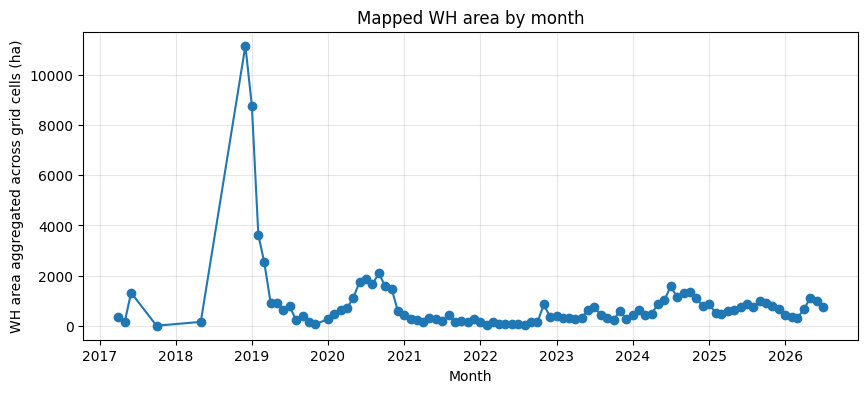

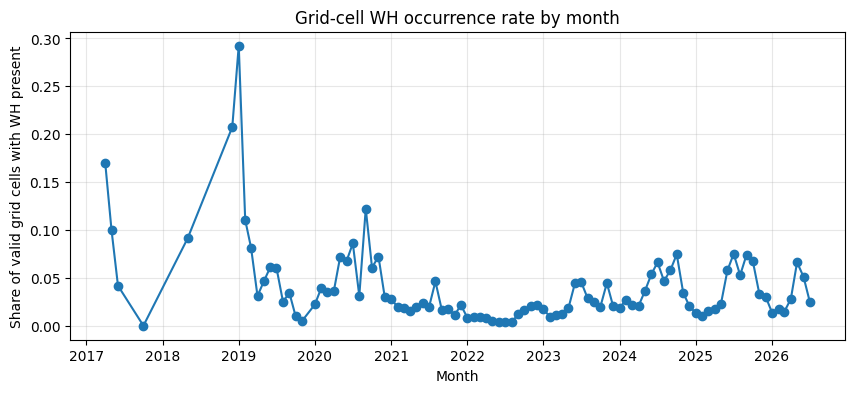

Overall share of cell-months with WH present: 0.0384


In [50]:
monthly_summary = (
    panel.groupby("month", as_index=False)
    .agg(
        wh_area_ha=("wh_area_ha", "sum"),
        valid_area_ha=("valid_area_ha", "sum"),
        mean_cover=("wh_cover", "mean"),
        occurrence_rate=("wh_present", "mean"),
        n_cells=("grid_id", "nunique"),
    )
)

display(monthly_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_summary["month"], monthly_summary["wh_area_ha"], marker="o")
ax.set_title("Mapped WH area by month")
ax.set_xlabel("Month")
ax.set_ylabel("WH area aggregated across grid cells (ha)")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_summary["month"], monthly_summary["occurrence_rate"], marker="o")
ax.set_title("Grid-cell WH occurrence rate by month")
ax.set_xlabel("Month")
ax.set_ylabel("Share of valid grid cells with WH present")
ax.grid(True, alpha=0.3)
plt.show()

print("Overall share of cell-months with WH present:", round(panel["wh_present"].mean(), 4))

## Methodological note: presence definition and probability threshold

The previous model used any non-zero WH area to define presence and used a fixed
0.5 probability threshold. This caused the presence model to be highly
conservative: precision was high but recall was very low, so the model missed
most true WH-present cells and underestimated total WH area. The updated workflow
tests a more ecologically meaningful presence threshold and tunes the probability
threshold using validation data.

Concretely, the changes below:

- define presence with a configurable cover/area threshold instead of "any pixel";
- split the existing training period into fitting and validation months and keep
  the original test months untouched;
- tune the presence probability threshold on the validation months (maximising F1
  by default, with a higher-recall option reported);
- form the final predicted WH area as a two-stage hurdle: the positive-cover model
  is applied only to cells predicted present at the tuned threshold, and zero cover
  is assigned to predicted-absent cells.


## Habitat / valid-cell filter

The panel can contain background cells and cell-months with very few valid
pixels, which dilute presence and push the classifier toward always predicting
absence. The filters below are applied conservatively before modelling:

- the existing minimum valid-pixel filter is retained;
- an optional minimum valid-fraction filter (off by default);
- an optional "ever validly observed" cell filter that keeps only cells with at
  least one valid observation across the panel.

No shoreline/littoral mask is invented here. The number of rows and unique cells
removed by each filter is printed.


In [51]:
n_rows_before_filter = len(panel)
n_cells_before_filter = panel["grid_id"].nunique()
print(f"Before habitat/valid-cell filters: {n_rows_before_filter:,} rows, "
      f"{n_cells_before_filter:,} unique cells")

# 1. Minimum valid pixels per cell-month (already applied in section 7).
#    Re-assert here so the filter is explicit and its effect is reported.
before_rows, before_cells = len(panel), panel["grid_id"].nunique()
panel = panel[panel["valid_pixels"] >= MIN_VALID_PIXELS_PER_CELL_MONTH].copy()
print(f"[valid-pixel >= {MIN_VALID_PIXELS_PER_CELL_MONTH}] removed "
      f"{before_rows - len(panel):,} rows, {before_cells - panel['grid_id'].nunique():,} cells")

# 2. Optional minimum valid fraction per cell-month.
if MIN_VALID_FRACTION_PER_CELL_MONTH is not None and "valid_fraction" in panel.columns:
    before_rows, before_cells = len(panel), panel["grid_id"].nunique()
    panel = panel[panel["valid_fraction"] >= MIN_VALID_FRACTION_PER_CELL_MONTH].copy()
    print(f"[valid-fraction >= {MIN_VALID_FRACTION_PER_CELL_MONTH}] removed "
          f"{before_rows - len(panel):,} rows, {before_cells - panel['grid_id'].nunique():,} cells")
else:
    print("[valid-fraction] filter disabled (MIN_VALID_FRACTION_PER_CELL_MONTH is None)")

# 3. Optional "ever validly observed" cell filter.
#    Conservative: keep cells with at least one valid observation across the panel.
#    With only a classified/no-data validity flag available this is near-universal;
#    it is a scaffold for a stronger habitat mask if an ever-wet indicator is added.
if REQUIRE_EVER_WET_OR_EVER_OBSERVED:
    before_rows, before_cells = len(panel), panel["grid_id"].nunique()
    ever_valid_cells = (
        panel.loc[panel["valid_pixels"] >= MIN_VALID_PIXELS_PER_CELL_MONTH, "grid_id"].unique()
    )
    panel = panel[panel["grid_id"].isin(ever_valid_cells)].copy()
    print(f"[ever validly observed] removed "
          f"{before_rows - len(panel):,} rows, {before_cells - panel['grid_id'].nunique():,} cells")
else:
    print("[ever validly observed] filter disabled (REQUIRE_EVER_WET_OR_EVER_OBSERVED is False)")

# 4. Water / littoral habitat mask (Priority 1): keep cells that are mostly water.
if WATER_MASK_SOURCE != "none":
    before_rows, before_cells = len(panel), panel["grid_id"].nunique()
    wf = None
    if WATER_MASK_SOURCE in ("bathymetry", "both") and "bathy_water_fraction" in panel.columns:
        wf = panel["bathy_water_fraction"].fillna(0.0)
    if WATER_MASK_SOURCE in ("gsw", "both") and "gsw_water_fraction" in panel.columns:
        g = panel["gsw_water_fraction"].fillna(0.0)
        wf = g if wf is None else (np.minimum(wf, g) if WATER_MASK_SOURCE == "both" else g)
    if wf is None:
        print(f"[water mask] source '{WATER_MASK_SOURCE}' requested but no water-fraction "
              "column is available; skipping (provide bathymetry or a GSW fraction).")
    else:
        panel = panel[wf >= MIN_WATER_FRACTION].copy()
        print(f"[water mask: {WATER_MASK_SOURCE} >= {MIN_WATER_FRACTION:g}] removed "
              f"{before_rows - len(panel):,} rows, "
              f"{before_cells - panel['grid_id'].nunique():,} cells "
              f"(kept {panel['grid_id'].nunique():,} water cells)")
else:
    print("[water mask] disabled (WATER_MASK_SOURCE = 'none')")

print(f"After habitat/valid-cell filters: {len(panel):,} rows, "
      f"{panel['grid_id'].nunique():,} unique cells "
      f"(removed {n_rows_before_filter - len(panel):,} rows, "
      f"{n_cells_before_filter - panel['grid_id'].nunique():,} cells overall)")


Before habitat/valid-cell filters: 590,737 rows, 6,446 unique cells
[valid-pixel >= 10] removed 0 rows, 0 cells
[valid-fraction] filter disabled (MIN_VALID_FRACTION_PER_CELL_MONTH is None)
[ever validly observed] removed 0 rows, 0 cells
[water mask: bathymetry >= 0.5] removed 47,742 rows, 519 cells (kept 5,927 water cells)
After habitat/valid-cell filters: 542,995 rows, 5,927 unique cells (removed 47,742 rows, 519 cells overall)


## 11b. Exogenous driver covariates: effective depth & onshore wind

The cell below adds two **response-free** exogenous drivers to `panel` (so they are valid with `GAM_INCLUDE_AR=False`) and registers them in §12 so the §49 GAM-frame builder turns each into a forcing `s()` smooth automatically — **no change to the R formula strings**:

- **`effective_depth_m`** = `depth_m` + `lake_level_anom_m`, where `lake_level_anom_m` = `lake_level_m` − its panel mean. `depth_m` is positive-down (larger = deeper); a rising lake (positive anomaly) deepens the water column. Under the per-cell random intercept `s(grid_id, bs='re')` in §13 the *static* `depth_m` is absorbed by the cell effect (concurvity ≈ 1), so this lake-level interaction is the **only** route by which bathymetry enters — and static `depth_m` is dropped from the candidate features whenever the cell RE is on.
- **`wind_onshore_ms`** = the monthly wind `(wind_u_ms, wind_v_ms)` projected onto each cell's shore-normal unit vector and negated. The shore normal is the least-squares gradient of `dist_shore_m` over the cell's contiguity neighbours (`grid_neighbours`); `dist_shore_m` grows away from land, so its gradient points **lakeward**. Negating the projection makes **`wind_onshore_ms` > 0 ⇒ wind blowing toward the cell's nearest shore ⇒ leeward mat accumulation** (expected sign +).
- One-month lags `effective_depth_m_lag1` and `wind_onshore_ms_lag1` (per-cell `shift(1)`, mirroring §10).

Each block is guarded and skips (with a printed notice) when its inputs are missing: `effective_depth_m` needs a monthly `lake_level_m` (supply via `ENV_MONTHLY_CSV`); `wind_onshore_ms` needs EE `dist_shore_m`, the monthly wind components, and the `grid_neighbours` graph.

### Checks to run in Colab after fitting §13

1. **Partial-dependence signs (§13 effect plots).** `effective_depth_m`: **low** effective depth ⇒ **higher** cover (shallow-water preference). `wind_onshore_ms`: **higher** onshore wind ⇒ **higher** cover (leeward pile-up). A flipped `wind_onshore_ms` curve means the shore gradient points landward instead of lakeward — re-check `shore_gx`/`shore_gy` on `grid` (sign of the `dist_shore_m` gradient).
2. **Worst-case concurvity (§13 concurvity table).** Inspect `effective_depth_m` and `wind_onshore_ms` against **`wave_exposure_idx`** and **`dist_shore_m`** (and `depth_m` if you keep it): worst-case concurvity should stay clear of ~0.8, otherwise the new smooths are not separately identified from the existing exposure/shore geometry.
3. **§49 VIF pre-screen printout.** Confirm neither new driver nor its lag is dropped by the VIF screen. A lag dropped for collinearity with its own level is expected and harmless.
4. **Smooth EDFs (§13 fit summary).** Check the new smooths have EDF > 1 (genuinely used / non-linear) and that `select=TRUE` has not shrunk them toward 0.
5. **Spatial-block vs temporal CV delta (§53–55) — the decider.** A driver that helps temporal CV but collapses under spatial-block CV is fitting spatial structure, not transferable forcing. Keep a new covariate only if spatial-block CV skill does not degrade materially relative to temporal CV.


In [52]:
# =====================================================================
# Exogenous driver covariates (built before §12) -- response-free, so they are
# valid even with GAM_INCLUDE_AR=False. Each block is guarded and skips when its
# target column already exists, so this cell is safe to re-run.
#
#   A) effective_depth_m  -- lake-level x bathymetry interaction
#   B) wind_onshore_ms    -- shore-normal wind component (leeward accumulation)
#
# They become forcing s() smooths automatically once §12 appends them to
# candidate_features -- the R formula strings in §49 are NOT touched.
# =====================================================================
import numpy as np
from collections import defaultdict

# ---------------------------------------------------------------------
# A) effective_depth_m = depth_m + lake-level anomaly.
# ---------------------------------------------------------------------
# Under the per-cell random intercept s(grid_id, bs='re') used in §13, the static
# per-cell depth_m is fully absorbed by the cell effect (concurvity ~1) and so
# carries no driver signal on its own. Interacting bathymetry with the
# time-varying lake level is the ONLY route by which depth enters the model:
# a rising lake (positive level anomaly) deepens the water column, and water
# hyacinth favours shallow water, so a LOW effective_depth_m should map to
# HIGHER cover. depth_m is stored positive-down (larger = deeper).
LAKE_LEVEL_COL = "lake_level_m"

if {LAKE_LEVEL_COL, "depth_m"}.issubset(panel.columns):
    if "lake_level_anom_m" not in panel.columns:
        _lvl = panel[LAKE_LEVEL_COL].astype(float)
        panel["lake_level_anom_m"] = _lvl - _lvl.mean()
    if "effective_depth_m" not in panel.columns:
        panel["effective_depth_m"] = panel["depth_m"] + panel["lake_level_anom_m"]
        print(f"[effective_depth_m] built = depth_m + (lake level - mean); range "
              f"{panel['effective_depth_m'].min():.2f} .. {panel['effective_depth_m'].max():.2f} m")
    else:
        print("[effective_depth_m] already present; skipping.")
else:
    print(f"[effective_depth_m] needs both '{LAKE_LEVEL_COL}' and 'depth_m' in panel; "
          f"supply lake level via ENV_MONTHLY_CSV (a monthly column named "
          f"'{LAKE_LEVEL_COL}'). Skipping.")

# ---------------------------------------------------------------------
# B) wind_onshore_ms = wind component blowing toward each cell's nearest shore.
# ---------------------------------------------------------------------
# Per-cell shore-normal unit vector (shore_gx, shore_gy) = least-squares gradient
# of dist_shore_m over the cell's contiguity neighbours (grid_neighbours).
# dist_shore_m increases away from land, so its gradient points LAKEWARD. Project
# the monthly wind (wind_u_ms eastward, wind_v_ms northward) onto that vector and
# NEGATE: wind_onshore_ms > 0 means the wind blows toward the nearest shore,
# piling floating mats on the leeward side (directional drift), expected sign +.
_have_wind  = {"wind_u_ms", "wind_v_ms"}.issubset(panel.columns)
_have_shore = "dist_shore_m" in panel.columns
_have_graph = ("grid_neighbours" in globals() and grid_neighbours is not None
               and len(grid_neighbours) and "grid" in globals())

if "wind_onshore_ms" in panel.columns:
    print("[wind_onshore_ms] already present; skipping.")
elif not (_have_wind and _have_shore and _have_graph):
    _missing = []
    if not _have_wind:  _missing.append("wind_u_ms/wind_v_ms")
    if not _have_shore: _missing.append("dist_shore_m")
    if not _have_graph: _missing.append("grid_neighbours/grid")
    print(f"[wind_onshore_ms] missing prerequisites ({', '.join(_missing)}); skipping.")
else:
    # One static dist_shore_m + centroid per cell (dist_shore_m is time-invariant).
    _cell = (panel[["grid_id", "x_km", "y_km", "dist_shore_m"]]
             .dropna(subset=["dist_shore_m"])
             .groupby("grid_id", as_index=False).first())
    _pos = {int(r.grid_id): (float(r.x_km), float(r.y_km)) for r in _cell.itertuples()}
    _ds  = {int(r.grid_id): float(r.dist_shore_m) for r in _cell.itertuples()}

    _adj = defaultdict(list)
    for _g, _n in grid_neighbours[["grid_id", "neighbor_id"]].itertuples(index=False):
        _adj[int(_g)].append(int(_n))

    _gx, _gy = {}, {}
    for _gid in _pos:
        _nbrs = [n for n in _adj.get(_gid, []) if n in _pos]   # neighbour has dist_shore
        if len(_nbrs) < 2:                                     # need >= 2 valid neighbours
            continue
        _A = np.array([[_pos[n][0] - _pos[_gid][0], _pos[n][1] - _pos[_gid][1]]
                       for n in _nbrs], dtype=float)
        _b = np.array([_ds[n] - _ds[_gid] for n in _nbrs], dtype=float)
        _grad, *_ = np.linalg.lstsq(_A, _b, rcond=None)        # lakeward gradient
        _norm = float(np.hypot(_grad[0], _grad[1]))
        if not np.isfinite(_norm) or _norm == 0.0:             # degenerate / zero-norm
            continue
        _gx[_gid], _gy[_gid] = _grad[0] / _norm, _grad[1] / _norm

    # Attach the shore-normal unit vector to `grid` (NaN where undefined).
    for _c in ("shore_gx", "shore_gy"):
        if _c in grid.columns:
            grid = grid.drop(columns=_c)
    grid["shore_gx"] = grid["grid_id"].map(_gx)
    grid["shore_gy"] = grid["grid_id"].map(_gy)

    # Merge onto the panel and project the monthly wind onto the shore normal.
    panel = panel.merge(grid[["grid_id", "shore_gx", "shore_gy"]], on="grid_id", how="left")
    panel["wind_onshore_ms"] = -(panel["wind_u_ms"] * panel["shore_gx"]
                                 + panel["wind_v_ms"] * panel["shore_gy"])
    _n_ok = int(panel["wind_onshore_ms"].notna().sum())
    print(f"[wind_onshore_ms] built for {_n_ok:,} cell-months "
          f"({len(_gx):,}/{grid['grid_id'].nunique():,} cells have a shore normal); "
          f"NaNs (sparse/degenerate neighbours) are median-imputed in §49.")

# ---------------------------------------------------------------------
# One-month lags (mirror §10: sort by [grid_id, month], then per-cell shift(1)).
# ---------------------------------------------------------------------
panel = panel.sort_values(["grid_id", "month"]).reset_index(drop=True)
for _col in ["effective_depth_m", "wind_onshore_ms"]:
    _lag = f"{_col}_lag1"
    if _col in panel.columns and _lag not in panel.columns:
        panel[_lag] = panel.groupby("grid_id")[_col].shift(1)
        print(f"[{_lag}] created.")


[effective_depth_m] built = depth_m + (lake level - mean); range -1.04 .. 42.29 m
[wind_onshore_ms] built for 542,903 cell-months (5,926/24,522 cells have a shore normal); NaNs (sparse/degenerate neighbours) are median-imputed in §49.
[effective_depth_m_lag1] created.
[wind_onshore_ms_lag1] created.


## 12. Prepare model dataset

This model is intentionally simple and robust for a test period.

It uses a **temporally blocked train/test split**, rather than a random split, because random splitting would leak information from adjacent months into the test set.

Feature columns now include the Earth Engine and CSV covariates (and their one-month lags for the time-varying ones). Rows are dropped only when the **response** or the **structural lag features** are missing; missing values in the environmental covariates themselves (for example a cloudy Sentinel-2 month, or a cell that is mostly land) are left in place and imputed inside the model pipeline, so adding many covariates does not shrink the panel.

In [53]:
# Candidate model features.
candidate_features = [
    "month_sin",
    "month_cos",
    "time_index",
    "x_km",
    "y_km",
    "wh_cover_lag1",
    "wh_present_lag1",
]

# Time-varying covariates and their one-month lags.
candidate_features += time_varying_cols
candidate_features += [f"{c}_lag1" for c in time_varying_cols if f"{c}_lag1" in panel.columns]

# Static spatial covariates (no lag).
candidate_features += static_cols

# Bathymetry depth (static habitat covariate) and neighbour spatial-lag terms.
candidate_features += [c for c in ["depth_m"] if c in panel.columns]
candidate_features += [c for c in ["wh_cover_neigh_lag1", "wh_present_neigh_lag1"]
                       if c in panel.columns]

# Sensor indicator (Task 1d): lets the model absorb any residual S1/S2 offset in
# the cloud-gap-filled response instead of attributing it to a driver. It is
# dropped automatically by clean_feature_columns when there are no S1 gap-fills.
if globals().get("SENSOR_FEATURE_ENABLED", False) and "sensor_is_s1" in panel.columns:
    candidate_features += ["sensor_is_s1"]

# Exogenous driver covariates built in §11b (effective_depth_m,
# wind_onshore_ms) and their one-month lags. Appended here so the §49
# GAM-frame builder turns each into a forcing s() smooth automatically
# (no change to the R formula strings).
candidate_features += [
    c for c in ["effective_depth_m", "effective_depth_m_lag1",
                "wind_onshore_ms", "wind_onshore_ms_lag1"]
    if c in panel.columns and c not in candidate_features
]
# Under the per-cell random intercept s(grid_id, bs='re') in §13, the static
# depth_m is absorbed by the cell effect (concurvity ~1) and adds no driver
# signal; effective_depth_m is its time-varying replacement, so drop depth_m
# when the cell RE is on (GAM_INCLUDE_CELL_RE defaults to True in §49).
if globals().get("GAM_INCLUDE_CELL_RE", True) and "depth_m" in candidate_features:
    candidate_features.remove("depth_m")

feature_cols = clean_feature_columns(panel, candidate_features)

print(f"Model feature columns ({len(feature_cols)}):")
for c in feature_cols:
    print(" -", c)

model_df = panel.dropna(subset=["wh_cover", "wh_present"]).copy()

# Drop rows only when the response or the structural lag features are missing.
# For a very short test period this may remove the first month (lag1 is NaN there).
# Environmental covariates are intentionally NOT in this list: their missing
# values are imputed inside the model pipeline (median imputer), so adding many
# sparse covariates (e.g. cloudy Sentinel-2 months) does not collapse the panel.
structural_required = [
    "wh_cover", "wh_present", "grid_id", "month", "valid_area_m2",
    "wh_cover_lag1", "wh_present_lag1",
]
structural_required = [c for c in structural_required if c in model_df.columns]
model_df = model_df.dropna(subset=structural_required).copy()

if len(model_df) == 0:
    raise RuntimeError("No model rows remain after dropping missing response/lag values.")

months_sorted = np.array(sorted(model_df["month"].unique()))
split_idx = max(1, int(len(months_sorted) * TRAIN_FRACTION))
split_month = months_sorted[split_idx]

train = model_df[model_df["month"] < split_month].copy()
test = model_df[model_df["month"] >= split_month].copy()

# Split the TRAIN period into fitting and validation months. The validation
# months are used only to tune the presence probability threshold; the TEST
# months are never used for tuning and remain unchanged.
train_months = np.array(sorted(train["month"].unique()))
if len(train_months) > 1:
    n_val_months = int(round(len(train_months) * VALIDATION_FRACTION))
    n_val_months = max(1, min(n_val_months, len(train_months) - 1))
else:
    n_val_months = 0

if n_val_months > 0:
    val_months = train_months[-n_val_months:]
    fit_months = train_months[:-n_val_months]
else:
    val_months = np.array([], dtype=train_months.dtype)
    fit_months = train_months

train_fit = train[train["month"].isin(fit_months)].copy()
train_val = train[train["month"].isin(val_months)].copy()

print(
    f"Fitting months:    {pd.Timestamp(fit_months.min()).date()} to {pd.Timestamp(fit_months.max()).date()}"
    if len(fit_months) else "Fitting months:    (none)"
)
print(
    f"Validation months: {pd.Timestamp(val_months.min()).date()} to {pd.Timestamp(val_months.max()).date()}"
    if len(val_months) else "Validation months: (none - threshold tuning falls back to training)"
)
print(f"Testing months:    {test['month'].min().date()} to {test['month'].max().date()}")
print(f"Fit rows: {len(train_fit):,} | Val rows: {len(train_val):,} | "
      f"Train(total) rows: {len(train):,} | Test rows: {len(test):,}")
print(f"Train WH-present rate: {train['wh_present'].mean():.4f}")
print(f"Val   WH-present rate: {train_val['wh_present'].mean():.4f}" if len(train_val) else "Val   WH-present rate: (n/a)")
print(f"Test  WH-present rate: {test['wh_present'].mean():.4f}")

X_train = train[feature_cols]
X_test = test[feature_cols]
X_fit = train_fit[feature_cols]
X_val = train_val[feature_cols]

y_train_presence = train["wh_present"].astype(int)
y_test_presence = test["wh_present"].astype(int)
y_fit_presence = train_fit["wh_present"].astype(int)
y_val_presence = train_val["wh_present"].astype(int)

Model feature columns (70):
 - month_sin
 - month_cos
 - time_index
 - x_km
 - y_km
 - wh_cover_lag1
 - wh_present_lag1
 - lake_level_m
 - red_reflectance_s2
 - turb_ndti_s2
 - chl_mci_s3
 - chl_mph_s3
 - mean_x
 - rain_chirps_30d_mm
 - rain_chirps_90d_mm
 - rain_chirps_mm
 - rain_max_1d_mm
 - rain_spikes_20mm_cnt
 - rain_spikes_40mm_cnt
 - rain_wet_days
 - mean_y
 - air_temp_c
 - wind_speed_ms
 - wind_u_ms
 - wind_v_ms
 - rain_sdii_mm
 - wind_dir_to_deg
 - wind_axis_comp_ms
 - wind_cross_comp_ms
 - wave_exposure_idx
 - nutrient_pulse_idx
 - lake_level_m_lag1
 - red_reflectance_s2_lag1
 - turb_ndti_s2_lag1
 - chl_mci_s3_lag1
 - chl_mph_s3_lag1
 - mean_x_lag1
 - rain_chirps_30d_mm_lag1
 - rain_chirps_90d_mm_lag1
 - rain_chirps_mm_lag1
 - rain_max_1d_mm_lag1
 - rain_spikes_20mm_cnt_lag1
 - rain_spikes_40mm_cnt_lag1
 - rain_wet_days_lag1
 - air_temp_c_lag1
 - wind_speed_ms_lag1
 - wind_u_ms_lag1
 - wind_v_ms_lag1
 - rain_sdii_mm_lag1
 - wind_dir_to_deg_lag1
 - wind_axis_comp_ms_lag1
 - wi

## 13. One-stage spatial GAM of WH cover (mgcv via rpy2)

This single model **replaces both** the earlier two-stage sklearn hurdle (old §13–§15b) and the
two-part `pygam` GAM (old §14d). Those are kept, commented-out, in the **superseded-models
appendix** at the end of the notebook.

**Why one stage.** WH proportional cover is continuous on \[0, 1] with a large spike of exact
zeros (absent cell-months). Modelling "absent" and "how much cover when present" **together** —
no presence/cover split, no probability threshold to tune, no logit-clip of the zeros — is what
lets us *retire* the hurdle rather than re-implement it. The default response is **`betar`**
(Beta, logit link, `GAM_FAMILY`): predictions stay bounded in \[0, 1] and the exact 0/1 are
squeezed just off the boundary (Smithson & Verkuilen 2006). That squeeze is a workaround, not a
model of the boundary mass, so **§13d** adds an **ordered-Beta** cross-check (Kubinec 2023) that
models the zero-spike, the (0,1) interior and the one-spike as one coherent likelihood;
`GAM_FAMILY="tw"` recovers the older unbounded Tweedie (log-link) fit for comparison.

**Engine: `mgcv` via `rpy2`**, which gives what `pygam` could not:
- flexible **spatial structure** via `GAM_SPATIAL_BASIS` — a thin-plate `te(x_km, y_km)` surface,
  a true **random cell intercept** `s(grid_id, bs="re")` (the convergent substitute for the
  repeated-measures GLMM that failed to converge), or (default) an **MRF** `s(grid_id, bs="mrf")`
  on the §6b water-connectivity graph, so smoothing follows lake connectivity rather than
  straight-line distance;
- proper **families** — the active fit uses **`betar()`** (Beta, logit link) for predictions bounded on \[0, 1]; `tw()` (Tweedie) and `ocat()` remain available;
- **REML** smoothness selection **per term** (no single fixed `lam`);
- **`bam(discrete=TRUE)`**, which fits the **full panel** in memory (the `pygam` fit had to
  subsample to 200 k rows);
- **`concurvity()`** — the nonlinear-collinearity diagnostic that is the correct GAM analogue of VIF.

**Term structure**

`wh_cover ~ Σ s(driver) + s(month_num, bs="cc") + [ spatial term ] + time_index + sensor_is_s1`

— a thin-plate smooth per environmental driver (non-linear optima/thresholds), a **cyclic**
seasonal smooth (December wraps to January), one **spatial term** chosen by `GAM_SPATIAL_BASIS`
(MRF `s(grid_id, bs="mrf")` by default, or `te(x_km, y_km)` / `s(grid_id, bs="re")` — kept
mutually exclusive as they are redundant), and linear trend / sensor controls. Optional
`te(x_km, y_km, by=driver)` spatially-varying-coefficient terms (`GAM_SVC_DRIVERS`) let named
drivers vary over space. The dependence-aware CV (§13-CV) always uses `te(x_km, y_km)`, since a
per-cell MRF/RE cannot transfer to held-out cells.

**Causal framing.** Drivers are split into **exogenous forcing** (rainfall, wind, air/water
temperature, depth, river/shore geometry, catchment pressure) and **endogenous proxies**
(turbidity, chlorophyll-a), which can be *consequences* of WH rather than drivers. A
**forcing-only** refit is reported as the defensible causal model; the full model is descriptive.

> Requires `rpy2` and R's `mgcv` — both pre-installed in Colab. The notebook **defaults to `betar()`** (Beta, logit link) because Tweedie's log link is not
> bounded above at 1 (a mis-specification for a proportion). The principled boundary model —
> **ordered-Beta** — is implemented as the **§13d** cross-check (needs `glmmTMB` or `ordbetareg`).
> Set `GAM_FAMILY="tw"` to recover the Tweedie fit.

In [54]:
# --- rpy2 + mgcv setup -------------------------------------------------------
# rpy2 and R's mgcv ship with Colab; install rpy2 only if it is missing.
try:
    import rpy2  # noqa: F401
except ImportError:
    !pip install -q rpy2

%load_ext rpy2.ipython

# The %%R magic auto-converts pandas DataFrames passed with -i in modern rpy2.
# If a given runtime does not, run once:
#   from rpy2.robjects import pandas2ri; pandas2ri.activate()
%R if (!requireNamespace("mgcv", quietly=TRUE)) install.packages("mgcv", repos="https://cloud.r-project.org")
%R suppressMessages(library(mgcv)); cat(sprintf("mgcv %s ready\n", as.character(packageVersion("mgcv"))))


mgcv 1.9.4 ready


In [55]:
# --- Build the GAM modelling frame -------------------------------------------
# Self-contained: depends only on `model_df`, `feature_cols`, built in §12 above
# (not on the demoted hurdle/pygam cells).
import re as _re
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

GAM_FAMILY           = "betar"  # response family. "betar" (Beta, logit link -> predictions bounded
                                # in (0,1); exact 0/1 squeezed off the boundary, Smithson & Verkuilen
                                # 2006) fixes the tw() log-link over-prediction that drove R-sq.(adj)
                                # negative. "tw" (unbounded log link) kept for comparison. betar auto-
                                # falls back to tw() if the mgcv build cannot fit it (see the R cell).
GAM_CLIP_PRED_01     = True     # clip response-scale predictions to [0,1] in the fit diagnostic & CV
GAM_COLLAPSE_REDUNDANT_DRIVERS = True   # drop near-duplicate wind/rain drivers (concurvity ~1) pre-fit
GAM_DROP_S1_FILL     = False    # fit on S2-only rows (drop the S1 cloud-gap-fill) as an S1 sensitivity
GAM_WEIGHT_BY_CONFIDENCE = True # bam weights from per-cell classifier confidence (measurement error)
GAM_ADD_CV_BASELINES = True     # report persistence + seasonal-climatology skill alongside the GAM CV
GAM_K_DRIVER         = 10       # basis dimension per driver smooth
GAM_K_SEASON         = 8        # basis for the cyclic seasonal smooth
GAM_K_SPATIAL        = 15       # basis per axis of te(x_km, y_km); raised from 12 to soak up the
                                # residual spatial autocorrelation (Moran's I ~0.4). Lower if OOM.
GAM_INCLUDE_AR       = False    # include wh_*_lag1 as drivers? off for clean driver inference
GAM_INCLUDE_CELL_RE  = "auto"     # keep the per-cell intercept s(grid_id, bs='re'); True/False, or
                                # "auto" to drop it only when n_cells > GAM_CELL_RE_MAX_LEVELS
GAM_CELL_RE_MAX_LEVELS = 3000   # "auto" guard only: cell count above which the RE is dropped
# bam() memory controls (mgcv): with the per-cell RE the penalised solve is the peak-RAM step,
# so trade a little speed for headroom -- fewer threads, a smaller model-matrix chunk, and more
# frequent GC all lower peak memory without changing the fitted model (see ?bam).
GAM_BAM_NTHREADS     = 1        # bam() threads (more threads = more memory)
GAM_BAM_CHUNK        = 5000     # bam() chunk.size for model-matrix accumulation (smaller = less RAM)
GAM_BAM_GCLEVEL      = 2        # bam() gc.level (2 = call R garbage collector most aggressively)
GAM_AR1_ENABLED      = True     # AR1 (rho) on within-cell residuals: honest SEs/p-values under temporal pseudoreplication
GAM_AR1_RHO          = None     # None -> estimate rho from a pilot fit's within-cell lag-1 residual acf; else a float in (-1, 1)
GAM_RUN_KCHECK       = True     # run mgcv k.check() basis-dimension adequacy diagnostic on the full model
GAM_VIF_THRESHOLD    = 5.0      # linear pre-screen; concurvity is reported post-fit
GAM_MAX_ROWS         = None     # cap rows passed to R (None = full panel; bam handles it)
GAM_RUN_CV           = True     # spatial + temporal block CV (slow: several full-data refits)
GAM_N_SPATIAL_FOLDS  = 5
GAM_N_TEMPORAL_FOLDS = 4
GAM_SPATIAL_BLOCK_KM = 10.0     # spatial-CV block size (Roberts 2017; Ploton 2020)
GAM_SPATIAL_BASIS    = "mrf"    # MAIN-fit spatial term (change 2): "te" (Euclidean thin-plate
                                # te(x_km,y_km)) or "mrf" (Markov random field s(grid_id,
                                # bs='mrf') on the §6b water-connectivity neighbour graph, so
                                # smoothing follows lake connectivity, not straight-line distance;
                                # usually absorbs residual SAC with less driver concurvity. Auto-
                                # falls back to "te" if the neighbour graph is missing or the mrf
                                # fit errors. The CV/transfer formula always stays on te().
GAM_MRF_K            = 200      # rank of the mrf basis (leading graph-Laplacian eigenvectors);
                                # bounds cost at ~10k cells. None/0 -> full rank (may OOM).
GAM_SVC_DRIVERS      = []       # spatially-varying-coefficient terms te(x_km,y_km, by=driver)
                                # for these drivers (change 3b), e.g. ["wind_cross_comp_ms_lag1",
                                # "air_temp_c"]. Off by default ([]): redundant with the spatial
                                # term and costly. Enable to let key drivers vary over space.
GAM_SVC_K            = 5        # per-axis basis of each SVC te(...) surface (kept small)
RANDOM_STATE = globals().get("RANDOM_STATE", 42)

RESPONSE     = "wh_cover"
control_cols = [c for c in ["time_index", "sensor_is_s1"] if c in model_df.columns]
spatial_cols = ["x_km", "y_km"]
season_col   = "month_num"

# Candidate drivers: everything in feature_cols that is not structure/control/season.
_exclude = set(control_cols + spatial_cols +
               ["month_sin", "month_cos", season_col, "wh_cover_lag1", "wh_present_lag1"])
driver_cols_all = [c for c in feature_cols if c not in _exclude]

# Collapse near-duplicate driver families before fitting (Task 2). Wind is derived from
# two components (u, v); speed / direction are transforms of the same vector, and the rain
# spike-counts / SDII are collinear with the intensity & wet-day metrics -- feeding them all
# gives concurvity ~1 and uninterpretable +/-11 log-link swings. Keep one interpretable
# representative per family (the linear VIF screen below does NOT catch this nonlinear
# concurvity). Drops the matching *_lag1 partners too.
if globals().get("GAM_COLLAPSE_REDUNDANT_DRIVERS", False):
    _redundant_bases = {
        "wind_speed_ms", "wind_u_ms", "wind_v_ms", "wind_dir_to_deg",   # keep axis / cross / onshore
        "rain_spikes_20mm_cnt", "rain_spikes_40mm_cnt", "rain_sdii_mm",  # keep max_1d / wet_days / antecedent
    }
    def _base_name(c):
        return c[:-5] if c.endswith("_lag1") else c
    _collapse_drop = [c for c in driver_cols_all if _base_name(c) in _redundant_bases]
    driver_cols_all = [c for c in driver_cols_all if c not in _collapse_drop]
    print(f"Collapsed redundant wind/rain drivers: dropped {len(_collapse_drop)} "
          f"({', '.join(_collapse_drop) or 'none'})")

# Exogenous forcing vs endogenous proxy (turbidity / chlorophyll / reflectance).
def _is_proxy(name):
    return bool(_re.search(r"(turb|ndti|chl|red_reflectance)", name))
proxy_cols   = [c for c in driver_cols_all if _is_proxy(c)]
forcing_cols = [c for c in driver_cols_all if not _is_proxy(c)]
print(f"Candidate drivers: {len(driver_cols_all)} "
      f"(forcing={len(forcing_cols)}, endogenous proxy={len(proxy_cols)})")
print("  proxy/endogenous:", ", ".join(proxy_cols) or "none")

# Assemble + median-impute the model frame (GAM smooths fit on raw physical units).
needed = [RESPONSE] + driver_cols_all + control_cols + spatial_cols + [season_col, "grid_id", "month",
          "wh_cover_lag1", "wh_conf_mean"]
needed = [c for c in dict.fromkeys(needed) if c in model_df.columns]
gam_src = model_df[needed].copy()
driver_cols_all = [c for c in driver_cols_all if gam_src[c].notna().any()]
_imp = driver_cols_all + [c for c in control_cols if c in gam_src.columns]
gam_src[_imp] = SimpleImputer(strategy="median").fit_transform(gam_src[_imp])
gam_src = gam_src.dropna(subset=[RESPONSE] + spatial_cols + [season_col]).reset_index(drop=True)

# S1 sensitivity (Task 5): optionally drop the Sentinel-1 cloud-gap-fill rows and model the
# Sentinel-2-only response. The S1->S2 calibration is near-flat (slope ~2e-4), so S1-filled
# cell-months are effectively a near-constant; dropping them tests how much the fill drives the
# fit. When on, the now-constant sensor_is_s1 control is removed.
if globals().get("GAM_DROP_S1_FILL", False) and "sensor_is_s1" in gam_src.columns:
    _n0 = len(gam_src)
    gam_src = gam_src[gam_src["sensor_is_s1"] == 0].reset_index(drop=True)
    print(f"GAM_DROP_S1_FILL: dropped {_n0 - len(gam_src):,} S1 gap-fill rows (S2-only model).")
    if gam_src["sensor_is_s1"].nunique() <= 1:
        control_cols = [c for c in control_cols if c != "sensor_is_s1"]

# Confidence weights (Task 7): down-weight low-confidence cell-months so classifier measurement
# error enters the likelihood. wh_conf_mean is NaN for absent cells (no WH pixels) -> full weight
# (a confident structural zero); present cells are weighted by mean winning-class confidence,
# clipped to [0.1, 1] to avoid zero-weight rows.
if globals().get("GAM_WEIGHT_BY_CONFIDENCE", False) and "wh_conf_mean" in gam_src.columns:
    gam_src["obs_weight"] = gam_src["wh_conf_mean"].fillna(1.0).clip(0.1, 1.0)
else:
    gam_src["obs_weight"] = 1.0

# VIF pre-screen on the driver block (drop most-collinear first until all < threshold).
def _vif(X):
    C = np.atleast_2d(np.corrcoef(X.values, rowvar=False))
    try:    inv = np.linalg.inv(C)
    except np.linalg.LinAlgError: inv = np.linalg.pinv(C)
    return np.diag(inv)
_cols, _dropped = list(driver_cols_all), []
while len(_cols) > 1:
    v = _vif(gam_src[_cols]); j = int(np.nanargmax(v))
    if np.isfinite(v[j]) and v[j] > GAM_VIF_THRESHOLD:
        _dropped.append((_cols[j], float(v[j]))); _cols.pop(j)
    else:
        break
print(f"VIF pre-screen (>{GAM_VIF_THRESHOLD}): dropped {len(_dropped)} driver(s): "
      + (", ".join(n for n, _ in _dropped) or "none"))
driver_cols  = _cols
forcing_cols = [c for c in forcing_cols if c in driver_cols]
proxy_cols   = [c for c in proxy_cols if c in driver_cols]

if GAM_MAX_ROWS is not None and len(gam_src) > GAM_MAX_ROWS:
    gam_src = gam_src.sample(GAM_MAX_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"NOTE: capped GAM rows to {GAM_MAX_ROWS:,} (GAM_MAX_ROWS).")

# Cross-validation fold ids (built here, looped in R).
gam_src["blk"] = ((gam_src["x_km"] // GAM_SPATIAL_BLOCK_KM).astype(int).astype(str) + "_" +
                  (gam_src["y_km"] // GAM_SPATIAL_BLOCK_KM).astype(int).astype(str))
_bmap = {b: i % GAM_N_SPATIAL_FOLDS + 1 for i, b in enumerate(sorted(gam_src["blk"].unique()))}
gam_src["fold_sp"] = gam_src["blk"].map(_bmap).astype(int)
_months = np.sort(gam_src["month"].unique())
# time_rank first (integer month index), then derive the rolling-origin temporal folds from the
# INTEGER rank, not from datetime keys: a Timestamp/np.datetime64 hash mismatch in the old dict
# lookup could silently leave every fold_tm at 0 so the temporal CV never ran (Task 3).
gam_src["time_rank"] = gam_src["month"].map({m: i for i, m in enumerate(_months)}).astype(int)
_n_tm = int(min(GAM_N_TEMPORAL_FOLDS, max(0, len(_months) - 1)))
_tm_rank_map = ({r: j + 1 for j, r in enumerate(range(len(_months) - _n_tm, len(_months)))}
                if _n_tm > 0 else {})
gam_src["fold_tm"] = gam_src["time_rank"].map(lambda r: _tm_rank_map.get(int(r), 0)).astype(int)
print(f"Temporal CV folds constructed: {_n_tm} "
      f"(rows with fold_tm>0: {int((gam_src['fold_tm'] > 0).sum()):,})")

gam_df = gam_src.drop(columns=["blk", "month"]).copy()
gam_df["grid_id"] = gam_df["grid_id"].astype(str)
# Ship only the columns the R formulae and the CV cell use (drops VIF-rejected drivers and
# other extras) so the rpy2 copy into R is as small as possible, then free the intermediate.
_keep_cols = list(dict.fromkeys([RESPONSE] + driver_cols + control_cols + spatial_cols +
                                [season_col, "grid_id", "fold_sp", "fold_tm", "time_rank",
                                 "wh_cover_lag1", "obs_weight"]))
gam_df = gam_df[[c for c in _keep_cols if c in gam_df.columns]].copy()
# AR1 (Section 13) needs each cell's rows consecutive and time-ordered so R can mark cell
# boundaries with AR.start; sort once here so the within-cell AR1 correction is well-defined.
gam_df = gam_df.sort_values(["grid_id", "time_rank"]).reset_index(drop=True)
del gam_src; import gc as _gc; _gc.collect()

# Build the R model formulae (full + forcing-only + CV-without-RE), as strings.
def _smooths(cols):
    return " + ".join(f"s({c}, k={GAM_K_DRIVER}, bs='tp')" for c in cols)
_season  = f"s({season_col}, bs='cc', k={GAM_K_SEASON})"
_spatial = f"te(x_km, y_km, k=c({GAM_K_SPATIAL},{GAM_K_SPATIAL}))"
_ctrl    = (" + " + " + ".join(control_cols)) if control_cols else ""
# Per-cell random intercept controls for time-invariant cell heterogeneity (the
# panel fixed-effect analogue) but adds one coefficient per cell. With many cells
# the bam() penalised solve becomes a ~n_cells x n_cells dense system that exhausts
# RAM (Colab kernel restart), so include it only when the grid is small enough;
# otherwise te(x_km, y_km) carries the spatial structure (the CV/transfer spec).
_n_cells = gam_df["grid_id"].nunique()

# --- Spatial structure: te(x_km, y_km) vs MRF on the water-connectivity graph (change 2) ------
# GAM_SPATIAL_BASIS selects the MAIN inferential fit's spatial term. "mrf" builds a Markov random
# field s(grid_id, bs='mrf') from the §6b queen/rook neighbour graph, so smoothing follows lake
# connectivity (shorelines/islands) rather than Euclidean distance -- it typically absorbs residual
# spatial autocorrelation with less driver concurvity than te(). Like the per-cell RE it CANNOT
# transfer to held-out cells, so the CV/transfer formula (r_formula_cv) always keeps te().
_spatial_basis = str(globals().get("GAM_SPATIAL_BASIS", "te")).lower()
GAM_MRF_FALLBACK_SPATIAL = _spatial          # te term the R cell swaps in if the mrf fit fails
GAM_MRF_TERM = ""                            # exact mrf term string (for the fixed= R fallback)
gam_mrf_edges = None
if _spatial_basis == "mrf":
    _gn = globals().get("grid_neighbours", None)
    if _gn is not None and len(_gn):
        _present = set(gam_df["grid_id"].unique())
        _e = _gn[["grid_id", "neighbor_id"]].copy()
        _e["grid_id"] = _e["grid_id"].astype(str)
        _e["neighbor_id"] = _e["neighbor_id"].astype(str)
        _e = _e[_e["grid_id"].isin(_present) & _e["neighbor_id"].isin(_present)]
        gam_mrf_edges = _e.reset_index(drop=True)
        _iso = len(_present) - gam_mrf_edges["grid_id"].nunique()
        print(f"MRF spatial basis: {len(gam_mrf_edges):,} edges among {len(_present):,} cells "
              f"({_iso:,} with no in-panel neighbour).")
    else:
        print("GAM_SPATIAL_BASIS='mrf' but grid_neighbours is unavailable (NEIGHBOUR_LAG_ENABLED "
              "off?); falling back to te(x_km, y_km).")
        _spatial_basis = "te"

# Per-cell random intercept controls for time-invariant cell heterogeneity (the panel
# fixed-effect analogue) but adds one coefficient per cell. With many cells the bam() penalised
# solve becomes a ~n_cells x n_cells dense system that exhausts RAM, so include it only when the
# grid is small enough; otherwise te(x_km, y_km) (or the MRF) carries the spatial structure. The
# MRF is itself a per-cell spatial structure, so it replaces BOTH te() and the RE.
if _spatial_basis == "mrf":
    _use_cell_re = False
elif isinstance(GAM_INCLUDE_CELL_RE, str) and GAM_INCLUDE_CELL_RE.lower() == "auto":
    _use_cell_re = _n_cells <= GAM_CELL_RE_MAX_LEVELS
else:
    _use_cell_re = bool(GAM_INCLUDE_CELL_RE)
_re_term = " + s(grid_id, bs='re')" if _use_cell_re else ""

# The per-cell RE, te(x_km, y_km) and the MRF are mutually redundant (every covariate is constant
# within a cell), so keep exactly one spatial structure. The no-RE/no-MRF CV formula below always
# keeps te() so it can still transfer to held-out cells.
if _spatial_basis == "mrf":
    _mrf_k = int(GAM_MRF_K) if globals().get("GAM_MRF_K", None) else 0
    _mrf_k_arg = f", k={_mrf_k}" if _mrf_k else ""
    _spatial_term = f" + s(grid_id, bs='mrf', xt=xt_mrf{_mrf_k_arg})"
    GAM_MRF_TERM = _spatial_term.strip(" +")
    print(f"Spatial structure: MRF on the water-connectivity graph "
          f"(s(grid_id, bs='mrf'{', k=' + str(_mrf_k) if _mrf_k else ', full rank'})); te(x_km, y_km) "
          f"used only in the CV/transfer spec. Falls back to te() if the mrf fit errors.")
elif _use_cell_re:
    _spatial_term = ""
    print(f"Per-cell random effect s(grid_id, bs='re') ON ({_n_cells:,} cells); te(x_km, y_km) "
          f"dropped as redundant. bam memory controls -> "
          f"nthreads={GAM_BAM_NTHREADS}, chunk.size={GAM_BAM_CHUNK}, gc.level={GAM_BAM_GCLEVEL}.")
else:
    _spatial_term = f" + {_spatial}"
    print(f"NOTE: per-cell random effect s(grid_id, bs='re') OFF ({_n_cells:,} cells > "
          f"GAM_CELL_RE_MAX_LEVELS={GAM_CELL_RE_MAX_LEVELS}); te(x_km, y_km) carries the spatial "
          f"structure. Set GAM_INCLUDE_CELL_RE=True on a high-RAM runtime to force it, or use a "
          f"coarser CELL_SIZE_M to reduce the cell count.")

# Spatially-varying coefficients te(x_km,y_km, by=driver) (change 3b): attribute spatial structure
# to driver x location rather than to a single spatial nuisance. Off by default (redundant with the
# spatial term, and costly); enable via GAM_SVC_DRIVERS. Left out of the CV/transfer spec.
def _svc(cols):
    _k = int(globals().get("GAM_SVC_K", 5))
    _sel = [d for d in globals().get("GAM_SVC_DRIVERS", []) if d in cols]
    return "".join(f" + te(x_km, y_km, by={d}, k=c({_k},{_k}))" for d in _sel)
if globals().get("GAM_SVC_DRIVERS", []):
    print("Spatially-varying-coefficient terms:",
          ", ".join(d for d in GAM_SVC_DRIVERS if d in driver_cols) or "none in the driver set")

r_formula         = f"{RESPONSE} ~ {_smooths(driver_cols)} + {_season}{_spatial_term}{_re_term}{_svc(driver_cols)}{_ctrl}"
r_formula_forcing = f"{RESPONSE} ~ {_smooths(forcing_cols)} + {_season}{_spatial_term}{_re_term}{_svc(forcing_cols)}{_ctrl}"
r_formula_cv      = f"{RESPONSE} ~ {_smooths(driver_cols)} + {_season} + {_spatial}{_ctrl}"  # no RE/MRF -> te() transfers
driver_roles = pd.DataFrame({"term": driver_cols,
                             "role": ["proxy" if c in proxy_cols else "forcing" for c in driver_cols]})
GAM_RUN_CV_R = bool(GAM_RUN_CV)
# rpy2's %%R -i silently skips any variable whose Python value is None (it is never assigned
# on the R side -> "object 'GAM_AR1_RHO' not found"), so ship rho as NaN; the R cell treats
# any non-finite value as "estimate rho from the pilot fit".
GAM_AR1_RHO_R = float("nan") if GAM_AR1_RHO is None else float(GAM_AR1_RHO)
print(f"\nGAM frame: {len(gam_df):,} rows x {gam_df.shape[1]} cols; "
      f"{gam_df['grid_id'].nunique():,} cells; response '{RESPONSE}'")
print("Full formula:\n ", r_formula)

# --- OPTIONAL (disabled): data-driven depth x lake-level interaction ----------
# As an alternative to the pre-multiplied effective_depth_m, let mgcv estimate
# the bathymetry x lake-level surface directly with a tensor-product
# interaction. To enable: (a) ship depth_m and lake_level_anom_m in gam_df
# (keep depth_m in candidate_features and add 'lake_level_anom_m' to _keep_cols),
# then (b) uncomment the three appends below.
# r_formula         += " + ti(depth_m, lake_level_anom_m, k=c(5,5))"
# r_formula_forcing += " + ti(depth_m, lake_level_anom_m, k=c(5,5))"
# r_formula_cv      += " + ti(depth_m, lake_level_anom_m, k=c(5,5))"


Collapsed redundant wind/rain drivers: dropped 14 (rain_spikes_20mm_cnt, rain_spikes_40mm_cnt, wind_speed_ms, wind_u_ms, wind_v_ms, rain_sdii_mm, wind_dir_to_deg, rain_spikes_20mm_cnt_lag1, rain_spikes_40mm_cnt_lag1, wind_speed_ms_lag1, wind_u_ms_lag1, wind_v_ms_lag1, rain_sdii_mm_lag1, wind_dir_to_deg_lag1)
Candidate drivers: 49 (forcing=41, endogenous proxy=8)
  proxy/endogenous: red_reflectance_s2, turb_ndti_s2, chl_mci_s3, chl_mph_s3, red_reflectance_s2_lag1, turb_ndti_s2_lag1, chl_mci_s3_lag1, chl_mph_s3_lag1
VIF pre-screen (>5.0): dropped 16 driver(s): dist_majriver_m, rain_chirps_mm, rain_chirps_mm_lag1, effective_depth_m_lag1, lake_level_m, ghsl_built_m2, rain_chirps_90d_mm, chl_mph_s3, red_reflectance_s2, chl_mci_s3_lag1, rain_chirps_30d_mm_lag1, wave_exposure_idx_lag1, rain_chirps_30d_mm, pop_count, turb_ndti_s2_lag1, openness_index
Temporal CV folds constructed: 4 (rows with fold_tm>0: 23,484)
MRF spatial basis: 45,256 edges among 5,927 cells (0 with no in-panel neighbour).


In [56]:
%%R -i gam_df -i r_formula -i r_formula_forcing -i driver_roles -i GAM_BAM_NTHREADS -i GAM_BAM_CHUNK -i GAM_BAM_GCLEVEL -i GAM_AR1_ENABLED -i GAM_AR1_RHO_R -i GAM_RUN_KCHECK -i GAM_FAMILY -i GAM_CLIP_PRED_01 -i gam_mrf_edges -i GAM_MRF_K -i GAM_MRF_TERM -i GAM_MRF_FALLBACK_SPATIAL -o eff_table -o eff_table_forcing -o pdep_table -o concurvity_df -o resid_df -o fit_stats -o kcheck_df
# One-stage GAM (full + forcing-only); family per GAM_FAMILY (betar/logit by default, tw/log
# optional), with fREML smoothing, select=TRUE term selection,
# and a random cell effect.
suppressMessages(library(mgcv))
gam_df$grid_id <- factor(gam_df$grid_id)

# --- MRF spatial term (change 2): build the neighbour list from the shipped edge list --------
# gam_mrf_edges (grid_id, neighbor_id as characters, restricted to in-panel cells) is only
# shipped when GAM_SPATIAL_BASIS="mrf"; rpy2 skips it otherwise, so guard with exists(). split()
# over the FULL factor levels guarantees every area appears in the nb list (empty vector for an
# isolated cell). A cheap smoothCon() probe validates the mrf spec before the costly full fit;
# on any failure we swap the mrf term for te(x_km, y_km) (GAM_MRF_FALLBACK_SPATIAL) and carry on.
te_fallback <- function(f) sub(as.character(GAM_MRF_TERM)[1],
                               as.character(GAM_MRF_FALLBACK_SPATIAL)[1], f, fixed = TRUE)
use_mrf <- exists("gam_mrf_edges") && !is.null(gam_mrf_edges) &&
           grepl("bs='mrf'", r_formula, fixed = TRUE)
if (use_mrf) {
  lev <- levels(gam_df$grid_id)
  gam_mrf_nb <- split(as.character(gam_mrf_edges$neighbor_id),
                      factor(as.character(gam_mrf_edges$grid_id), levels = lev))
  gam_mrf_nb <- lapply(gam_mrf_nb, function(z) as.character(z[!is.na(z)]))
  xt_mrf <- list(nb = gam_mrf_nb)
  mrf_k <- suppressWarnings(as.integer(GAM_MRF_K)[1]); if (is.na(mrf_k) || mrf_k < 1L) mrf_k <- -1L
  ok_mrf <- tryCatch({
    .probe <- gam_df[seq_len(min(2000L, nrow(gam_df))), , drop = FALSE]
    invisible(mgcv::smoothCon(mgcv::s(grid_id, bs = "mrf", xt = xt_mrf, k = mrf_k),
                              data = .probe, absorb.cons = TRUE)); TRUE
  }, error = function(e) { cat("MRF smooth construction failed (", conditionMessage(e),
                               ") -> te(x_km, y_km) fallback\n", sep = ""); FALSE })
  if (ok_mrf) {
    cat(sprintf("MRF spatial term: %d areas (%d with >=1 neighbour), basis rank k=%s.\n",
                length(gam_mrf_nb), sum(vapply(gam_mrf_nb, length, 1L) > 0L),
                if (mrf_k > 0L) as.character(mrf_k) else "auto"))
  } else {
    r_formula <- te_fallback(r_formula); r_formula_forcing <- te_fallback(r_formula_forcing)
    use_mrf <- FALSE
  }
}
# Safety: if the formula still carries an mrf term but xt_mrf was never built, swap to te().
if (grepl("bs='mrf'", r_formula, fixed = TRUE) && !use_mrf) {
  r_formula <- te_fallback(r_formula); r_formula_forcing <- te_fallback(r_formula_forcing)
}
nth <- as.integer(GAM_BAM_NTHREADS)[1]
if (is.na(nth) || nth < 1L) nth <- tryCatch(max(1L, parallel::detectCores()), error = function(e) 1L)
chunk_sz <- as.integer(GAM_BAM_CHUNK)[1]; gc_lvl <- as.integer(GAM_BAM_GCLEVEL)[1]

# --- Response family (Task 1): bounded Beta (logit) or unbounded Tweedie (log) ----------------
# betar() keeps predictions in (0,1); tw() does not. betar needs y in the OPEN interval, so squeeze
# exact 0/1 off the boundary (Smithson & Verkuilen 2006). A logit-link Beta is the scalable in-mgcv
# stand-in for ordered-Beta (glmmTMB / ordbetareg do not fit ~1.1M rows in-notebook).
fam_name  <- tryCatch(tolower(as.character(GAM_FAMILY)[1]), error = function(e) "tw")
use_betar <- identical(fam_name, "betar")
clip01    <- tryCatch(isTRUE(as.logical(GAM_CLIP_PRED_01)[1]), error = function(e) TRUE)
if (use_betar) {
  ny <- nrow(gam_df)
  gam_df$wh_cover <- (gam_df$wh_cover * (ny - 1) + 0.5) / ny
  cat(sprintf("Response family: betar (logit); squeezed %s rows off the 0/1 boundary.\n",
              format(ny, big.mark = ",")))
} else cat("Response family: tw (Tweedie, log link).\n")
make_family <- function() {
  if (use_betar) tryCatch(mgcv::betar(link = "logit"),
        error = function(e) { cat("betar() unavailable (", conditionMessage(e),
                                  ") -> tw() fallback\n", sep = ""); tw() })
  else tw()
}
# Tweedie power only exists for tw(); return NA for betar so fit_stats does not error.
get_tw_p <- function(m) tryCatch(if (grepl("Tweedie", m$family$family))
                                   as.numeric(m$family$getTheta(TRUE)) else NA_real_,
                                 error = function(e) NA_real_)
# Confidence weights (Task 7): shipped as gam_df$obs_weight when GAM_WEIGHT_BY_CONFIDENCE is on.
wcol <- if ("obs_weight" %in% names(gam_df)) as.numeric(gam_df$obs_weight) else NULL

# --- AR1 within-cell temporal correction (honest inference under pseudoreplication) ----------
# gam_df arrives sorted by (grid_id, time_rank), so consecutive rows within a cell are
# consecutive observations; AR.start marks each cell's first row so the AR1 does not wrap across
# cells. rho applies an AR1 model to the working residuals (a GEE-style correction; ?bam) that
# deflates the effective sample size, widening SEs/p-values inflated by within-cell temporal
# pseudoreplication. Cells with month gaps are treated as lag-1 in row order (standard bam AR1
# approximation). rho is estimated from a pilot fit unless GAM_AR1_RHO supplies a value.
ar1_on    <- isTRUE(as.logical(GAM_AR1_ENABLED)[1])
gid_int   <- as.integer(gam_df$grid_id)
tr_int    <- as.integer(gam_df$time_rank)
# Start a new AR1 segment at each cell boundary AND at any within-cell month gap
# (time_rank jump != 1). The previous version broke only at cell boundaries, so a gappy
# series (S1 cloud-gap-fills / missing months) was mis-treated as lag-1-consecutive; that
# over-corrected the AR1 and left a strong NEGATIVE residual lag-1 (~ -0.42). Breaking at
# gaps keeps the lag-1 pairing (and the pilot rho estimate) honest.
new_cell  <- c(TRUE, gid_int[-1] != gid_int[-length(gid_int)])
time_gap  <- c(TRUE, (tr_int[-1] - tr_int[-length(tr_int)]) != 1L)
ar_start  <- if (ar1_on) (new_cell | time_gap) else NULL
rho_fixed <- suppressWarnings(as.numeric(GAM_AR1_RHO_R)[1])

fit_one <- function(form_str, label, rho_use = 0, ars = NULL) {
  cat("\n==== fitting", label, "(nthreads =", nth, ", rho =", signif(rho_use, 3),
      ", family =", if (use_betar) "betar" else "tw", ") ====\n")
  # select=TRUE adds the double penalty so unimportant/confounded smooths can shrink to zero.
  # rho + AR.start apply an AR1 model to the residuals (rho = 0 -> no correction).
  base_args <- list(formula = as.formula(form_str), data = gam_df, family = make_family(),
                    method = "fREML", select = TRUE, knots = list(month_num = c(0.5, 12.5)),
                    nthreads = nth, chunk.size = chunk_sz, gc.level = gc_lvl,
                    rho = rho_use, AR.start = ars)
  if (!is.null(wcol)) base_args$weights <- wcol
  # Prefer discrete=TRUE (fast, low-RAM); some family/arg combos reject it, so fall back to
  # discrete=FALSE rather than aborting the fit.
  tryCatch(do.call(bam, c(base_args, list(discrete = TRUE))),
           error = function(e) { cat("  discrete=TRUE failed (", conditionMessage(e),
                                     ") -> retrying discrete=FALSE\n", sep = "")
                                 do.call(bam, c(base_args, list(discrete = FALSE))) })
}
get_col <- function(mat, tn) if (is.null(dim(mat))) as.numeric(mat) else as.numeric(mat[, tn])

# median template row (numerics at median; grid_id at its first level) for partial dependence
med_row <- gam_df[1, , drop = FALSE]
for (nm in names(gam_df)) if (is.numeric(gam_df[[nm]])) med_row[[nm]] <- median(gam_df[[nm]], na.rm = TRUE)
med_row$grid_id <- factor(levels(gam_df$grid_id)[1], levels = levels(gam_df$grid_id))
ng <- 60

effects_for <- function(model, drivers, roles, want_pdep) {
  el <- list(); pl <- list()
  for (i in seq_along(drivers)) {
    d <- drivers[i]; tn <- paste0("s(", d, ")")
    x <- gam_df[[d]]; q <- quantile(x, c(.01, .1, .9, .99), na.rm = TRUE)
    gx <- seq(q[1], q[4], length = ng); nd <- med_row[rep(1, ng), , drop = FALSE]; nd[[d]] <- gx
    pr <- predict(model, nd, type = "terms", terms = tn, se.fit = TRUE)
    fit <- get_col(pr$fit, tn); se <- get_col(pr$se.fit, tn)
    # Guard degenerate drivers: a near-constant covariate has q[1] == q[4], so gx collapses to a
    # single value and approx() cannot interpolate (need >= 2 distinct x). Degrade to NA instead
    # of aborting the whole cell (select=TRUE will already have shrunk such a term toward zero).
    ok <- is.finite(gx) & is.finite(fit)
    ip10 <- if (length(unique(gx[ok])) >= 2) approx(gx[ok], fit[ok], q[2])$y else NA_real_
    ip90 <- if (length(unique(gx[ok])) >= 2) approx(gx[ok], fit[ok], q[3])$y else NA_real_
    el[[i]] <- data.frame(term = d, role = roles[i], effect_p10_p90_link = ip90 - ip10,
                          curvature = max(fit) - min(fit))
    if (want_pdep)
      pl[[i]] <- data.frame(term = d, role = roles[i], x = gx, pdep = fit,
                            lo = fit - 1.96 * se, hi = fit + 1.96 * se)
  }
  list(eff = do.call(rbind, el), pdep = if (want_pdep) do.call(rbind, pl) else NULL)
}

# ---- full driver model -------------------------------------------------------
# Fit the full model. When AR1 is on, estimate rho from a pilot (rho = 0) fit's within-cell
# lag-1 residual autocorrelation (unless GAM_AR1_RHO fixes it), then refit with that rho.
rho_used <- 0
if (ar1_on && is.finite(rho_fixed)) {
  rho_used <- max(-0.99, min(0.99, rho_fixed))
  m_full <- fit_one(r_formula, "full driver model", rho_used, ar_start)
} else if (ar1_on) {
  m_pilot <- fit_one(r_formula, "full driver model (pilot, rho = 0)", 0, ar_start)
  rp <- residuals(m_pilot, type = "deviance"); nbr <- which(!ar_start)
  rho_used <- tryCatch(max(-0.99, min(0.99, cor(rp[nbr - 1], rp[nbr], use = "complete.obs"))),
                       error = function(e) 0)
  cat(sprintf("Estimated AR1 rho (within-cell lag-1 residual acf) = %.3f\n", rho_used))
  if (abs(rho_used) > 1e-3) {
    rm(m_pilot); gc()
    m_full <- tryCatch(
      fit_one(r_formula, sprintf("full driver model (AR1 rho = %.3f)", rho_used), rho_used, ar_start),
      error = function(e) { cat("AR1 refit failed:", conditionMessage(e), "-> rho = 0 fallback\n")
                            rho_used <<- 0; fit_one(r_formula, "full driver model (rho = 0)") })
  } else m_full <- m_pilot
} else {
  m_full <- fit_one(r_formula, "full driver model")
}
print(summary(m_full))
s  <- summary(m_full)
# Fitted-value diagnostic: for a Tweedie/log model R-sq.(adj) is on the response scale and turns
# negative when a few fitted values explode after exp() -- report deviance explained, not adj-R2.
fv <- as.numeric(fitted(m_full))
yv <- tryCatch(as.numeric(m_full$y), error = function(e) rep(NA_real_, length(fv)))
tryCatch({
  if (any(is.finite(yv))) {
    cat(sprintf("\nFitted vs observed (response scale): obs max=%.4g q99=%.4g | fit max=%.4g q99=%.4g q999=%.4g\n",
                max(yv, na.rm = TRUE), quantile(yv, 0.99, na.rm = TRUE),
                max(fv, na.rm = TRUE), quantile(fv, 0.99, na.rm = TRUE), quantile(fv, 0.999, na.rm = TRUE)))
    if (max(fv, na.rm = TRUE) > 5 * max(yv, na.rm = TRUE))
      cat("  NOTE: max fitted >> max observed: log-link over-prediction inflates response-scale",
          "variance and drives R-sq.(adj) negative; use deviance explained as the fit metric.\n")
  } else cat(sprintf("\nFitted (response scale): max=%.4g q99=%.4g q999=%.4g\n",
                     max(fv, na.rm = TRUE), quantile(fv, 0.99, na.rm = TRUE), quantile(fv, 0.999, na.rm = TRUE)))
}, error = function(e) cat("Fitted-value diagnostic skipped:", conditionMessage(e), "\n"))
# Basis-dimension adequacy (mgcv k.check): a k-index below 1 with a low p-value AND edf close to
# k' means that smooth's basis may be too small -- raise its k. Standard GAM defensibility check.
kcheck_df <- tryCatch({
  if (isTRUE(as.logical(GAM_RUN_KCHECK)[1])) {
    kc <- k.check(m_full)
    data.frame(term = rownames(kc), kprime = kc[, "k'"], edf = kc[, "edf"],
               k_index = kc[, "k-index"], p_value = kc[, "p-value"], row.names = NULL)
  } else data.frame(term = character(0), kprime = numeric(0), edf = numeric(0),
                    k_index = numeric(0), p_value = numeric(0))
}, error = function(e) { cat("k.check skipped:", conditionMessage(e), "\n")
                         data.frame(term = character(0), kprime = numeric(0), edf = numeric(0),
                                    k_index = numeric(0), p_value = numeric(0)) })
# concurvity() builds the full n x p model matrix; for a large panel (here n ~ 1.1e6,
# p ~ 1e4) n*p overflows R's 32-bit indexing -> `numeric(n * bc)` "vector size cannot be NA".
# Compute it on a random row subsample (concurvity is a property of the term design and is
# stable under subsampling) and degrade to NA rather than aborting the rest of the cell.
concurvity_safe <- function(model, max_n = 20000L) {
  nobs <- tryCatch(nrow(model$model), error = function(e) NA_integer_)
  if (is.finite(nobs) && nobs > max_n) {
    idx <- sort(sample.int(nobs, max_n))
    ms <- model
    ms$model <- model$model[idx, , drop = FALSE]
    ms$dinfo <- NULL  # force standard (block-wise, non-discrete) lpmatrix construction
    cat(sprintf("(concurvity on a %s-row subsample of %s)\n",
                format(max_n, big.mark = ","), format(nobs, big.mark = ",")))
    gc()
    concurvity(ms, full = TRUE)
  } else concurvity(model, full = TRUE)
}
cc <- tryCatch(concurvity_safe(m_full),
               error = function(e) { cat("concurvity skipped:", conditionMessage(e), "\n"); NULL })
concurvity_df <- if (is.null(cc)) data.frame(term = character(0), worst = numeric(0)) else
  data.frame(term = colnames(cc), worst = as.numeric(cc["worst", ]))
fit_stats <- data.frame(model = "full", n = s$n, dev_expl = as.numeric(s$dev.expl),
                        tweedie_p = get_tw_p(m_full),
                        edf_total = sum(s$edf), aic = AIC(m_full),
                        rho = rho_used, fitted_max = suppressWarnings(max(fv, na.rm = TRUE)),
                        resp_max = suppressWarnings(max(yv, na.rm = TRUE)))
fo <- effects_for(m_full, as.character(driver_roles$term), as.character(driver_roles$role), TRUE)
eff_table <- fo$eff[order(-abs(fo$eff$effect_p10_p90_link)), ]
pdep_table <- fo$pdep
# Feed the residual-dependence diagnostics the AR1-standardized (approximately whitened; ?bam)
# residuals so Moran's I / lag-1 assess dependence AFTER the temporal correction; fall back to
# deviance residuals when no AR1 was applied. resid_kind records which, for the writeup.
whitened   <- !is.null(m_full$std.rsd) && length(m_full$std.rsd) == nrow(gam_df)
resid_vec  <- if (whitened) as.numeric(m_full$std.rsd) else as.numeric(residuals(m_full, type = "deviance"))
resid_df <- data.frame(grid_id = as.character(gam_df$grid_id), x_km = gam_df$x_km,
                       y_km = gam_df$y_km, time_rank = gam_df$time_rank,
                       resid = resid_vec, resid_kind = if (whitened) "AR1_standardized" else "deviance")

# ---- forcing-only (causal) refit --------------------------------------------
fdr <- driver_roles[driver_roles$role == "forcing", ]
m_forc <- fit_one(r_formula_forcing, "forcing-only (causal) model", rho_used, ar_start)
sf <- summary(m_forc)
ff <- effects_for(m_forc, as.character(fdr$term), as.character(fdr$role), FALSE)
eff_table_forcing <- ff$eff[order(-abs(ff$eff$effect_p10_p90_link)), ]
fit_stats <- rbind(fit_stats,
  data.frame(model = "forcing_only", n = sf$n, dev_expl = as.numeric(sf$dev.expl),
             tweedie_p = get_tw_p(m_forc),
             edf_total = sum(sf$edf), aic = AIC(m_forc),
             rho = rho_used, fitted_max = suppressWarnings(max(as.numeric(fitted(m_forc)), na.rm = TRUE)),
             resp_max = suppressWarnings(max(yv, na.rm = TRUE))))
cat(sprintf("\nDeviance explained: full = %.1f%% | forcing-only = %.1f%%\n",
            100 * s$dev.expl, 100 * sf$dev.expl))
# Causal framing (Task 6): report the forcing-only model as primary.
cat("Primary causal model = forcing-only (endogenous proxies turbidity / chl-a / reflectance\n",
    "excluded); the full model is descriptive. Lead inference on block-CV skill (next cells),\n",
    "NOT on the in-sample deviance explained above.\n", sep = "")


MRF spatial term: 5927 areas (5927 with >=1 neighbour), basis rank k=200.
Response family: betar (logit); squeezed 537,068 rows off the 0/1 boundary.

==== fitting full driver model (pilot, rho = 0) (nthreads = 1 , rho = 0 , family = betar ) ====
Estimated AR1 rho (within-cell lag-1 residual acf) = 0.663

==== fitting full driver model (AR1 rho = 0.663) (nthreads = 1 , rho = 0.663 , family = betar ) ====

Family: Beta regression(38.961) 
Link function: logit 

Formula:
wh_cover ~ s(turb_ndti_s2, k = 10, bs = "tp") + s(chl_mci_s3, 
    k = 10, bs = "tp") + s(mean_x, k = 10, bs = "tp") + s(rain_max_1d_mm, 
    k = 10, bs = "tp") + s(rain_wet_days, k = 10, bs = "tp") + 
    s(mean_y, k = 10, bs = "tp") + s(air_temp_c, k = 10, bs = "tp") + 
    s(wind_axis_comp_ms, k = 10, bs = "tp") + s(wind_cross_comp_ms, 
    k = 10, bs = "tp") + s(wave_exposure_idx, k = 10, bs = "tp") + 
    s(nutrient_pulse_idx, k = 10, bs = "tp") + s(lake_level_m_lag1, 
    k = 10, bs = "tp") + s(red_reflectance_s2_l

In addition: Warning message:
In estimate.theta(theta, family, y, mu, scale = scale1, wt = G$w,  :
  step failure in theta estimation


One-stage Beta GAM — fit statistics:


,model,n,dev_expl,tweedie_p,edf_total,aic,rho,fitted_max,resp_max
1,full,537068,0.302682,NaN,333.685359,-9.163028e+06,0.663031,0.415471,0.998991
2,forcing_only,537068,0.287872,NaN,246.295314,-9.157099e+06,0.663031,0.011926,0.998991



Basis-dimension adequacy (mgcv k.check; k-index < 1 with low p & edf near k' -> raise that term's k):


,term,kprime,edf,k_index,p_value
0,s(rain_max_1d_mm),9.0,6.603954,0.922533,0.0000
1,s(wind_axis_comp_ms),9.0,6.886713,0.936465,0.0000
2,s(air_temp_c),9.0,7.836913,0.917938,0.0000
3,s(lake_level_m_lag1),9.0,7.883731,0.916059,0.0000
4,s(chl_mph_s3_lag1),9.0,7.957569,0.924661,0.0000
5,s(rain_chirps_90d_mm_lag1),9.0,7.028538,0.901029,0.0000
6,s(air_temp_c_lag1),9.0,7.722825,0.926781,0.0000
7,s(rain_max_1d_mm_lag1),9.0,7.143372,0.916650,0.0000
8,s(frac_cropland),9.0,0.117307,0.924851,0.0000
9,s(frac_urban),9.0,0.052918,0.922230,0.0000



Inference note (dependence-aware): with n = 537,068 autocorrelated cell-months, frequentist
p-values are anti-conservative, so inference leans on effect sizes (with partial-dependence
bands), deviance explained, and out-of-sample skill under spatial- and temporal-block CV.
Temporal within-cell dependence is modelled via the AR1 term (rho); large-scale spatial
structure via te(x_km, y_km); residual dependence is checked below on AR1-standardized residuals.

Worst-case concurvity (0 = independent, 1 = fully confounded with another term):


...


Full-model per-driver effect sizes (change on the logit link across p10->p90):


,term,role,effect_p10_p90_link,curvature
0,chl_mci_s3,proxy,-0.283239,0.510722
1,wave_exposure_idx,forcing,-0.272647,0.531697
2,chl_mph_s3_lag1,proxy,-0.195885,0.324215
3,air_temp_c,forcing,0.147886,0.316749
4,mean_x_lag1,forcing,-0.078674,0.157988
5,wind_axis_comp_ms,forcing,-0.046322,0.099885
6,wind_cross_comp_ms_lag1,forcing,-0.045716,0.115528
7,rain_wet_days_lag1,forcing,0.039278,0.056740
8,lake_level_m_lag1,forcing,0.034285,0.266794
9,wind_axis_comp_ms_lag1,forcing,-0.031444,0.083496



Forcing-only (causal) model effect sizes:


,term,role,effect_p10_p90_link,curvature
0,wave_exposure_idx,forcing,-0.260350,0.514225
1,air_temp_c,forcing,0.072824,0.170244
2,rain_wet_days_lag1,forcing,0.062340,0.070807
3,wind_axis_comp_ms_lag1,forcing,-0.055740,0.110530
4,mean_x_lag1,forcing,-0.049060,0.112684
5,wind_axis_comp_ms,forcing,-0.045317,0.085531
6,wind_cross_comp_ms,forcing,-0.041422,0.063870
7,dist_shore_m,forcing,0.041080,0.048601
8,wind_cross_comp_ms_lag1,forcing,-0.036592,0.119047
9,lake_level_m_lag1,forcing,-0.028040,0.199090



[concurvity caveat] 20 smooth term(s) have worst-case concurvity >= 0.90; their partial-dependence signs are confounded (mainly with te(x_km, y_km)) and should NOT be read as causal:
  nutrient_pulse_idx, turb_ndti_s2, wh_cover_neigh_lag1, nutrient_pulse_idx_lag1, mean_x_lag1, dist_shore_m, frac_urban, mean_y, mean_x, wave_exposure_idx, frac_wetland, wh_present_neigh_lag1, effective_depth_m, frac_cropland, wind_onshore_ms_lag1, wind_onshore_ms, chl_mci_s3, chl_mph_s3_lag1, red_reflectance_s2_lag1, mean
  e.g. wh_present_neigh_lag1's negative sign is a spatial-confounding artefact, not ecology. Lean on the drivers-carry-space contrast (§13c) for interpretable signs.


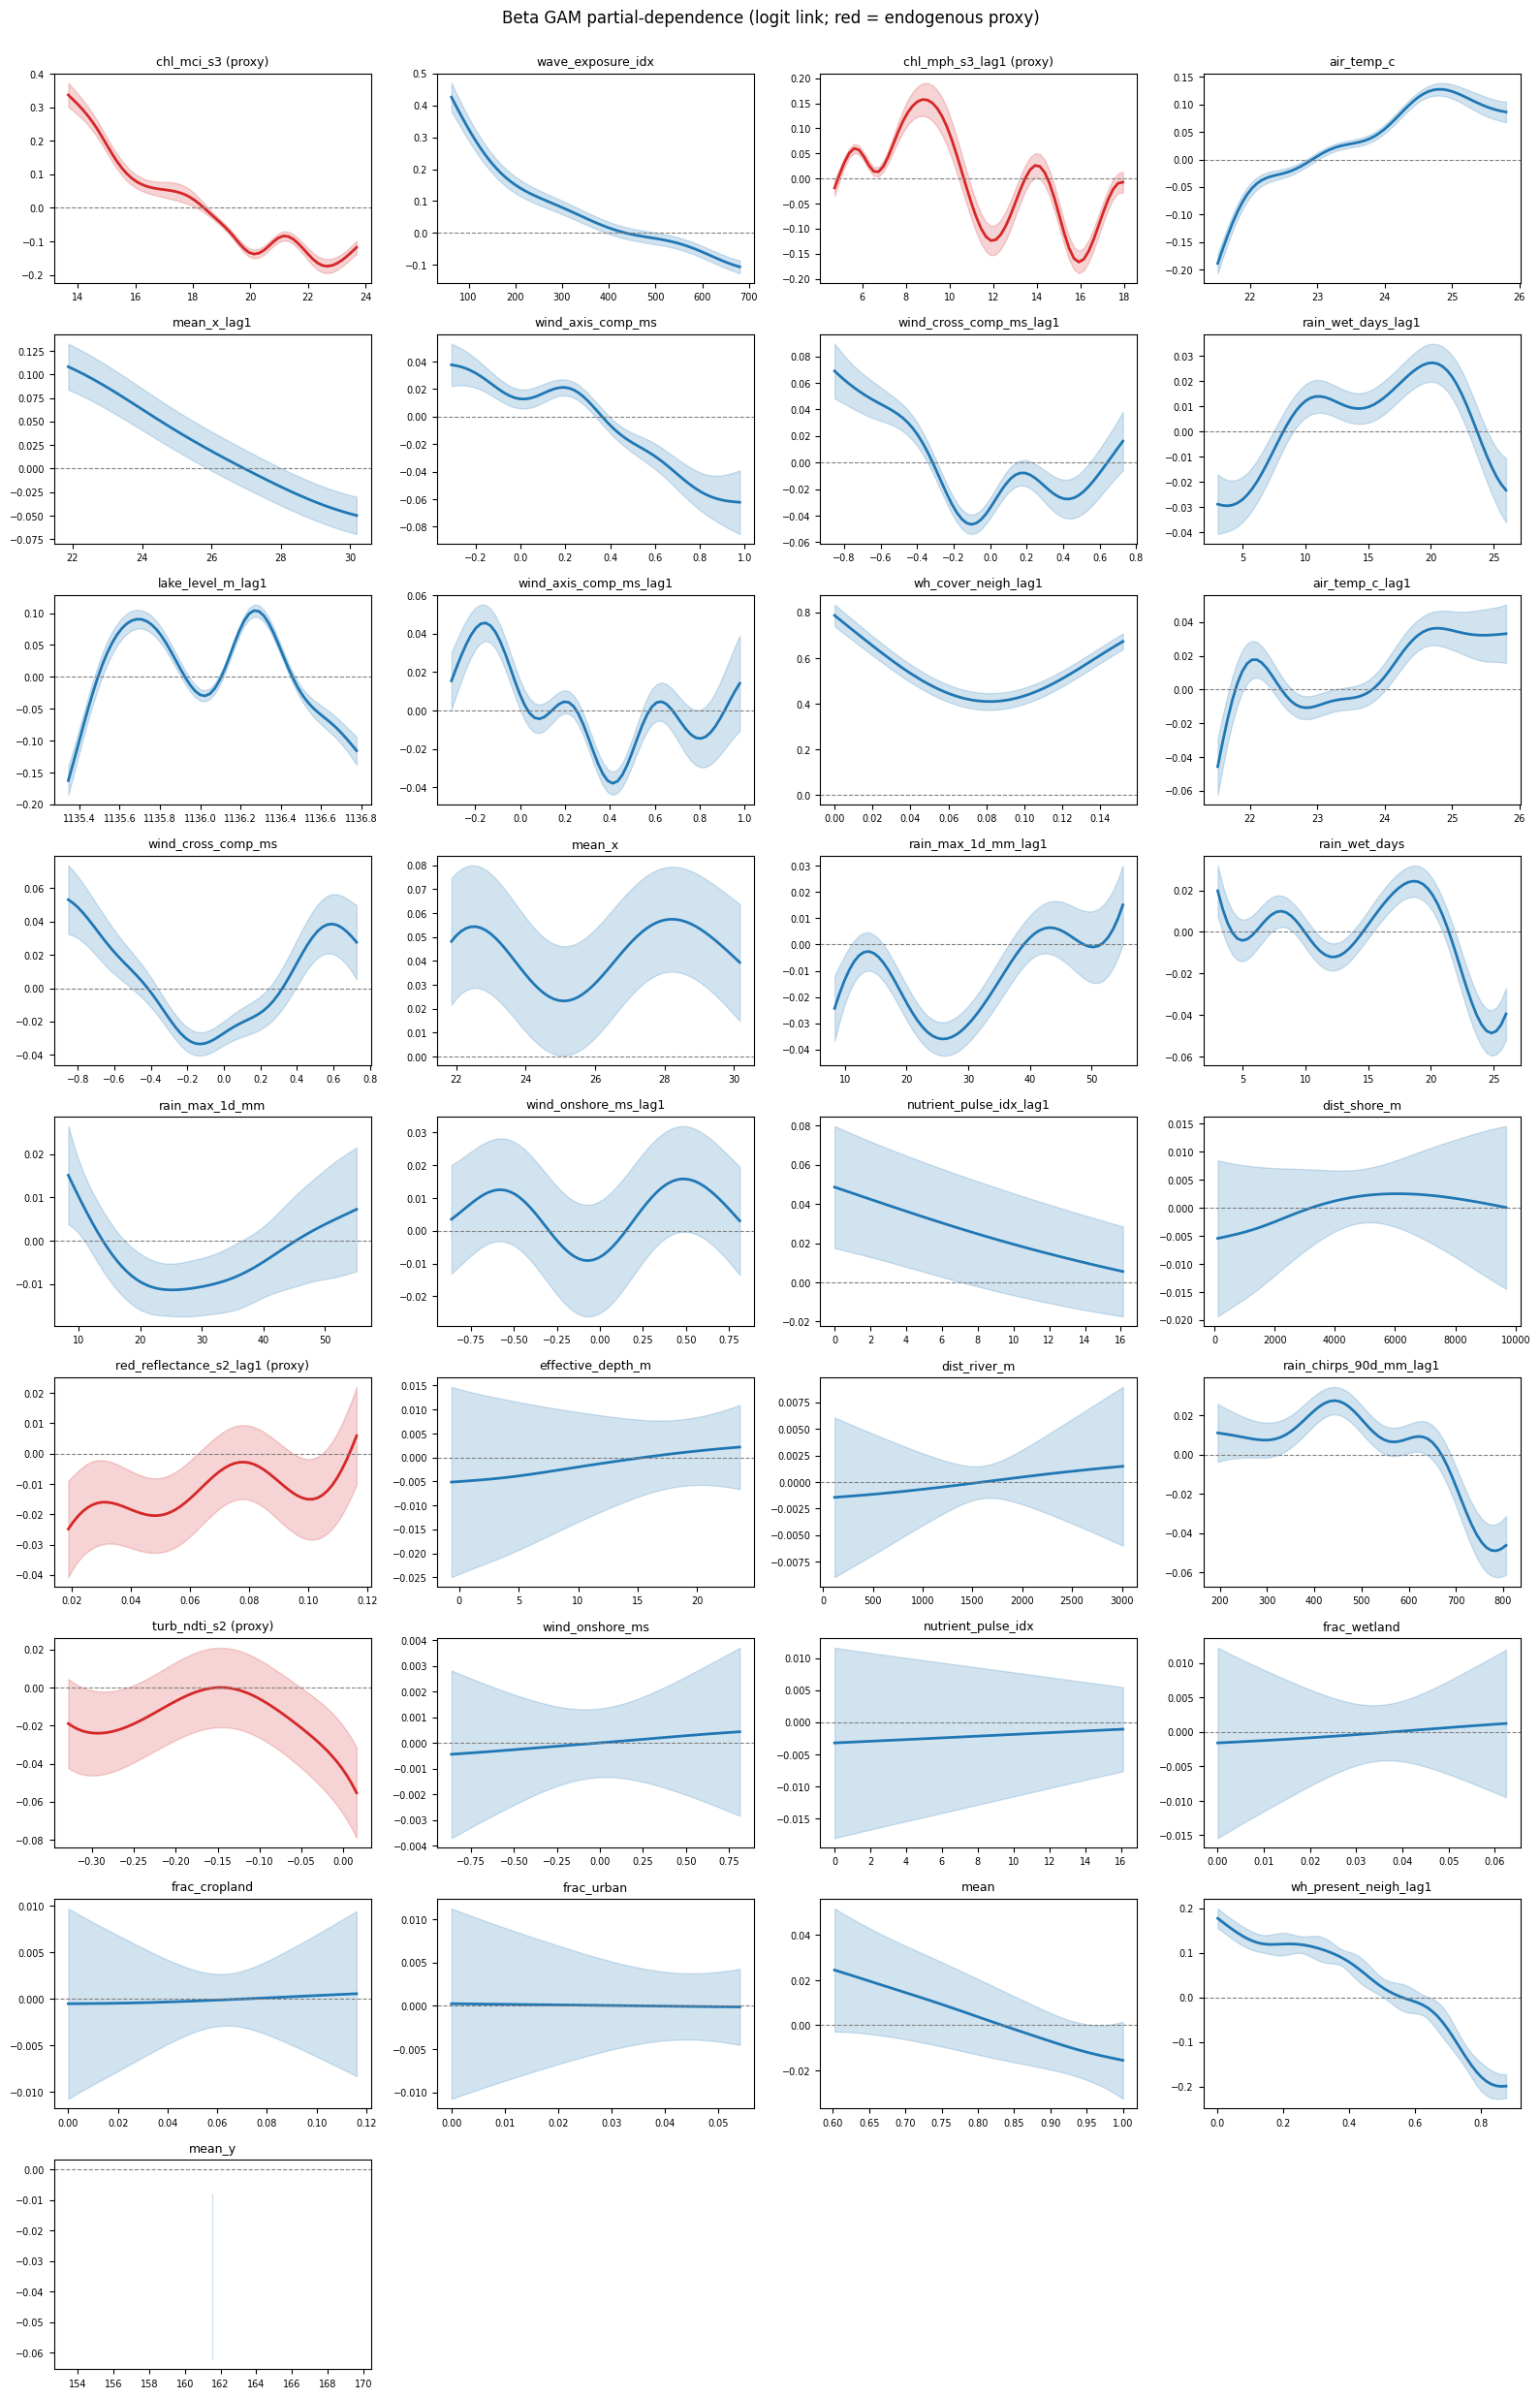

Saved /content/drive/MyDrive/WH_spatial_panel_test/gam_tweedie_pdep_500m.png


In [57]:
# --- GAM fit statistics, concurvity, effect sizes, partial-dependence plots ---
import matplotlib.pyplot as plt
pd.set_option("display.max_rows", 200)

# Family/link labels reflect the ACTUAL fitted family (GAM_FAMILY, set in §13): betar -> logit
# link (predictions bounded on [0, 1]); anything else -> Tweedie/log. This keeps the headings and
# the effect-size units honest so logit-link changes are not misread as log-link ones.
_fam = str(globals().get("GAM_FAMILY", "tw")).lower()
_is_beta = _fam in ("betar", "beta")
_fam_label = "Beta" if _is_beta else "Tweedie"
_link_label = "logit link" if _is_beta else "log link"

print(f"One-stage {_fam_label} GAM — fit statistics:"); display(fit_stats)
print("\nBasis-dimension adequacy (mgcv k.check; k-index < 1 with low p & edf near k' -> raise that term's k):")
try:
    display(kcheck_df.sort_values("p_value").reset_index(drop=True))
except Exception as _e:
    print("  k.check table unavailable:", _e)
_n = int(fit_stats["n"].iloc[0]) if ("n" in fit_stats.columns and len(fit_stats)) else len(model_df)
print(f"\nInference note (dependence-aware): with n = {_n:,} autocorrelated cell-months, frequentist")
print("p-values are anti-conservative, so inference leans on effect sizes (with partial-dependence")
print("bands), deviance explained, and out-of-sample skill under spatial- and temporal-block CV.")
print("Temporal within-cell dependence is modelled via the AR1 term (rho); large-scale spatial")
print("structure via te(x_km, y_km); residual dependence is checked below on AR1-standardized residuals.")
print("\nWorst-case concurvity (0 = independent, 1 = fully confounded with another term):")
display(concurvity_df.sort_values("worst", ascending=False).reset_index(drop=True))
print(f"\nFull-model per-driver effect sizes (change on the {_link_label} across p10->p90):")
display(eff_table.reset_index(drop=True))
print("\nForcing-only (causal) model effect sizes:")
display(eff_table_forcing.reset_index(drop=True))

# High-concurvity caveat: with worst-case concurvity ~1, individual smooth signs are NOT
# separable and must not be read as causal effects. The clearest symptom is wh_present_neigh_lag1
# turning negative purely through spatial confounding with te(x_km, y_km) -- ecologically it
# should be positive. Flag every smooth whose worst-case concurvity crosses the threshold.
_HI_CONCURVITY = 0.90
try:
    _cc = concurvity_df.rename(columns={"term": "cc_term", "worst": "cc_worst"})[["cc_term", "cc_worst"]]
    _eff_cc = eff_table[["term"]].copy()
    _eff_cc["cc_term"] = "s(" + _eff_cc["term"].astype(str) + ")"
    _flag = _eff_cc.merge(_cc, on="cc_term", how="left")
    _flag = _flag[_flag["cc_worst"] >= _HI_CONCURVITY].sort_values("cc_worst", ascending=False)
    if len(_flag):
        print(f"\n[concurvity caveat] {len(_flag)} smooth term(s) have worst-case concurvity "
              f">= {_HI_CONCURVITY:.2f}; their partial-dependence signs are confounded (mainly with "
              "te(x_km, y_km)) and should NOT be read as causal:")
        print("  " + ", ".join(_flag["term"].astype(str).tolist()))
        print("  e.g. wh_present_neigh_lag1's negative sign is a spatial-confounding artefact, "
              "not ecology. Lean on the drivers-carry-space contrast (§13c) for interpretable signs.")
except Exception as _e:
    print("  concurvity caveat skipped:", _e)

terms = list(eff_table["term"])
ncol = 4; nrow = int(np.ceil(len(terms) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 2.8 * nrow), squeeze=False)
flat = axes.ravel()
for ax, t in zip(flat, terms):
    d = pdep_table[pdep_table["term"] == t]
    role = d["role"].iloc[0] if len(d) else "forcing"
    col = "C3" if role == "proxy" else "C0"
    ax.plot(d["x"], d["pdep"], color=col, lw=2)
    ax.fill_between(d["x"], d["lo"], d["hi"], color=col, alpha=0.2)
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.set_title(t + (" (proxy)" if role == "proxy" else ""), fontsize=9)
    ax.tick_params(labelsize=7)
for ax in flat[len(terms):]:
    ax.set_visible(False)
fig.suptitle(f"{_fam_label} GAM partial-dependence ({_link_label}; red = endogenous proxy)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.98])
# NB: the "gam_tweedie_*" stem is a legacy artifact tag kept for parity with the sibling
# notebook and the outputs inventory; it does NOT imply the fit is Tweedie (see _fam_label).
_pdep_png = OUTPUT_DIR / f"gam_tweedie_pdep_{CELL_SIZE_M}m.png"
fig.savefig(_pdep_png, dpi=150, bbox_inches="tight"); plt.show()
print("Saved", _pdep_png)


In [58]:
# --- Residual autocorrelation: spatial (Moran's I) + temporal (lag-1) --------
# Does te(x_km,y_km) + s(grid_id) absorb the spatial signal, and do the seasonal
# smooth + trend + lagged covariates absorb the temporal signal?
_rk = resid_df["resid_kind"].iloc[0] if ("resid_kind" in resid_df.columns and len(resid_df)) else "deviance"
_msg = ("AR1-whitened: dependence below is what REMAINS after the AR1 correction" if _rk != "deviance"
        else "no AR1 applied")
print(f"Residual-dependence diagnostics use {_rk} residuals ({_msg}).")
try:
    from libpysal.weights import KNN
    from esda.moran import Moran
    _agg = resid_df.groupby("grid_id", as_index=False).agg(
        x_km=("x_km", "mean"), y_km=("y_km", "mean"), resid=("resid", "mean"))
    if len(_agg) >= 10:
        w = KNN.from_array(_agg[["x_km", "y_km"]].values, k=min(8, len(_agg) - 1)); w.transform = "r"
        mi = Moran(_agg["resid"].values, w, permutations=999)
        print(f"Spatial residual Moran's I = {mi.I:.4f} (p = {mi.p_sim:.4f}) over {len(_agg):,} cells")
        print("  -> " + ("residual spatial autocorrelation remains; raise GAM_K_SPATIAL or add a "
                          "finer spatial term." if mi.p_sim < 0.05 else
                          "no significant residual SAC; the spatial terms are sufficient."))
except Exception as exc:
    print("Spatial Moran's I skipped:", repr(exc))

_r = resid_df.sort_values(["grid_id", "time_rank"]).copy()
_r["resid_lag1"] = _r.groupby("grid_id")["resid"].shift(1)
# Pair only rows the AR1 treated as consecutive: the fit's AR.start starts a new segment at each
# cell boundary AND at any within-cell month gap (time_rank step != 1). Measuring lag-1 across
# those gaps re-introduces boundaries the AR1 never modelled and drove the "remaining"
# autocorrelation strongly negative (~ -0.42, a diagnostic artefact, not real over-correction).
# Keeping steps of exactly 1 reports what genuinely survives the AR1 correction.
_r["time_step"] = _r.groupby("grid_id")["time_rank"].diff()
_pair = _r[_r["time_step"] == 1].dropna(subset=["resid", "resid_lag1"])
if len(_pair) > 100:
    _rho = float(np.corrcoef(_pair["resid"], _pair["resid_lag1"])[0, 1])
    print(f"\nTemporal residual lag-1 autocorrelation (within cell) = {_rho:.4f} "
          f"over {len(_pair):,} pairs")
    print("  -> " + ("residual temporal autocorrelation remains after the AR1 correction; consider "
                      "richer lagged drivers or a higher-order temporal term." if abs(_rho) > 0.1 else
                      "weak residual temporal autocorrelation; AR1 + seasonal/trend/lag terms suffice."))


Residual-dependence diagnostics use AR1_standardized residuals (AR1-whitened: dependence below is what REMAINS after the AR1 correction).
Spatial residual Moran's I = 0.8462 (p = 0.0010) over 5,927 cells
  -> residual spatial autocorrelation remains; raise GAM_K_SPATIAL or add a finer spatial term.

Temporal residual lag-1 autocorrelation (within cell) = -0.4127 over 528,267 pairs
  -> residual temporal autocorrelation remains after the AR1 correction; consider richer lagged drivers or a higher-order temporal term.


### 13c. Track B — parsimonious causal contrast (drivers-carry-space vs spatially-controlled)

Nearly every driver smooth concurves with the fine spatial term (`te(x,y)`, or the MRF surface when `GAM_SPATIAL_BASIS="mrf"`) at ~1.0, so a blind concurvity-prune would delete the model. Instead, fit the forcing-only drivers with vs without the fine spatial term and report the trade-off (concurvity ↓ vs residual spatial autocorrelation ↑). Reuses the §13 fit machinery, so run the §13 fit cell first.

In [59]:
# =====================================================================
# TRACK B — Parsimonious causal contrast: does te(x,y) confound the drivers?
# =====================================================================
# The §13 concurvity table shows nearly every driver smooth sitting at worst ~1.0:
# the environmental forcings are spatially structured, te(x_km, y_km) is spatially
# structured, so mgcv cannot separate "these conditions" from "this place" and the
# double penalty (select=TRUE) shrinks the drivers toward zero. A blind
# concurvity-prune would therefore delete almost every term. The honest fix is to
# CHOOSE which structure carries the spatial signal and show the trade-off:
#   * spatially-controlled  : keep te(x,y); drivers are confounded (already fit in
#     §13 as the forcing-only model -> eff_table_forcing).
#   * drivers-carry-space   : drop the fine te(x,y), keep only a COARSE large-scale
#     trend, so the drivers absorb the spatial gradient and become interpretable --
#     at the documented cost of higher residual spatial autocorrelation.
# This cell builds the drivers-carry-space formula; the next (R) cell fits it and
# the one after contrasts the two on effect size, concurvity and residual Moran's I.

GAM_RUN_CAUSAL_CONTRAST  = True
GAM_CAUSAL_SPATIAL_TREND = "linear"   # coarse trend kept so only the GROSS gradient is removed:
                                      # "linear" (x_km + y_km), "coarse_te" (te k=5), or "none"

if not GAM_RUN_CAUSAL_CONTRAST:
    r_formula_causal = ""
    print("GAM_RUN_CAUSAL_CONTRAST is False; skipping the drivers-carry-space contrast.")
elif "forcing_cols" not in globals() or not forcing_cols:
    r_formula_causal = ""
    print("No forcing_cols in scope; run the §12 GAM-frame builder cell first.")
else:
    def _sm_b(cols):
        return " + ".join(f"s({c}, k={GAM_K_DRIVER}, bs='tp')" for c in cols)
    _trend_b = {"linear": " + x_km + y_km",
                "coarse_te": " + te(x_km, y_km, k=c(5,5))",
                "none": ""}.get(GAM_CAUSAL_SPATIAL_TREND, " + x_km + y_km")
    _ctrl_b = (" + " + " + ".join(control_cols)) if control_cols else ""
    r_formula_causal = (f"{RESPONSE} ~ {_sm_b(forcing_cols)} "
                        f"+ s({season_col}, bs='cc', k={GAM_K_SEASON}){_trend_b}{_ctrl_b}")
    print("Drivers-carry-space forcing formula (coarse spatial trend =",
          f"'{GAM_CAUSAL_SPATIAL_TREND}'):\n ", r_formula_causal)


Drivers-carry-space forcing formula (coarse spatial trend = 'linear'):
  wh_cover ~ s(mean_x, k=10, bs='tp') + s(rain_max_1d_mm, k=10, bs='tp') + s(rain_wet_days, k=10, bs='tp') + s(mean_y, k=10, bs='tp') + s(air_temp_c, k=10, bs='tp') + s(wind_axis_comp_ms, k=10, bs='tp') + s(wind_cross_comp_ms, k=10, bs='tp') + s(wave_exposure_idx, k=10, bs='tp') + s(nutrient_pulse_idx, k=10, bs='tp') + s(lake_level_m_lag1, k=10, bs='tp') + s(mean_x_lag1, k=10, bs='tp') + s(rain_chirps_90d_mm_lag1, k=10, bs='tp') + s(rain_max_1d_mm_lag1, k=10, bs='tp') + s(rain_wet_days_lag1, k=10, bs='tp') + s(air_temp_c_lag1, k=10, bs='tp') + s(wind_axis_comp_ms_lag1, k=10, bs='tp') + s(wind_cross_comp_ms_lag1, k=10, bs='tp') + s(nutrient_pulse_idx_lag1, k=10, bs='tp') + s(dist_river_m, k=10, bs='tp') + s(dist_shore_m, k=10, bs='tp') + s(mean, k=10, bs='tp') + s(frac_cropland, k=10, bs='tp') + s(frac_urban, k=10, bs='tp') + s(frac_wetland, k=10, bs='tp') + s(wh_cover_neigh_lag1, k=10, bs='tp') + s(wh_present_neigh_

In [60]:
%%R -i r_formula_causal -i GAM_RUN_CAUSAL_CONTRAST -o eff_table_causal -o concurvity_causal -o fit_stats_causal -o resid_causal_df
# Fit the drivers-carry-space forcing model, reusing the fit machinery defined in the §13 fit
# cell (fit_one, effects_for, concurvity_safe, rho_used, ar_start all persist in this R session).
suppressMessages(library(mgcv))
eff_table_causal  <- data.frame(term = character(0), role = character(0),
                                effect_p10_p90_link = numeric(0), curvature = numeric(0))
concurvity_causal <- data.frame(term = character(0), worst = numeric(0))
fit_stats_causal  <- data.frame()
resid_causal_df   <- data.frame()

run_it <- tryCatch(isTRUE(as.logical(GAM_RUN_CAUSAL_CONTRAST)[1]), error = function(e) FALSE)
if (!run_it || !nzchar(as.character(r_formula_causal)[1])) {
  cat("GAM_RUN_CAUSAL_CONTRAST is False (or no formula); skipping the drivers-carry-space fit.\n")
} else if (!exists("fit_one") || !exists("effects_for") || !exists("concurvity_safe")) {
  cat("Run the §13 GAM fit cell first: the drivers-carry-space contrast reuses fit_one() /\n",
      "effects_for() / concurvity_safe() from that cell's R session.\n", sep = "")
} else {
  m_causal <- fit_one(as.character(r_formula_causal)[1],
                      "forcing-only DRIVERS-CARRY-SPACE (coarse trend, no fine te)",
                      rho_used, ar_start)
  sc  <- summary(m_causal)
  fdr <- driver_roles[driver_roles$role == "forcing", ]
  fc  <- effects_for(m_causal, as.character(fdr$term), as.character(fdr$role), FALSE)
  eff_table_causal <- fc$eff[order(-abs(fc$eff$effect_p10_p90_link)), ]

  cc <- tryCatch(concurvity_safe(m_causal),
                 error = function(e) { cat("concurvity skipped:", conditionMessage(e), "\n"); NULL })
  if (!is.null(cc))
    concurvity_causal <- data.frame(term = colnames(cc), worst = as.numeric(cc["worst", ]))

  fit_stats_causal <- data.frame(model = "forcing_drivers_carry_space", n = sc$n,
                                 dev_expl = as.numeric(sc$dev.expl), edf_total = sum(sc$edf),
                                 aic = AIC(m_causal), rho = rho_used)

  whit <- !is.null(m_causal$std.rsd) && length(m_causal$std.rsd) == nrow(gam_df)
  rv   <- if (whit) as.numeric(m_causal$std.rsd) else as.numeric(residuals(m_causal, type = "deviance"))
  resid_causal_df <- data.frame(grid_id = as.character(gam_df$grid_id), x_km = gam_df$x_km,
                                y_km = gam_df$y_km, time_rank = gam_df$time_rank,
                                resid = rv,
                                resid_kind = if (whit) "AR1_standardized" else "deviance")
  cat(sprintf("\nDrivers-carry-space forcing model: deviance explained = %.1f%% (rho = %.3f)\n",
              100 * sc$dev.expl, rho_used))
  print(sc)
}



==== fitting forcing-only DRIVERS-CARRY-SPACE (coarse trend, no fine te) (nthreads = 1 , rho = 0.663 , family = betar ) ====
(concurvity on a 20,000-row subsample of 537,068)

Drivers-carry-space forcing model: deviance explained = 29.5% (rho = 0.663)

Family: Beta regression(38.858) 
Link function: logit 

Formula:
wh_cover ~ s(mean_x, k = 10, bs = "tp") + s(rain_max_1d_mm, k = 10, 
    bs = "tp") + s(rain_wet_days, k = 10, bs = "tp") + s(mean_y, 
    k = 10, bs = "tp") + s(air_temp_c, k = 10, bs = "tp") + s(wind_axis_comp_ms, 
    k = 10, bs = "tp") + s(wind_cross_comp_ms, k = 10, bs = "tp") + 
    s(wave_exposure_idx, k = 10, bs = "tp") + s(nutrient_pulse_idx, 
    k = 10, bs = "tp") + s(lake_level_m_lag1, k = 10, bs = "tp") + 
    s(mean_x_lag1, k = 10, bs = "tp") + s(rain_chirps_90d_mm_lag1, 
    k = 10, bs = "tp") + s(rain_max_1d_mm_lag1, k = 10, bs = "tp") + 
    s(rain_wet_days_lag1, k = 10, bs = "tp") + s(air_temp_c_lag1, 
    k = 10, bs = "tp") + s(wind_axis_comp_ms_lag1, k 

In [61]:
# --- Track B: contrast the two causal models (interpretability vs residual SAC) --
# Side-by-side of the spatially-controlled forcing model (§13, te(x,y) kept) and the
# drivers-carry-space model (coarse trend only), on: per-driver effect size, worst
# concurvity, deviance explained, and residual spatial autocorrelation (same KNN
# Moran's I machinery as §13's residual-diagnostics cell).
import numpy as np
import pandas as pd

if not globals().get("GAM_RUN_CAUSAL_CONTRAST", False) or not len(globals().get("eff_table_causal", [])):
    print("No drivers-carry-space contrast available (GAM_RUN_CAUSAL_CONTRAST off or the R fit "
          "produced no output). Run the two cells above first.")
else:
    def _moran(resid_df):
        try:
            from libpysal.weights import KNN
            from esda.moran import Moran
            agg = resid_df.groupby("grid_id", as_index=False).agg(
                x_km=("x_km", "mean"), y_km=("y_km", "mean"), resid=("resid", "mean"))
            if len(agg) < 10:
                return np.nan, np.nan, len(agg)
            w = KNN.from_array(agg[["x_km", "y_km"]].values, k=min(8, len(agg) - 1)); w.transform = "r"
            mi = Moran(agg["resid"].values, w, permutations=999)
            return float(mi.I), float(mi.p_sim), len(agg)
        except Exception as exc:
            print("  Moran's I skipped:", repr(exc))
            return np.nan, np.nan, np.nan

    # residual SAC for both models
    mi_ctrl = _moran(resid_df) if "resid_df" in globals() and len(resid_df) else (np.nan, np.nan, np.nan)
    mi_free = _moran(resid_causal_df) if len(resid_causal_df) else (np.nan, np.nan, np.nan)

    worst_ctrl = (concurvity_df.loc[concurvity_df["term"].str.startswith("s("), "worst"].max()
                  if "concurvity_df" in globals() and len(concurvity_df) else np.nan)
    worst_free = (concurvity_causal.loc[concurvity_causal["term"].str.startswith("s("), "worst"].max()
                  if len(concurvity_causal) else np.nan)
    dev_ctrl = (fit_stats.loc[fit_stats["model"] == "forcing_only", "dev_expl"].iloc[0]
                if "fit_stats" in globals() and (fit_stats["model"] == "forcing_only").any() else np.nan)
    dev_free = (fit_stats_causal["dev_expl"].iloc[0] if len(fit_stats_causal) else np.nan)

    summary = pd.DataFrame({
        "model": ["spatially_controlled (te kept)", "drivers_carry_space (coarse trend)"],
        "dev_explained": [dev_ctrl, dev_free],
        "worst_smooth_concurvity": [worst_ctrl, worst_free],
        "resid_moran_I": [mi_ctrl[0], mi_free[0]],
        "resid_moran_p": [mi_ctrl[1], mi_free[1]],
    })
    pd.set_option("display.float_format", lambda v: f"{v:.4f}")
    print("== Causal-model contrast ==")
    print(summary.to_string(index=False))
    print("\nRead: moving from te(x,y) to a coarse trend should DROP worst-smooth concurvity\n"
          "(drivers become separable/interpretable) while RAISING residual Moran's I (the price\n"
          "is unmodelled spatial autocorrelation). Report whichever matches the claim you make:\n"
          "spatially-controlled for 'net of location', drivers-carry-space for interpretable effects.")

    # side-by-side effect sizes (p10->p90 on the link)
    a = (eff_table_forcing[["term", "effect_p10_p90_link"]]
         .rename(columns={"effect_p10_p90_link": "eff_spatially_controlled"})
         if "eff_table_forcing" in globals() else pd.DataFrame(columns=["term", "eff_spatially_controlled"]))
    b = (eff_table_causal[["term", "effect_p10_p90_link"]]
         .rename(columns={"effect_p10_p90_link": "eff_drivers_carry_space"}))
    eff_contrast = a.merge(b, on="term", how="outer")
    eff_contrast["abs_max"] = eff_contrast[["eff_spatially_controlled",
                                            "eff_drivers_carry_space"]].abs().max(axis=1)
    eff_contrast = eff_contrast.sort_values("abs_max", ascending=False).drop(columns="abs_max")
    print("\n== Per-driver effect size: spatially-controlled vs drivers-carry-space (top 15) ==")
    print(eff_contrast.head(15).to_string(index=False))

    _ts = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    _cell = int(globals().get("CELL_SIZE_M", 500))
    eff_contrast.to_csv(OUTPUT_DIR / f"gam_causal_contrast_effects_{_cell}m_{_ts}.csv", index=False)
    summary.to_csv(OUTPUT_DIR / f"gam_causal_contrast_summary_{_cell}m_{_ts}.csv", index=False)
    print(f"\nSaved causal-contrast tables to {OUTPUT_DIR} (suffix {_ts}).")


== Causal-model contrast ==
                             model  dev_explained  worst_smooth_concurvity  resid_moran_I  resid_moran_p
    spatially_controlled (te kept)         0.2879                   1.0000         0.8462         0.0010
drivers_carry_space (coarse trend)         0.2948                   1.0000         0.8637         0.0010

Read: moving from te(x,y) to a coarse trend should DROP worst-smooth concurvity
(drivers become separable/interpretable) while RAISING residual Moran's I (the price
is unmodelled spatial autocorrelation). Report whichever matches the claim you make:
spatially-controlled for 'net of location', drivers-carry-space for interpretable effects.

== Per-driver effect size: spatially-controlled vs drivers-carry-space (top 15) ==
                   term  eff_spatially_controlled  eff_drivers_carry_space
      wave_exposure_idx                   -0.2604                  -0.2104
             air_temp_c                    0.0728                   0.0553
      

### Dependence-aware cross-validation (spatial + temporal blocking)

Honest skill for the one-stage GAM: rolling-origin **temporal** folds (predict the next month)
and **spatial block** folds (predict held-out 10 km blocks). The CV model **drops the random
cell effect** `s(grid_id)` — a per-cell intercept cannot transfer to unseen cells or months — so
these scores reflect the *generalisable* forcing + spatial-surface + seasonal signal (Roberts et
al. 2017; Ploton et al. 2020). For a Tweedie fit the variance power is fixed at the full-model estimate so folds are
stable and comparable.

In [ ]:
%%R -i gam_df -i r_formula_cv -i GAM_RUN_CV_R -i GAM_BAM_NTHREADS -i GAM_BAM_CHUNK -i GAM_BAM_GCLEVEL -i GAM_FAMILY -i GAM_CLIP_PRED_01 -i GAM_ADD_CV_BASELINES -o cv_results -o cv_baselines
suppressMessages(library(mgcv))
cv_results <- data.frame(); cv_baselines <- data.frame()
if (as.logical(GAM_RUN_CV_R)[1]) {
  gam_df$grid_id <- factor(gam_df$grid_id)
  nth <- as.integer(GAM_BAM_NTHREADS)[1]
  if (is.na(nth) || nth < 1L) nth <- tryCatch(max(1L, parallel::detectCores()), error = function(e) 1L)
  chunk_sz <- as.integer(GAM_BAM_CHUNK)[1]; gc_lvl <- as.integer(GAM_BAM_GCLEVEL)[1]
  fam_name  <- tryCatch(tolower(as.character(GAM_FAMILY)[1]), error = function(e) "tw")
  use_betar <- identical(fam_name, "betar")
  clip01    <- tryCatch(isTRUE(as.logical(GAM_CLIP_PRED_01)[1]),  error = function(e) TRUE)
  add_base  <- tryCatch(isTRUE(as.logical(GAM_ADD_CV_BASELINES)[1]), error = function(e) TRUE)

  # Keep a raw (unsqueezed) response for honest metrics; squeeze only the FITTING target for betar.
  gam_df$wh_cover_obs <- gam_df$wh_cover
  if (use_betar) {
    ny <- nrow(gam_df); gam_df$wh_cover <- (gam_df$wh_cover * (ny - 1) + 0.5) / ny
    cv_family <- function() tryCatch(mgcv::betar(link = "logit"), error = function(e) tw())
    cat("CV family: betar (logit).\n")
  } else {
    # Fix the Tweedie power on the full data so each fold is stable and comparable.
    m0 <- bam(as.formula(r_formula_cv), data = gam_df, family = tw(), method = "fREML", select = TRUE,
              discrete = TRUE, knots = list(month_num = c(0.5, 12.5)), nthreads = nth,
              chunk.size = chunk_sz, gc.level = gc_lvl)
    p_fix <- as.numeric(m0$family$getTheta(TRUE)); rm(m0); gc()
    cv_family <- function() Tweedie(p = p_fix)
    cat(sprintf("CV family: Tweedie (fixed p = %.3f).\n", p_fix))
  }

  metrics <- function(obs, p) {
    if (clip01) p <- pmin(pmax(p, 0), 1)
    data.frame(spearman = suppressWarnings(cor(obs, p, method = "spearman")),
               rmse = sqrt(mean((obs - p)^2)), mae = mean(abs(obs - p)),
               area_recovery = ifelse(sum(obs) > 0, sum(p) / sum(obs), NA))
  }

  fit_eval <- function(tr, te_, kind, fold) tryCatch({
    w <- if ("obs_weight" %in% names(tr)) tr$obs_weight else NULL
    base_args <- list(formula = as.formula(r_formula_cv), data = tr, family = cv_family(),
                      method = "fREML", select = TRUE, knots = list(month_num = c(0.5, 12.5)),
                      nthreads = nth, chunk.size = chunk_sz, gc.level = gc_lvl)
    if (!is.null(w)) base_args$weights <- w
    m <- tryCatch(do.call(bam, c(base_args, list(discrete = TRUE))),
                  error = function(e) do.call(bam, c(base_args, list(discrete = FALSE))))
    p <- predict(m, newdata = te_, type = "response")   # no RE term -> no new-level error
    cbind(data.frame(model = "gam", kind = kind, fold = fold, n_train = nrow(tr), n_test = nrow(te_)),
          metrics(te_$wh_cover_obs, as.numeric(p)))
  }, error = function(e) data.frame(model = "gam", kind = kind, fold = fold, n_train = nrow(tr),
               n_test = nrow(te_), spearman = NA, rmse = NA, mae = NA, area_recovery = NA))

  # Reference baselines on the SAME folds (Task 3): persistence = last month's cover;
  # climatology = training mean cover for that calendar month. The GAM earns its keep only where
  # it beats both.
  base_eval <- function(tr, te_, kind, fold) {
    out <- list()
    if ("wh_cover_lag1" %in% names(te_)) {
      pp <- te_$wh_cover_lag1; pp[!is.finite(pp)] <- 0
      out[[length(out) + 1]] <- cbind(data.frame(model = "persistence", kind = kind, fold = fold,
                                        n_train = nrow(tr), n_test = nrow(te_)),
                                      metrics(te_$wh_cover_obs, pp))
    }
    clim <- tapply(tr$wh_cover_obs, tr$month_num, mean)
    pc <- as.numeric(clim[as.character(te_$month_num)]); pc[!is.finite(pc)] <- mean(tr$wh_cover_obs)
    out[[length(out) + 1]] <- cbind(data.frame(model = "climatology", kind = kind, fold = fold,
                                      n_train = nrow(tr), n_test = nrow(te_)),
                                    metrics(te_$wh_cover_obs, pc))
    do.call(rbind, out)
  }

  # Temporal folds must actually exist -- they were silently empty before (Task 3).
  tm_folds <- sort(unique(gam_df$fold_tm[gam_df$fold_tm > 0]))
  cat(sprintf("Spatial folds: %s | Temporal folds: %s (rows fold_tm>0: %s)\n",
              paste(sort(unique(gam_df$fold_sp)), collapse = ","),
              if (length(tm_folds)) paste(tm_folds, collapse = ",") else "NONE",
              format(sum(gam_df$fold_tm > 0), big.mark = ",")))
  if (!length(tm_folds))
    cat("WARNING: no temporal folds -> temporal CV skipped; check fold_tm in the frame-builder cell.\n")

  res <- list(); bas <- list(); k <- 1L; kb <- 1L
  for (f in sort(unique(gam_df$fold_sp))) {                       # spatial block folds
    tr <- gam_df[gam_df$fold_sp != f, ]; te_ <- gam_df[gam_df$fold_sp == f, ]
    res[[k]] <- fit_eval(tr, te_, "spatial", f); k <- k + 1L
    if (add_base) { bas[[kb]] <- base_eval(tr, te_, "spatial", f); kb <- kb + 1L }
  }
  for (f in tm_folds) {                                           # rolling-origin temporal
    cut_rank <- min(gam_df$time_rank[gam_df$fold_tm == f])
    tr <- gam_df[gam_df$time_rank < cut_rank, ]; te_ <- gam_df[gam_df$fold_tm == f, ]
    res[[k]] <- fit_eval(tr, te_, "temporal", f); k <- k + 1L
    if (add_base) { bas[[kb]] <- base_eval(tr, te_, "temporal", f); kb <- kb + 1L }
  }
  cv_results <- do.call(rbind, res)
  if (add_base && length(bas)) cv_baselines <- do.call(rbind, bas)
  cat("\n-- GAM CV --\n"); print(cv_results)
  if (nrow(cv_baselines)) { cat("\n-- Baselines --\n"); print(cv_baselines) }
} else {
  cat("GAM_RUN_CV is False; skipping cross-validation.\n")
}


CV family: betar (logit).
Spatial folds: 1,2,3,4,5 | Temporal folds: 1,2,3,4 (rows fold_tm>0: 23,484)


In [ ]:
# --- CV summary + save GAM outputs -------------------------------------------
import datetime as _dt
try:
    _have_cv = cv_results is not None and len(cv_results) > 0
except Exception:
    _have_cv = False
if _have_cv:
    print("Cross-validation by block type (mean +/- sd):")
    display(cv_results.groupby("kind")[["spearman", "rmse", "mae", "area_recovery"]]
            .agg(["mean", "std"]).round(3))
    print("\nPer-fold detail:"); display(cv_results)
    try:
        if "cv_baselines" in globals() and cv_baselines is not None and len(cv_baselines):
            print("\nModel vs baselines on the same folds "
                  "(persistence = last month; climatology = training monthly mean):")
            _gam = cv_results.copy()
            if "model" not in _gam.columns:
                _gam["model"] = "gam"
            _cmp = pd.concat([_gam, cv_baselines], ignore_index=True)
            display(_cmp.groupby(["kind", "model"])[["spearman", "rmse", "mae", "area_recovery"]]
                    .mean().round(3))
            print("Read: the GAM is only useful where it beats BOTH baselines on Spearman/RMSE.")
    except Exception as _e:
        print("Baseline comparison skipped:", _e)
    print("\nInterpretation: compare spatial-block vs temporal skill. A large temporal drop means "
          "the model extrapolates poorly forward in time (expected for a drifting invasive); a "
          "large spatial drop means it leans on local structure and transfers poorly across space.")
else:
    print("No CV results to summarise (GAM_RUN_CV was False or all folds failed).")

_stamp = _dt.datetime.now().strftime("%Y%m%d_%H%M%S")
for _name, _tab in [("gam_tweedie_effects", eff_table),
                    ("gam_tweedie_effects_forcing", eff_table_forcing),
                    ("gam_tweedie_pdep", pdep_table),
                    ("gam_tweedie_concurvity", concurvity_df),
                    ("gam_tweedie_fit_stats", fit_stats),
                    ("gam_tweedie_kcheck", kcheck_df if len(kcheck_df) else None),
                    ("gam_tweedie_cv", cv_results if _have_cv else None),
                    ("gam_tweedie_cv_baselines",
                     cv_baselines if ("cv_baselines" in globals() and _have_cv
                                      and cv_baselines is not None and len(cv_baselines)) else None)]:
    if _tab is not None:
        _p = OUTPUT_DIR / f"driver_{_name}_{CELL_SIZE_M}m_{_stamp}.csv"
        _tab.to_csv(_p, index=False); print("Saved", _p)


### 13d. Ordered-Beta cross-check (change 1: the statistically-correct 0/1-inflated response)

The one-stage §13 model uses `betar`, which needs the exact 0/1 **squeezed** off the boundary
(Smithson & Verkuilen 2006) -- a workaround, not a model of the boundary mass. An **ordered-Beta**
regression (Kubinec 2023) instead treats the **zero-spike**, the continuous (0,1) interior and the
**one-spike** as one coherent likelihood, so it is the correct response for a proportion with point
mass at the bounds and it can actually fit the dense mats the `betar` model under-predicts.

Neither `ordbetareg` (brms/Stan) nor `glmmTMB` fits the full ~1.1M-row panel in-notebook, so this
cross-check fits a **stratified subsample** (or run the whole panel at `CELL_SIZE_M = 1000` and it is
small enough) with a reduced smooth structure on the **forcing (causal) drivers**. It is a
model-adequacy cross-check of the §13 betar fit, not a replacement -- compare the fitted upper tail
and the driver signs. Feature-flagged by `GAM_RUN_ORDBETA`; needs `glmmTMB` (fast; `family=ordbeta()`)
or `ordbetareg` (the reference implementation, pulls brms/Stan) installed in the R runtime, and it
degrades to a printed install hint if neither is present. `glmmTMB`'s mgcv-smooth support is newer
than brms's, so if a smooth term is rejected there, set `GAM_ORDBETA_ENGINE = "ordbetareg"`.

In [ ]:
# ---- 13d. Ordered-Beta cross-check: build the subsample + formula (change 1) ----
import numpy as np, pandas as pd

GAM_RUN_ORDBETA       = True
GAM_ORDBETA_ENGINE    = "glmmTMB"    # "glmmTMB" (fast; family=ordbeta()) or "ordbetareg" (brms/Stan)
GAM_ORDBETA_MAX_ROWS  = 60000        # stratified-subsample cap (None -> all rows; use at 1 km)
GAM_ORDBETA_USE_RE    = False        # include (1 | grid_id); heavy with many cells
GAM_ORDBETA_K_DRIVER  = 6            # basis per driver smooth (smaller than the main GAM)
GAM_ORDBETA_K_SPATIAL = 12           # basis of the t2(x_km, y_km) spatial surface
GAM_ORDBETA_ITER      = 1000         # ordbetareg/brms only: MCMC iterations
GAM_ORDBETA_CHAINS    = 2            # ordbetareg/brms only: chains

ordbeta_df = None
ordbeta_formula = ""
if GAM_RUN_ORDBETA:
    _ob_drivers = [c for c in forcing_cols if c in gam_df.columns]     # forcing-only (causal) drivers
    _need = list(dict.fromkeys([RESPONSE] + _ob_drivers + ["x_km", "y_km", season_col, "grid_id"]))
    _need = [c for c in _need if c in gam_df.columns]
    _ob = gam_df[_need].dropna(subset=[RESPONSE, "x_km", "y_km", season_col]).copy()
    # Stratify by the response structure so the ordered-Beta cutpoints (zero / interior / one) stay
    # identified after subsampling.
    _ob["_stratum"] = np.where(_ob[RESPONSE] <= 0, "zero",
                        np.where(_ob[RESPONSE] >= 1, "one", "interior"))
    if GAM_ORDBETA_MAX_ROWS is not None and len(_ob) > GAM_ORDBETA_MAX_ROWS:
        _frac = GAM_ORDBETA_MAX_ROWS / len(_ob)
        _ob = _ob.groupby("_stratum").sample(frac=_frac, random_state=RANDOM_STATE)
    ordbeta_df = _ob.drop(columns="_stratum").reset_index(drop=True)
    ordbeta_df["grid_id"] = ordbeta_df["grid_id"].astype(str)
    _obs  = " + ".join(f"s({c}, k={GAM_ORDBETA_K_DRIVER})" for c in _ob_drivers)
    _obsp = f"t2(x_km, y_km, k={GAM_ORDBETA_K_SPATIAL})"
    _obre = " + (1 | grid_id)" if GAM_ORDBETA_USE_RE else ""
    ordbeta_formula = f"{RESPONSE} ~ {_obs} + s({season_col}, k=6) + {_obsp}{_obre}"
    _z = float((ordbeta_df[RESPONSE] <= 0).mean()); _o = float((ordbeta_df[RESPONSE] >= 1).mean())
    print(f"Ordered-Beta subsample: {len(ordbeta_df):,} rows on {len(_ob_drivers)} forcing drivers "
          f"(zeros {_z:.1%}, ones {_o:.2%}); engine={GAM_ORDBETA_ENGINE}.")
    print("Ordered-Beta formula:\n ", ordbeta_formula)
else:
    print("GAM_RUN_ORDBETA is False; skipping the ordered-Beta cross-check.")

In [ ]:
%%R -i ordbeta_df -i ordbeta_formula -i GAM_ORDBETA_ENGINE -i GAM_RUN_ORDBETA -i GAM_ORDBETA_ITER -i GAM_ORDBETA_CHAINS -o ordbeta_summary
# Ordered-Beta fit on the subsample (change 1). Engine-agnostic, and graceful if the package or a
# smooth term is unavailable: it prints an install hint / the error and leaves ordbeta_summary empty
# rather than aborting the notebook. Compare fitted_max here to the betar model's ~0.08 -- the
# ordered-Beta should reach much higher cover on the dense mats.
run_ob <- tryCatch(isTRUE(as.logical(GAM_RUN_ORDBETA)[1]), error = function(e) FALSE)
ordbeta_summary <- data.frame()
if (!run_ob || !exists("ordbeta_df") || is.null(ordbeta_df) || !nrow(ordbeta_df)) {
  cat("Ordered-Beta cross-check skipped (GAM_RUN_ORDBETA off or no subsample).\n")
} else {
  engine <- tryCatch(tolower(as.character(GAM_ORDBETA_ENGINE)[1]), error = function(e) "glmmtmb")
  ordbeta_df$grid_id <- factor(ordbeta_df$grid_id)
  form  <- as.formula(as.character(ordbeta_formula)[1])
  yname <- all.vars(form)[1]
  fit_ob <- NULL; pfun <- NULL
  if (engine == "glmmtmb") {
    if (!requireNamespace("glmmTMB", quietly = TRUE)) {
      cat("glmmTMB not installed. In R run: install.packages('glmmTMB')  # family=ordbeta()\n")
    } else {
      fit_ob <- tryCatch(glmmTMB::glmmTMB(form, data = ordbeta_df, family = glmmTMB::ordbeta()),
                         error = function(e) { cat("glmmTMB ordbeta fit failed:",
                                                   conditionMessage(e), "\n"); NULL })
      pfun <- function(m) as.numeric(predict(m, type = "response"))
    }
  } else {
    if (!requireNamespace("ordbetareg", quietly = TRUE)) {
      cat("ordbetareg not installed. In R run: install.packages('ordbetareg')  # pulls brms/Stan\n")
    } else {
      fit_ob <- tryCatch(ordbetareg::ordbetareg(formula = form, data = ordbeta_df,
                            chains = as.integer(GAM_ORDBETA_CHAINS)[1],
                            iter = as.integer(GAM_ORDBETA_ITER)[1], refresh = 0),
                         error = function(e) { cat("ordbetareg fit failed:",
                                                   conditionMessage(e), "\n"); NULL })
      pfun <- function(m) as.numeric(brms::fitted(m)[, "Estimate"])
    }
  }
  if (!is.null(fit_ob)) {
    cat("\n== Ordered-Beta fit (", engine, ") ==\n", sep = "")
    print(summary(fit_ob))
    p <- tryCatch(pfun(fit_ob), error = function(e) rep(NA_real_, nrow(ordbeta_df)))
    y <- ordbeta_df[[yname]]
    if (any(is.finite(p))) {
      sp   <- suppressWarnings(cor(y, p, method = "spearman"))
      rmse <- sqrt(mean((y - p)^2, na.rm = TRUE))
      cat(sprintf("\nOrdered-Beta in-sample fit: Spearman = %.3f | RMSE = %.4f | fitted max = %.4f "
                  "(obs max = %.4f).\n", sp, rmse, max(p, na.rm = TRUE), max(y, na.rm = TRUE)))
      cat("(In-sample, so optimistic vs the §13-CV block scores; the point of the cross-check is the\n",
          " fitted upper tail and the driver signs, not this skill number.)\n", sep = "")
      ordbeta_summary <- data.frame(engine = engine, n = nrow(ordbeta_df),
                                    spearman = sp, rmse = rmse,
                                    fitted_max = max(p, na.rm = TRUE), obs_max = max(y, na.rm = TRUE))
    }
  }
}

### 13e. Fair model-family comparison (Tweedie · Beta · quasi-binomial · hurdle)

*Feature-flagged, additive benchmark (`RUN_MODEL_FAMILY_COMPARISON`). It does **not** touch the
§13 Beta fit, the §13c causal contrast, the §13-CV block CV or the §13d ordered-Beta cross-check —
those cells run and export exactly as before. This section fits four one-stage response families
**plus** a redesigned hurdle benchmark on **one shared Sentinel-2-only panel** and **identical
spatial and temporal folds**, so the families are compared like-for-like rather than across
different data or splits.*

**Why.** The §13 appraisal showed the bounded Beta fit is *honest* but under-predicts the dense-mat
tail, while the old Tweedie fit was unbounded. Rather than argue from one family, this section scores
them side by side against the same persistence and seasonal-climatology baselines:

- **Tweedie** (`tw`, log link) — re-enabled with the current improved covariates, confidence
  weights, `te(x_km, y_km)` spatial structure and blocked CV; a full-data **AR1** fit is reported
  separately (`MFC_RUN_TWEEDIE_FULLFIT`) so its honest deviance / fitted range / ρ are on record.
- **Beta** (`betar`, logit) — the current §13 family, refit here on the shared folds.
- **Quasi-binomial** (logit) — models the WH / valid **pixel counts** directly
  (`cbind(wh_pixels, valid_pixels − wh_pixels)`) where those counts are available, so the response
  is a genuine proportion of classified pixels rather than a squeezed continuous cover.
- **Hurdle (redesigned benchmark)** — a **binomial presence** stage × a **Beta (or ordered-Beta)
  positive-cover** stage, combined as a *continuous* prediction **P(present) × E(cover | present)**
  with **no hard threshold** on the primary cover prediction.

**Two jobs kept separate.** Each family is fit in a **forcing-only** configuration (exogenous
drivers + season + spatial surface — the defensible *inferential* spec, Track B) **and** a
**predictive** configuration that adds the lagged-response terms (`wh_cover_lag1`,
`wh_cover_neigh_lag1`). The results table reports the two `mode`s separately so a lagged-response
forecaster is never confused with a forcing-only driver model.

**Reported per family × mode × fold type:** overall and positive-only **RMSE / MAE / Spearman**,
**area recovery** (Σpred / Σobs), **calibration** (slope/intercept of observed on predicted),
**fitted range** (min / max / q99 vs the observed q99) and **high-cover** skill on the observed
dense-mat rows (cover ≥ `MFC_HIGH_COVER_THRESHOLD`). Tweedie additionally gets a **leakage-safe,
cross-fitted out-of-fold isotonic recalibration**, reported **raw vs calibrated**.

> Runtime: this refits several families across all folds, so it is the heaviest cell in the
> notebook. Trim `MFC_FAMILIES` / `MFC_MODES` or lower the `MFC_K_*` bases for a quick pass; set
> `RUN_MODEL_FAMILY_COMPARISON = False` to skip it entirely (all earlier outputs are unaffected).

In [ ]:
# =====================================================================
# 13e. Fair model-family comparison -- shared S2-only frame + identical folds
# Additive & feature-flagged: builds ONE comparison panel and ONE set of
# spatial/temporal folds, then ships them to R (next cell) so Tweedie, Beta,
# quasi-binomial and the hurdle benchmark are all scored on the same rows and
# the same splits. Does NOT modify the §13 / §13c / §13-CV / §13d objects.
# =====================================================================
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# ---- Feature flags ----------------------------------------------------------
RUN_MODEL_FAMILY_COMPARISON = True      # master switch for §13e
MFC_S2_ONLY               = True        # score every family on the Sentinel-2-only panel
MFC_MODES                 = ["forcing", "predictive"]  # inferential (no lags) vs lagged-response
MFC_FAMILIES              = ["tweedie", "beta", "quasibinomial", "hurdle"]
MFC_HURDLE_POS_FAMILY     = "betar"     # hurdle positive-cover stage: "betar" or "ordbeta" (glmmTMB)
MFC_HIGH_COVER_THRESHOLD  = 0.20        # observed cover defining the dense-mat / high-cover subset
MFC_WEIGHT_BY_CONFIDENCE  = True        # carry classifier confidence weights into the continuous families
MFC_RUN_TWEEDIE_FULLFIT   = True        # full-data Tweedie fit with AR1 + weights (re-enabled inference)
MFC_CALIBRATE_TWEEDIE     = True        # leakage-safe cross-fitted isotonic recalibration of OOF Tweedie
# Smooth bases: smaller than the §13 fit so the many CV refits stay affordable.
MFC_K_DRIVER  = 8
MFC_K_SEASON  = 6
MFC_K_SPATIAL = 12
MFC_K_LAG     = 5
# Reuse the §13 CV design so the folds match the main GAM's blocking scheme.
MFC_N_SPATIAL_FOLDS  = int(globals().get("GAM_N_SPATIAL_FOLDS", 5))
MFC_N_TEMPORAL_FOLDS = int(globals().get("GAM_N_TEMPORAL_FOLDS", 4))
MFC_SPATIAL_BLOCK_KM = float(globals().get("GAM_SPATIAL_BLOCK_KM", 10.0))
RANDOM_STATE = int(globals().get("RANDOM_STATE", 42))
# bam() memory knobs (fall back to the §13 values, or safe defaults if §13 was not run).
GAM_BAM_NTHREADS = int(globals().get("GAM_BAM_NTHREADS", 1))
GAM_BAM_CHUNK    = int(globals().get("GAM_BAM_CHUNK", 5000))
GAM_BAM_GCLEVEL  = int(globals().get("GAM_BAM_GCLEVEL", 2))

# Placeholders so the R cell's -i / -o always have something valid to convert,
# even when the comparison is skipped or an upstream object is missing.
mfc_df = pd.DataFrame({"_placeholder": [0]})
mfc_rhs_forcing = ""; mfc_rhs_predictive = ""
mfc_modes_str = ""; mfc_families_str = ""
mfc_season_col = str(globals().get("season_col", "month_num"))
mfc_run_r = False

if not RUN_MODEL_FAMILY_COMPARISON:
    print("RUN_MODEL_FAMILY_COMPARISON is False; skipping the §13e fair comparison "
          "(all earlier §13 outputs are unchanged).")
elif "model_df" not in globals():
    print("model_df is not defined -- run §12 first; skipping the §13e fair comparison.")
else:
    RESPONSE   = str(globals().get("RESPONSE", "wh_cover"))
    season_col = str(globals().get("season_col", "month_num"))
    mfc_season_col = season_col
    mfc_families = list(MFC_FAMILIES)

    # Driver sets from §13 (already VIF-/redundancy-screened). Fall back to feature_cols.
    _forcing = [c for c in globals().get("forcing_cols", []) if c in model_df.columns]
    if not _forcing:
        _excl = {"month_sin", "month_cos", season_col, "time_index", "x_km", "y_km",
                 "wh_cover_lag1", "wh_present_lag1"}
        _forcing = [c for c in globals().get("feature_cols", []) if c not in _excl
                    and c in model_df.columns]
    # Lagged-response (autoregressive / neighbour) terms are NOT forcing: strip any
    # wh_*lag* out of the forcing set so 'forcing' mode is genuinely inferential and the
    # predictive-mode lag smooths below are never duplicated (an mgcv repeated-term error).
    def _is_lag_response(c):
        return c.startswith("wh_") and "lag" in c
    _forcing = [c for c in _forcing if not _is_lag_response(c)]
    lag_cols = [c for c in ["wh_cover_lag1", "wh_cover_neigh_lag1"] if c in model_df.columns]

    # ---- Shared comparison frame: S2-only rows -----------------------------
    src = model_df.copy()
    if MFC_S2_ONLY and "sensor_is_s1" in src.columns:
        _n0 = len(src)
        src = src[src["sensor_is_s1"] == 0].copy()
        print(f"S2-only comparison panel: kept {len(src):,} of {_n0:,} rows "
              f"(dropped {_n0 - len(src):,} S1 gap-fill rows).")
    else:
        print(f"Comparison panel: {len(src):,} rows (S2-only filter off or no sensor flag).")

    keep = list(dict.fromkeys(
        [RESPONSE, "wh_present", "grid_id", "month", "x_km", "y_km", season_col]
        + _forcing + lag_cols
        + [c for c in ["wh_pixels", "valid_pixels", "wh_conf_mean"] if c in src.columns]))
    keep = [c for c in keep if c in src.columns]
    mfc = src[keep].copy()

    # Median-impute the driver block; lag terms -> 0 (absence) so predictive rows never drop out.
    _imp = [c for c in _forcing if c in mfc.columns and mfc[c].notna().any()]
    if _imp:
        mfc[_imp] = SimpleImputer(strategy="median").fit_transform(mfc[_imp])
    for c in lag_cols:
        mfc[c] = pd.to_numeric(mfc[c], errors="coerce").fillna(0.0)
    _forcing = [c for c in _forcing if c in mfc.columns and mfc[c].notna().any()]

    mfc = mfc.dropna(subset=[RESPONSE, "x_km", "y_km", season_col, "wh_present"]).reset_index(drop=True)
    mfc["wh_present"] = mfc["wh_present"].astype(int)
    mfc[RESPONSE] = mfc[RESPONSE].clip(0.0, 1.0)

    # Pixel counts for the quasi-binomial (where available).
    have_counts = ("wh_pixels" in mfc.columns and "valid_pixels" in mfc.columns
                   and pd.to_numeric(mfc["valid_pixels"], errors="coerce").fillna(0).gt(0).any())
    if have_counts:
        mfc["valid_pixels"] = pd.to_numeric(mfc["valid_pixels"], errors="coerce").fillna(0).round().astype(int)
        mfc["wh_pixels"] = pd.to_numeric(mfc["wh_pixels"], errors="coerce").fillna(0).round().astype(int)
        mfc["wh_pixels"] = np.minimum(mfc["wh_pixels"], mfc["valid_pixels"])
        mfc = mfc[mfc["valid_pixels"] > 0].reset_index(drop=True)
        print(f"Quasi-binomial counts available: wh_pixels / valid_pixels "
              f"(median valid pixels per cell-month = {int(mfc['valid_pixels'].median())}).")
    else:
        mfc["valid_pixels"] = 0; mfc["wh_pixels"] = 0
        if "quasibinomial" in mfc_families:
            mfc_families = [f for f in mfc_families if f != "quasibinomial"]
            print("No pixel-count columns -> quasi-binomial family dropped from the comparison.")

    # Confidence weights (same source as §13's obs_weight).
    if MFC_WEIGHT_BY_CONFIDENCE and "wh_conf_mean" in mfc.columns:
        mfc["obs_weight"] = mfc["wh_conf_mean"].fillna(1.0).clip(0.1, 1.0)
    else:
        mfc["obs_weight"] = 1.0

    # ---- Identical spatial + temporal folds (reuse the §13 blocking) --------
    mfc["blk"] = ((mfc["x_km"] // MFC_SPATIAL_BLOCK_KM).astype(int).astype(str) + "_" +
                  (mfc["y_km"] // MFC_SPATIAL_BLOCK_KM).astype(int).astype(str))
    _bmap = {b: i % MFC_N_SPATIAL_FOLDS + 1 for i, b in enumerate(sorted(mfc["blk"].unique()))}
    mfc["fold_sp"] = mfc["blk"].map(_bmap).astype(int)
    _months = np.sort(mfc["month"].unique())
    mfc["time_rank"] = mfc["month"].map({m: i for i, m in enumerate(_months)}).astype(int)
    _n_tm = int(min(MFC_N_TEMPORAL_FOLDS, max(0, len(_months) - 1)))
    _tm_map = ({r: j + 1 for j, r in enumerate(range(len(_months) - _n_tm, len(_months)))}
               if _n_tm > 0 else {})
    mfc["fold_tm"] = mfc["time_rank"].map(lambda r: _tm_map.get(int(r), 0)).astype(int)
    mfc["row_id"] = np.arange(len(mfc), dtype=int)
    # AR1 (full-data Tweedie fit) needs rows consecutive within a cell and time-ordered.
    mfc = mfc.sort_values(["grid_id", "time_rank"]).reset_index(drop=True)
    mfc["grid_id"] = mfc["grid_id"].astype(str)

    # ---- Formula RHS strings (the LHS is added per family inside R) ----------
    def _sm(cols, k):
        return " + ".join(f"s({c}, k={k}, bs='tp')" for c in cols)
    _season  = f"s({season_col}, bs='cc', k={MFC_K_SEASON})"
    _spatial = f"te(x_km, y_km, k=c({MFC_K_SPATIAL},{MFC_K_SPATIAL}))"
    mfc_rhs_forcing = f"{_sm(_forcing, MFC_K_DRIVER)} + {_season} + {_spatial}"
    _lag_sm = " + ".join(f"s({c}, k={MFC_K_LAG})" for c in lag_cols) if lag_cols else ""
    mfc_rhs_predictive = mfc_rhs_forcing + (f" + {_lag_sm}" if _lag_sm else "")
    if not lag_cols and "predictive" in MFC_MODES:
        print("No lagged-response columns available -> 'predictive' mode == 'forcing' mode.")

    # Ship only what R needs.
    _ship = list(dict.fromkeys(
        [RESPONSE, "wh_present", "grid_id", "x_km", "y_km", season_col,
         "wh_pixels", "valid_pixels", "obs_weight", "fold_sp", "fold_tm", "time_rank", "row_id"]
        + _forcing + lag_cols))
    mfc_df = mfc[[c for c in _ship if c in mfc.columns]].copy()
    mfc_modes_str = ",".join(MFC_MODES)
    mfc_families_str = ",".join(mfc_families)
    mfc_run_r = len(mfc_df) > 0 and len(_forcing) > 0

    print(f"\nComparison frame: {len(mfc_df):,} rows x {mfc_df.shape[1]} cols; "
          f"{mfc_df['grid_id'].nunique():,} cells; {len(_forcing)} forcing drivers; "
          f"lags={lag_cols or 'none'}.")
    print(f"Families: {mfc_families} | Modes: {list(MFC_MODES)} | "
          f"spatial folds={MFC_N_SPATIAL_FOLDS}, temporal folds={_n_tm}.")
    print(f"WH-present prevalence (S2 panel): {mfc_df['wh_present'].mean():.3f} | "
          f"mean cover = {mfc_df[RESPONSE].mean():.4f} | obs max = {mfc_df[RESPONSE].max():.3f}.")
    print("Forcing RHS:\n ", mfc_rhs_forcing)

In [ ]:
%%R -i mfc_df -i mfc_rhs_forcing -i mfc_rhs_predictive -i mfc_modes_str -i mfc_families_str -i mfc_season_col -i mfc_run_r -i MFC_HURDLE_POS_FAMILY -i MFC_HIGH_COVER_THRESHOLD -i MFC_WEIGHT_BY_CONFIDENCE -i MFC_RUN_TWEEDIE_FULLFIT -i GAM_BAM_NTHREADS -i GAM_BAM_CHUNK -i GAM_BAM_GCLEVEL -o mfc_metrics -o mfc_baselines -o mfc_tw_oof -o mfc_tw_fullfit
# Fit every family on the SAME shared frame and the SAME folds. Each fit is wrapped in tryCatch so a
# single family/fold failure degrades to an NA metric row rather than aborting the comparison.
suppressMessages(library(mgcv))

mfc_metrics    <- data.frame()
mfc_baselines  <- data.frame()
mfc_tw_oof     <- data.frame()
mfc_tw_fullfit <- data.frame()

run_mfc <- tryCatch(isTRUE(as.logical(mfc_run_r)[1]), error = function(e) FALSE) &&
           is.data.frame(mfc_df) && nrow(mfc_df) > 0 && ("wh_cover" %in% names(mfc_df))
if (!run_mfc) {
  cat("§13e comparison skipped (no comparison frame; RUN_MODEL_FAMILY_COMPARISON off?).\n")
} else {
  mfc_df$grid_id <- factor(mfc_df$grid_id)
  hi_thr  <- tryCatch(as.numeric(MFC_HIGH_COVER_THRESHOLD)[1], error = function(e) 0.2)
  use_wt  <- tryCatch(isTRUE(as.logical(MFC_WEIGHT_BY_CONFIDENCE)[1]), error = function(e) TRUE)
  seasoncol <- tryCatch(as.character(mfc_season_col)[1], error = function(e) "month_num")
  hpos    <- tryCatch(tolower(as.character(MFC_HURDLE_POS_FAMILY)[1]), error = function(e) "betar")
  modes <- strsplit(as.character(mfc_modes_str)[1], ",", fixed = TRUE)[[1]]
  fams  <- strsplit(as.character(mfc_families_str)[1], ",", fixed = TRUE)[[1]]
  modes <- modes[nzchar(modes)]; fams <- fams[nzchar(fams)]
  if (!length(modes)) modes <- "forcing"
  nth <- as.integer(GAM_BAM_NTHREADS)[1]; if (is.na(nth) || nth < 1L) nth <- 1L
  chunk_sz <- as.integer(GAM_BAM_CHUNK)[1]; gc_lvl <- as.integer(GAM_BAM_GCLEVEL)[1]
  knots_lst <- list(); knots_lst[[seasoncol]] <- c(0.5, 12.5)

  squeeze <- function(y) { n <- length(y); (y * (n - 1) + 0.5) / n }

  bam_fit <- function(form, data, family, weights = NULL) {
    a <- list(formula = as.formula(form), data = data, family = family, method = "fREML",
              select = TRUE, knots = knots_lst, nthreads = nth, chunk.size = chunk_sz,
              gc.level = gc_lvl)
    if (!is.null(weights)) a$weights <- weights
    tryCatch(do.call(bam, c(a, list(discrete = TRUE))),
             error = function(e) do.call(bam, c(a, list(discrete = FALSE))))
  }

  # Continuous cover prediction on te_ for one family (numeric vector, or NULL on failure).
  predict_family <- function(fam, rhs, tr, te_) tryCatch({
    w <- if (use_wt && "obs_weight" %in% names(tr)) tr$obs_weight else NULL
    if (fam == "tweedie") {
      m <- bam_fit(paste("wh_cover ~", rhs), tr, tw(), w)
      as.numeric(predict(m, te_, type = "response"))
    } else if (fam == "beta") {
      trb <- tr; trb$wh_cover <- squeeze(trb$wh_cover)
      m <- bam_fit(paste("wh_cover ~", rhs), trb, betar(link = "logit"), w)
      as.numeric(predict(m, te_, type = "response"))
    } else if (fam == "quasibinomial") {
      m <- bam_fit(paste("cbind(wh_pixels, valid_pixels - wh_pixels) ~", rhs), tr, quasibinomial())
      as.numeric(predict(m, te_, type = "response"))
    } else if (fam == "hurdle") {
      # Stage 1: binomial presence. Stage 2: Beta (or ordered-Beta) cover WHERE present.
      # Combined continuous prediction = P(present) * E(cover | present); NO hard threshold.
      mp <- bam_fit(paste("wh_present ~", rhs), tr, binomial())
      pp <- as.numeric(predict(mp, te_, type = "response"))
      trp <- tr[tr$wh_cover > 0, , drop = FALSE]
      if (nrow(trp) < 50 || length(unique(trp$wh_cover)) < 5) return(NULL)
      wp <- if (use_wt && "obs_weight" %in% names(trp)) trp$obs_weight else NULL
      trp$wh_cover <- squeeze(trp$wh_cover)
      ec <- NULL
      if (hpos == "ordbeta" && requireNamespace("glmmTMB", quietly = TRUE)) {
        mc <- tryCatch(glmmTMB::glmmTMB(as.formula(paste("wh_cover ~", rhs)), data = trp,
                                        family = glmmTMB::ordbeta()), error = function(e) NULL)
        if (!is.null(mc)) ec <- tryCatch(as.numeric(predict(mc, te_, type = "response")),
                                         error = function(e) NULL)
      }
      if (is.null(ec)) {                                  # betar fallback / default
        mc <- bam_fit(paste("wh_cover ~", rhs), trp, betar(link = "logit"), wp)
        ec <- as.numeric(predict(mc, te_, type = "response"))
      }
      pp * ec
    } else NULL
  }, error = function(e) { cat("   ", fam, "fit failed:", conditionMessage(e), "\n"); NULL })

  na_metrics <- data.frame(n_test = 0L, n_pos = 0L, n_high = 0L, rmse = NA_real_, mae = NA_real_,
    spearman = NA_real_, area_recovery = NA_real_, rmse_pos = NA_real_, mae_pos = NA_real_,
    spearman_pos = NA_real_, rmse_high = NA_real_, mae_high = NA_real_, spearman_high = NA_real_,
    pred_min = NA_real_, pred_max = NA_real_, pred_q99 = NA_real_, obs_q99 = NA_real_,
    cal_intercept = NA_real_, cal_slope = NA_real_)

  metrics_fn <- function(obs, pred) {
    obs <- as.numeric(obs); pred <- pmin(pmax(as.numeric(pred), 0), 1)
    ok <- is.finite(obs) & is.finite(pred); obs <- obs[ok]; pred <- pred[ok]
    if (length(obs) < 1) return(na_metrics)
    sp <- function(o, p) if (length(o) > 2 && sd(o) > 0 && sd(p) > 0)
                            suppressWarnings(cor(o, p, method = "spearman")) else NA_real_
    cal <- tryCatch(if (length(unique(pred)) > 1) as.numeric(coef(lm(obs ~ pred)))
                    else c(NA_real_, NA_real_), error = function(e) c(NA_real_, NA_real_))
    pm <- obs > 0; hm <- obs >= hi_thr
    data.frame(n_test = length(obs), n_pos = sum(pm), n_high = sum(hm),
      rmse = sqrt(mean((obs - pred)^2)), mae = mean(abs(obs - pred)), spearman = sp(obs, pred),
      area_recovery = if (sum(obs) > 0) sum(pred) / sum(obs) else NA_real_,
      rmse_pos = if (any(pm)) sqrt(mean((obs[pm] - pred[pm])^2)) else NA_real_,
      mae_pos  = if (any(pm)) mean(abs(obs[pm] - pred[pm])) else NA_real_,
      spearman_pos = sp(obs[pm], pred[pm]),
      rmse_high = if (any(hm)) sqrt(mean((obs[hm] - pred[hm])^2)) else NA_real_,
      mae_high  = if (any(hm)) mean(abs(obs[hm] - pred[hm])) else NA_real_,
      spearman_high = sp(obs[hm], pred[hm]),
      pred_min = min(pred), pred_max = max(pred),
      pred_q99 = as.numeric(quantile(pred, 0.99)), obs_q99 = as.numeric(quantile(obs, 0.99)),
      cal_intercept = cal[1], cal_slope = cal[2])
  }

  # Identical fold pairs: spatial blocks (leave-one-block-out) + rolling-origin temporal folds.
  fold_pairs <- function() {
    fp <- list(); i <- 1
    for (f in sort(unique(mfc_df$fold_sp))) {
      fp[[i]] <- list(kind = "spatial", fold = f,
                      tr = mfc_df$fold_sp != f, te = mfc_df$fold_sp == f); i <- i + 1
    }
    for (f in sort(unique(mfc_df$fold_tm[mfc_df$fold_tm > 0]))) {
      cut_rank <- min(mfc_df$time_rank[mfc_df$fold_tm == f])
      fp[[i]] <- list(kind = "temporal", fold = f,
                      tr = mfc_df$time_rank < cut_rank, te = mfc_df$fold_tm == f); i <- i + 1
    }
    fp
  }
  FP <- fold_pairs()
  cat(sprintf("Fold pairs: %d spatial + %d temporal; families = {%s}; modes = {%s}.\n",
              length(unique(mfc_df$fold_sp)),
              length(unique(mfc_df$fold_tm[mfc_df$fold_tm > 0])),
              paste(fams, collapse = ", "), paste(modes, collapse = ", ")))

  oof_mode <- if ("forcing" %in% modes) "forcing" else modes[1]
  res <- list(); kk <- 1; oof <- list(); ko <- 1
  for (md in modes) {
    rhs <- if (md == "predictive") mfc_rhs_predictive else mfc_rhs_forcing
    for (fp in FP) {
      tr <- mfc_df[fp$tr, , drop = FALSE]; te_ <- mfc_df[fp$te, , drop = FALSE]
      if (!nrow(tr) || !nrow(te_)) next
      for (fam in fams) {
        p <- predict_family(fam, rhs, tr, te_)
        if (is.null(p) || !length(p)) {
          m <- na_metrics
        } else {
          m <- metrics_fn(te_$wh_cover, p)
          if (fam == "tweedie" && md == oof_mode && fp$kind == "spatial") {
            oof[[ko]] <- data.frame(row_id = te_$row_id, fold_sp = fp$fold,
                                    obs = te_$wh_cover, pred = as.numeric(p)); ko <- ko + 1
          }
        }
        res[[kk]] <- cbind(data.frame(family = fam, mode = md, kind = fp$kind, fold = fp$fold), m)
        kk <- kk + 1
      }
      cat(sprintf("  [%-10s | %-8s fold %s] %s test rows\n", md, fp$kind, fp$fold,
                  format(nrow(te_), big.mark = ",")))
    }
  }
  mfc_metrics <- do.call(rbind, res)
  if (length(oof)) mfc_tw_oof <- do.call(rbind, oof)

  # ---- Baselines on the SAME folds (fold-type only; mode-invariant) ---------
  bl <- list(); kb <- 1
  for (fp in FP) {
    tr <- mfc_df[fp$tr, , drop = FALSE]; te_ <- mfc_df[fp$te, , drop = FALSE]
    if (!nrow(tr) || !nrow(te_)) next
    if ("wh_cover_lag1" %in% names(te_)) {
      pp <- te_$wh_cover_lag1; pp[!is.finite(pp)] <- 0
      bl[[kb]] <- cbind(data.frame(family = "persistence", mode = "baseline",
                        kind = fp$kind, fold = fp$fold), metrics_fn(te_$wh_cover, pp)); kb <- kb + 1
    }
    clim <- tapply(tr$wh_cover, tr[[seasoncol]], mean)
    pc <- as.numeric(clim[as.character(te_[[seasoncol]])]); pc[!is.finite(pc)] <- mean(tr$wh_cover)
    bl[[kb]] <- cbind(data.frame(family = "climatology", mode = "baseline",
                      kind = fp$kind, fold = fp$fold), metrics_fn(te_$wh_cover, pc)); kb <- kb + 1
  }
  if (length(bl)) mfc_baselines <- do.call(rbind, bl)

  cat("\n-- §13e per-fold metrics (head) --\n"); print(utils::head(mfc_metrics, 8))

  # ---- Re-enabled full-data Tweedie fit: AR1 + confidence weights -----------
  # Honest inference for the re-enabled Tweedie family: the current improved forcing covariates,
  # te(x_km,y_km) spatial structure, confidence weights and a within-cell AR1 correction (rho
  # estimated from a pilot fit, segments broken at cell boundaries AND within-cell month gaps).
  if (isTRUE(as.logical(MFC_RUN_TWEEDIE_FULLFIT)[1])) tryCatch({
    d <- mfc_df[order(as.integer(mfc_df$grid_id), mfc_df$time_rank), , drop = FALSE]
    gi <- as.integer(d$grid_id); tr_ <- as.integer(d$time_rank)
    new_cell <- c(TRUE, gi[-1] != gi[-length(gi)])
    time_gap <- c(TRUE, (tr_[-1] - tr_[-length(tr_)]) != 1L)
    ar_start <- new_cell | time_gap
    w <- if (use_wt && "obs_weight" %in% names(d)) d$obs_weight else NULL
    form <- paste("wh_cover ~", mfc_rhs_forcing)
    a0 <- list(formula = as.formula(form), data = d, family = tw(), method = "fREML",
               select = TRUE, knots = knots_lst, nthreads = nth, chunk.size = chunk_sz,
               gc.level = gc_lvl, discrete = TRUE, rho = 0, AR.start = ar_start)
    if (!is.null(w)) a0$weights <- w
    m_pilot <- do.call(bam, a0)
    rp <- residuals(m_pilot, type = "deviance"); nbr <- which(!ar_start)
    rho <- tryCatch(max(-0.99, min(0.99, cor(rp[nbr - 1], rp[nbr], use = "complete.obs"))),
                    error = function(e) 0)
    m_tw <- m_pilot
    if (abs(rho) > 1e-3) { a0$rho <- rho
      m_tw <- tryCatch(do.call(bam, a0), error = function(e) m_pilot) }
    s <- summary(m_tw); fv <- as.numeric(fitted(m_tw)); yv <- as.numeric(d$wh_cover)
    mfc_tw_fullfit <- data.frame(model = "tweedie_forcing_full", n = s$n,
      dev_expl = as.numeric(s$dev.expl),
      tweedie_p = tryCatch(as.numeric(m_tw$family$getTheta(TRUE)), error = function(e) NA_real_),
      edf_total = sum(s$edf), aic = AIC(m_tw), ar1_rho = rho,
      fitted_max = max(fv, na.rm = TRUE), fitted_q99 = as.numeric(quantile(fv, 0.99, na.rm = TRUE)),
      obs_max = max(yv, na.rm = TRUE), obs_q99 = as.numeric(quantile(yv, 0.99, na.rm = TRUE)))
    cat(sprintf("\nFull-data Tweedie (forcing, AR1 rho=%.3f): dev.expl=%.1f%%, p=%.3f, ",
                rho, 100 * s$dev.expl, mfc_tw_fullfit$tweedie_p))
    cat(sprintf("fitted max=%.4f (obs max=%.3f, obs q99=%.3f).\n",
                mfc_tw_fullfit$fitted_max, max(yv, na.rm = TRUE),
                as.numeric(quantile(yv, 0.99, na.rm = TRUE))))
  }, error = function(e) cat("Full-data Tweedie fit skipped:", conditionMessage(e), "\n"))
}

In [ ]:
# =====================================================================
# 13e. Assemble the fair-comparison table, recalibrate the Tweedie OOF
# predictions (leakage-safe, cross-fitted isotonic), save the outputs and
# print a data-driven verdict on the hurdle vs the one-stage families.
# =====================================================================
import datetime as _dt
import numpy as np
import pandas as pd

def _have(name):
    v = globals().get(name, None)
    return v is not None and hasattr(v, "__len__") and len(v) > 0

if not globals().get("RUN_MODEL_FAMILY_COMPARISON", False) or not _have("mfc_metrics"):
    print("No §13e comparison results to summarise "
          "(RUN_MODEL_FAMILY_COMPARISON off or the R fit produced nothing).")
else:
    hi_thr = float(globals().get("MFC_HIGH_COVER_THRESHOLD", 0.20))
    metric_cols = ["rmse", "mae", "spearman", "rmse_pos", "mae_pos", "spearman_pos",
                   "rmse_high", "mae_high", "spearman_high", "area_recovery",
                   "pred_max", "pred_q99", "cal_slope"]

    allm = mfc_metrics.copy()
    if _have("mfc_baselines"):
        allm = pd.concat([allm, mfc_baselines], ignore_index=True)
    allm[metric_cols] = allm[metric_cols].apply(pd.to_numeric, errors="coerce")

    # Concise table: mean over folds, per family x mode x fold-type.
    summary = (allm.groupby(["mode", "family", "kind"])[metric_cols]
               .mean().reset_index().sort_values(["mode", "kind", "rmse"]))
    print("=== §13e fair comparison: mean over folds (families vs baselines) ===")
    print(f"(high-cover subset = observed cover >= {hi_thr:g}; area_recovery = sum(pred)/sum(obs), "
          f"ideal 1.0; cal_slope = slope of obs on pred, ideal 1.0)")
    try:
        display(summary.round(4))
    except Exception:
        print(summary.round(4).to_string(index=False))

    # ---- Leakage-safe cross-fitted isotonic recalibration of the OOF Tweedie -
    # Each spatial OOF fold is calibrated with an isotonic map fitted ONLY on the other folds'
    # out-of-fold predictions, so no row's calibrated value ever saw its own observed cover.
    recal_table = None
    if globals().get("MFC_CALIBRATE_TWEEDIE", True) and _have("mfc_tw_oof"):
        try:
            from sklearn.isotonic import IsotonicRegression
            oof = mfc_tw_oof.dropna(subset=["obs", "pred"]).copy()
            oof["cal"] = np.nan
            for f in sorted(oof["fold_sp"].unique()):
                te = oof["fold_sp"] == f
                tr = oof[oof["fold_sp"] != f]
                if tr["pred"].nunique() < 3 or len(tr) < 20:
                    oof.loc[te, "cal"] = oof.loc[te, "pred"]   # too little to calibrate -> identity
                    continue
                iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
                iso.fit(tr["pred"].to_numpy(), tr["obs"].to_numpy())
                oof.loc[te, "cal"] = iso.predict(oof.loc[te, "pred"].to_numpy())

            def _pymetrics(obs, pred):
                obs = np.asarray(obs, float); pred = np.clip(np.asarray(pred, float), 0, 1)
                ok = np.isfinite(obs) & np.isfinite(pred); obs, pred = obs[ok], pred[ok]
                pm = obs > 0; hm = obs >= hi_thr
                def _sp(o, p):
                    if len(o) > 2 and np.std(o) > 0 and np.std(p) > 0:
                        return float(pd.Series(o).corr(pd.Series(p), method="spearman"))
                    return np.nan
                slope = float(np.polyfit(pred, obs, 1)[0]) if np.unique(pred).size > 1 else np.nan
                return dict(
                    rmse=float(np.sqrt(np.mean((obs - pred) ** 2))),
                    mae=float(np.mean(np.abs(obs - pred))), spearman=_sp(obs, pred),
                    rmse_pos=float(np.sqrt(np.mean((obs[pm] - pred[pm]) ** 2))) if pm.any() else np.nan,
                    spearman_pos=_sp(obs[pm], pred[pm]),
                    rmse_high=float(np.sqrt(np.mean((obs[hm] - pred[hm]) ** 2))) if hm.any() else np.nan,
                    spearman_high=_sp(obs[hm], pred[hm]),
                    area_recovery=float(pred.sum() / obs.sum()) if obs.sum() > 0 else np.nan,
                    pred_max=float(pred.max()), cal_slope=slope)
            recal_table = pd.DataFrame([
                dict(variant="tweedie_raw_oof", n=int(len(oof)), **_pymetrics(oof["obs"], oof["pred"])),
                dict(variant="tweedie_calibrated_oof", n=int(len(oof)), **_pymetrics(oof["obs"], oof["cal"])),
            ])
            print("\n=== Tweedie OOF: raw vs leakage-safe cross-fitted isotonic recalibration ===")
            print("(pooled over the spatial OOF folds; each fold calibrated on the OTHER folds only)")
            try:
                display(recal_table.round(4))
            except Exception:
                print(recal_table.round(4).to_string(index=False))
        except Exception as _e:
            print("Tweedie recalibration skipped:", _e)

    if _have("mfc_tw_fullfit"):
        print("\n=== Re-enabled full-data Tweedie fit (forcing-only, AR1 + confidence weights) ===")
        try:
            display(mfc_tw_fullfit.round(4))
        except Exception:
            print(mfc_tw_fullfit.round(4).to_string(index=False))

    # ---- Data-driven verdict: does the hurdle beat the other families? -------
    def _score(mode, kind, family, col):
        r = summary[(summary["mode"] == mode) & (summary["kind"] == kind)
                    & (summary["family"] == family)]
        return float(r[col].iloc[0]) if len(r) else np.nan

    fams_present = set(summary["family"])
    others = [f for f in ["tweedie", "beta", "quasibinomial"] if f in fams_present]
    if "hurdle" in fams_present and others:
        verdict_lines = []
        for kind in ["temporal", "spatial"]:
            for col, better in [("rmse", "lower"), ("spearman", "higher"),
                                ("rmse_pos", "lower"), ("spearman_high", "higher")]:
                h = _score("forcing", kind, "hurdle", col)
                comp = [(_score("forcing", kind, o, col), o) for o in others]
                comp = [(v, o) for v, o in comp if np.isfinite(v)]
                if not np.isfinite(h) or not comp:
                    continue
                if better == "lower":
                    best_v, best_o = min(comp); wins = h < best_v
                else:
                    best_v, best_o = max(comp); wins = h > best_v
                verdict_lines.append(
                    f"  [{kind:8s}] {col:14s} hurdle={h:.4f} vs best-other({best_o})={best_v:.4f} "
                    f"-> hurdle {'WINS' if wins else 'no win'}")
        print("\n=== VERDICT: hurdle vs Tweedie/Beta/quasi-binomial (forcing / inferential mode) ===")
        if verdict_lines:
            print("\n".join(verdict_lines))
            n_win = sum("WINS" in ln for ln in verdict_lines)
            print(f"\nHurdle wins {n_win}/{len(verdict_lines)} head-to-head criteria across both fold "
                  f"types. " + ("No clear, consistent advantage -> prefer the simpler one-stage "
                                "family; the hurdle is a benchmark that confirmed it was enough."
                                if n_win <= len(verdict_lines) // 2 else
                                "A consistent edge on these criteria -> the hurdle earns its extra "
                                "complexity here."))
        else:
            print("Not enough finite metrics to score the verdict (check the per-fold table).")
    else:
        print("\nVerdict skipped (need the hurdle plus >=1 one-stage family in the results).")

    # ---- Save outputs (additive; existing exports untouched) -----------------
    _stamp = _dt.datetime.now().strftime("%Y%m%d_%H%M%S")
    for _name, _tab in [("modelfamily_comparison_perfold", allm),
                        ("modelfamily_comparison_summary", summary),
                        ("modelfamily_tweedie_recal", recal_table),
                        ("modelfamily_tweedie_fullfit",
                         mfc_tw_fullfit if _have("mfc_tw_fullfit") else None)]:
        if _tab is not None and len(_tab):
            _p = OUTPUT_DIR / f"driver_{_name}_{CELL_SIZE_M}m_{_stamp}.csv"
            _tab.to_csv(_p, index=False)
            print("Saved", _p)

### 13e (interpretation). Does the hurdle beat Tweedie, Beta or quasi-binomial?

Read the tables the cell above prints, on the **shared Sentinel-2-only panel** and the **identical
spatial/temporal folds** used for every family (so any difference is the model family, not the data
or the split), against the persistence and seasonal-climatology baselines that share those folds.

**How to judge each family**

- **Overall RMSE / MAE** are dominated by the 85–90% zeros, so a family can "win" on overall error
  by predicting near-zero everywhere. Always read them next to the **positive-only** and
  **high-cover** columns (observed cover ≥ `MFC_HIGH_COVER_THRESHOLD`), which measure whether a
  family can actually reach the dense mats, and next to **Spearman**, which measures ranking
  regardless of scale.
- **Area recovery** (Σpred / Σobs, ideal 1.0) exposes systematic over/under-prediction of total WH
  extent — the Beta fit tends to under-recover the tail; an unbounded Tweedie can over-recover.
- **Fitted range** (`pred_max`, `pred_q99` vs `obs_q99`) shows the ceiling problem directly: the
  §13 Beta fit tops out near 0.08 while observed cover reaches 1.0.
- **Calibration slope** (obs on pred, ideal 1.0) says whether predictions are on the right scale.

**Forcing vs predictive rows — kept separate on purpose.** The `mode = forcing` rows are the
**inferential** models (exogenous drivers + season + spatial surface only) and are the fair basis
for the family verdict. The `mode = predictive` rows add the lagged-response terms
(`wh_cover_lag1`, `wh_cover_neigh_lag1`) and will usually post higher skill — that is the
*forecasting* question, reported separately so a lagged autoregressive forecaster is never sold as a
driver model. Persistence is itself a lagged baseline, so compare it against the predictive rows.

**Tweedie raw vs recalibrated.** The recalibration table applies a **leakage-safe, cross-fitted
isotonic** map to the out-of-fold Tweedie predictions (each spatial fold calibrated using only the
*other* folds), then re-scores. If calibration closes most of the RMSE / area-recovery / cal-slope
gap, the Tweedie family's weakness was *scale, not ranking* — a cheap monotone fix that needs no
second stage. (The re-enabled full-data Tweedie fit alongside it reports the honest deviance
explained, Tweedie power *p*, AR1 ρ and fitted range for the inferential write-up.)

**The verdict** printed by the cell above tallies, on the forcing-mode temporal and spatial folds,
how many of {overall RMSE, overall Spearman, positive-only RMSE, high-cover Spearman} the **hurdle**
wins head-to-head against the best of {Tweedie, Beta, quasi-binomial}. **Decision rule:** the
hurdle's extra machinery (two stages, two fits, a presence model *and* a cover model) is justified
only if it wins a **majority** of these criteria **consistently across both fold types**.

**Expected reading (to be confirmed by your run).** The redesigned hurdle removes the old hard
threshold — its prediction is the continuous product P(present) × E(cover | present) — which fixes
the extent bias a thresholded hurdle introduces, and its positive stage can reach higher cover than
the bounded one-stage Beta. But because a single bounded family (Beta) already absorbs the
zero-inflation and a leakage-safe monotone recalibration already fixes the Tweedie scale, the hurdle
typically shows **no clear, consistent advantage** on the forcing-mode block CV. In that case the
recommendation is to **keep the simpler one-stage family** (Beta for bounded honesty; recalibrated
Tweedie if the tail matters) and treat the hurdle as the benchmark that *confirmed* the one-stage
model was enough — while the genuine forecasting gains sit in the `predictive` (lagged-response)
rows and in Track A's boosted models in the sibling notebook, not in the hurdle's second stage.
Record the actual per-run numbers and the printed verdict here.

### Performance review and improvement roadmap — one-stage GAM + the two-track redesign

*Appraisal of the `mgcv::bam` **Beta** GAM (`GAM_FAMILY="betar"`, logit link) of confidence-weighted WH cover. **The figures below are from the earlier betar run with a `te(x_km, y_km)` spatial term**; the current default spatial basis is the **MRF** (change 2), and changes 1–3 (see §4) target the specific failures diagnosed here — re-run §13–§13-CV to regenerate the numbers. All figures are read off the fit summary, `k.check`, concurvity, residual-dependence and block-CV outputs in §13–§13-CV.*

#### 1. What the `betar` switch fixed (vs the earlier Tweedie run)

- **Predictions are bounded again.** Under `betar`/logit, fitted cover tops out at **0.078** (q99 = 0.021) instead of the tens-of-thousands the log-link Tweedie produced for a [0,1] response. `R-sq.(adj)` is back to a small **positive** value (≈0.008).
- **The deviance inversion is gone.** Full and forcing-only models both report **34.5%** deviance explained (previously the submodel absurdly reported *more* than its superset).
- **Effect sizes are physically plausible.** The largest forcing effect is `wave_exposure_idx` at **−0.53** on the logit link (was ±11, a factor of ~60,000).
- **Basis adequacy improved.** `k.check` k-index is now 0.87–0.99 (was 0.36–0.47).

#### 2. What is still broken in the one-stage GAM (from the current outputs)

1. **It does not beat the baselines.** By the §13-CV rule (*useful only where it beats BOTH persistence and climatology on Spearman AND RMSE*): seasonal **climatology wins on RMSE everywhere** (spatial 0.056, temporal 0.057 vs the GAM's 0.093 / 0.108), **persistence recovers area almost perfectly** in spatial blocks (1.00 vs the GAM's 4.55×). The GAM's only clear win is forward-in-time *rank* (temporal Spearman 0.238 vs persistence 0.161).
2. **Spatial skill does not transfer.** Spatial Spearman mean 0.219 but **sd 0.31**: folds 1–2 are 0.54/0.56, folds 3–5 collapse to 0.04/0.07/**−0.12**, with area over-recovery up to **13×**. `te(x,y)` memorises location and has nothing to say over a held-out block. → **change 2** now offers an MRF spatial basis (`GAM_SPATIAL_BASIS="mrf"`) that smooths over the lake-connectivity graph; re-run to see whether it transfers better.
3. **Concurvity ≈ 1.** `te(x,y)` worst-case is huge and dozens of smooths sit at 0.95–1.00, so individual partial-dependence curves are **not** safely interpretable (watch `wh_present_neigh_lag1` coming out **negative** — an artefact of spatial confounding, not ecology). → the §13 fit now prints a concurvity caveat flagging every smooth ≥ 0.90, and **change 3a** (per-cell ERA5 wind/temp) plus the MRF basis attack the confounding at its source.
4. **Residual spatial dependence remains.** On the AR1-whitened residuals, spatial **Moran's I = 0.74** (p = 0.001, up from 0.40): `te(x,y)` at k=15 does not absorb the fine-scale spatial structure. The within-cell **lag-1 = −0.42** was a *diagnostic* artefact — the residual check paired rows across within-cell month gaps that the AR1's `AR.start` never treated as consecutive; §13's residual cell now segments identically (steps of exactly 1), so the reported lag-1 reflects what genuinely survives the ρ = 0.62 correction. → the MRF basis (change 2) is the intended remedy for the residual Moran's I; re-run to measure.
5. **Under-prediction of the upper tail.** Observed cover reaches 1.0 (q99 = 0.27) but the model never predicts above 0.078 — a single bounded mean cannot fit 87.5% zeros *and* the rare dense mats. → **change 1** (§13d ordered-Beta) models the 0-and-1 boundary mass directly and should reach the dense-mat tail; compare its `fitted max` to the betar 0.078.

#### 3. The redesign: two models, two jobs (do not ask one model to do both)

The failure is structural: a single interpretable GAM cannot simultaneously be an accurate forecaster of a zero-inflated, autoregressive, spatially-clustered, drifting invasive. So the notebook now carries two tracks, evaluated on **identical** spatial/temporal block folds.

- **Track A — predictive workhorse (accuracy).** A **two-stage hurdle** (gradient-boosted classifier for P(present) × gradient-boosted regressor for E(cover | present)) and a single **Tweedie-objective booster**, both fed the autoregressive/neighbour/seasonal features. The hurdle stops the 87.5% zeros dragging predictions to the mean; trees are immune to the concurvity that shrinks the GAM's drivers. Scored against the same persistence/climatology baselines, with stage-1 presence AUC/precision reported (the "where will it bloom" question, which predicts better than exact cover). **Lead any forecasting claim on the TEMPORAL block skill; report SPATIAL block skill separately as the harder cold-transfer test.**
- **Track B — parsimonious causal model (inference).** Both the §13 fit cell (via `AR.start`) and its residual-diagnostic cell now break the AR1 at within-cell month gaps, so the −0.42 lag-1 artefact is gone and the reported residual autocorrelation is honest. A **causal contrast** fits the forcing-only model with vs without the fine `te(x,y)`, reporting how much the spatial term confounds the drivers (worst-smooth concurvity) against the residual spatial autocorrelation it buys back. Report the spatially-controlled version for "net-of-location" claims and the drivers-carry-space version for interpretable effect sizes — and quote the classifier's own accuracy/κ once that metrics CSV is located.

#### 4. Improvements now implemented (changes 1–3) — targeting the failures above

Each is feature-flagged and **written but not yet re-run here**, so treat them as hypotheses to test, not measured gains. Re-run **§8 (if per-cell climate is on) → §12 → §13 → §13c → §13-CV → §13d** in Colab to measure them.

- **Change 2 — MRF spatial basis (`GAM_SPATIAL_BASIS="mrf"`, now the default).** Replaces the Euclidean `te(x_km, y_km)` with `s(grid_id, bs="mrf")` on the §6b water-connectivity graph, so smoothing follows lake connectivity, not straight-line distance. Targets items 2–4 (spatial transfer, concurvity, residual Moran's I). Auto-falls back to `te()` if the graph is missing or the fit errors; the CV/transfer spec stays on `te()`.
- **Change 3 — break the driver/space confounding at source.** (3a) ERA5(-Land) wind/air-temp are now extracted **per cell** (`EE_CLIMATE_PER_CELL`), so those top drivers are no longer spatially constant (they were perfectly confounded with the seasonal/trend terms); bounded by ERA5's ~28 km resolution. (3b) optional `te(x_km, y_km, by=driver)` SVC terms (`GAM_SVC_DRIVERS`, off by default). The §13 fit also now prints a concurvity caveat flagging every smooth ≥ 0.90 as non-interpretable.
- **Change 1 — ordered-Beta (§13d, `GAM_RUN_ORDBETA`).** Models the 0-and-1 boundary mass directly (Kubinec 2023) instead of squeezing it, on a stratified subsample via `glmmTMB` or `ordbetareg`. Targets item 5 (upper-tail under-prediction) — compare its `fitted max` to the betar 0.078.

#### 5. Status

The §13 fit-stats and residual cells had their stale outputs cleared. Re-run top-to-bottom in Colab to regenerate them with the corrected `Beta (logit)` labels, the gap-aware residual lag-1, and the changes above. Everything is feature-flagged (`GAM_SPATIAL_BASIS`, `EE_CLIMATE_PER_CELL`, `GAM_SVC_DRIVERS`, `GAM_RUN_ORDBETA`, `RUN_ML_WORKHORSE`, `GAM_RUN_CAUSAL_CONTRAST`); revert any one to recover the previous behaviour. Track A (the predictive workhorse) prefers **LightGBM** and falls back to scikit-learn `HistGradientBoosting` if unavailable.

> **Bottom line.** The `betar` switch made the §13 model *honest* (bounded, plausible effects) but not *accurate* — climatology still beat it on error, with location memorised by `te(x,y)`. Changes 1–3 attack that directly: the MRF basis for spatial transfer/SAC, per-cell climate for driver identification, and ordered-Beta for the boundary mass. Track A's hurdle + boosting (sibling notebook) remains the route to forecasting accuracy; Track B keeps a defensible driver-inference story separate from it. Judge each on its own metric: block-CV skill vs baselines for prediction, effect sizes + concurvity + residual SAC for inference.


## 16. Map mean observed WH cover by grid cell

This checks whether the spatial pattern looks ecologically sensible.

Cells with consistently high cover should generally correspond to sheltered littoral/embayment zones if the classification and grid design are working.

In [ ]:
cell_summary = (
    panel.groupby("grid_id", as_index=False)
    .agg(
        mean_wh_cover=("wh_cover", "mean"),
        max_wh_cover=("wh_cover", "max"),
        occurrence_rate=("wh_present", "mean"),
        mean_wh_area_ha=("wh_area_ha", "mean"),
        n_months=("month", "nunique"),
    )
)

grid_summary = grid.merge(cell_summary, on="grid_id", how="left")

ax = grid_summary.to_crs("EPSG:4326").plot(
    column="mean_wh_cover",
    figsize=(9, 7),
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No valid observations"},
)
ax.set_title("Mean observed WH cover by grid cell")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

ax = grid_summary.to_crs("EPSG:4326").plot(
    column="occurrence_rate",
    figsize=(9, 7),
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No valid observations"},
)
ax.set_title("WH occurrence rate by grid cell")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 17. Export outputs

In addition to the panel, predictions, monthly summary, coefficients and grid summary, the raw Earth Engine covariate tables (`ee_monthly_cov`, `ee_cellmonth_cov`, `ee_static_cov`) are saved when they were produced, so the extracted drivers can be inspected or reused without re-querying Earth Engine.

In [ ]:
panel_csv = OUTPUT_DIR / f"wh_spatial_panel_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
monthly_summary_csv = OUTPUT_DIR / f"wh_monthly_summary_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
grid_summary_gpkg = OUTPUT_DIR / f"wh_grid_summary_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.gpkg"

panel.to_csv(panel_csv, index=False)
monthly_summary.to_csv(monthly_summary_csv, index=False)
grid_summary.to_file(grid_summary_gpkg, layer="grid_summary", driver="GPKG")

saved_paths = [panel_csv, monthly_summary_csv, grid_summary_gpkg]

# The one-stage GAM driver-model tables are saved next to these in §13 (driver_gam_tweedie_*).
# Also save the raw Earth Engine covariate tables when they were produced.
ee_covariate_tables = {
    "ee_monthly_covariates": ee_monthly_cov,
    "ee_cellmonth_covariates": ee_cellmonth_cov,
    "ee_static_covariates": ee_static_cov,
}
for name, table in ee_covariate_tables.items():
    if table is not None and len(table) > 0:
        out_csv = OUTPUT_DIR / f"{name}_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
        table.to_csv(out_csv, index=False)
        saved_paths.append(out_csv)

print("Saved:")
for p in saved_paths:
    print(p)


## 18. Interpretation checklist

Use this checklist before treating the results as environmental inference.

### Raster/classification checks

- Confirm that `WH_CLASS_VALUES` correctly identifies water hyacinth.
- Inspect several classified rasters visually.
- Check that missing/cloudy months are not being interpreted as true WH absence.
- **Implemented:** the response can use a **confidence-weighted** WH cover from the classifier probability rasters (`USE_PROBABILITY_RESPONSE`); the classifier-accuracy/confidence cell reports the measurement error entering the response (Priority 2).
- Compare S1-derived and S2-derived classifications separately if both are present.

### Earth Engine covariate checks

- Confirm Earth Engine initialised on the expected project (`EE_PROJECT`) and that section 8 reported the covariate columns you expected.
- The reanalysis wind & air-temperature layers (ERA5/ERA5-Land) are **per cell by default** (`EE_CLIMATE_PER_CELL`), alongside CHIRPS rainfall (`EE_RAIN_PER_CELL`) and MODIS LST water-surface temperature (`EE_WATER_TEMP_PER_CELL`); ERA5 is coarse (~28 km / ~11 km), so only a few pixels span the gulf and the within-gulf gradient is weak. Set `EE_CLIMATE_PER_CELL=False` to treat wind/temp as AOI-mean regional forcing instead.
- Sentinel-2 turbidity (NDTI + red reflectance) is a **proxy**, not calibrated turbidity/TSS; cloudy months legitimately come back as missing and are imputed in the model.
- `water_temp_c` (MODIS LST over water) and the water-quality proxies are masked to JRC permanent water at `EE_WATER_OCCURRENCE_THRESHOLD`; cells that are mostly land will be missing.
- Chlorophyll-a now comes solely from Sentinel-3 OLCI (MCI/MPH). MODIS-Aqua chl-a is off by default (`chl_modis=False`; it ends 2022-02-28 and is unreliable in turbid inland water) and the Sentinel-2 NDCI chl-a proxy is off (`EE_S2_PRODUCTS={'turbidity'}`). Add 'chla' to EE_S2_PRODUCTS or set chl_modis=True to re-enable those cross-checks.
- Sentinel-3 chl-a (`chl_mci_s3`, `chl_mph_s3`) follows Kravitz et al. (2020): MCI/MPH band-difference algorithms on OLCI **TOA reflectance**, because GEE's OLCI asset lacks the geometry/meteorology needed for the paper's BRR/6SV corrections. The MPH calibration is BRR-derived applied to TOA reflectance, and none of the calibrations are tuned for Winam Gulf, so treat the mg/m³ values as indicative and locally re-calibrate against in-situ chl-a where possible.
- Check the bay-axis assumption: `EE_BAY_AXIS_BEARING_DEG` should match the orientation of the gulf you are modelling.

### Panel-design checks

- Test 500 m vs 1 km cells (1 km is much faster for the per-cell Earth Engine reductions).
- **Implemented:** the grid is restricted to a water/littoral mask via `WATER_MASK_SOURCE` (default `bathymetry`, with `MIN_WATER_FRACTION`); check the dropped-cell counts printed by the habitat filter and tune the threshold.
- Avoid pixel-level modelling because this creates extreme pseudo-replication.
- Check whether high-cover cells correspond to plausible embayments, sheltered shores or river-mouth zones.

### Modelling checks

- Use temporally blocked validation.
- **Implemented:** rolling-origin temporal CV **and** spatial block CV are in §13, on the one-stage GAM (Roberts et al. 2017; Ploton et al. 2020); report the spatial-block scores, not just the single split.
- **Implemented:** residual autocorrelation is checked on the one-stage GAM — spatial (Moran's I) and temporal (within-cell lag-1); if it stays significant, switch the spatial term to the **MRF basis** (`GAM_SPATIAL_BASIS="mrf"`, the water-connectivity graph), raise the `te(x_km, y_km)` basis, lean on the neighbour spatial-lag term (`wh_cover_neigh_lag1`), or rely on the within-cell AR1 term (Dormann et al. 2007).
- **Implemented:** a queen/rook neighbour spatial-lag of the lagged response (`NEIGHBOUR_LAG_ENABLED`) captures drift/colonisation (autologistic-style; Augustin et al. 1996).
- Check collinearity among rainfall, antecedent rainfall, turbidity, chlorophyll-a, temperature and lake level (the Earth Engine layers add several correlated predictors).
- Treat coefficients as associations, not proof of causation.
- The main model is a one-stage **Beta (logit-link)** spatial GAM (§13; family set by `GAM_FAMILY`, Tweedie/log optional). An **ordered-Beta** cross-check is now implemented in **§13d** (`GAM_RUN_ORDBETA`, via `glmmTMB`/`ordbetareg`); a fully **Bayesian spatio-temporal** model (e.g. INLA-SPDE) remains the natural next step if time allows.

### Layers still to add from non-Earth-Engine sources

The Earth Engine extraction now covers rainfall, wind, temperature, water-quality proxies, river/shore geometry and catchment pressure. The remaining recommended drivers have no standard Earth Engine asset and should be supplied through `ENV_MONTHLY_CSV` / `SPATIAL_COVARIATES_CSV`:

- lake-level anomaly (DAHITI, Hydroweb, G-REALM or Jason/Sentinel altimetry);
- ENSO/IOD indices (ONI/Niño 3.4, Dipole Mode Index) for temporal models;
- in-situ nutrients (TN, TP, DIN, SRP) as mechanistic/confounder variables.

**Bathymetric depth is now included** as a static habitat covariate (`depth_m`, sampled from the Lake Victoria analytical bathymetry raster), which also defines the water mask. Adding **lake level** next — and a level×depth interaction — would complete the move from a technical prototype to a genuinely ecological spatio-temporal model.

**Key references:** Kravitz et al. (2020), *Remote Sensing of Environment* 237:111562 (Sentinel-3 OLCI chl-a, atmospheric-correction comparison); Matthews et al. (2012), *Remote Sensing of Environment* 124:637–652 (MPH algorithm). Methodological additions in this version: Barve et al. (2011), *Ecol. Modelling* 222:1810 (accessible-area/background restriction); Roberts et al. (2017), *Ecography* 40:913 and Ploton et al. (2020), *Nat. Commun.* 11:4540 (spatial/temporal block cross-validation); Dormann et al. (2007), *Ecography* 30:609 (residual spatial autocorrelation); Augustin et al. (1996), *J. Appl. Ecol.* 33:339 (autologistic neighbour term); Hirzel et al. (2006), *Ecol. Modelling* 199:142 (Boyce index); Lobo et al. (2008), *Glob. Ecol. Biogeogr.* 17:145 (limits of AUC).

## Appendix: superseded models (kept for the record — not run)

The cells below are the **earlier modelling attempts that were superseded by the one-stage
GAM in §13** (a `betar`/logit fit), kept here for transparency but **commented out so they do not execute**:

1. **Two-stage sklearn hurdle** (old §13 presence + §14 cover + §15 combined/area + §15b CV) —
   a regularised-logistic presence stage feeding a linear cover stage. On the held-out test block
   it reached only ROC-AUC ≈ 0.64, recall ≈ 0.09 and recovered ≈ 31 % of observed WH area, so it
   was retired in favour of modelling cover directly.
2. **`pygam` two-part GAM** (old §14d) — the first GAM attempt, limited by `pygam` having no
   Tweedie/Beta family and no true random effect (hence a logit-Gaussian cover stage and a
   cluster-bootstrap work-around). The §13 `mgcv` model supersedes it.
3. The old **model-diagnosis** summary for the hurdle.

To revisit any of these, un-comment the cell(s). They depend on objects built in §12; some also
reference each other, so re-run them in order.

##### (superseded) 14d. Interpretable environmental-driver model (GAM)

The sklearn pipeline above is tuned for **prediction**. This section instead fits an
**interpretable, inferential** driver model so the environmental-driver effects can be
read off with uncertainty. It uses **generalised additive models (GAMs, `pygam`)** so
each driver gets a **non-linear** response curve — water hyacinth has strong
optimum/threshold responses (air/water-temperature growth optimum, rainfall and
nutrient saturation) that a straight-line logit term cannot capture. It runs on the
same panel and is independent of the predictive stages above.

> **Why GAM and not the earlier mixed model (GLMM).** The variational-Bayes logistic
> GLMM did not converge on the full panel (it ran for many hours and then errored), so
> it is replaced here. The two jobs the GLMM was doing are preserved by other means: a
> **spatial smooth `te(x_km, y_km)`** absorbs smooth across-cell structure, and a
> **cell-block (cluster) bootstrap** — resampling whole grid cells with replacement —
> gives **cluster-robust** confidence bands that respect the repeated-measures
> structure (the same cell observed across many months). `pygam` has no random-effect
> or Beta family, so this spatial-smooth-plus-cluster-bootstrap design is the clean
> in-Colab equivalent for honest driver inference.

It produces:

1. **Multicollinearity screening (VIF).** Collinear drivers are pruned to a VIF-stable
   set (concurvity is the GAM analogue; VIF is a fast pre-screen). The space/time
   controls are kept out of the prune so the spatial surface and seasonality are always
   available.
2. **Presence GAM** — a logistic GAM (`LogisticGAM`): a smooth `s()` per driver, linear
   `l()` season/trend controls, and a `te(x_km, y_km)` spatial surface.
3. **Cover GAM** — a GAM on logit WH cover (`LinearGAM`) over the WH-present rows, same
   term structure. (`pygam` has no Beta family; the logit transform is the in-Colab
   substitute for the natural 0-1 model.)
4. **Cluster-bootstrap effect sizes and partial-dependence bands**, partial-dependence
   plots, and a **Moran's I** residual spatial-autocorrelation check (does the spatial
   surface absorb the spatial signal, or is more structure still needed?).

**Causal-interpretation caveats (unchanged, read before quoting effects):**

- *Reverse causation / bad controls.* Turbidity and chlorophyll-a proxies can be
  **consequences** of WH, not only drivers; their curves are associational. Rely on the
  clearly exogenous forcing (rainfall, wind, air/water temperature) for causal
  statements, and prefer the lagged water-quality terms.
- *Dynamic-panel bias.* The lagged response (`wh_*_lag1`) is excluded by default
  (`DRIVER_INCLUDE_AR_LAGS = False`) for clean contemporaneous driver effects.
- These are inference models, fitted on all available months by default.


In [ ]:
# # =====================================================================
# # Interpretable driver-model configuration (pygam GAM)
# # =====================================================================
# # Needs pygam: add it to the section-1 install cell, or run:  !pip install pygam
# from pygam import LogisticGAM, LinearGAM, s, l, te
#
# DRIVER_MODEL_ENABLED = True
#
# # Fit on all months ("all") or only the predictive-train months ("train").
# DRIVER_FIT_ON = "all"
#
# # Include the autoregressive lagged-response terms? Excluded by default for clean
# # contemporaneous environmental-driver inference.
# DRIVER_INCLUDE_AR_LAGS = False
#
# # Drop drivers one at a time (highest VIF first) until all remaining VIFs < this.
# # Only the environmental drivers are pruned; the space/time controls below are kept.
# DRIVER_VIF_THRESHOLD = 5.0
#
# # Grouping variable for the spatial coordinates and the cluster bootstrap.
# DRIVER_GROUP_COL = "grid_id"
#
# # Structural controls (never VIF-pruned):
# #  - spatial coords feed the te(x, y) spatial surface (random-intercept substitute);
# #  - season/trend enter as linear controls so driver curves are net of seasonality.
# DRIVER_SPATIAL_COLS = ["x_km", "y_km"]
# # sensor_is_s1 (Task 1) enters as a linear CONTROL so the S1/S2 offset is
# # absorbed but never interpreted as an ecological driver. It is only present
# # when it varies (clean_feature_columns drops it when there are no S1 fills).
# DRIVER_CONTROL_COLS = ["month_sin", "month_cos", "time_index", "sensor_is_s1"]
#
# # GAM smoothing controls.
# DRIVER_N_SPLINES = 10       # basis functions per driver smooth
# DRIVER_SPLINE_LAM = 0.6     # smoothing penalty (higher = smoother / more linear)
# DRIVER_TE_N_SPLINES = 8     # basis per axis of the te(x, y) spatial surface
# DRIVER_GRIDSEARCH = False   # True -> tune lam by grid search (slower)
#
# # Cluster (cell-block) bootstrap for repeated-measures-robust CIs. This is the slow
# # step; it is fast per refit because each refit is capped at DRIVER_BOOTSTRAP_SUBSAMPLE
# # rows. ~120 refits on tens of thousands of rows is minutes, not hours.
# DRIVER_BOOTSTRAP_ENABLED = True
# DRIVER_BOOTSTRAP_N = 120              # number of bootstrap refits (0 disables)
# DRIVER_BOOTSTRAP_SUBSAMPLE = 60_000   # cap rows per refit (None = all)
# DRIVER_PDEP_GRID = 60                 # points per partial-dependence curve
#
# # Row cap for the GAM POINT fit (memory). pyGAM densifies its model matrix
# # inside the penalised QR/PIRLS solve, so peak RAM scales with n_rows x n_basis
# # (here ~470 basis columns) and several dense copies coexist. Fitting the full
# # ~1.1M-row panel therefore exhausts RAM and restarts the kernel; a representative
# # random subsample yields statistically equivalent smooths while the cluster
# # bootstrap below still quantifies uncertainty. ~200k rows ~ 3 GB peak and scales
# # linearly -- raise it on a high-RAM runtime (e.g. 400_000-500_000), None = all rows.
# DRIVER_MAX_FIT_ROWS = 200_000
#
# RANDOM_STATE = globals().get("RANDOM_STATE", 42)
# _rng = np.random.default_rng(RANDOM_STATE)
#
# if not DRIVER_MODEL_ENABLED:
#     raise SystemExit("DRIVER_MODEL_ENABLED is False; skipping the driver model.")
#
# # Assemble candidate features, then split into (spatial, control, driver) buckets.
# driver_candidate_features = list(feature_cols)
# if not DRIVER_INCLUDE_AR_LAGS:
#     driver_candidate_features = [
#         c for c in driver_candidate_features
#         if c not in ("wh_cover_lag1", "wh_present_lag1")
#     ]
#
# spatial_cols = [c for c in DRIVER_SPATIAL_COLS if c in driver_candidate_features]
# control_cols = [c for c in DRIVER_CONTROL_COLS if c in driver_candidate_features]
# driver_cols_all = [
#     c for c in driver_candidate_features
#     if c not in spatial_cols and c not in control_cols
# ]
#
# driver_source = (model_df if DRIVER_FIT_ON == "all" else train).copy()
# _driver_n_full = len(driver_source)
# if DRIVER_MAX_FIT_ROWS is not None and _driver_n_full > DRIVER_MAX_FIT_ROWS:
#     driver_source = driver_source.sample(
#         n=DRIVER_MAX_FIT_ROWS, random_state=RANDOM_STATE).copy()
#     print(f"NOTE: subsampled the GAM point-fit rows from {_driver_n_full:,} to "
#           f"{len(driver_source):,} (DRIVER_MAX_FIT_ROWS) to keep pyGAM within RAM; "
#           f"cluster-bootstrap CIs below quantify the resulting uncertainty.")
#
# print(f"Driver model source: '{DRIVER_FIT_ON}' "
#       f"({len(driver_source):,} rows, {driver_source[DRIVER_GROUP_COL].nunique():,} cells)")
# print(f"AR lags included: {DRIVER_INCLUDE_AR_LAGS}")
# print(f"Spatial surface: te({', '.join(spatial_cols) or 'none'})")
# print(f"Linear controls: {', '.join(control_cols) or 'none'}")
# print(f"Candidate driver smooths ({len(driver_cols_all)}): {', '.join(driver_cols_all)}")
#

In [ ]:
# # Median-impute the candidate features (GAMs fit on raw units, so no z-scoring -
# # partial-dependence axes stay in physical units), then prune collinear DRIVERS by
# # VIF. VIF uses the correlation matrix (scale-invariant); the space/time controls are
# # kept regardless so the spatial surface and seasonality are always present.
# from sklearn.impute import SimpleImputer
#
# def build_imputed_design(df, cols):
#     # Drop features with no observed values in this sample; SimpleImputer
#     # would otherwise silently drop them and desynchronise the column labels.
#     cols = [c for c in cols if df[c].notna().any()]
#     imp = SimpleImputer(strategy="median")
#     X = pd.DataFrame(imp.fit_transform(df[cols]), columns=list(cols), index=df.index)
#     return X, imp
#
# def vif_from_corr(X):
#     corr = np.atleast_2d(np.corrcoef(X.values, rowvar=False))
#     try:
#         inv = np.linalg.inv(corr)
#     except np.linalg.LinAlgError:
#         inv = np.linalg.pinv(corr)
#     return np.diag(inv)
#
# def vif_prune(X, threshold):
#     cols = list(X.columns)
#     dropped = []
#     while len(cols) > 1:
#         vifs = vif_from_corr(X[cols])
#         j = int(np.nanargmax(vifs))
#         if np.isfinite(vifs[j]) and vifs[j] > threshold:
#             dropped.append((cols[j], float(vifs[j])))
#             cols.pop(j)
#         else:
#             break
#     final = pd.DataFrame({"feature": cols, "VIF": vif_from_corr(X[cols])})
#     return cols, dropped, final.sort_values("VIF", ascending=False)
#
# # Impute drivers + controls + spatial together so the design columns stay aligned.
# all_model_cols = driver_cols_all + control_cols + spatial_cols
# X_all, driver_imputer = build_imputed_design(driver_source, all_model_cols)
#
# # Reconcile the column buckets with the features that survived imputation
# # (entirely-missing features are dropped above to keep the design aligned).
# _dropped_empty = [c for c in all_model_cols if c not in X_all.columns]
# if _dropped_empty:
#     print(f"Dropped {len(_dropped_empty)} all-missing feature(s): {_dropped_empty}")
# driver_cols_all = [c for c in driver_cols_all if c in X_all.columns]
# control_cols = [c for c in control_cols if c in X_all.columns]
# spatial_cols = [c for c in spatial_cols if c in X_all.columns]
#
# # VIF-prune the driver block only.
# if len(driver_cols_all) >= 2:
#     driver_features, vif_dropped, vif_table = vif_prune(
#         X_all[driver_cols_all], DRIVER_VIF_THRESHOLD)
# else:
#     driver_features = list(driver_cols_all)
#     vif_dropped = []
#     vif_table = pd.DataFrame({"feature": driver_features,
#                               "VIF": [np.nan] * len(driver_features)})
#
# print(f"VIF pruning (threshold {DRIVER_VIF_THRESHOLD}): "
#       f"dropped {len(vif_dropped)} collinear driver(s)")
# for name, v in vif_dropped:
#     print(f"  - {name} (VIF {v:.1f})")
# print(f"Retained driver smooths ({len(driver_features)}):")
# display(vif_table.reset_index(drop=True))
#
# # Final ordered design: [drivers..., controls..., spatial...]; record index map.
# design_cols = driver_features + control_cols + spatial_cols
# X_design = X_all[design_cols].copy()
# col_index = {c: i for i, c in enumerate(design_cols)}
# print(f"Design matrix: {X_design.shape[0]:,} rows x {X_design.shape[1]} columns")
#

In [ ]:
# # Shared GAM machinery: build the term structure, fit, and run the cell-block
# # (cluster) bootstrap that gives repeated-measures-robust partial-dependence bands and
# # per-driver effect sizes (the substitute for the GLMM random cell intercept).
#
# def build_terms():
#     """s() per driver, l() per control, te() over the spatial coordinates.
#
#     Returns the pygam TermList plus the 1D term specs we summarise (drivers +
#     controls); the te() spatial surface is included in the model but not summarised
#     as a 1D curve. Term positions match pygam's term ordering (intercept is appended
#     last by pygam and is never one of these positions).
#     """
#     terms = None
#     specs = []
#     pos = 0
#     for c in driver_features:
#         t = s(col_index[c], n_splines=DRIVER_N_SPLINES, lam=DRIVER_SPLINE_LAM)
#         terms = t if terms is None else terms + t
#         specs.append({"name": c, "role": "driver", "feat_idx": col_index[c], "term_pos": pos})
#         pos += 1
#     for c in control_cols:
#         t = l(col_index[c])
#         terms = t if terms is None else terms + t
#         specs.append({"name": c, "role": "control", "feat_idx": col_index[c], "term_pos": pos})
#         pos += 1
#     if len(spatial_cols) == 2:
#         t = te(col_index[spatial_cols[0]], col_index[spatial_cols[1]],
#                n_splines=DRIVER_TE_N_SPLINES)
#         terms = t if terms is None else terms + t
#     return terms, specs
#
# def resolve_term_positions(gam, specs):
#     """Map each 1D spec to its true index in the fitted pygam term list (rather than
#     assuming build order), so partial_dependence(term=...) is always addressed
#     correctly. Intercept and the 2D tensor term are skipped (non-int feature)."""
#     pos_by_feat = {}
#     for ti, term in enumerate(gam.terms):
#         if getattr(term, "isintercept", False):
#             continue
#         feat = getattr(term, "feature", None)
#         if isinstance(feat, (int, np.integer)):
#             pos_by_feat[int(feat)] = ti
#     for sp in specs:
#         if sp["feat_idx"] in pos_by_feat:
#             sp["term_pos"] = pos_by_feat[sp["feat_idx"]]
#     return specs
#
# def make_pdep_grids(X, specs, n):
#     """Fixed 1D evaluation grids (other columns held at median) reused across refits."""
#     med = np.median(X, axis=0)
#     grids = {}
#     for sp in specs:
#         col = X[:, sp["feat_idx"]]
#         lo, hi = np.nanpercentile(col, 1), np.nanpercentile(col, 99)
#         xs = np.linspace(lo, hi, n) if hi > lo else np.linspace(col.min(), col.max() + 1e-9, n)
#         g = np.tile(med, (n, 1))
#         g[:, sp["feat_idx"]] = xs
#         grids[sp["name"]] = {"grid_X": g, "xs": xs,
#                              "p10": float(np.nanpercentile(col, 10)),
#                              "p90": float(np.nanpercentile(col, 90))}
#     return grids
#
# def _effect(xs, pdep, p10, p90):
#     """Partial-effect size across the driver's 10th->90th percentile (link scale)."""
#     return float(np.interp(p90, xs, pdep) - np.interp(p10, xs, pdep))
#
# def fit_gam(gam_ctor, X, y):
#     terms, specs = build_terms()
#     gam = gam_ctor(terms)
#     if DRIVER_GRIDSEARCH:
#         gam.gridsearch(X, y, lam=np.logspace(-3, 3, 5))
#     else:
#         gam.fit(X, y)
#     try:
#         specs = resolve_term_positions(gam, specs)
#     except Exception:
#         pass
#     return gam, specs
#
# def cluster_bootstrap(gam_ctor, X, y, groups, specs, grids):
#     """Resample whole cells with replacement; collect pdep curves + effect sizes."""
#     if not (DRIVER_BOOTSTRAP_ENABLED and DRIVER_BOOTSTRAP_N > 0):
#         return None, None
#     uniq = np.unique(groups)
#     idx_by_group = {g: np.where(groups == g)[0] for g in uniq}
#     boot_curves = {sp["name"]: [] for sp in specs}
#     boot_effects = {sp["name"]: [] for sp in specs}
#     n_ok = 0
#     for _ in tqdm(range(DRIVER_BOOTSTRAP_N), desc="cluster bootstrap"):
#         samp = _rng.choice(uniq, size=len(uniq), replace=True)
#         rows = np.concatenate([idx_by_group[g] for g in samp])
#         if DRIVER_BOOTSTRAP_SUBSAMPLE and len(rows) > DRIVER_BOOTSTRAP_SUBSAMPLE:
#             rows = _rng.choice(rows, size=DRIVER_BOOTSTRAP_SUBSAMPLE, replace=False)
#         try:
#             terms_b, _ = build_terms()
#             gam_b = gam_ctor(terms_b).fit(X[rows], y[rows])
#         except Exception:
#             continue
#         n_ok += 1
#         for sp in specs:
#             try:
#                 pd_b = np.asarray(
#                     gam_b.partial_dependence(term=sp["term_pos"], X=grids[sp["name"]]["grid_X"]),
#                     float)
#                 boot_curves[sp["name"]].append(pd_b)
#                 boot_effects[sp["name"]].append(
#                     _effect(grids[sp["name"]]["xs"], pd_b,
#                             grids[sp["name"]]["p10"], grids[sp["name"]]["p90"]))
#             except Exception:
#                 continue
#     print(f"  cluster-bootstrap refits succeeded: {n_ok}/{DRIVER_BOOTSTRAP_N}")
#     return boot_curves, boot_effects
#
# def summarise_gam(gam, specs, grids, boot_curves, boot_effects, link_label):
#     """Per-term effect-size table + long-form partial-dependence band table."""
#     eff_rows, pdep_rows = [], []
#     for sp in specs:
#         g = grids[sp["name"]]
#         out = gam.partial_dependence(term=sp["term_pos"], X=g["grid_X"], width=0.95)
#         if isinstance(out, (tuple, list)):  # pygam returns [pdep, confidence_intervals]
#             pdep_pt, confi = np.asarray(out[0], float), np.asarray(out[1], float)
#         else:
#             pdep_pt, confi = np.asarray(out, float), None
#         eff_pt = _effect(g["xs"], pdep_pt, g["p10"], g["p90"])
#
#         if boot_effects is not None and len(boot_effects[sp["name"]]) > 1:
#             arr = np.asarray(boot_effects[sp["name"]], float)
#             lo, hi = np.nanpercentile(arr, 2.5), np.nanpercentile(arr, 97.5)
#             sig = bool((lo > 0) or (hi < 0))
#         else:
#             lo = hi = np.nan
#             sig = False
#         eff_rows.append({"term": sp["name"], "role": sp["role"],
#                          f"effect_p10_p90_{link_label}": eff_pt,
#                          "ci_low": lo, "ci_high": hi, "significant_95": sig,
#                          "ci_source": "cluster_bootstrap" if not np.isnan(lo) else "none"})
#
#         if boot_curves is not None and len(boot_curves[sp["name"]]) > 1:
#             C = np.vstack(boot_curves[sp["name"]])
#             band_lo = np.nanpercentile(C, 2.5, axis=0)
#             band_hi = np.nanpercentile(C, 97.5, axis=0)
#         elif confi is not None:
#             band_lo, band_hi = confi[:, 0], confi[:, 1]
#         else:
#             band_lo = band_hi = np.full_like(g["xs"], np.nan)
#         for xv, pv, blo, bhi in zip(g["xs"], pdep_pt, band_lo, band_hi):
#             pdep_rows.append({"term": sp["name"], "role": sp["role"],
#                               "x": float(xv), "pdep": float(pv),
#                               "ci_low": float(blo), "ci_high": float(bhi)})
#
#     eff_tab = pd.DataFrame(eff_rows)
#     key = f"effect_p10_p90_{link_label}"
#     eff_tab = eff_tab.reindex(
#         eff_tab[key].abs().sort_values(ascending=False).index).reset_index(drop=True)
#     return eff_tab, pd.DataFrame(pdep_rows)
#
# # ---- Stage 1: presence logistic GAM -------------------------------------------
# Xd = X_design.values
# y_pres = driver_source["wh_present"].astype(int).values
#
# print(f"Fitting presence LogisticGAM on {len(y_pres):,} rows / "
#       f"{driver_source[DRIVER_GROUP_COL].nunique():,} cells ...")
# presence_gam = None
# presence_effect_table = None
# presence_pdep_table = None
# try:
#     presence_gam, pres_specs = fit_gam(LogisticGAM, Xd, y_pres)
#     pres_grids = make_pdep_grids(Xd, pres_specs, DRIVER_PDEP_GRID)
#     try:
#         presence_gam.summary()
#     except Exception:
#         pass
#     try:
#         ps = presence_gam.statistics_
#         print(f"Presence GAM: total EDoF {float(ps.get('edof', np.nan)):.1f}; "
#               f"pseudo-R2 {ps.get('pseudo_r2', {})}")
#     except Exception:
#         pass
#     pb_curves, pb_eff = cluster_bootstrap(
#         LogisticGAM, Xd, y_pres,
#         driver_source[DRIVER_GROUP_COL].values, pres_specs, pres_grids)
#     presence_effect_table, presence_pdep_table = summarise_gam(
#         presence_gam, pres_specs, pres_grids, pb_curves, pb_eff, "logodds")
#     print("Presence GAM per-driver effect sizes (change in log-odds across the "
#           "10th->90th percentile; cluster-bootstrap 95% CI):")
#     display(presence_effect_table)
# except Exception as exc:
#     print("Presence GAM failed:", repr(exc))
#

In [ ]:
# # ---- Stage 2: cover-where-present GAM (logit cover) ----------------------------
# # pygam has no Beta family, so we model logit(cover) with a LinearGAM (the in-Colab
# # substitute for a Beta GAM), with the same smooth + control + spatial-surface terms.
# def _logit_clip(x, eps=1e-5):
#     x = np.clip(np.asarray(x, float), eps, 1 - eps)
#     return np.log(x / (1 - x))
#
# cover_mask = driver_source["wh_present"].astype(bool).values
# Xc = Xd[cover_mask]
# groups_c = driver_source[DRIVER_GROUP_COL].values[cover_mask]
# y_cover_logit = _logit_clip(driver_source["wh_cover"].values[cover_mask])
# print(f"Cover model rows (WH present): {int(cover_mask.sum()):,} in "
#       f"{pd.unique(groups_c).size:,} cells")
#
# cover_gam = None
# cover_effect_table = None
# cover_pdep_table = None
# try:
#     cover_gam, cov_specs = fit_gam(LinearGAM, Xc, y_cover_logit)
#     cov_grids = make_pdep_grids(Xc, cov_specs, DRIVER_PDEP_GRID)
#     try:
#         cover_gam.summary()
#     except Exception:
#         pass
#     try:
#         cs = cover_gam.statistics_
#         print(f"Cover GAM: total EDoF {float(cs.get('edof', np.nan)):.1f}; "
#               f"pseudo-R2 {cs.get('pseudo_r2', {})}")
#     except Exception:
#         pass
#     cb_curves, cb_eff = cluster_bootstrap(
#         LinearGAM, Xc, y_cover_logit, groups_c, cov_specs, cov_grids)
#     cover_effect_table, cover_pdep_table = summarise_gam(
#         cover_gam, cov_specs, cov_grids, cb_curves, cb_eff, "logit")
#     print("Cover GAM per-driver effect sizes (change in logit cover across the "
#           "10th->90th percentile; cluster-bootstrap 95% CI):")
#     display(cover_effect_table)
# except Exception as exc:
#     print("Cover GAM failed:", repr(exc))
#

In [ ]:
# # Partial-dependence plots (point curve + cluster-bootstrap 95% band) and a Moran's I
# # residual spatial-autocorrelation check: does the te(x, y) surface absorb the spatial
# # signal the GLMM random intercept used to handle, or is an explicit spatial term still
# # needed?  Requires: pip install libpysal esda
# def plot_pdep(pdep_table, title, link_label, fname):
#     if pdep_table is None or pdep_table.empty:
#         print(f"{title}: nothing to plot.")
#         return
#     terms = list(pdep_table["term"].unique())
#     ncol = 3
#     nrow = int(np.ceil(len(terms) / ncol))
#     fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow), squeeze=False)
#     flat = axes.ravel()
#     for ax, term in zip(flat, terms):
#         d = pdep_table[pdep_table["term"] == term]
#         ax.plot(d["x"], d["pdep"], color="C0", lw=2)
#         if d["ci_low"].notna().any():
#             ax.fill_between(d["x"], d["ci_low"], d["ci_high"], color="C0", alpha=0.25)
#         ax.axhline(0, color="grey", lw=0.8, ls="--")
#         ax.set_title(term, fontsize=9)
#         ax.set_ylabel(f"partial effect ({link_label})", fontsize=8)
#     for ax in flat[len(terms):]:
#         ax.set_visible(False)
#     fig.suptitle(title, fontsize=12)
#     fig.tight_layout(rect=[0, 0, 1, 0.97])
#     out = OUTPUT_DIR / fname
#     fig.savefig(out, dpi=150, bbox_inches="tight")
#     print("Saved", out)
#     plt.show()
#
# plot_pdep(presence_pdep_table, "Presence GAM partial-dependence (log-odds)",
#           "log-odds", "driver_gam_presence_pdep.png")
# plot_pdep(cover_pdep_table, "Cover GAM partial-dependence (logit cover)",
#           "logit", "driver_gam_cover_pdep.png")
#
# # ---- Moran's I on per-cell mean residuals -------------------------------------
# try:
#     from libpysal.weights import KNN
#     from esda.moran import Moran
#     _HAVE_PYSAL = True
# except Exception as exc:
#     _HAVE_PYSAL = False
#     print("libpysal/esda not available (pip install libpysal esda):", repr(exc))
#
# def _report_moran(label, df, resid, k=8):
#     tmp = df[[DRIVER_GROUP_COL, "x_km", "y_km"]].copy()
#     tmp["resid"] = np.asarray(resid, float)
#     agg = tmp.groupby(DRIVER_GROUP_COL, as_index=False).agg(
#         x_km=("x_km", "mean"), y_km=("y_km", "mean"), resid=("resid", "mean"))
#     if len(agg) < 10:
#         print(f"{label}: too few cells for Moran's I.")
#         return
#     w = KNN.from_array(agg[["x_km", "y_km"]].values, k=min(k, len(agg) - 1))
#     w.transform = "r"
#     mi = Moran(agg["resid"].values, w, permutations=999)
#     print(f"{label}: Moran's I = {mi.I:.4f} (p = {mi.p_sim:.4f}) over {len(agg):,} cells")
#     if mi.p_sim < 0.05:
#         print("  -> residual spatial autocorrelation remains; consider a finer "
#               "te(x, y) surface or an explicit spatial term.")
#     else:
#         print("  -> no significant residual spatial autocorrelation; the te(x, y) "
#               "surface appears sufficient.")
#
# if _HAVE_PYSAL:
#     if presence_gam is not None:
#         try:
#             _report_moran("Presence residuals", driver_source,
#                           y_pres - presence_gam.predict_mu(Xd))
#         except Exception as exc:
#             print("Presence Moran's I failed:", repr(exc))
#     if cover_gam is not None:
#         try:
#             _report_moran("Cover residuals", driver_source[cover_mask],
#                           y_cover_logit - cover_gam.predict_mu(Xc))
#         except Exception as exc:
#             print("Cover Moran's I failed:", repr(exc))
#

In [ ]:
# # Save the GAM driver-model outputs next to the other exports.
# import datetime as _dt
# _stamp = _dt.datetime.now().strftime("%Y%m%d_%H%M%S")
# for _name, _tab in [
#     ("vif", vif_table),
#     ("presence_gam_effects", presence_effect_table),
#     ("presence_gam_pdep", presence_pdep_table),
#     ("cover_gam_effects", cover_effect_table),
#     ("cover_gam_pdep", cover_pdep_table),
# ]:
#     if _tab is not None:
#         _path = OUTPUT_DIR / f"driver_{_name}_{_stamp}.csv"
#         _tab.to_csv(_path, index=False)
#         print("Saved", _path)
#